# Linkography Code Annotation Implementation

## TRY: Detect ONE linkography pattern using ONE or TWO annotation codes

Remember, these sessions' JSON files were split into 10 minute segments. Might have to fix this again if we are to scale implementation etc.

## Iteration 1

In [3]:
import json
from pathlib import Path

# --------------------------------------------------------
# 1. Load the JSON file
# --------------------------------------------------------
file_path = Path("/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/session_data/2021_05_21_ABI_S4.json")

with open(file_path, "r") as f:
    data = json.load(f)

print("Top-level keys:", data.keys())

# --------------------------------------------------------
# 2. Normalize to utterance list
# --------------------------------------------------------
# In this file, utterances live inside "all_data"
raw_utts = data["all_data"]

print("Number of utterances:", len(raw_utts))
print("Example utterance keys:", raw_utts[0].keys())

# --------------------------------------------------------
# 3. Extract the fields we need
#    (use index as a fallback utterance_id)
# --------------------------------------------------------
utterances = []
for i, u in enumerate(raw_utts):
    utterances.append({
        "utterance_id": u.get("utterance_id", f"utt_{i}"),
        "speaker": u.get("speaker"),
        "timestamp": u.get("timestamp"),   # could be None here; that's fine for now
        "annotations": u.get("annotations", {}) or {},
        "transcript": u.get("transcript", "")
    })

# Quick sanity check: how many have non-empty annotations?
non_empty = sum(1 for u in utterances if u["annotations"])
print("Utterances with non-empty annotations:", non_empty)

# Show a couple of examples so you can eyeball them
for u in utterances[:3]:
    print("\n--- Example utterance ---")
    print("utterance_id:", u["utterance_id"])
    print("speaker:", u["speaker"])
    print("timestamp:", u["timestamp"])
    print("annotations keys:", list(u["annotations"].keys()))
    print("snippet:", u["transcript"][:120])


# --------------------------------------------------------
# 4. Define heuristic for “short-span forelink”
#    We treat certain annotation categories as "builds on / responds to"
#    and link each such utterance to the *immediately previous* one.
# --------------------------------------------------------
def detect_short_span_forelinks(utterances):
    links = []

    # Categories that usually indicate a move that builds on
    # or responds to prior talk (you can tweak this set)
    build_categories = [
        "Knowledge Sharing",
        "Coordination and Decision Practices",
        "Participation Dynamics",
        "Communication Practices",
        "Goal/Focus Clarity",
        "Trust and Psychological Safety",
        "Conflict Management"
    ]

    for i in range(1, len(utterances)):
        prev_u = utterances[i - 1]
        curr_u = utterances[i]

        ann_curr = curr_u.get("annotations", {}) or {}

        # If the current utterance has *any* of these categories,
        # treat it as a short-span forelink from previous → current
        if any(cat in ann_curr for cat in build_categories):
            links.append({
                "from": prev_u["utterance_id"],
                "to": curr_u["utterance_id"],
                "type": "short_span_forelink",
                "speaker_from": prev_u["speaker"],
                "speaker_to": curr_u["speaker"],
                "categories_curr": list(ann_curr.keys()),
                "snippet_prev": (prev_u.get("transcript") or "")[:120],
                "snippet_curr": (curr_u.get("transcript") or "")[:120],
            })

    return links


# --------------------------------------------------------
# 5. Run detection and inspect a few links
# --------------------------------------------------------
links_found = detect_short_span_forelinks(utterances)

print(f"\nDetected {len(links_found)} short-span forelinks.")
for link in links_found[:10]:
    print("\n--- Forelink ---")
    for k, v in link.items():
        print(f"{k}: {v}")

Top-level keys: dict_keys(['all_speakers', 'total_speaking_length', 'all_data'])
Number of utterances: 259
Example utterance keys: dict_keys(['speaker', 'timestamp', 'transcript', 'speaking_duration', 'nods_others', 'smile_self', 'smile_other', 'distracted_others', 'hand_gesture', 'interuption', 'overlap', 'screenshare', 'screenshare_content', 'start_time', 'end_time', 'annotations', 'role', 'when'])
Utterances with non-empty annotations: 259

--- Example utterance ---
utterance_id: utt_0
speaker: Anna Moore
timestamp: 00:00-00:23
annotations keys: ['Coordination and Decision Practices', 'Information Seeking']
snippet: suggest is that we very quickly introduce ourselves um and then we'll start working on generating ideas. So is there any

--- Example utterance ---
utterance_id: utt_1
speaker: Anna Moore
timestamp: 00:23-01:57
annotations keys: ['Knowledge Sharing', 'Coordination and Decision Practices']
snippet: So I thought I thought we all first facilitators introduce themselves. But

## Iteration 2

In [4]:
import json
from pathlib import Path

# --------------------------------------------------------
# 1. Load the JSON file.  2021-05-21-ABI-S4
# --------------------------------------------------------
file_path = Path("/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/session_data/2021_05_21_ABI_S4.json")

with open(file_path, "r") as f:
    data = json.load(f)

print("Top-level keys:", data.keys())

# --------------------------------------------------------
# 2. Normalize to utterance list
# --------------------------------------------------------
raw_utts = data["all_data"]

print("Number of utterances:", len(raw_utts))
print("Example utterance keys:", raw_utts[0].keys())

# --------------------------------------------------------
# 3. Extract the fields we need
# --------------------------------------------------------
utterances = []
for i, u in enumerate(raw_utts):
    utterances.append({
        "utterance_id": u.get("utterance_id", f"utt_{i}"),
        "speaker": u.get("speaker"),
        "timestamp": u.get("timestamp"),
        "annotations": u.get("annotations", {}) or {},
        "transcript": u.get("transcript", "")
    })

non_empty = sum(1 for u in utterances if u["annotations"])
print("Utterances with non-empty annotations:", non_empty)

# --------------------------------------------------------
# 4. Helper: does this utterance look "idea-building"?
# --------------------------------------------------------
IDEA_CODES = {
    "Idea Management",
    "Knowledge Sharing",
    "Evaluation Practices",
    "Integration Practices",
}

def is_idea_building(ann_dict):
    """
    ann_dict: {"CodeName": {"explanation": ..., "score": ..., "when": ...}, ...}
    Returns True if the utterance has at least one idea-related code
    that is NOT just an intro / "beginning" meta move.
    """
    for code, info in ann_dict.items():
        if code in IDEA_CODES:
            when = (info or {}).get("when", "").lower()
            if when != "beginning":   # exclude introductions
                return True
    return False

# --------------------------------------------------------
# 5. Detect short-span forelinks *only for idea-building moves*
# --------------------------------------------------------
def detect_short_span_forelinks_v2(utterances):
    links = []

    for i in range(1, len(utterances)):
        prev_u = utterances[i - 1]
        curr_u = utterances[i]

        ann_curr = curr_u.get("annotations", {}) or {}

        # New heuristic: only link if current utterance is "idea-building"
        if is_idea_building(ann_curr):
            links.append({
                "from": prev_u["utterance_id"],
                "to": curr_u["utterance_id"],
                "type": "short_span_forelink_v2",
                "speaker_from": prev_u["speaker"],
                "speaker_to": curr_u["speaker"],
                "timestamp_curr": curr_u["timestamp"],
                "codes_curr": list(ann_curr.keys()),
                "snippet_prev": (prev_u.get("transcript") or "")[:120],
                "snippet_curr": (curr_u.get("transcript") or "")[:120],
            })

    return links

# --------------------------------------------------------
# 6. Run detection and compare
# --------------------------------------------------------
links_v2 = detect_short_span_forelinks_v2(utterances)

print(f"\nIteration 2: detected {len(links_v2)} idea-building short-span forelinks.")
for link in links_v2[:10]:
    print("\n--- Forelink v2 ---")
    for k, v in link.items():
        print(f"{k}: {v}")

Top-level keys: dict_keys(['all_speakers', 'total_speaking_length', 'all_data'])
Number of utterances: 259
Example utterance keys: dict_keys(['speaker', 'timestamp', 'transcript', 'speaking_duration', 'nods_others', 'smile_self', 'smile_other', 'distracted_others', 'hand_gesture', 'interuption', 'overlap', 'screenshare', 'screenshare_content', 'start_time', 'end_time', 'annotations', 'role', 'when'])
Utterances with non-empty annotations: 259

Iteration 2: detected 127 idea-building short-span forelinks.

--- Forelink v2 ---
from: utt_67
to: utt_68
type: short_span_forelink_v2
speaker_from: Benjamin Bartelle
speaker_to: Benjamin Bartelle
timestamp_curr: 06:09-07:08
codes_curr: ['Knowledge Sharing', 'Information Seeking', 'Relational Climate']
snippet_prev: I think some of us are you can study people though, right?
snippet_curr: Um Molly, you study people, but what you get is not mechanistic per se. It's like a convolution of the mechanisms. And s

--- Forelink v2 ---
from: utt_68
to: u

# Stopping the Iteration Implementation. Now Reflecting on it all

# Code Sequences, Couplets & Triplets

Stay with the current annotation codes

Build sequences ("couplets") with temporal info

Summarize per session (this is in a table output)
- How often each code appears
- How often each transition (pair) appears
- Where (beginning/middle/end) those transitions show up

**reminder: also need to handle the 10 minute chunks**

In [5]:
import os
import json
import pandas as pd
import numpy as np

# ----------------------------------------------------
# 0. CONFIG
# ----------------------------------------------------
# Change this to the root folder that contains
# 2020NES, 2021SLU, 2021NES, 2021MZT, etc.
# e.g., BASE_DIR = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/v2-data"
BASE_DIR = "/Users/maxchalekson/Desktop/gemini_data_analysis/data"

# Map the human-readable code labels (in JSON) to safe column names
CODE_MAP = {
    "Idea Management": "Idea_Management",
    "Information Seeking": "Information_Seeking",
    "Knowledge Sharing": "Knowledge_Sharing",
    "Evaluation Practices": "Evaluation_Practices",
    "Relational Climate": "Relational_Climate",
    "Participation Dynamics": "Participation_Dynamics",
    "Coordination and Decision Practices": "Coordination_and_Decision_Practices",
    "Integration Practices": "Integration_Practices",
}

CODE_LABELS = list(CODE_MAP.keys())
CODE_COLS   = list(CODE_MAP.values())


# ----------------------------------------------------
# 1. Small helpers: time + region
# ----------------------------------------------------
def parse_hhmmss_to_sec(t):
    """
    t like '00:00' or '01:23:45'.
    Returns seconds as int. If bad format, returns np.nan.
    """
    if not isinstance(t, str) or not t.strip():
        return np.nan
    parts = t.strip().split(":")
    try:
        parts = [int(p) for p in parts]
    except ValueError:
        return np.nan

    if len(parts) == 2:  # mm:ss
        mm, ss = parts
        return mm * 60 + ss
    elif len(parts) == 3:  # hh:mm:ss
        hh, mm, ss = parts
        return hh * 3600 + mm * 60 + ss
    else:
        return np.nan


def assign_region_for_session(df_session):
    """
    Given a single-session DataFrame with 'mid_sec', add 'region' 
    (Beginning / Middle / End) based on thirds of the time.
    """
    max_t = df_session["mid_sec"].max()
    if pd.isna(max_t) or max_t <= 0:
        # default everything to Middle if we don't have good timing
        df_session["region"] = "Middle"
        return df_session

    b_cut = max_t / 3.0
    m_cut = 2.0 * max_t / 3.0

    def _region(m):
        if m < b_cut:
            return "Beginning"
        elif m < m_cut:
            return "Middle"
        else:
            return "End"

    df_session["region"] = df_session["mid_sec"].apply(_region)
    return df_session


# ----------------------------------------------------
# 2. Flatten a single JSON session file
# ----------------------------------------------------
def flatten_session_json(json_path):
    """
    Read one SCIALOG-style JSON:
      {
        "all_speakers": [...],
        "total_speaking_length": ...,
        "all_data": [
           {
             "speaker": ...,
             "timestamp": "00:00-00:38",
             "start_time": "00:00",
             "end_time": "00:38",
             "annotations": {
                 "Idea Management": {"score": 2, "when": "middle", ...},
                 ...
             },
             ...
           },
           ...
        ]
      }
    Return a list of dict rows (one per utterance).
    """
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARN] Failed to load {json_path}: {e}")
        return []

    # figure out conference + session IDs
    # .../2021SLU/session_data/2021_06_11_SLU_S3.json
    session_filename = os.path.basename(json_path)
    session_id = os.path.splitext(session_filename)[0]
    conference = os.path.basename(os.path.dirname(os.path.dirname(json_path)))

    # determine where utterances are stored
    if isinstance(data, dict):
        all_data = data.get("all_data", [])
    elif isinstance(data, list):
        all_data = data
    else:
        all_data = []

    if not all_data:
        print(f"[WARN] Skipping {json_path} — empty or missing all_data.")
        return []

    rows = []
    for entry in all_data:
        if not isinstance(entry, dict):
            continue

        speaker = entry.get("speaker")
        timestamp_raw = entry.get("timestamp")
        start_time = entry.get("start_time")
        end_time = entry.get("end_time")

        # If start_time / end_time missing, try parsing from timestamp
        if (not start_time or not end_time) and isinstance(timestamp_raw, str) and "-" in timestamp_raw:
            start_raw, end_raw = timestamp_raw.split("-", 1)
            start_time = start_time or start_raw.strip()
            end_time = end_time or end_raw.strip()

        start_sec = parse_hhmmss_to_sec(start_time)
        end_sec   = parse_hhmmss_to_sec(end_time)
        if pd.isna(start_sec) or pd.isna(end_sec):
            mid_sec = np.nan
        else:
            mid_sec = (start_sec + end_sec) / 2.0

        # Screenshare / gesture at top level
        screenshare = entry.get("screenshare")
        hand_gesture = entry.get("hand_gesture")

        # Annotations dict
        annotations = entry.get("annotations") or {}

        row = {
            "conference": conference,
            "session": session_id,
            "speaker": speaker,
            "timestamp_raw": timestamp_raw,
            "start_time": start_time,
            "end_time": end_time,
            "start_sec": start_sec,
            "end_sec": end_sec,
            "mid_sec": mid_sec,
            "speaking_duration": entry.get("speaking_duration"),
            "screenshare": screenshare,
            "hand_gesture": hand_gesture,
            # keep raw annotations for debugging
            "annotations_raw": annotations,
        }

        # For each of the 8 codes, create a 0/1 presence flag from "score"
        for label, colname in CODE_MAP.items():
            ann = annotations.get(label, {})
            present = 0
            if isinstance(ann, dict):
                score = ann.get("score", None)
                if score is not None and score != "" and not pd.isna(score):
                    try:
                        present = int(float(score) > 0)
                    except Exception:
                        # fallback: if score is set at all, consider it present
                        present = 1
            row[colname] = present

        rows.append(row)

    return rows


# ----------------------------------------------------
# 3. Build df_events over all conferences / sessions
# ----------------------------------------------------
all_rows = []

for conf_dir in sorted(os.listdir(BASE_DIR)):
    conf_path = os.path.join(BASE_DIR, conf_dir)
    if not os.path.isdir(conf_path):
        continue

    session_dir = os.path.join(conf_path, "session_data")
    if not os.path.isdir(session_dir):
        continue

    for fname in sorted(os.listdir(session_dir)):
        if not fname.endswith(".json"):
            continue
        fpath = os.path.join(session_dir, fname)
        rows = flatten_session_json(fpath)
        all_rows.extend(rows)

df_events = pd.DataFrame(all_rows)
print("df_events shape:", df_events.shape)
print("Columns:", df_events.columns.tolist())

# ----------------------------------------------------
# 3a. Add region + minute columns
# ----------------------------------------------------
# Region assignment (Beginning/Middle/End) per session
df_regions = []
for (conf, sess), sub in df_events.groupby(["conference", "session"], sort=False):
    sub_copy = sub.copy()
    sub_copy = assign_region_for_session(sub_copy)
    df_regions.append(sub_copy)

df_events = pd.concat(df_regions, ignore_index=True)

# Minute-level time (integer minute from start)
df_events["start_minute"] = (df_events["start_sec"] // 60).fillna(-1).astype(int)
df_events["end_minute"]   = (df_events["end_sec"]   // 60).fillna(-1).astype(int)
df_events["mid_minute"]   = (df_events["mid_sec"]   // 60).fillna(-1).astype(int)

print("Region counts:")
print(df_events["region"].value_counts(dropna=False))


# ----------------------------------------------------
# 4. Session-level summary features
# ----------------------------------------------------
# Basic session stats
session_group = df_events.groupby(["conference", "session"], as_index=False)

df_session_features = session_group.agg(
    n_utterances=("speaker", "size"),
    n_speakers=("speaker", pd.Series.nunique),
    max_time=("end_sec", "max"),
)

# Region distribution per session
region_counts = (
    df_events
    .groupby(["conference", "session", "region"])
    .size()
    .reset_index(name="region_count")
)

region_pivot = region_counts.pivot(
    index=["conference", "session"],
    columns="region",
    values="region_count"
).fillna(0)

for r in ["Beginning", "Middle", "End"]:
    if r not in region_pivot.columns:
        region_pivot[r] = 0

region_pivot = region_pivot[["Beginning", "Middle", "End"]].reset_index()

# Code counts per session (how many utterances had each code present)
code_counts = (
    df_events
    .groupby(["conference", "session"])[CODE_COLS]
    .sum()
    .reset_index()
)

# Merge all session-level features
df_session_features = (
    df_session_features
    .merge(region_pivot, on=["conference", "session"], how="left")
    .merge(code_counts, on=["conference", "session"], how="left")
)

df_session_features[CODE_COLS] = df_session_features[CODE_COLS].fillna(0).astype(int)

print("df_session_features shape:", df_session_features.shape)
print(df_session_features.head())


# ----------------------------------------------------
# 5. Build code couplets (transitions) per session
# ----------------------------------------------------
# First, filter utterances that have at least one active code
df_events["any_code"] = df_events[CODE_COLS].sum(axis=1) > 0
print("Rows with any active code:", df_events["any_code"].sum(), "out of", len(df_events))

active = df_events[df_events["any_code"]].copy()

if active.empty:
    print("No active-coded utterances were found — couplets will be empty for now.")
    df_couplets = pd.DataFrame()
else:
    # Sort by time within each session
    active = active.sort_values(["conference", "session", "start_sec"]).reset_index(drop=True)

    records = []
    for (conf, sess), sub in active.groupby(["conference", "session"], sort=False):
        prev_codes = None
        prev_region = None
        prev_time = None

        for _, row in sub.iterrows():
            # which codes are active in this utterance?
            this_codes = [c for c in CODE_COLS if row[c] == 1]
            if not this_codes:
                continue

            if prev_codes is not None:
                # create all pair-wise transitions prev_code -> this_code
                for from_code in prev_codes:
                    for to_code in this_codes:
                        records.append({
                            "conference": conf,
                            "session": sess,
                            "from_code": from_code,
                            "to_code": to_code,
                            "from_region": prev_region,
                            "to_region": row["region"],
                            "from_time": prev_time,
                            "to_time": row["start_sec"],
                        })

            # update "previous" pointer
            prev_codes = this_codes
            prev_region = row["region"]
            prev_time = row["start_sec"]

    df_couplets = pd.DataFrame(records)

print("df_couplets shape:", df_couplets.shape)
print(df_couplets.head())


# ----------------------------------------------------
# 6. Aggregate couplet features (for model / viz)
# ----------------------------------------------------
if not df_couplets.empty:
    # Add minute-level for couplets
    df_couplets["from_minute"] = (df_couplets["from_time"] // 60).fillna(-1).astype(int)
    df_couplets["to_minute"]   = (df_couplets["to_time"]   // 60).fillna(-1).astype(int)

    # Overall couplet counts per session
    df_couplet_counts = (
        df_couplets
        .groupby(["conference", "session", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets")
    )

    print("df_couplet_counts sample:")
    print(df_couplet_counts.head())

    # Couplets by region of origin (Beginning/Middle/End)
    df_couplet_region = (
        df_couplets
        .groupby(["conference", "session", "from_region", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets_region")
    )

    print("df_couplet_region sample:")
    print(df_couplet_region.head())
else:
    df_couplet_counts = pd.DataFrame()
    df_couplet_region = pd.DataFrame()
    print("No couplet aggregates computed because df_couplets is empty.")


# ----------------------------------------------------
# 7. Minute-level code distribution (per session)
# ----------------------------------------------------
# Long-form table: how many times each code is active in each minute
minute_code_table = (
    df_events
    .melt(
        id_vars=["conference", "session", "mid_minute"],
        value_vars=CODE_COLS,
        var_name="code",
        value_name="active"
    )
    .query("active == 1")
    .groupby(["conference", "session", "mid_minute", "code"])
    .size()
    .reset_index(name="n_events")
)

print("minute_code_table shape:", minute_code_table.shape)
print(minute_code_table.head())


# ----------------------------------------------------
# 8. Minute-level couplet distribution
# ----------------------------------------------------
if not df_couplets.empty:
    minute_couplets = (
        df_couplets
        .groupby(["conference", "session", "from_minute", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets")
    )
    print("minute_couplets shape:", minute_couplets.shape)
    print(minute_couplets.head())
else:
    minute_couplets = pd.DataFrame()
    print("minute_couplets is empty because df_couplets is empty.")

df_events shape: (30558, 21)
Columns: ['conference', 'session', 'speaker', 'timestamp_raw', 'start_time', 'end_time', 'start_sec', 'end_sec', 'mid_sec', 'speaking_duration', 'screenshare', 'hand_gesture', 'annotations_raw', 'Idea_Management', 'Information_Seeking', 'Knowledge_Sharing', 'Evaluation_Practices', 'Relational_Climate', 'Participation_Dynamics', 'Coordination_and_Decision_Practices', 'Integration_Practices']
Region counts:
region
End          11644
Beginning    10054
Middle        8860
Name: count, dtype: int64
df_session_features shape: (157, 16)
  conference            session  n_utterances  n_speakers  max_time  \
0    2020NES  2020_11_05_NES_S1            82          12      3120   
1    2020NES  2020_11_05_NES_S2            67          11      3596   
2    2020NES  2020_11_05_NES_S3            45          10      3095   
3    2020NES  2020_11_05_NES_S4            41           9      3073   
4    2020NES  2020_11_05_NES_S5            28          11      3063   

   Begin

## Isolating 2021_05_21_ABI_S4

In [6]:
# ----------------------------------------------
# FILTER ONE SESSION: 2021_05_21_ABI_S4
# ----------------------------------------------
SESSION_ID = "2021_05_21_ABI_S4"
CONF_ID    = "2021ABI"   # conference folder name

events_s4 = df_events[
    (df_events["conference"] == CONF_ID) &
    (df_events["session"] == SESSION_ID)
].copy()

couplets_s4 = df_couplets[
    (df_couplets["conference"] == CONF_ID) &
    (df_couplets["session"] == SESSION_ID)
].copy()

minute_codes_s4 = minute_code_table[
    (minute_code_table["conference"] == CONF_ID) &
    (minute_code_table["session"] == SESSION_ID)
].copy()

minute_couplets_s4 = minute_couplets[
    (minute_couplets["conference"] == CONF_ID) &
    (minute_couplets["session"] == SESSION_ID)
].copy()

session_feat_s4 = df_session_features[
    (df_session_features["conference"] == CONF_ID) &
    (df_session_features["session"] == SESSION_ID)
].copy()

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot: rows = codes, columns = minute index, values = count of coded utterances
heat_df = (
    minute_codes_s4
    .pivot(index="code", columns="mid_minute", values="n_events")
    .fillna(0)
)

# Make sure minutes are in order
heat_df = heat_df.reindex(sorted(heat_df.columns), axis=1)

plt.figure(figsize=(16, 6))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    cbar_kws={"label": "Number of coded utterances\nin that minute"}
)

ax.set_title("Minute-Level Code Activity — 2021_05_21_ABI_S4", fontsize=14)
ax.set_ylabel("Code", fontsize=12)
ax.set_xlabel("Minute of meeting (0 = first minute)", fontsize=12)

# show x-ticks every 2–3 minutes to avoid clutter (tweak as needed)
xticks = sorted(heat_df.columns)
ax.set_xticks(range(0, len(xticks), 3))
ax.set_xticklabels(xticks[0::3])

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

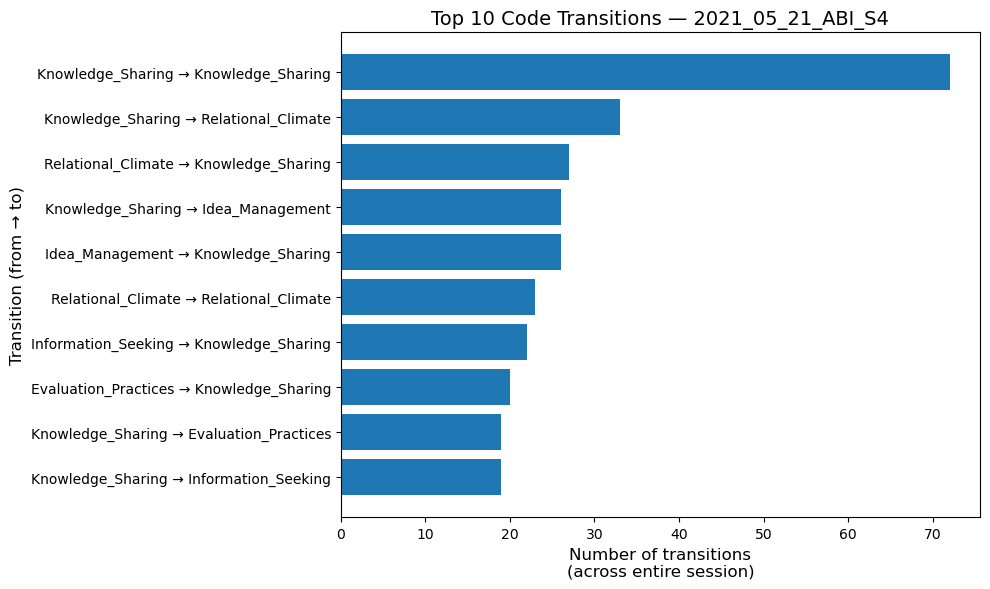

,from_code,to_code,n,pair_label
43,Knowledge_Sharing,Knowledge_Sharing,72,Knowledge_Sharing → Knowledge_Sharing
45,Knowledge_Sharing,Relational_Climate,33,Knowledge_Sharing → Relational_Climate
59,Relational_Climate,Knowledge_Sharing,27,Relational_Climate → Knowledge_Sharing
40,Knowledge_Sharing,Idea_Management,26,Knowledge_Sharing → Idea_Management
21,Idea_Management,Knowledge_Sharing,26,Idea_Management → Knowledge_Sharing
61,Relational_Climate,Relational_Climate,23,Relational_Climate → Relational_Climate
28,Information_Seeking,Knowledge_Sharing,22,Information_Seeking → Knowledge_Sharing
13,Evaluation_Practices,Knowledge_Sharing,20,Evaluation_Practices → Knowledge_Sharing
39,Knowledge_Sharing,Evaluation_Practices,19,Knowledge_Sharing → Evaluation_Practices
41,Knowledge_Sharing,Information_Seeking,19,Knowledge_Sharing → Information_Seeking


In [ ]:
# Count transitions across the **entire session** (not per minute)
top_couplets = (
    couplets_s4
    .groupby(["from_code", "to_code"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(10)
)

# Combine into a single label like "KS → RC"
top_couplets["pair_label"] = (
    top_couplets["from_code"] + " → " + top_couplets["to_code"]
)

plt.figure(figsize=(10, 6))
plt.barh(top_couplets["pair_label"], top_couplets["n"])
plt.gca().invert_yaxis()  # biggest on top

plt.title("Top 10 Code Transitions — 2021_05_21_ABI_S4", fontsize=14)
plt.xlabel("Number of transitions\n(across entire session)", fontsize=12)
plt.ylabel("Transition (from → to)", fontsize=12)

plt.tight_layout()
plt.show()

top_couplets  # optional: print the table as well

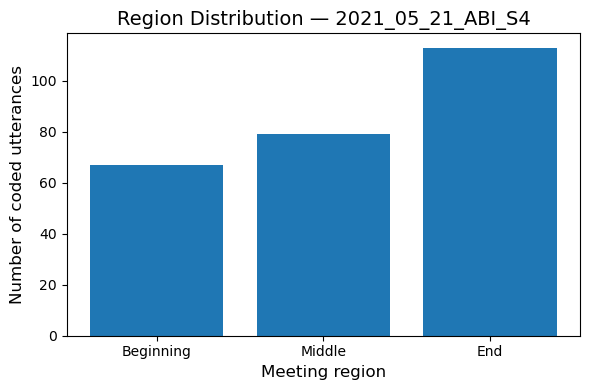

In [ ]:
region_vals = session_feat_s4[["Beginning", "Middle", "End"]].iloc[0]

plt.figure(figsize=(6, 4))
plt.bar(region_vals.index, region_vals.values)

plt.title("Region Distribution — 2021_05_21_ABI_S4", fontsize=14)
plt.xlabel("Meeting region", fontsize=12)
plt.ylabel("Number of coded utterances", fontsize=12)


plt.tight_layout()
plt.show()

# Examining the Knowledge Sharing Sequences

In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# STEP 1: Knowledge-Sharing sequences (streaks, regions, timing)
# -------------------------------------------------------------------

def compute_ks_sequence_features(df_events, ks_col="Knowledge_Sharing"):
    """
    For each (conference, session):
      - KS_total_utterances
      - KS_streak_count  (number of distinct runs of consecutive KS utterances)
      - KS_max_streak_len
      - KS_mean_streak_len
      - KS_beginning / KS_middle / KS_end counts
      - KS_first_minute, KS_last_minute, KS_mean_minute  (midpoint of KS utterances)
    Returns: DataFrame indexed by (conference, session).
    """
    rows = []

    # make sure region exists (you already computed it earlier)
    if "region" not in df_events.columns:
        raise ValueError("df_events is missing 'region' column. "
                         "Make sure you ran the region assignment step first.")

    for (conf, sess), sub in df_events.groupby(["conference", "session"], sort=False):
        sub = sub.sort_values("start_sec").reset_index(drop=True)

        # Basic KS presence
        ks_mask = sub[ks_col] == 1
        KS_total_utterances = int(ks_mask.sum())

        # If no KS at all, fill zeros and continue
        if KS_total_utterances == 0:
            rows.append({
                "conference": conf,
                "session": sess,
                "KS_total_utterances": 0,
                "KS_streak_count": 0,
                "KS_max_streak_len": 0,
                "KS_mean_streak_len": 0.0,
                "KS_beginning": 0,
                "KS_middle": 0,
                "KS_end": 0,
                "KS_first_minute": np.nan,
                "KS_last_minute": np.nan,
                "KS_mean_minute": np.nan,
            })
            continue

        # ---- Streaks of consecutive KS utterances ----
        streak_lengths = []
        in_streak = False
        cur_len = 0

        for is_ks in ks_mask:
            if is_ks:
                if not in_streak:
                    in_streak = True
                    cur_len = 1
                else:
                    cur_len += 1
            else:
                if in_streak:
                    streak_lengths.append(cur_len)
                    in_streak = False
                    cur_len = 0

        # close final streak
        if in_streak:
            streak_lengths.append(cur_len)

        KS_streak_count = len(streak_lengths)
        KS_max_streak_len = int(max(streak_lengths)) if streak_lengths else 0
        KS_mean_streak_len = float(np.mean(streak_lengths)) if streak_lengths else 0.0

        # ---- Region distribution of KS ----
        ks_region_counts = (
            sub.loc[ks_mask, "region"]
            .value_counts()
            .to_dict()
        )
        KS_beginning = int(ks_region_counts.get("Beginning", 0))
        KS_middle    = int(ks_region_counts.get("Middle", 0))
        KS_end       = int(ks_region_counts.get("End", 0))

        # ---- Timing of KS in minutes (using mid_sec) ----
        ks_times_sec = sub.loc[ks_mask, "mid_sec"].dropna().values
        if len(ks_times_sec) > 0:
            ks_minutes = ks_times_sec / 60.0
            KS_first_minute = float(np.min(ks_minutes))
            KS_last_minute  = float(np.max(ks_minutes))
            KS_mean_minute  = float(np.mean(ks_minutes))
        else:
            KS_first_minute = KS_last_minute = KS_mean_minute = np.nan

        rows.append({
            "conference": conf,
            "session": sess,
            "KS_total_utterances": KS_total_utterances,
            "KS_streak_count": KS_streak_count,
            "KS_max_streak_len": KS_max_streak_len,
            "KS_mean_streak_len": KS_mean_streak_len,
            "KS_beginning": KS_beginning,
            "KS_middle": KS_middle,
            "KS_end": KS_end,
            "KS_first_minute": KS_first_minute,
            "KS_last_minute": KS_last_minute,
            "KS_mean_minute": KS_mean_minute,
        })

    df_ks_features = pd.DataFrame(rows)
    return df_ks_features


df_ks_features = compute_ks_sequence_features(df_events, ks_col="Knowledge_Sharing")
print("df_ks_features shape:", df_ks_features.shape)
print(df_ks_features.head())

# -------------------------------------------------------------------
# STEP 2: Proto-linkography metrics from code couplets
# -------------------------------------------------------------------

def compute_linkography_features(df_couplets):
    """
    For each (conference, session), compute:
      - n_transitions
      - n_unique_pairs
      - transition_entropy (Shannon)
      - key KS-related transitions:
          KS->KS
          KS->Idea_Management
          Idea_Management->KS
          KS->Evaluation_Practices
          Evaluation_Practices->KS
          KS->Information_Seeking
          Information_Seeking->KS
          KS->Relational_Climate
          Relational_Climate->KS
    Returns: DataFrame indexed by (conference, session).
    """
    if df_couplets is None or df_couplets.empty:
        print("df_couplets is empty; returning empty linkography feature frame.")
        return pd.DataFrame(columns=[
            "conference", "session",
            "n_transitions", "n_unique_pairs", "transition_entropy",
            "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
            "KS_to_Eval", "Eval_to_KS",
            "KS_to_Info", "Info_to_KS",
            "KS_to_Rel", "Rel_to_KS",
        ])

    rows = []
    for (conf, sess), sub in df_couplets.groupby(["conference", "session"], sort=False):
        n_transitions = len(sub)

        # pair counts
        pair_counts = sub.groupby(["from_code", "to_code"]).size()
        n_unique_pairs = len(pair_counts)

        # entropy of transition distribution
        probs = pair_counts / n_transitions
        transition_entropy = float(-(probs * np.log2(probs)).sum()) if n_transitions > 0 else 0.0

        # Helper to count specific patterns
        def count_pairs(f, t):
            return int(((sub["from_code"] == f) & (sub["to_code"] == t)).sum())

        KS  = "Knowledge_Sharing"
        IM  = "Idea_Management"
        EV  = "Evaluation_Practices"
        IS  = "Information_Seeking"
        RC  = "Relational_Climate"

        KS_to_KS   = count_pairs(KS, KS)
        KS_to_Idea = count_pairs(KS, IM)
        Idea_to_KS = count_pairs(IM, KS)

        KS_to_Eval = count_pairs(KS, EV)
        Eval_to_KS = count_pairs(EV, KS)

        KS_to_Info = count_pairs(KS, IS)
        Info_to_KS = count_pairs(IS, KS)

        KS_to_Rel  = count_pairs(KS, RC)
        Rel_to_KS  = count_pairs(RC, KS)

        rows.append({
            "conference": conf,
            "session": sess,
            "n_transitions": n_transitions,
            "n_unique_pairs": n_unique_pairs,
            "transition_entropy": transition_entropy,
            "KS_to_KS": KS_to_KS,
            "KS_to_Idea": KS_to_Idea,
            "Idea_to_KS": Idea_to_KS,
            "KS_to_Eval": KS_to_Eval,
            "Eval_to_KS": Eval_to_KS,
            "KS_to_Info": KS_to_Info,
            "Info_to_KS": Info_to_KS,
            "KS_to_Rel": KS_to_Rel,
            "Rel_to_KS": Rel_to_KS,
        })

    df_linko = pd.DataFrame(rows)
    return df_linko


df_linko_features = compute_linkography_features(df_couplets)
print("df_linko_features shape:", df_linko_features.shape)
print(df_linko_features.head())

# -------------------------------------------------------------------
# STEP 3: Merge session features + KS sequences + linkography metrics
# -------------------------------------------------------------------

df_session_linkography = (
    df_session_features
    .merge(df_ks_features, on=["conference", "session"], how="left")
    .merge(df_linko_features, on=["conference", "session"], how="left")
)

# Fill NaNs for integer-ish linkography counts with 0
count_cols = [
    "KS_total_utterances", "KS_streak_count", "KS_max_streak_len",
    "KS_beginning", "KS_middle", "KS_end",
    "n_transitions", "n_unique_pairs",
    "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
    "KS_to_Eval", "Eval_to_KS",
    "KS_to_Info", "Info_to_KS",
    "KS_to_Rel", "Rel_to_KS",
]
for c in count_cols:
    if c in df_session_linkography.columns:
        df_session_linkography[c] = df_session_linkography[c].fillna(0).astype(int)

print("df_session_linkography shape:", df_session_linkography.shape)
print(df_session_linkography.head(10))

df_ks_features shape: (157, 12)
  conference            session  KS_total_utterances  KS_streak_count  \
0    2020NES  2020_11_05_NES_S1                   44               18   
1    2020NES  2020_11_05_NES_S2                   32               19   
2    2020NES  2020_11_05_NES_S3                   22               13   
3    2020NES  2020_11_05_NES_S4                   18               13   
4    2020NES  2020_11_05_NES_S5                   13                6   

   KS_max_streak_len  KS_mean_streak_len  KS_beginning  KS_middle  KS_end  \
0                 10            2.444444            24         13       7   
1                  6            1.684211             8         15       9   
2                  4            1.692308             6         10       6   
3                  4            1.384615             8          5       5   
4                  4            2.166667             6          6       1   

   KS_first_minute  KS_last_minute  KS_mean_minute  
0         0.1

## COMPACT SUMMARY TABLE (sanity check - did not put into slidedeck)

df_summary_sorted (top 10 by total KS):
    conference            session  n_utterances  n_speakers  max_time  \
107    2021NES  2021_11_05_NES_S1           382          23      6773   
91     2021MZT  2021_09_30_MZT_S7           425          25      9111   
155    2022MND  2022_04_08_MND_S8           365          10      4391   
156    2022MND  2022_04_08_MND_S9           273           9      4436   
34     2021ABI  2021_05_21_ABI_S4           259          12      4658   
112    2021NES  2021_11_05_NES_S3           315          23      6783   
118    2021NES  2021_11_05_NES_S9           266          11      4410   
115    2021NES  2021_11_05_NES_S6           339          23      6793   
114    2021NES  2021_11_05_NES_S5           299          23      6791   
144    2022MND  2022_04_07_MND_S6           234           9      4427   

     Beginning  Middle    End  Idea_Management  Information_Seeking  ...  \
107      150.0   155.0   77.0               61                   76  ...   
91  

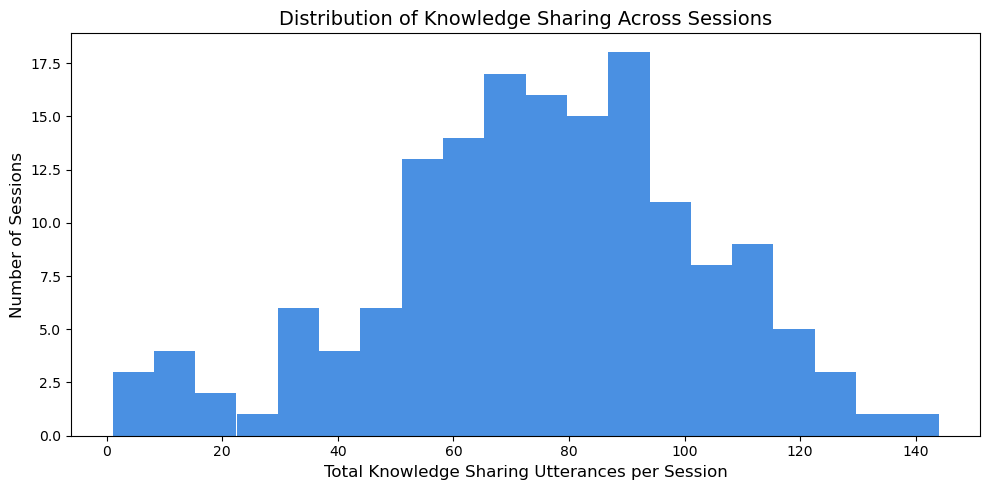

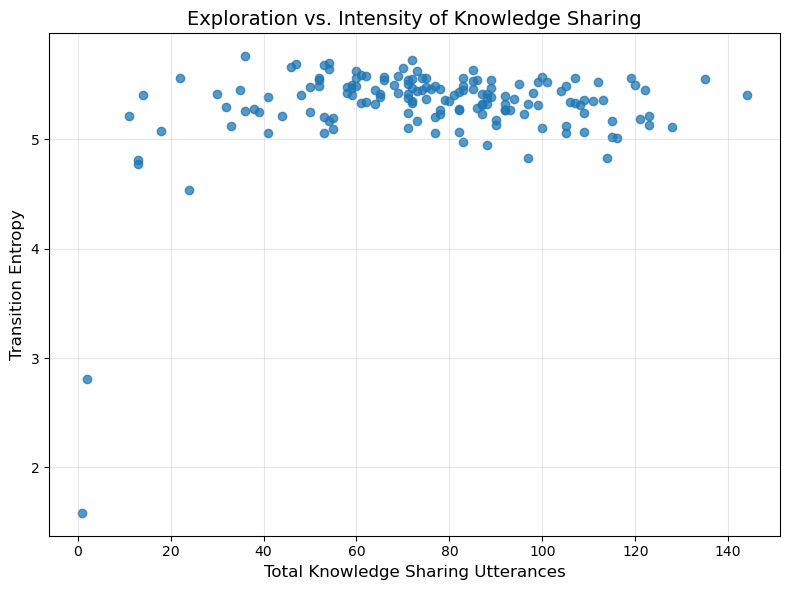

Mean KS_total_utterances by conference:
  conference  mean_KS_total
0    2020NES      35.562500
1    2021ABI      83.840000
2    2021CMC      71.285714
3    2021MND      73.625000
4    2021MZT      64.600000
5    2021NES      92.166667
6    2021SLU      80.000000
7    2022MND      89.722222


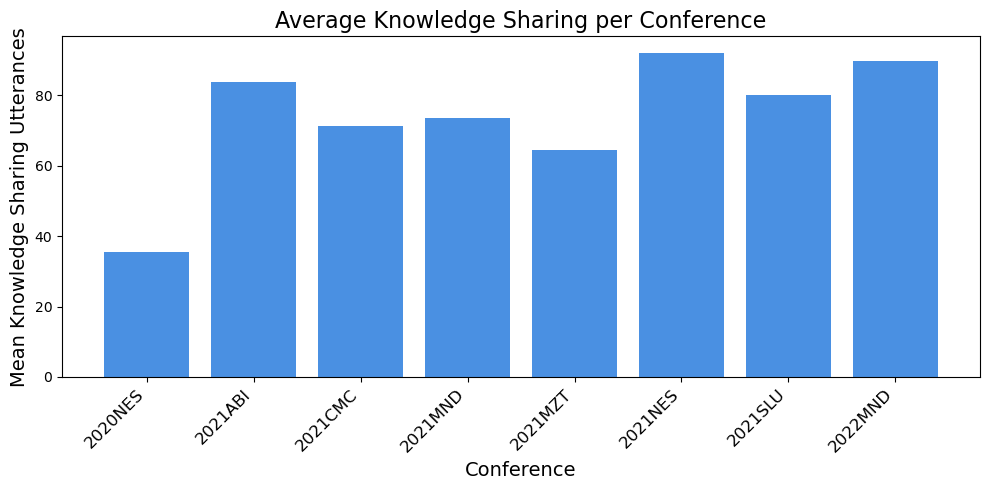

Saved modeling-ready features to:
  /Users/maxchalekson/Desktop/gemini_data_analysis/data/session_linkography_features.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. COMPACT SUMMARY TABLE FOR SLIDES
# ---------------------------------------------
# Pick a subset of the 38 columns that tell the clearest story
cols_for_summary = [
    "conference", "session",
    "n_utterances", "n_speakers", "max_time",
    "Beginning", "Middle", "End",
    "Idea_Management", "Information_Seeking", "Knowledge_Sharing",
    "Evaluation_Practices", "Relational_Climate",
    "KS_total_utterances", "KS_streak_count",
    "KS_max_streak_len", "KS_mean_streak_len",
    "KS_first_minute", "KS_last_minute", "KS_mean_minute",
    "n_transitions", "n_unique_pairs", "transition_entropy",
    "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
    "KS_to_Eval", "Eval_to_KS",
    "KS_to_Info", "Info_to_KS",
    "KS_to_Rel", "Rel_to_KS",
]

# Keep only the columns that actually exist (safety check)
cols_for_summary = [c for c in cols_for_summary if c in df_session_linkography.columns]

df_summary = df_session_linkography[cols_for_summary].copy()

# Example: sort by total KS to see the most KS-heavy sessions
df_summary_sorted = df_summary.sort_values("KS_total_utterances", ascending=False)

print("df_summary_sorted (top 10 by total KS):")
print(df_summary_sorted.head(10))

# ---------------------------------------------
# 2. OVERVIEW PLOTS ACROSS ALL SESSIONS
# ---------------------------------------------
# (a) Distribution of KS across sessions
plt.figure(figsize=(10, 5))
plt.hist(df_session_linkography["KS_total_utterances"], bins=20, color="#4A90E2")
plt.xlabel("Total Knowledge Sharing Utterances per Session", fontsize=12)
plt.ylabel("Number of Sessions", fontsize=12)
plt.title("Distribution of Knowledge Sharing Across Sessions", fontsize=14)
plt.tight_layout()
plt.show()

# (b) KS intensity vs transition entropy
plt.figure(figsize=(8, 6))
plt.scatter(
    df_session_linkography["KS_total_utterances"],
    df_session_linkography["transition_entropy"],
    alpha=0.75
)
plt.xlabel("Total Knowledge Sharing Utterances", fontsize=12)
plt.ylabel("Transition Entropy", fontsize=12)
plt.title("Exploration vs. Intensity of Knowledge Sharing", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (c) Mean KS_total by conference
if "conference" in df_session_linkography.columns:
    mean_ks_by_conf = (
        df_session_linkography
        .groupby("conference")["KS_total_utterances"]
        .mean()
        .reset_index(name="mean_KS_total")
    )
    print("Mean KS_total_utterances by conference:")
    print(mean_ks_by_conf)

    plt.figure(figsize=(10, 5))
    plt.bar(mean_ks_by_conf["conference"],
            mean_ks_by_conf["mean_KS_total"],
            color="#4A90E2")
    plt.title("Average Knowledge Sharing per Conference", fontsize=16)
    plt.xlabel("Conference", fontsize=14)
    plt.ylabel("Mean Knowledge Sharing Utterances", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------
# 3. EXPORT THE MODELING-READY TABLE
# ---------------------------------------------
out_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/session_linkography_features.csv"
df_session_linkography.to_csv(out_path, index=False)
print(f"Saved modeling-ready features to:\n  {out_path}")

# Identifying Team Success - for 2021ABI

Based on funding status, etc.

In [ ]:
import json
import pandas as pd

# ---------------------------------------------------
# 1. LOAD THE 2021 ABI OUTCOME JSON
# ---------------------------------------------------
json_path = json_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json"

with open(json_path, "r") as f:
    abi_data = json.load(f)

# ---------------------------------------------------
# 2. PARSE EACH SESSION INTO A FLAT ROW
# ---------------------------------------------------
rows = []
for session_id, detail in abi_data.items():

    # skip metadata keys like "missing_names"
    if not session_id.startswith("2021"):
        continue

    teams = detail.get("teams", {})

    # number of total teams
    n_teams = len(teams)

    # number of funded teams
    n_funded = sum(team_info.get("funded_status", 0) for team_info in teams.values())

    # did the session produce *any* funded outcomes?
    funded_any = 1 if n_funded > 0 else 0

    # append row
    rows.append({
        "session": session_id,
        "conference": "2021ABI",
        "n_teams": n_teams,
        "n_funded": n_funded,
        "funded_any": funded_any
    })

# convert to DataFrame
df_success = pd.DataFrame(rows)

print("\nParsed Success Table (2021 ABI):")
print(df_success.head(), "\n")
print(df_success)

# ---------------------------------------------------
# 3. MERGE WITH YOUR LINKOGRAPHY FEATURES
# ---------------------------------------------------
df_merged = df_session_linkography.merge(
    df_success,
    on=["conference", "session"],
    how="left"
)

print("\nMerged Shape:", df_merged.shape)
print(df_merged[["conference","session","n_teams","n_funded","funded_any"]].head())


Parsed Success Table (2021 ABI):
              session conference  n_teams  n_funded  funded_any
0   2021_05_20_ABI_S5    2021ABI        1         0           0
1   2021_05_20_ABI_S4    2021ABI        2         2           1
2  2021_05_21_ABI_S16    2021ABI        0         0           0
3   2021_05_21_ABI_S1    2021ABI        0         0           0
4   2021_05_20_ABI_S8    2021ABI        1         0           0 

               session conference  n_teams  n_funded  funded_any
0    2021_05_20_ABI_S5    2021ABI        1         0           0
1    2021_05_20_ABI_S4    2021ABI        2         2           1
2   2021_05_21_ABI_S16    2021ABI        0         0           0
3    2021_05_21_ABI_S1    2021ABI        0         0           0
4    2021_05_20_ABI_S8    2021ABI        1         0           0
5   2021_05_21_ABI_S11    2021ABI        2         1           1
6    2021_05_20_ABI_S3    2021ABI        1         1           1
7    2021_05_21_ABI_S6    2021ABI        0         0        

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Clean ABI sessions (optional but nice)
# ---------------------------------------------------
abi_sessions = abi_sessions.copy()

# Drop that weird "output-..." row if you don’t want it
abi_sessions = abi_sessions[~abi_sessions["session"].str.startswith("output-")]

# Keep only rows with a valid funded_any label
abi_labeled = abi_sessions.dropna(subset=["funded_any"]).copy()
abi_labeled["funded_any"] = abi_labeled["funded_any"].astype(int)

# ---------------------------------------------------
# 2. Group summaries: funded vs not funded
# ---------------------------------------------------
group_summary = (
    abi_labeled
    .groupby("funded_any")
    .agg(
        KS_total_utterances_mean=("KS_total_utterances", "mean"),
        KS_max_streak_len_mean=("KS_max_streak_len", "mean"),
        KS_mean_streak_len_mean=("KS_mean_streak_len", "mean"),
        transition_entropy_mean=("transition_entropy", "mean"),
        n_teams_mean=("n_teams", "mean"),
        n_funded_mean=("n_funded", "mean"),
    )
    .reset_index()
)

group_summary["funded_any_label"] = group_summary["funded_any"].map(
    {0: "No funded team", 1: "≥1 funded team"}
)

print("\nGroup means (funded_any = 0 vs 1):")
print(group_summary)

# ---------------------------------------------------
# 3. Simple plots for slides (ABI only)
# ---------------------------------------------------

# A) KS_total_utterances by funded_any (scatter "strips")
plt.figure(figsize=(6, 4))
for label, grp in abi_labeled.groupby("funded_any"):
    xs = [label] * len(grp)
    plt.scatter(xs, grp["KS_total_utterances"], alpha=0.6)

plt.xticks([0, 1], ["No funded team", "≥1 funded team"])
plt.ylabel("Total Knowledge Sharing Utterances")
plt.title("Knowledge Sharing vs. Funding Outcome (2021 ABI)")
plt.tight_layout()
plt.show()

# B) Boxplots for a couple of key features
features_to_box = ["KS_total_utterances", "KS_max_streak_len", "transition_entropy"]

for feat in features_to_box:
    plt.figure(figsize=(6, 4))
    abi_labeled.boxplot(column=feat, by="funded_any")
    plt.xticks([1, 2], ["No funded team", "≥1 funded team"])
    plt.xlabel("")
    plt.title(f"{feat} by Funding Outcome (2021 ABI)")
    plt.suptitle("")  # remove pandas' default super-title
    plt.tight_layout()
    plt.show()

NameError: name 'abi_sessions' is not defined

In [ ]:
import json
import pandas as pd

# ---------------------------------------------------
# 1. LOAD + PARSE 2021 ABI SESSION OUTCOMES
# ---------------------------------------------------
abi_json_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json"

with open(abi_json_path, "r") as f:
    abi_raw = json.load(f)

print("Top-level type for ABI JSON:", type(abi_raw))

rows = []

# Expected structure (dict):
# {
#   "2021_05_20_ABI_S4": {
#       "teams": {
#           "ABI13": {
#               "members": [...],
#               "funded_status": 1
#           },
#           ...
#       },
#       ...
#   },
#   "2021_05_21_ABI_S11": { ... },
#   ...
# }
if isinstance(abi_raw, dict):
    for sess_id, sess_data in abi_raw.items():
        # Skip any non-dict top-level entries (e.g., metadata keys)
        if not isinstance(sess_data, dict):
            continue

        teams_dict = sess_data.get("teams", {})
        if not isinstance(teams_dict, dict):
            # No valid team info
            n_teams = 0
            n_funded = 0
        else:
            n_teams = 0
            n_funded = 0
            for team_id, team_info in teams_dict.items():
                if not isinstance(team_info, dict):
                    continue
                n_teams += 1
                status = team_info.get("funded_status", 0)
                try:
                    status_int = int(status)
                except Exception:
                    status_int = 0
                if status_int == 1:
                    n_funded += 1

        rows.append({
            "conference": "2021ABI",
            "session": sess_id,
            "n_teams": n_teams,
            "n_funded": n_funded,
        })

else:
    print("Unexpected ABI JSON structure; expected dict at top level.")
    rows = []

df_abi_success = pd.DataFrame(rows)

print("\n🔥 Parsed ABI success table (non-zero funded rows):")
print(
    df_abi_success[df_abi_success["n_funded"] > 0]
    .sort_values(["session"])
    .to_string(index=False)
)

print("\nAll ABI success rows (first 10):")
print(df_abi_success.head(10).to_string(index=False))


# ---------------------------------------------------
# 2. MERGE WITH LINKOGRAPHY TABLE (ABI ONLY)
# ---------------------------------------------------
# Assumes df_session_linkography already exists
df_abi_link = df_session_linkography[
    df_session_linkography["conference"] == "2021ABI"
].copy()

# Drop any stale success columns if they exist
df_abi_link = df_abi_link.drop(
    columns=["n_teams", "n_funded", "funded_any"],
    errors="ignore"
)

# Merge success labels onto ABI linkography rows
merged_abi = df_abi_link.merge(
    df_abi_success,
    on=["conference", "session"],
    how="left"
)

# Keep only "real" session ids (skip any weird "output-..." rows if they exist)
mask_real = merged_abi["session"].str.startswith("2021_")
merged_abi = merged_abi[mask_real].copy()

# Fill missing success labels (if any) with 0
for col in ["n_teams", "n_funded"]:
    merged_abi[col] = merged_abi[col].fillna(0).astype(int)

print("\n✅ ABI sessions after merge (session + success columns):")
print(
    merged_abi[["session", "n_teams", "n_funded"]]
    .sort_values("session")
    .to_string(index=False)
)


# ---------------------------------------------------
# 3. FUNDED VS NOT-FUNDED BEHAVIORAL SUMMARY
#    (using n_funded > 0 instead of funded_any)
# ---------------------------------------------------
# Create a binary grouping based on whether any teams were funded
merged_abi["funded_group"] = (merged_abi["n_funded"] > 0).astype(int)
merged_abi["funded_group_label"] = merged_abi["funded_group"].map({
    0: "No funded team",
    1: "≥1 funded team"
})

# Columns to compare between funded vs non-funded sessions
cols_to_compare = [
    "KS_total_utterances",
    "KS_streak_count",
    "KS_max_streak_len",
    "KS_mean_streak_len",
    "KS_beginning",
    "KS_middle",
    "KS_end",
    "transition_entropy",
]

group_table = (
    merged_abi
    .groupby("funded_group_label")[cols_to_compare]
    .mean()
    .reset_index()
)

# Optional: round for slide readability
group_table[cols_to_compare] = group_table[cols_to_compare].round(3)

# Make funded_group_label the index for a clean printout
group_table = group_table.set_index("funded_group_label")

print("\n===== ABI 2021 — Behavioral Differences (Funded vs Not) =====")
print(group_table.to_string())

Top-level type for ABI JSON: <class 'dict'>

🔥 Parsed ABI success table (non-zero funded rows):
conference            session  n_teams  n_funded
   2021ABI  2021_05_20_ABI_S3        1         1
   2021ABI  2021_05_20_ABI_S4        2         2
   2021ABI  2021_05_20_ABI_S6        2         1
   2021ABI  2021_05_20_ABI_S7        1         1
   2021ABI 2021_05_21_ABI_S11        2         1
   2021ABI 2021_05_21_ABI_S12        3         1
   2021ABI 2021_05_21_ABI_S13        2         1
   2021ABI 2021_05_21_ABI_S15        2         1
   2021ABI  2021_05_21_ABI_S2        3         1
   2021ABI  2021_05_21_ABI_S7        3         1

All ABI success rows (first 10):
conference            session  n_teams  n_funded
   2021ABI  2021_05_20_ABI_S5        1         0
   2021ABI  2021_05_20_ABI_S4        2         2
   2021ABI 2021_05_21_ABI_S16        0         0
   2021ABI  2021_05_21_ABI_S1        0         0
   2021ABI  2021_05_20_ABI_S8        1         0
   2021ABI 2021_05_21_ABI_S11        

# Directionality and Temporal Thirds

In [ ]:
import pandas as pd

# ---------------------------------------------------
# 1. Ensure we have a funded_any flag for ABI
# ---------------------------------------------------
# (Funded if at least one funded team in the session)
merged_abi["funded_any"] = (merged_abi["n_funded"] > 0).astype(int)

# ---------------------------------------------------
# 2. Build transition *directionality* features
#    (normalize each KS→X or X→KS by total transitions)
# ---------------------------------------------------
direction_cols = [
    "KS_to_KS",
    "KS_to_Idea", "Idea_to_KS",
    "KS_to_Eval", "Eval_to_KS",
    "KS_to_Info", "Info_to_KS",
    "KS_to_Rel", "Rel_to_KS",
]

# avoid divide-by-zero
denom = merged_abi["n_transitions"].replace(0, pd.NA)

for col in direction_cols:
    merged_abi[f"{col}_prop"] = merged_abi[col] / denom

# Example: KS_to_Idea_prop = proportion of all transitions that are KS→Idea


# ---------------------------------------------------
# 3. Build *temporal thirds* features for KS
#    (how KS is distributed across beginning/middle/end)
# ---------------------------------------------------
ks_total = merged_abi["KS_total_utterances"].replace(0, pd.NA)

merged_abi["KS_beginning_prop"] = merged_abi["KS_beginning"] / ks_total
merged_abi["KS_middle_prop"]    = merged_abi["KS_middle"]    / ks_total
merged_abi["KS_end_prop"]       = merged_abi["KS_end"]       / ks_total

# Optional sanity check: these should be ~1.0 when there is KS
merged_abi["KS_prop_sum"] = (
    merged_abi["KS_beginning_prop"]
    + merged_abi["KS_middle_prop"]
    + merged_abi["KS_end_prop"]
)


# ---------------------------------------------------
# 4. Summarize: funded vs not-funded (ABI only)
# ---------------------------------------------------
cols_summary = [
    # overall KS
    "KS_total_utterances",
    # temporal distribution
    "KS_beginning_prop", "KS_middle_prop", "KS_end_prop",
    # directionality proportions
    "KS_to_Idea_prop", "Idea_to_KS_prop",
    "KS_to_Eval_prop", "Eval_to_KS_prop",
    "KS_to_Info_prop", "Info_to_KS_prop",
    "KS_to_Rel_prop", "Rel_to_KS_prop",
    # exploration baseline
    "transition_entropy",
]

group_temp_dir = (
    merged_abi
    .groupby("funded_any")[cols_summary]
    .mean()
    .reset_index()
)

group_temp_dir["funded_group_label"] = group_temp_dir["funded_any"].map({
    0: "No funded team",
    1: "≥1 funded team",
})

group_temp_dir = (
    group_temp_dir
    .set_index("funded_group_label")
    .drop(columns=["funded_any"])
    .sort_index()
)

print("\n===== ABI 2021 — Temporal & Directionality Features (Funded vs Not) =====")
print(group_temp_dir.to_string(float_format=lambda x: f"{x:0.3f}"))


===== ABI 2021 — Temporal & Directionality Features (Funded vs Not) =====
                    KS_total_utterances  KS_beginning_prop  KS_middle_prop  KS_end_prop  KS_to_Idea_prop  Idea_to_KS_prop  KS_to_Eval_prop  Eval_to_KS_prop  KS_to_Info_prop  Info_to_KS_prop  KS_to_Rel_prop  Rel_to_KS_prop  transition_entropy
funded_group_label                                                                                                                                                                                                                               
No funded team                   87.929              0.274           0.387        0.339            0.042            0.040            0.025            0.024            0.037            0.040           0.038           0.034               5.382
≥1 funded team                   85.100              0.348           0.359        0.292            0.046            0.044            0.029            0.025            0.037            0.042          

# STOP HERE.

# USE THESE FEATURES TO TRAIN A SIMPLE PREDICTIVE MODEL FOR TEAM SUCCESS
## Starting with ABI then will scale it

In [ ]:
import json
import pandas as pd
import statsmodels.formula.api as smf

# -------------------------------------------------------
# 1. REBUILD merged_abi  (ABI linkography + success labels)
# -------------------------------------------------------

abi_json_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json"

with open(abi_json_path, "r") as f:
    abi_raw = json.load(f)

rows = []
if isinstance(abi_raw, dict):
    for sess_id, sess_data in abi_raw.items():
        if not isinstance(sess_data, dict):
            continue

        teams = sess_data.get("teams", {})
        n_teams = 0
        n_funded = 0
        if isinstance(teams, dict):
            for team_id, info in teams.items():
                if not isinstance(info, dict):
                    continue
                n_teams += 1
                if int(info.get("funded_status", 0)) == 1:
                    n_funded += 1

        rows.append({
            "conference": "2021ABI",
            "session": sess_id,
            "n_teams": n_teams,
            "n_funded": n_funded,
        })
else:
    raise ValueError("Unexpected ABI JSON structure; expected dict at top level.")

df_abi_success = pd.DataFrame(rows)

# Filter ABI linkography rows
df_abi_link = df_session_linkography[
    df_session_linkography["conference"] == "2021ABI"
].copy()

# Drop any old success columns that might still be there
df_abi_link = df_abi_link.drop(
    columns=["n_teams", "n_funded", "funded_any"],
    errors="ignore"
)

# Merge success labels
merged_abi = df_abi_link.merge(
    df_abi_success,
    on=["conference", "session"],
    how="left"
)

# Keep only real ABI session IDs
merged_abi = merged_abi[merged_abi["session"].str.startswith("2021_")].copy()

# Fill missing success labels with 0
for col in ["n_teams", "n_funded"]:
    merged_abi[col] = merged_abi[col].fillna(0).astype(int)

# -------------------------------------------------------
# 2. CREATE TEMPORAL & DIRECTIONALITY PROPORTION FEATURES
# -------------------------------------------------------

df = merged_abi.copy()

# Avoid divide-by-zero
df["KS_total_utterances"] = df["KS_total_utterances"].replace(0, pd.NA)
df["n_transitions"] = df["n_transitions"].replace(0, pd.NA)

# Temporal thirds (KS counts already in df)
df["KS_beginning_prop"] = df["KS_beginning"] / df["KS_total_utterances"]
df["KS_middle_prop"]    = df["KS_middle"]    / df["KS_total_utterances"]
df["KS_end_prop"]       = df["KS_end"]       / df["KS_total_utterances"]

# Directionality counts → proportions out of all transitions
transition_pairs = [
    "KS_to_Idea",
    "Idea_to_KS",
    "KS_to_Eval",
    "Eval_to_KS",
    "KS_to_Info",
    "Info_to_KS",
    "KS_to_Rel",
    "Rel_to_KS",
]

for col in transition_pairs:
    if col in df.columns:
        df[col + "_prop"] = df[col] / df["n_transitions"]

# -------------------------------------------------------
# 3. MODEL SETUP: BINARY FUNDED LABEL
# -------------------------------------------------------

df["funded_binary"] = (df["n_funded"] > 0).astype(int)

# ---- choose a SMALL, safer subset of predictors ----
#   - drop KS_end_prop to avoid perfect sum-to-one collinearity
#   - keep just a couple of directionality features to start
candidate_features = [
    "KS_beginning_prop",
    "KS_middle_prop",
    "KS_to_Idea_prop",
    "Idea_to_KS_prop",
    "transition_entropy",
]

# Keep only those that actually exist in df
feature_cols = [c for c in candidate_features if c in df.columns]

print("Using these predictors:", feature_cols)
print("N sessions:", len(df))

# -------------------------------------------------------
# 4. LOGISTIC REGRESSION: funded vs not
# -------------------------------------------------------

if len(df["funded_binary"].unique()) == 1:
    print("⚠️ Only one class in funded_binary; logistic regression won’t run.")
else:
    formula_logit = "funded_binary ~ " + " + ".join(feature_cols)
    try:
        logit_model = smf.logit(formula_logit, data=df).fit()
        print("\n===== LOGISTIC REGRESSION: Funded vs Not (ABI 2021) =====")
        print(logit_model.summary())
    except np.linalg.LinAlgError:
        print("\n⚠️ Logistic regression failed due to singular matrix even after feature reduction.")
        print("   -> Try removing one more predictor or fit a univariate model (one feature at a time).")

# -------------------------------------------------------
# 5. NEGATIVE BINOMIAL: number of funded teams
# -------------------------------------------------------

if df["n_funded"].max() == 0:
    print("\n⚠️ All n_funded are 0; skipping negative binomial model.")
else:
    formula_nb = "n_funded ~ " + " + ".join(feature_cols)
    try:
        nb_model = smf.glm(
            formula_nb,
            data=df,
            family=sm.families.NegativeBinomial()
        ).fit()
        print("\n===== NEGATIVE BINOMIAL: Count of Funded Teams (ABI 2021) =====")
        print(nb_model.summary())
    except np.linalg.LinAlgError:
        print("\n⚠️ Negative binomial regression failed due to singular matrix.")
        print("   -> Again, reduce predictors or try one-feature-at-a-time models.")

Using these predictors: ['KS_beginning_prop', 'KS_middle_prop', 'KS_to_Idea_prop', 'Idea_to_KS_prop', 'transition_entropy']
N sessions: 24
Optimization terminated successfully.
         Current function value: 0.539100
         Iterations 6

===== LOGISTIC REGRESSION: Funded vs Not (ABI 2021) =====
                           Logit Regression Results                           
Dep. Variable:          funded_binary   No. Observations:                   24
Model:                          Logit   Df Residuals:                       18
Method:                           MLE   Df Model:                            5
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.2063
Time:                        09:16:19   Log-Likelihood:                -12.938
converged:                       True   LL-Null:                       -16.301
Covariance Type:            nonrobust   LLR p-value:                    0.2420
                         coef    std err          z      P>|z|      

/opt/miniconda3/envs/gem_samp/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


# Yes, this is ready to scale to the other sessions

# SCALING FEATURE EXTRACTION + MODELING TO OTHER CONFERENCES

In [ ]:
import json
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ============================================================
# 1. Function to load + merge team outcomes for ANY conference
# ============================================================

def load_conference_success(json_path, conference_name):
    """
    Reads a session_outcomes.json file and returns a DataFrame with:
    - session
    - n_teams
    - n_funded
    - conference
    """
    with open(json_path, "r") as f:
        raw = json.load(f)

    rows = []
    if isinstance(raw, dict):
        for sess_id, sess_data in raw.items():
            if not isinstance(sess_data, dict):
                continue

            teams = sess_data.get("teams", {})
            n_teams = 0
            n_funded = 0
            if isinstance(teams, dict):
                for _, info in teams.items():
                    if not isinstance(info, dict):
                        continue
                    n_teams += 1
                    if int(info.get("funded_status", 0)) == 1:
                        n_funded += 1

            rows.append({
                "conference": conference_name,
                "session": sess_id,
                "n_teams": n_teams,
                "n_funded": n_funded,
            })

    return pd.DataFrame(rows)


# ============================================================
# 2. Function to merge linkography + success + engineer features
# ============================================================

def build_feature_dataset(df_session_linkography, df_success):
    """
    Takes linkography and success tables for ONE conference,
    merges them, and computes the KS-based features.
    """
    df_link = df_session_linkography[
        df_session_linkography["conference"] == df_success["conference"].iloc[0]
    ].copy()

    # Drop stale columns
    df_link = df_link.drop(columns=["n_teams", "n_funded", "funded_any"], errors="ignore")

    # Merge success
    df = df_link.merge(df_success, on=["conference", "session"], how="left")

    # Keep only real session IDs
    df = df[df["session"].str.contains("_")].copy()

    # Fill success labels
    df["n_teams"] = df["n_teams"].fillna(0).astype(int)
    df["n_funded"] = df["n_funded"].fillna(0).astype(int)

    # ======= Feature Engineering =======
    df["KS_total_utterances"] = df["KS_total_utterances"].replace(0, pd.NA)
    df["n_transitions"] = df["n_transitions"].replace(0, pd.NA)

    # Temporal proportions
    df["KS_beginning_prop"] = df["KS_beginning"] / df["KS_total_utterances"]
    df["KS_middle_prop"] = df["KS_middle"] / df["KS_total_utterances"]
    df["KS_end_prop"] = df["KS_end"] / df["KS_total_utterances"]

    # Directionality proportions
    transition_pairs = [
        "KS_to_Idea", "Idea_to_KS",
        "KS_to_Eval", "Eval_to_KS",
        "KS_to_Info", "Info_to_KS",
        "KS_to_Rel",  "Rel_to_KS",
    ]
    for col in transition_pairs:
        if col in df.columns:
            df[col + "_prop"] = df[col] / df["n_transitions"]

    # Binary funded label
    df["funded_binary"] = (df["n_funded"] > 0).astype(int)

    return df


# ============================================================
# 3. LOAD ALL CONFERENCES
# ============================================================

# ---- Already done for ABI ----
df_abi_success = load_conference_success(
    "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json",
    "2021ABI"
)

# ---- TODO: Add other conferences here ----
# Example placeholders — fill in real paths when ready
# df_mzt_success = load_conference_success("path/to/MZT_session_outcomes.json", "MZT")
# df_2022ABI_success = load_conference_success("path/to/2022ABI_session_outcomes.json", "2022ABI")

# ============================================================
# 4. BUILD FEATURE DATASETS FOR EACH CONFERENCE
# ============================================================

df_abi = build_feature_dataset(df_session_linkography, df_abi_success)

# When ready:
# df_mzt = build_feature_dataset(df_session_linkography, df_mzt_success)
# df_2022ABI = build_feature_dataset(df_session_linkography, df_2022ABI_success)

# ============================================================
# 5. CONCAT ALL CONFERENCE DATASETS (THIS IS THE BIG STEP)
# ============================================================

df_list = [df_abi]  # add others when ready

df_all = pd.concat(df_list, ignore_index=True)

print("Total sessions in df_all:", len(df_all))


# ============================================================
# 6. RUN LOGISTIC + NEGATIVE BINOMIAL MODELS ON df_all
# ============================================================

candidate_features = [
    "KS_beginning_prop",
    "KS_middle_prop",
    "KS_end_prop",
    "KS_to_Idea_prop",
    "Idea_to_KS_prop",
    "KS_to_Eval_prop",
    "KS_to_Info_prop",
    "KS_to_Rel_prop",
    "transition_entropy",
]

feature_cols = [c for c in candidate_features if c in df_all.columns]

# Logistic
if df_all["funded_binary"].nunique() > 1:
    formula_logit = "funded_binary ~ " + " + ".join(feature_cols)
    logit_model = smf.logit(formula_logit, data=df_all).fit()
    print("\n===== LOGIT MODEL: ALL CONFERENCES =====")
    print(logit_model.summary())

# Negative binomial
if df_all["n_funded"].max() > 0:
    formula_nb = "n_funded ~ " + " + ".join(feature_cols)
    nb_model = smf.glm(
        formula_nb,
        data=df_all,
        family=sm.families.NegativeBinomial()
    ).fit()
    print("\n===== NEGATIVE BINOMIAL: ALL CONFERENCES =====")
    print(nb_model.summary())

Total sessions in df_all: 24
Optimization terminated successfully.
         Current function value: 0.489469
         Iterations 9

===== LOGIT MODEL: ALL CONFERENCES =====
                           Logit Regression Results                           
Dep. Variable:          funded_binary   No. Observations:                   24
Model:                          Logit   Df Residuals:                       15
Method:                           MLE   Df Model:                            8
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.2793
Time:                        09:36:15   Log-Likelihood:                -11.747
converged:                       True   LL-Null:                       -16.301
Covariance Type:            nonrobust   LLR p-value:                    0.3334
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            

/opt/miniconda3/envs/gem_samp/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## sanity checking the 2021ABI

At some point I thought it was one sesh per json file... not the case. 

In [ ]:
import os
import pandas as pd

# --------------------------------------------
# 1. Sessions from linkography dataframe
# --------------------------------------------
abi_link_sessions = sorted(
    df_session_linkography[df_session_linkography["conference"]=="2021ABI"]["session"].unique()
)

print("ABI sessions in LINKOGRAPHY (Gemini annotations):")
print(len(abi_link_sessions), abi_link_sessions)


# --------------------------------------------
# 2. Sessions from the outcomes JSON folder
# --------------------------------------------
json_folder = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/session_data"

json_files = [f for f in os.listdir(json_folder) if f.endswith(".json")]

abi_json_sessions = sorted([
    f.replace(".json","")   # e.g., "2021_05_20_ABI_S8"
    for f in json_files
    if f.startswith("2021")
])

print("\nABI sessions with OUTCOME JSON:")
print(len(abi_json_sessions), abi_json_sessions)


# --------------------------------------------
# 3. Missing JSON (these get n_funded=0, n_teams=0)
# --------------------------------------------
missing = sorted(list(set(abi_link_sessions) - set(abi_json_sessions)))
print("\nABI sessions MISSING JSON (treated as 0 funded):")
print(len(missing), missing)

# --------------------------------------------
# 4. Sessions with JSON (normal funded/non-funded)
# --------------------------------------------
present = sorted(list(set(abi_link_sessions) & set(abi_json_sessions)))
print("\nABI sessions WITH JSON (normal metadata):")
print(len(present), present)

ABI sessions in LINKOGRAPHY (Gemini annotations):
25 ['2021_05_20_ABI_S1', '2021_05_20_ABI_S2', '2021_05_20_ABI_S3', '2021_05_20_ABI_S4', '2021_05_20_ABI_S5', '2021_05_20_ABI_S6', '2021_05_20_ABI_S7', '2021_05_20_ABI_S8', '2021_05_21_ABI_S1', '2021_05_21_ABI_S10', '2021_05_21_ABI_S11', '2021_05_21_ABI_S12', '2021_05_21_ABI_S13', '2021_05_21_ABI_S14', '2021_05_21_ABI_S15', '2021_05_21_ABI_S16', '2021_05_21_ABI_S2', '2021_05_21_ABI_S3', '2021_05_21_ABI_S4', '2021_05_21_ABI_S5', '2021_05_21_ABI_S6', '2021_05_21_ABI_S7', '2021_05_21_ABI_S8', '2021_05_21_ABI_S9', 'output-2021-05-20-ABI-S1']

ABI sessions with OUTCOME JSON:
24 ['2021_05_20_ABI_S1', '2021_05_20_ABI_S2', '2021_05_20_ABI_S3', '2021_05_20_ABI_S4', '2021_05_20_ABI_S5', '2021_05_20_ABI_S6', '2021_05_20_ABI_S7', '2021_05_20_ABI_S8', '2021_05_21_ABI_S1', '2021_05_21_ABI_S10', '2021_05_21_ABI_S11', '2021_05_21_ABI_S12', '2021_05_21_ABI_S13', '2021_05_21_ABI_S14', '2021_05_21_ABI_S15', '2021_05_21_ABI_S16', '2021_05_21_ABI_S2', '2021_

In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------------
# 1. START FROM CLEANED df_all (after filtering)
# -------------------------------------------------------

df_all = df_all.copy()

# Make sure we exclude any artifact sessions like "output-2021..."
df_all = df_all[~df_all["session"].str.contains("output-")].copy()

# Safety: replace zeros for proportions with NA for averaging
prop_cols = [
    "KS_beginning_prop", "KS_middle_prop", "KS_end_prop",
    "KS_to_Idea_prop", "Idea_to_KS_prop",
    "KS_to_Eval_prop", "KS_to_Info_prop", "KS_to_Rel_prop",
    "transition_entropy"
]

# -------------------------------------------------------
# 2. GROUP BY CONFERENCE → COMPUTE MEAN VALUES
# -------------------------------------------------------

summary_table = df_all.groupby("conference")[prop_cols].mean()

# -------------------------------------------------------
# 3. ADD PERCENT-FUNDED COLUMN
# -------------------------------------------------------

summary_table["pct_sessions_funded"] = (
    df_all.groupby("conference")["funded_binary"].mean() * 100
)

# -------------------------------------------------------
# 4. ROUND FOR PRETTY OUTPUT
# -------------------------------------------------------

summary_table = summary_table.round(3)

print("\n===== CROSS-CONFERENCE SUMMARY TABLE =====")
print(summary_table)

# Save for slide deck if needed
summary_table.to_csv("cross_conference_summary.csv")


===== CROSS-CONFERENCE SUMMARY TABLE =====
            KS_beginning_prop  KS_middle_prop  KS_end_prop  KS_to_Idea_prop  \
conference                                                                    
2021ABI                 0.305           0.376        0.319            0.043   

            Idea_to_KS_prop  KS_to_Eval_prop  KS_to_Info_prop  KS_to_Rel_prop  \
conference                                                                      
2021ABI               0.042            0.027            0.037           0.038   

            transition_entropy  pct_sessions_funded  
conference                                           
2021ABI                  5.378               41.667  


In [ ]:
import os
import json
import pandas as pd
import numpy as np

# ----------------------------------------------------
# 0. Start from your existing linkography table
#    (one row per conference x session)
# ----------------------------------------------------
df_all = df_session_linkography.copy()

# ----------------------------------------------------
# 1. Temporal proportions (per session)
# ----------------------------------------------------
df_all["KS_total_utterances"] = df_all["KS_total_utterances"].replace(0, np.nan)

df_all["KS_beginning_prop"] = df_all["KS_beginning"] / df_all["KS_total_utterances"]
df_all["KS_middle_prop"]    = df_all["KS_middle"]    / df_all["KS_total_utterances"]
df_all["KS_end_prop"]       = df_all["KS_end"]       / df_all["KS_total_utterances"]

# ----------------------------------------------------
# 2. Directionality proportions (per session)
# ----------------------------------------------------
df_all["n_transitions"] = df_all["n_transitions"].replace(0, np.nan)

transition_pairs = [
    "KS_to_Idea",
    "Idea_to_KS",
    "KS_to_Eval",
    "Eval_to_KS",
    "KS_to_Info",
    "Info_to_KS",
    "KS_to_Rel",
    "Rel_to_KS",
]

for col in transition_pairs:
    if col in df_all.columns:
        df_all[col + "_prop"] = df_all[col] / df_all["n_transitions"]

# ----------------------------------------------------
# 3. Build funding labels ACROSS ALL CONFERENCES
#    (ABI, SLU, NES, CMC, MND, MZT, etc.)
# ----------------------------------------------------
BASE_PATH = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/"

fund_rows = []

for conf in os.listdir(BASE_PATH):
    conf_path = os.path.join(BASE_PATH, conf)
    if not os.path.isdir(conf_path):
        continue

    # We expect files like: 2021ABI_session_outcomes.json, 2021SLU_session_outcomes.json, ...
    outcomes_path = os.path.join(conf_path, f"{conf}_session_outcomes.json")
    if not os.path.exists(outcomes_path):
        continue

    with open(outcomes_path, "r") as f:
        raw = json.load(f)

    # ABI / SLU style: dict keyed by session_id, plus extras like "missing_names"
    if isinstance(raw, dict):
        for sess_id, sess_data in raw.items():
            if not isinstance(sess_data, dict):
                continue
            teams = sess_data.get("teams", {})
            if not isinstance(teams, dict):
                continue

            n_teams = 0
            n_funded = 0
            for _, tinfo in teams.items():
                if not isinstance(tinfo, dict):
                    continue
                n_teams += 1
                if int(tinfo.get("funded_status", 0)) == 1:
                    n_funded += 1

            fund_rows.append({
                "conference": conf,
                "session": sess_id,
                "n_teams": n_teams,
                "n_funded": n_funded,
            })

df_funding_all = pd.DataFrame(fund_rows)

# ----------------------------------------------------
# 4. Merge funding into linkography table
# ----------------------------------------------------
df_all = df_all.merge(
    df_funding_all[["conference", "session", "n_funded"]],
    on=["conference", "session"],
    how="left"
)

df_all["n_funded"] = df_all["n_funded"].fillna(0).astype(int)
df_all["funded_binary"] = (df_all["n_funded"] > 0).astype(int)

# ----------------------------------------------------
# 5. Cross-conference summary
# ----------------------------------------------------
summary_cols = [
    "KS_beginning_prop",
    "KS_middle_prop",
    "KS_end_prop",
    "KS_to_Idea_prop",
    "Idea_to_KS_prop",
    "KS_to_Eval_prop",
    "KS_to_Info_prop",
    "KS_to_Rel_prop",
    "transition_entropy",
]

summary_table = (
    df_all
    .groupby("conference")[summary_cols]
    .mean()
)

# percentage of funded sessions per conference
funded_summary = (
    df_all
    .groupby("conference")["funded_binary"]
    .mean()
    .mul(100)
    .rename("pct_sessions_funded")
)

summary_table = summary_table.join(funded_summary)

print("===== CROSS-CONFERENCE SUMMARY TABLE =====")
print(summary_table.round(3).to_string())

===== CROSS-CONFERENCE SUMMARY TABLE =====
            KS_beginning_prop  KS_middle_prop  KS_end_prop  KS_to_Idea_prop  Idea_to_KS_prop  KS_to_Eval_prop  KS_to_Info_prop  KS_to_Rel_prop  transition_entropy  pct_sessions_funded
conference                                                                                                                                                                             
2020NES                 0.336           0.337        0.327            0.051            0.046            0.032            0.047           0.031               5.177               50.000
2021ABI                 0.304           0.375        0.321            0.043            0.041            0.026            0.037           0.037               5.380               40.000
2021CMC                 0.319           0.326        0.354            0.039            0.037            0.019            0.037           0.042               5.431               52.381
2021MND                 0.330        

In [ ]:
# Basic sanity check: sessions + funded sessions per conference
conf_check = (
    df_all
    .groupby("conference")
    .agg(
        n_sessions=("session", "nunique"),
        n_sessions_funded=("funded_binary", lambda x: int((x > 0).sum())),
        pct_sessions_funded=("funded_binary", lambda x: float((x > 0).mean() * 100)),
        total_teams=("n_funded", lambda x: int((x > 0).sum() + (x == 0).sum())),  # teams proxy
        total_funded_teams=("n_funded", "sum")
    )
)

print("=== CONFERENCE FUNDING CHECK ===")
print(conf_check.round(3).to_string())

=== CONFERENCE FUNDING CHECK ===
            n_sessions  n_sessions_funded  pct_sessions_funded  total_teams  total_funded_teams
conference                                                                                     
2020NES             16                  8               50.000           16                  10
2021ABI             25                 10               40.000           25                  11
2021CMC             21                 11               52.381           21                  14
2021MND             24                  5               20.833           24                   5
2021MZT             15                  8               53.333           15                  14
2021NES             18                 10               55.556           18                  11
2021SLU             20                 10               50.000           20                  12
2022MND             18                  6               33.333           18                   6


In [ ]:
conf = "2021SLU"

print(f"\n=== {conf}: session-level funding ===")
slu_sessions = (
    df_all[df_all["conference"] == conf]
    .loc[:, ["session", "n_funded", "funded_binary"]]
    .sort_values("session")
)

print(slu_sessions.to_string(index=False))

print("\nCounts for 2021SLU:")
print("Total sessions:", slu_sessions["session"].nunique())
print("Sessions with ≥1 funded team:",
      int((slu_sessions["n_funded"] > 0).sum()))
print("Pct funded sessions:",
      (slu_sessions["n_funded"] > 0).mean() * 100)


=== 2021SLU: session-level funding ===
           session  n_funded  funded_binary
 2021_06_10_SLU_S1         1              1
 2021_06_10_SLU_S2         1              1
 2021_06_10_SLU_S3         0              0
 2021_06_10_SLU_S4         2              1
 2021_06_10_SLU_S5         1              1
 2021_06_10_SLU_S6         0              0
 2021_06_10_SLU_S7         0              0
 2021_06_11_SLU_S1         1              1
2021_06_11_SLU_S10         0              0
2021_06_11_SLU_S11         1              1
2021_06_11_SLU_S12         0              0
2021_06_11_SLU_S13         0              0
 2021_06_11_SLU_S2         0              0
 2021_06_11_SLU_S3         1              1
 2021_06_11_SLU_S4         1              1
 2021_06_11_SLU_S5         0              0
 2021_06_11_SLU_S6         0              0
 2021_06_11_SLU_S7         1              1
 2021_06_11_SLU_S8         2              1
 2021_06_11_SLU_S9         0              0

Counts for 2021SLU:
Total sessions:

# EXTRACTING KS SEQUENCES

afterwards do the following:

compute per-session sequence features

visualize sequences

add features to success models

(then update slide deck)

In [ ]:
import pandas as pd
import numpy as np

# df_all should already exist and contain:
# - conference, session
# - funded_binary (0/1)
# - KS_beginning_prop, KS_middle_prop, KS_end_prop
# - KS_to_Idea_prop, Idea_to_KS_prop, KS_to_Eval_prop, KS_to_Info_prop, KS_to_Rel_prop
# - transition_entropy

features = [
    "KS_beginning_prop",
    "KS_middle_prop",
    "KS_end_prop",
    "KS_to_Idea_prop",
    "Idea_to_KS_prop",
    "KS_to_Eval_prop",
    "KS_to_Info_prop",
    "KS_to_Rel_prop",
    "transition_entropy",
]

rows = []

for feat in features:
    if feat not in df_all.columns:
        continue

    median_val = df_all[feat].median()

    tmp = df_all.copy()
    tmp["high"] = (tmp[feat] >= median_val).astype(int)

    # Funding rate (% of sessions with >=1 funded team)
    fund_rates = tmp.groupby("high")["funded_binary"].mean().mul(100)

    rows.append({
        "feature": feat,
        "median_value": median_val,
        "fund_rate_high_pct": fund_rates.get(1, np.nan),
        "fund_rate_low_pct":  fund_rates.get(0, np.nan),
        "n_high_sessions": int(tmp["high"].sum()),
        "n_low_sessions":  int((1 - tmp["high"]).sum())
    })

df_feature_effects = (
    pd.DataFrame(rows)
    .sort_values("fund_rate_high_pct", ascending=False)
)

print("===== KS FEATURES vs FUNDING (ALL CONFERENCES) =====")
print(df_feature_effects.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

===== KS FEATURES vs FUNDING (ALL CONFERENCES) =====
           feature  median_value  fund_rate_high_pct  fund_rate_low_pct  n_high_sessions  n_low_sessions
    KS_to_Rel_prop          0.04               48.72              37.97               78              79
transition_entropy          5.38               48.72              37.97               78              79
 KS_beginning_prop          0.33               46.84              39.74               79              78
    KS_middle_prop          0.32               45.57              41.03               79              78
   KS_to_Info_prop          0.04               43.59              43.04               78              79
   KS_to_Idea_prop          0.04               42.31              44.30               78              79
   Idea_to_KS_prop          0.04               41.03              45.57               78              79
   KS_to_Eval_prop          0.02               37.18              49.37               78              79
  

# EXTRACTING THE SEQUENCES

In [ ]:
# ============================================================
# FULL PIPELINE: build df_events from JSON + KS SEQUENCE FEATURES
# ============================================================

import os
import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIG: point this at the folder that has 2020NES, 2021SLU, etc.
# ------------------------------------------------------------
# Example from your notebook:
# BASE_DIR = "/Users/maxchalekson/Desktop/gemini_data_analysis/data"
# If you moved v2 data, update this string accordingly.
BASE_DIR = "/Users/maxchalekson/Desktop/gemini_data_analysis/data"

# Map the human-readable code labels (in JSON) to safe column names
CODE_MAP = {
    "Idea Management": "Idea_Management",
    "Information Seeking": "Information_Seeking",
    "Knowledge Sharing": "Knowledge_Sharing",
    "Evaluation Practices": "Evaluation_Practices",
    "Relational Climate": "Relational_Climate",
    "Participation Dynamics": "Participation_Dynamics",
    "Coordination and Decision Practices": "Coordination_and_Decision_Practices",
    "Integration Practices": "Integration_Practices",
}
CODE_LABELS = list(CODE_MAP.keys())
CODE_COLS   = list(CODE_MAP.values())

# ============================================================
# 1. Small helpers: time + region
# ============================================================
def parse_hhmmss_to_sec(t):
    """
    t like '00:00' or '01:23:45'.
    Returns seconds as int. If bad format, returns np.nan.
    """
    if not isinstance(t, str) or not t.strip():
        return np.nan
    parts = t.strip().split(":")
    try:
        parts = [int(p) for p in parts]
    except ValueError:
        return np.nan

    if len(parts) == 2:      # mm:ss
        mm, ss = parts
        return mm * 60 + ss
    elif len(parts) == 3:    # hh:mm:ss
        hh, mm, ss = parts
        return hh * 3600 + mm * 60 + ss
    else:
        return np.nan


def assign_region_for_session(df_session):
    """
    Given a single-session DataFrame with 'mid_sec', add 'region'
    (Beginning / Middle / End) based on thirds of the time.
    """
    max_t = df_session["mid_sec"].max()
    if pd.isna(max_t) or max_t <= 0:
        # default everything to Middle if we don't have good timing
        df_session["region"] = "Middle"
        return df_session

    b_cut = max_t / 3.0
    m_cut = 2.0 * max_t / 3.0

    def _region(m):
        if m < b_cut:
            return "Beginning"
        elif m < m_cut:
            return "Middle"
        else:
            return "End"

    df_session["region"] = df_session["mid_sec"].apply(_region)
    return df_session


# ============================================================
# 2. Flatten a single JSON session file → rows of events
# ============================================================
def flatten_session_json(json_path):
    """
    Read one SCIALOG-style JSON and return a list of dict rows (one per utterance).
    Uses CODE_MAP to create 0/1 columns for each code.
    """
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARN] Failed to load {json_path}: {e}")
        return []

    # figure out conference + session IDs
    # .../2021SLU/session_data/2021_06_11_SLU_S3.json
    session_filename = os.path.basename(json_path)
    session_id = os.path.splitext(session_filename)[0]
    conference = os.path.basename(os.path.dirname(os.path.dirname(json_path)))

    # determine where utterances are stored
    if isinstance(data, dict):
        all_data = data.get("all_data", [])
    elif isinstance(data, list):
        all_data = data
    else:
        all_data = []

    if not all_data:
        print(f"[WARN] Skipping {json_path} — empty or missing all_data.")
        return []

    rows = []
    for entry in all_data:
        if not isinstance(entry, dict):
            continue

        speaker       = entry.get("speaker")
        timestamp_raw = entry.get("timestamp")
        start_time    = entry.get("start_time")
        end_time      = entry.get("end_time")

        # If start_time / end_time missing, try parsing from timestamp
        if (not start_time or not end_time) and isinstance(timestamp_raw, str) and "-" in timestamp_raw:
            start_raw, end_raw = timestamp_raw.split("-", 1)
            start_time = start_time or start_raw.strip()
            end_time   = end_time   or end_raw.strip()

        start_sec = parse_hhmmss_to_sec(start_time)
        end_sec   = parse_hhmmss_to_sec(end_time)
        if pd.isna(start_sec) or pd.isna(end_sec):
            mid_sec = np.nan
        else:
            mid_sec = (start_sec + end_sec) / 2.0

        # Screenshare / gesture at top level
        screenshare   = entry.get("screenshare")
        hand_gesture  = entry.get("hand_gesture")
        annotations   = entry.get("annotations") or {}

        row = {
            "conference":       conference,
            "session":          session_id,
            "speaker":          speaker,
            "timestamp_raw":    timestamp_raw,
            "start_time":       start_time,
            "end_time":         end_time,
            "start_sec":        start_sec,
            "end_sec":          end_sec,
            "mid_sec":          mid_sec,
            "speaking_duration": entry.get("speaking_duration"),
            "screenshare":      screenshare,
            "hand_gesture":     hand_gesture,
            "annotations_raw":  annotations,
        }

        # For each of the 8 codes, create a 0/1 presence flag from "score"
        for label, colname in CODE_MAP.items():
            ann = annotations.get(label, {})
            present = 0
            if isinstance(ann, dict):
                score = ann.get("score", None)
                if score is not None and score != "" and not pd.isna(score):
                    try:
                        present = int(float(score) > 0)
                    except Exception:
                        # fallback: if score is set at all, consider it present
                        present = 1
            row[colname] = present

        rows.append(row)

    return rows


# ============================================================
# 3. Build df_events over all conferences / sessions
# ============================================================
print("🔁 Building df_events from JSON in BASE_DIR =", BASE_DIR)

all_rows = []
for conf_dir in sorted(os.listdir(BASE_DIR)):
    conf_path = os.path.join(BASE_DIR, conf_dir)
    if not os.path.isdir(conf_path):
        continue

    session_dir = os.path.join(conf_path, "session_data")
    if not os.path.isdir(session_dir):
        continue

    for fname in sorted(os.listdir(session_dir)):
        if not fname.endswith(".json"):
            continue
        fpath = os.path.join(session_dir, fname)
        rows = flatten_session_json(fpath)
        all_rows.extend(rows)

df_events = pd.DataFrame(all_rows)
print("✅ df_events shape:", df_events.shape)
print("   Columns:", df_events.columns.tolist())

# ------------------------------------------------------------
# 3a. Add region + minute columns
# ------------------------------------------------------------
df_regions = []
for (conf, sess), sub in df_events.groupby(["conference", "session"], sort=False):
    sub_copy = sub.copy()
    sub_copy = assign_region_for_session(sub_copy)
    df_regions.append(sub_copy)

df_events = pd.concat(df_regions, ignore_index=True)

df_events["start_minute"] = (df_events["start_sec"] // 60).fillna(-1).astype(int)
df_events["end_minute"]   = (df_events["end_sec"]   // 60).fillna(-1).astype(int)
df_events["mid_minute"]   = (df_events["mid_sec"]   // 60).fillna(-1).astype(int)

print("\nRegion counts:")
print(df_events["region"].value_counts(dropna=False))

# ============================================================
# 4. Session-level summary features (df_session_features)
# ============================================================
session_group = df_events.groupby(["conference", "session"], as_index=False)
df_session_features = session_group.agg(
    n_utterances=("speaker", "size"),
    n_speakers=("speaker", pd.Series.nunique),
    max_time=("end_sec", "max"),
)

# Region distribution per session
region_counts = (
    df_events
    .groupby(["conference", "session", "region"])
    .size()
    .reset_index(name="region_count")
)

region_pivot = region_counts.pivot(
    index=["conference", "session"],
    columns="region",
    values="region_count"
).fillna(0)

for r in ["Beginning", "Middle", "End"]:
    if r not in region_pivot.columns:
        region_pivot[r] = 0

region_pivot = region_pivot[["Beginning", "Middle", "End"]].reset_index()

# Code counts per session (how many utterances had each code present)
code_counts = (
    df_events
    .groupby(["conference", "session"])[CODE_COLS]
    .sum()
    .reset_index()
)

df_session_features = (
    df_session_features
    .merge(region_pivot, on=["conference", "session"], how="left")
    .merge(code_counts,    on=["conference", "session"], how="left")
)
df_session_features[CODE_COLS] = df_session_features[CODE_COLS].fillna(0).astype(int)

print("\n✅ df_session_features shape:", df_session_features.shape)
print(df_session_features.head())

# ============================================================
# 5. KS SEQUENCE FEATURES FROM df_events
# ============================================================
def compute_ks_sequence_features_from_events(df_events):
    """
    Use the Knowledge_Sharing 0/1 column in df_events to compute
    sequence features per (conference, session):

      - KS_bursts: number of contiguous KS segments
      - KS_burst_mean: mean length (in utterances) of those bursts
      - KS_transition_starts: # of 0→1 transitions
      - KS_first_time: first start_sec where KS==1
      - KS_last_time:  last start_sec where KS==1
    """
    df = df_events.copy()

    if "Knowledge_Sharing" not in df.columns:
        raise ValueError("❌ df_events is missing 'Knowledge_Sharing' column.")

    # clean flag + sort by time
    df["is_KS"] = df["Knowledge_Sharing"].fillna(0).astype(int)
    df = df.sort_values(
        ["conference", "session", "start_sec"],
        kind="mergesort"
    )

    rows = []
    for (conf, sess), sub in df.groupby(["conference", "session"]):
        ks    = sub["is_KS"].tolist()
        times = sub["start_sec"].tolist()

        # ---- bursts ----
        bursts = []
        current_burst = 0
        for v in ks:
            if v == 1:
                current_burst += 1
            else:
                if current_burst > 0:
                    bursts.append(current_burst)
                    current_burst = 0
        if current_burst > 0:
            bursts.append(current_burst)

        ks_burst_count = len(bursts)
        ks_burst_mean  = float(np.mean(bursts)) if bursts else 0.0

        # ---- 0→1 transitions ----
        ks_transition_starts = sum(
            1 for i in range(1, len(ks)) if ks[i-1] == 0 and ks[i] == 1
        )

        # ---- timing ----
        first_ks_time = next((t for t, val in zip(times, ks) if val == 1), np.nan)
        last_ks_time  = next((t for t, val in zip(times[::-1], ks[::-1]) if val == 1), np.nan)

        rows.append({
            "conference":            conf,
            "session":               sess,
            "KS_bursts":             ks_burst_count,
            "KS_burst_mean":         ks_burst_mean,
            "KS_transition_starts":  ks_transition_starts,
            "KS_first_time":         first_ks_time,
            "KS_last_time":          last_ks_time,
        })

    seq_df = pd.DataFrame(rows)
    print("\n✅ KS sequence features computed for", len(seq_df), "sessions.")
    return seq_df

# ---- actually compute the sequences now ----
ks_seq_features = compute_ks_sequence_features_from_events(df_events)

print("\nks_seq_features shape:", ks_seq_features.shape)
print(ks_seq_features.head())

# If you want them merged into df_session_features immediately:
df_session_with_ks = df_session_features.merge(
    ks_seq_features,
    on=["conference", "session"],
    how="left"
)
print("\n✅ df_session_with_ks created with KS sequence features.")
print("shape:", df_session_with_ks.shape)

🔁 Building df_events from JSON in BASE_DIR = /Users/maxchalekson/Desktop/gemini_data_analysis/data
✅ df_events shape: (30558, 21)
   Columns: ['conference', 'session', 'speaker', 'timestamp_raw', 'start_time', 'end_time', 'start_sec', 'end_sec', 'mid_sec', 'speaking_duration', 'screenshare', 'hand_gesture', 'annotations_raw', 'Idea_Management', 'Information_Seeking', 'Knowledge_Sharing', 'Evaluation_Practices', 'Relational_Climate', 'Participation_Dynamics', 'Coordination_and_Decision_Practices', 'Integration_Practices']

Region counts:
region
End          11644
Beginning    10054
Middle        8860
Name: count, dtype: int64

✅ df_session_features shape: (157, 16)
  conference            session  n_utterances  n_speakers  max_time  \
0    2020NES  2020_11_05_NES_S1            82          12      3120   
1    2020NES  2020_11_05_NES_S2            67          11      3596   
2    2020NES  2020_11_05_NES_S3            45          10      3095   
3    2020NES  2020_11_05_NES_S4            

In [ ]:
# ============================================================
# COMPUTE KS → X TRANSITION COUPLETS FOR EACH SESSION
# ============================================================

def compute_ks_couplets(df_events):
    df = df_events.sort_values(["conference", "session", "start_sec"]).copy()
    
    rows = []

    for (conf, sess), sub in df.groupby(["conference", "session"]):
        sub = sub.reset_index(drop=True)

        # Counters
        total_ks = 0
        ks_to_rel = 0
        ks_to_idea = 0
        ks_to_eval = 0
        ks_to_info = 0

        for i in range(len(sub) - 1):
            cur_is_ks  = sub.loc[i, "Knowledge_Sharing"] == 1
            next_rel   = sub.loc[i+1, "Relational_Climate"] == 1
            next_idea  = sub.loc[i+1, "Idea_Management"] == 1
            next_eval  = sub.loc[i+1, "Evaluation_Practices"] == 1
            next_info  = sub.loc[i+1, "Information_Seeking"] == 1

            if cur_is_ks:
                total_ks += 1
                if next_rel:  ks_to_rel += 1
                if next_idea: ks_to_idea += 1
                if next_eval: ks_to_eval += 1
                if next_info: ks_to_info += 1

        # Avoid divide-by-zero
        denom = max(total_ks, 1)
        rows.append({
            "conference": conf,
            "session": sess,
            "KS_to_Rel_prop": ks_to_rel / denom,
            "KS_to_Idea_prop": ks_to_idea / denom,
            "KS_to_Eval_prop": ks_to_eval / denom,
            "KS_to_Info_prop": ks_to_info / denom,
            "total_KS": total_ks
        })

    return pd.DataFrame(rows)

ks_couplets = compute_ks_couplets(df_events)
print("Couplets shape:", ks_couplets.shape)
ks_couplets.head()

# merge with session table
df_full = df_session_with_ks.merge(
    ks_couplets,
    on=["conference", "session"],
    how="left"
)

print("df_full shape:", df_full.shape)

Couplets shape: (157, 7)
df_full shape: (157, 26)


In [ ]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Auto-detect sequence / KS-related columns in df_full
# ------------------------------------------------------------
all_cols = list(df_full.columns)
print("All columns in df_full:")
print(all_cols)

# Heuristic: anything about KS sequences or transitions
seq_cols = [
    c for c in all_cols
    if (
        # generic KS sequence columns
        c.startswith("KS_")
        # transition / pair stuff
        or "KS_to_" in c
        or "_to_KS" in c
        # entropy metric
        or c == "transition_entropy"
    )
    # but not the raw per-code count column if it’s named like this
    # (comment this line out if you *do* want it)
    and c != "Knowledge_Sharing"
]

print("\n✅ Detected KS / sequence columns:")
print(seq_cols)

# ------------------------------------------------------------
# 2. Summary stats table for slides
# ------------------------------------------------------------
if seq_cols:
    summary = (
        df_full[seq_cols]
        .describe()
        .T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
        .sort_index()
    )
    print("\n=== KS / Sequence Feature Summary (for slides) ===")
    print(summary.round(2))
else:
    print("\n❌ No KS / sequence columns detected — check df_full.columns above.")

# ------------------------------------------------------------
# 3. KS exploration vs intensity correlation (for your existing plots)
# ------------------------------------------------------------
if {"KS_total_utterances", "transition_entropy"}.issubset(df_full.columns):
    corr = df_full["KS_total_utterances"].corr(df_full["transition_entropy"])
    print(
        "\nCorrelation between KS_total_utterances and transition_entropy:",
        round(corr, 3),
    )
else:
    print(
        "\nℹ️ Skipping correlation: need both "
        "'KS_total_utterances' and 'transition_entropy'."
    )

# ------------------------------------------------------------
# 4. Beginning / Middle / End proportions if those exist
# ------------------------------------------------------------
time_cols = [c for c in ["KS_beginning", "KS_middle", "KS_end"] if c in df_full.columns]

if len(time_cols) == 3:
    df_full["KS_time_total"] = df_full[time_cols].sum(axis=1)
    for col in time_cols:
        df_full[col + "_prop"] = df_full[col] / df_full["KS_time_total"].replace(
            0, np.nan
        )

    time_props = (
        df_full[[c + "_prop" for c in time_cols]]
        .describe()
        .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    )

    print("\n=== Proportion of KS in Beginning / Middle / End (across sessions) ===")
    print(time_props.round(2))
else:
    print(
        "\nℹ️ Skipping time-position proportions: "
        f"needed KS_beginning / KS_middle / KS_end, found {time_cols}."
    )

All columns in df_full:
['conference', 'session', 'n_utterances', 'n_speakers', 'max_time', 'Beginning', 'Middle', 'End', 'Idea_Management', 'Information_Seeking', 'Knowledge_Sharing', 'Evaluation_Practices', 'Relational_Climate', 'Participation_Dynamics', 'Coordination_and_Decision_Practices', 'Integration_Practices', 'KS_bursts', 'KS_burst_mean', 'KS_transition_starts', 'KS_first_time', 'KS_last_time', 'KS_to_Rel_prop', 'KS_to_Idea_prop', 'KS_to_Eval_prop', 'KS_to_Info_prop', 'total_KS']

✅ Detected KS / sequence columns:
['KS_bursts', 'KS_burst_mean', 'KS_transition_starts', 'KS_first_time', 'KS_last_time', 'KS_to_Rel_prop', 'KS_to_Idea_prop', 'KS_to_Eval_prop', 'KS_to_Info_prop']

=== KS / Sequence Feature Summary (for slides) ===
                      count     mean      std  min      25%      50%      75%  \
KS_burst_mean         157.0     1.74     0.30  1.0     1.56     1.73     1.85   
KS_bursts             157.0    43.34    16.46  1.0    35.00    45.00    53.00   
KS_first_tim

In [ ]:
import pandas as pd

slide_table = (
    df_full[
        [
            "KS_bursts",
            "KS_burst_mean",
            "KS_transition_starts",
            "KS_first_time",
            "KS_last_time",
            "KS_to_Idea_prop",
            "KS_to_Rel_prop",
            "KS_to_Info_prop",
            "KS_to_Eval_prop",
        ]
    ]
    .describe()
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(2)
)

slide_table

,mean,std,min,25%,50%,75%,max
KS_bursts,43.34,16.46,1.0,35.00,45.00,53.00,102.00
KS_burst_mean,1.74,0.30,1.0,1.56,1.73,1.85,2.54
KS_transition_starts,43.00,16.53,0.0,35.00,45.00,53.00,101.00
KS_first_time,50.10,117.98,0.0,0.00,15.00,54.00,840.00
KS_last_time,4088.83,1076.17,0.0,3831.00,4311.00,4467.00,9036.00
KS_to_Idea_prop,0.25,0.09,0.0,0.18,0.24,0.30,0.56
KS_to_Rel_prop,0.22,0.09,0.0,0.16,0.21,0.26,0.58
KS_to_Info_prop,0.21,0.08,0.0,0.17,0.21,0.25,0.42
KS_to_Eval_prop,0.13,0.07,0.0,0.09,0.13,0.17,0.41


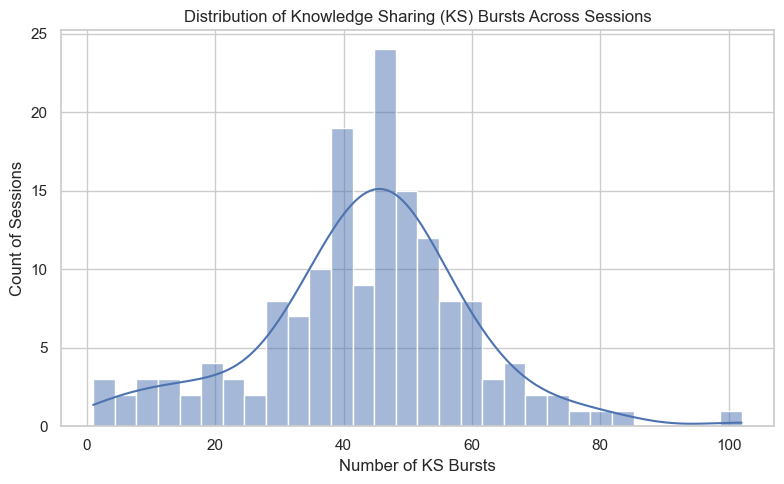

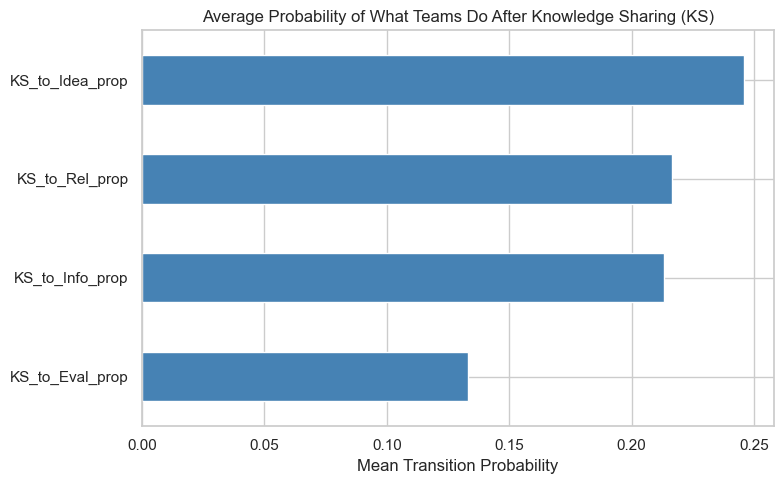

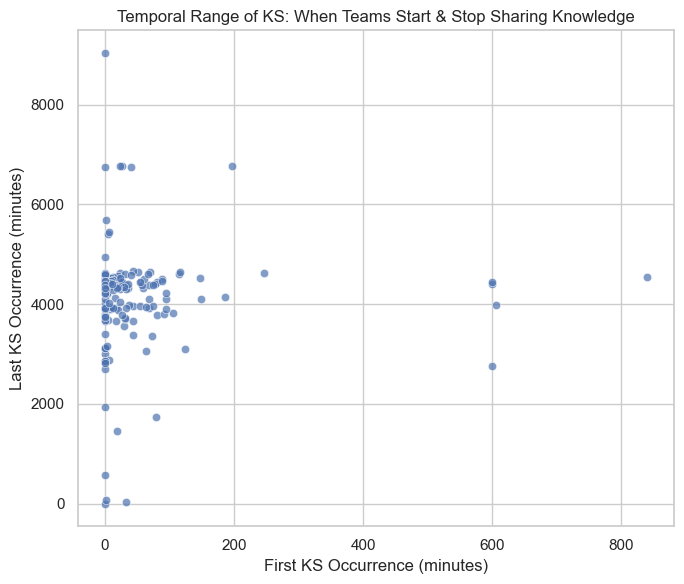

In [ ]:
# ============================================================
# VISUALIZATIONS FOR SLIDES – KS SEQUENCE FEATURES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure seaborn theme
sns.set(style="whitegrid")

# ------------------------------------------------------------
# 1) Distribution of KS bursts
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df_full["KS_bursts"], bins=30, kde=True)
plt.title("Distribution of Knowledge Sharing (KS) Bursts Across Sessions")
plt.xlabel("Number of KS Bursts")
plt.ylabel("Count of Sessions")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Transition probabilities out of KS
# ------------------------------------------------------------
ks_trans_cols = [
    "KS_to_Idea_prop",
    "KS_to_Rel_prop",
    "KS_to_Info_prop",
    "KS_to_Eval_prop",
]

plt.figure(figsize=(8, 5))
df_full[ks_trans_cols].mean().sort_values().plot(kind="barh", color="steelblue")
plt.title("Average Probability of What Teams Do After Knowledge Sharing (KS)")
plt.xlabel("Mean Transition Probability")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) Temporal span of KS (first vs last time)
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_full,
    x="KS_first_time", 
    y="KS_last_time",
    alpha=0.7
)
plt.title("Temporal Range of KS: When Teams Start & Stop Sharing Knowledge")
plt.xlabel("First KS Occurrence (minutes)")
plt.ylabel("Last KS Occurrence (minutes)")
plt.tight_layout()
plt.show()

In [ ]:
import os, json
import pandas as pd
from glob import glob

# ============================================================
# EXTRACT SUCCESS LABELS FROM ALL *_session_outcomes.json FILES
# ============================================================

success_rows = []

# Look ONLY in your main data directory (NOT v1-data duplicates)
BASE = "/Users/maxchalekson/Desktop/gemini_data_analysis/data"
pattern = os.path.join(BASE, "**", "*session_outcomes.json")

json_files = glob(pattern, recursive=True)

print("Found outcome JSONs (filtered):")
clean_json_files = []

for f in json_files:
    # Skip v1-data duplicates
    if "/v1-data/" in f:
        continue
    clean_json_files.append(f)
    print(" -", f)

print(f"\nUsing {len(clean_json_files)} cleaned outcome JSON files.\n")

# --------------------------
# Parse each JSON outcome file
# --------------------------
for path in clean_json_files:
    with open(path, "r") as f:
        data = json.load(f)

    for session_id, session_info in data.items():
        
        # Skip non-session keys
        if not isinstance(session_id, str):
            continue
        
        # Skip metadata keys
        if session_id in ["missing_names", "people_not_in_any_team"]:
            continue
        
        # Skip malformed keys
        if "_" not in session_id or session_id.count("_") < 3:
            continue
        
        # -----------------------
        # Extract funded info
        # -----------------------
        teams = session_info.get("teams", {})
        if len(teams) == 0:
            funded_any = 0
            n_teams = 0
            n_funded = 0
        else:
            statuses = [t.get("funded_status", 0) for t in teams.values()]
            n_funded = sum(int(x) for x in statuses)
            funded_any = 1 if n_funded > 0 else 0
            n_teams = len(statuses)

        # -----------------------
        # Extract conference name
        # -----------------------

        parts = session_id.split("_")  # e.g. ["2021","11","05","NES","S1"]

        # Handle SLU/ABI (may be nested differently)
        # Normal: YYYY_MM_DD_NES_S1  -> conference = "2021NES"
        # SLU:   2021_11_03_SLU_S1  -> conference = "2021SLU"

        try:
            year = parts[0]
            conf = parts[3]  # NES / ABI / MND / MZT etc.
        except:
            continue

        conference = f"{year}{conf}"

        success_rows.append({
            "conference": conference,
            "session": session_id,
            "n_teams": n_teams,
            "n_funded": n_funded,
            "funded_any": funded_any
        })

# Convert to DataFrame
df_success_json = pd.DataFrame(success_rows)

print("\nExtracted success table:")
print(df_success_json.head())
print("\nValue counts of funded_any:")
print(df_success_json["funded_any"].value_counts())

Found outcome JSONs (filtered):
 - /Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json
 - /Users/maxchalekson/Desktop/gemini_data_analysis/data/2021SLU/2021SLU_session_outcomes.json
 - /Users/maxchalekson/Desktop/gemini_data_analysis/data/2022MND/2022MND_session_outcomes.json
 - /Users/maxchalekson/Desktop/gemini_data_analysis/data/2020NES/2020NES_session_outcomes.json
 - /Users/maxchalekson/Desktop/gemini_data_analysis/data/2021CMC/2021CMC_session_outcomes.json
 - /Users/maxchalekson/Desktop/gemini_data_analysis/data/2021MND/2021MND_session_outcomes.json
 - /Users/maxchalekson/Desktop/gemini_data_analysis/data/2021MZT/2021MZT_session_outcomes.json
 - /Users/maxchalekson/Desktop/gemini_data_analysis/data/2021NES/2021NES_session_outcomes.json

Using 8 cleaned outcome JSON files.


Extracted success table:
  conference             session  n_teams  n_funded  funded_any
0    2021ABI   2021_05_20_ABI_S5        1         0           0
1    2021ABI   2

In [ ]:
# ============================================================
# REBUILD df_full FROM SCRATCH
# ============================================================

# Step 1 — Build df_events  (already done earlier)
# Step 2 — Build df_session_features (you already did)
# Step 3 — Build KS sequence features (done)
# Step 4 — Build KS couplets (done)

# ------------------------------------------------------------
# Create df_full = session_features + KS sequence + KS couplets
# ------------------------------------------------------------

df_full = (
    df_session_features
    .merge(ks_seq_features, on=["conference","session"], how="left")
    .merge(ks_couplets, on=["conference","session"], how="left")
)

print("df_full rebuilt, shape =", df_full.shape)
print(df_full.columns.tolist())

# ============================================================
# MERGE SUCCESS LABELS INTO df_full
# ============================================================

df_full = df_full.merge(
    df_success_json,
    on=["conference", "session"],
    how="left"
)

df_full["success_flag"] = df_full["funded_any"].fillna(0).astype(int)

print("Success flag counts:")
print(df_full["success_flag"].value_counts())

df_full[["conference","session","funded_any","success_flag"]].head()

df_full rebuilt, shape = (157, 26)
['conference', 'session', 'n_utterances', 'n_speakers', 'max_time', 'Beginning', 'Middle', 'End', 'Idea_Management', 'Information_Seeking', 'Knowledge_Sharing', 'Evaluation_Practices', 'Relational_Climate', 'Participation_Dynamics', 'Coordination_and_Decision_Practices', 'Integration_Practices', 'KS_bursts', 'KS_burst_mean', 'KS_transition_starts', 'KS_first_time', 'KS_last_time', 'KS_to_Rel_prop', 'KS_to_Idea_prop', 'KS_to_Eval_prop', 'KS_to_Info_prop', 'total_KS']
Success flag counts:
success_flag
0    89
1    68
Name: count, dtype: int64


,conference,session,funded_any,success_flag
0,2020NES,2020_11_05_NES_S1,0.0,0
1,2020NES,2020_11_05_NES_S2,0.0,0
2,2020NES,2020_11_05_NES_S3,1.0,1
3,2020NES,2020_11_05_NES_S4,1.0,1
4,2020NES,2020_11_05_NES_S5,1.0,1


In [ ]:
compare_cols = [
    "KS_bursts",
    "KS_burst_mean",
    "KS_transition_starts",
    "KS_first_time",
    "KS_last_time",
    "KS_to_Idea_prop",
    "KS_to_Rel_prop",
    "KS_to_Info_prop",
    "KS_to_Eval_prop"
]

group_means = df_full.groupby("success_flag")[compare_cols].mean().T
group_means.columns = ["Low Success", "High Success"]
group_means["Diff (High-Low)"] = group_means["High Success"] - group_means["Low Success"]

print(group_means.round(3))

                      Low Success  High Success  Diff (High-Low)
KS_bursts                  42.416        44.559            2.143
KS_burst_mean               1.749         1.725           -0.024
KS_transition_starts       42.056        44.235            2.179
KS_first_time              47.730        53.206            5.476
KS_last_time             3914.629      4316.824          402.194
KS_to_Idea_prop             0.235         0.260            0.026
KS_to_Rel_prop              0.198         0.240            0.042
KS_to_Info_prop             0.206         0.223            0.017
KS_to_Eval_prop             0.129         0.138            0.008


### visualization for all of this

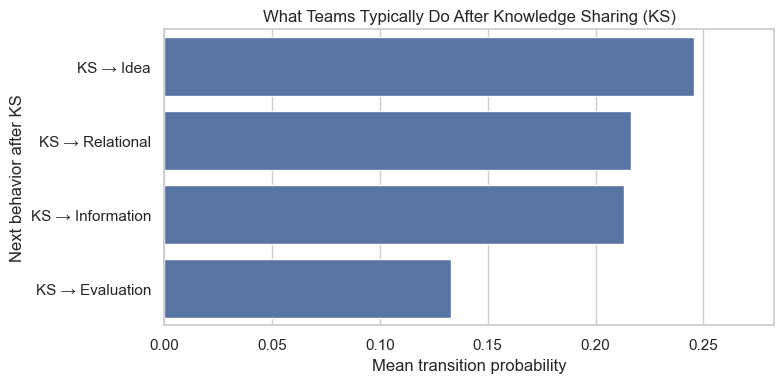

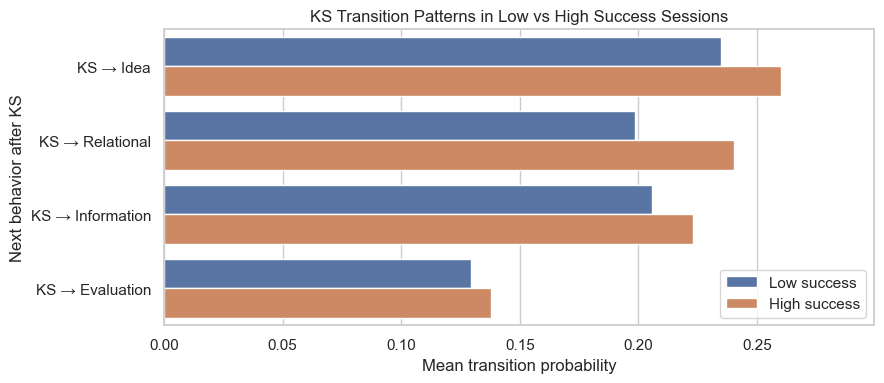

In [ ]:
# ============================================================
# VISUALIZATION: What do teams do after Knowledge Sharing?
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure these are the right columns in df_full
ks_trans_cols = [
    "KS_to_Idea_prop",
    "KS_to_Rel_prop",
    "KS_to_Info_prop",
    "KS_to_Eval_prop",
]

# Human-friendly labels for the y-axis
nice_labels = {
    "KS_to_Idea_prop": "KS → Idea",
    "KS_to_Rel_prop": "KS → Relational",
    "KS_to_Info_prop": "KS → Information",
    "KS_to_Eval_prop": "KS → Evaluation",
}

# ------------------------------
# Plot 1: Overall mean transitions
# ------------------------------
means = df_full[ks_trans_cols].mean().rename(index=nice_labels)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=means.values,
    y=means.index,
)
plt.xlabel("Mean transition probability")
plt.ylabel("Next behavior after KS")
plt.title("What Teams Typically Do After Knowledge Sharing (KS)")
plt.xlim(0, max(means.values) * 1.15)  # a bit of right padding
plt.tight_layout()
plt.show()

# ============================================================
# OPTIONAL: Plot 2 – Low vs High Success comparison
# (requires df_full['success_flag'] already created)
# ============================================================

if "success_flag" in df_full.columns:
    group_means = (
        df_full.groupby("success_flag")[ks_trans_cols]
        .mean()
        .rename(columns=nice_labels)
        .T
    )
    # Rename columns: 0 -> Low Success, 1 -> High Success
    group_means.columns = ["Low success", "High success"]

    # Convert to long format for seaborn
    plot_df = (
        group_means
        .reset_index()
        .melt(id_vars="index",
              value_vars=["Low success", "High success"],
              var_name="Success group",
              value_name="Mean transition probability")
        .rename(columns={"index": "Next behavior after KS"})
    )

    plt.figure(figsize=(9, 4))
    sns.barplot(
        data=plot_df,
        x="Mean transition probability",
        y="Next behavior after KS",
        hue="Success group",
    )
    plt.title("KS Transition Patterns in Low vs High Success Sessions")
    plt.xlabel("Mean transition probability")
    plt.ylabel("Next behavior after KS")
    plt.xlim(0, plot_df["Mean transition probability"].max() * 1.15)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()
else:
    print("No 'success_flag' in df_full — skipping Low vs High success plot.")

# 01.07.2026 Implementation

In [9]:
# =========================
# Linkography-style "code function by temporal position + neighbors"
# Works across ALL session JSONs in: .../data/<conf>/session_data/*.json
# Handles 10-minute timer resets by unwrapping times.
# =========================

import os
import json
import glob
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# ---------- CONFIG ----------
ROOT = "/Users/maxchalekson/Desktop/gemini_data_analysis/data"  # <-- change if needed
GLOB_PATTERN = os.path.join(ROOT, "*", "session_data", "*.json")

SCORE_THRESHOLD = 1          # include annotation code if score >= this
WRAP_SECONDS = 10 * 60       # timer resets every 10 minutes
WRAP_TOL = 30                # seconds tolerance to detect wrap

FOCAL_CODE = "Knowledge Sharing"     # code you want the context analysis for
TOPK = 8                             # how many neighbor codes to show per third


# ---------- HELPERS ----------
def _parse_mmss(s: str):
    """Parse 'MM:SS' or 'HH:MM:SS' into seconds. Returns None if invalid."""
    if s is None:
        return None
    s = str(s).strip()
    if not s:
        return None

    # allow 'M:SS', 'MM:SS', 'H:MM:SS'
    parts = s.split(":")
    if len(parts) == 2:
        m, sec = parts
        if not (m.isdigit() and sec.isdigit()):
            return None
        return int(m) * 60 + int(sec)
    if len(parts) == 3:
        h, m, sec = parts
        if not (h.isdigit() and m.isdigit() and sec.isdigit()):
            return None
        return int(h) * 3600 + int(m) * 60 + int(sec)

    return None


def _extract_start_end_seconds(item: dict):
    """
    Extract start/end seconds from one utterance dict.
    Supports:
      - start_time/end_time (e.g., '09:39')
      - timestamp 'MM:SS-MM:SS'
    Returns (start_sec, end_sec) possibly None.
    """
    st = None
    en = None

    if "start_time" in item and "end_time" in item:
        st = _parse_mmss(item.get("start_time"))
        en = _parse_mmss(item.get("end_time"))

    if (st is None or en is None) and isinstance(item.get("timestamp"), str):
        # e.g., '00:00-01:34'
        ts = item["timestamp"].strip()
        m = re.match(r"^\s*([0-9:]+)\s*-\s*([0-9:]+)\s*$", ts)
        if m:
            st2 = _parse_mmss(m.group(1))
            en2 = _parse_mmss(m.group(2))
            st = st if st is not None else st2
            en = en if en is not None else en2

    return st, en


def _unwrap_times(st_list, en_list, wrap_seconds=WRAP_SECONDS, tol=WRAP_TOL):
    """
    Unwrap a sequence of start/end times that reset every wrap_seconds.
    Strategy:
      - iterate in order; whenever start time drops "a lot", add wrap_seconds to offset
      - also fix end < start within utterance by adding wrap_seconds
    """
    offset = 0
    last_st = None
    out_st = []
    out_en = []

    for st, en in zip(st_list, en_list):
        if st is None:
            out_st.append(None)
            out_en.append(None if en is None else en + offset)
            continue

        if last_st is not None and st + tol < last_st:
            offset += wrap_seconds

        st_u = st + offset

        if en is None:
            en_u = None
        else:
            en_u = en + offset
            # if end appears to be after reset relative to start, lift it
            if en_u + tol < st_u:
                en_u += wrap_seconds

        out_st.append(st_u)
        out_en.append(en_u)
        last_st = st

    return out_st, out_en


def _third_from_time(t, tmax):
    if t is None or tmax is None or tmax <= 0:
        return None
    frac = t / tmax
    if frac <= 1/3:
        return "beginning"
    elif frac <= 2/3:
        return "middle"
    else:
        return "end"


def _extract_codes(item: dict, score_threshold=SCORE_THRESHOLD):
    """
    Pull codes from item['annotations'] which looks like:
      {'Knowledge Sharing': {'score': 2, ...}, ...}
    """
    ann = item.get("annotations", {})
    codes = []
    if isinstance(ann, dict):
        for code, payload in ann.items():
            if isinstance(payload, dict):
                sc = payload.get("score", None)
                if sc is not None and sc >= score_threshold:
                    codes.append(code)
    return codes


# ---------- LOAD ALL SESSIONS ----------
paths = sorted(glob.glob(GLOB_PATTERN))
print(f"Found {len(paths)} session JSONs under: {GLOB_PATTERN}")

rows = []
skipped = 0

for fp in paths:
    try:
        with open(fp, "r") as f:
            obj = json.load(f)
    except Exception as e:
        print(f"[WARN] Failed reading {fp}: {e}")
        skipped += 1
        continue

    all_data = obj.get("all_data", None)
    if not isinstance(all_data, list) or len(all_data) == 0:
        print(f"[WARN] No all_data list in {fp}; skipping.")
        skipped += 1
        continue

    # extract raw start/end in sequence order
    st_raw = []
    en_raw = []
    for item in all_data:
        st, en = _extract_start_end_seconds(item)
        st_raw.append(st)
        en_raw.append(en)

    # If absolutely none of the utterances have parsable times, still proceed using 'when' (if present)
    has_any_time = any(x is not None for x in st_raw)
    if has_any_time:
        st_abs, en_abs = _unwrap_times(st_raw, en_raw)
        tmax = max([t for t in st_abs if t is not None] + [0])
    else:
        st_abs = [None] * len(all_data)
        en_abs = [None] * len(all_data)
        tmax = None

    # session id from filename
    session_id = os.path.splitext(os.path.basename(fp))[0]

    for i, item in enumerate(all_data):
        codes = _extract_codes(item)

        # third: prefer explicit 'when' if present, else infer from time
        third = item.get("when", None)
        if third is None:
            third = _third_from_time(st_abs[i], tmax)

        rows.append({
            "session_id": session_id,
            "path": fp,
            "idx": i,
            "t_abs_start": st_abs[i],
            "t_abs_end": en_abs[i],
            "third": third,
            "speaker": item.get("speaker", None),
            "codes": codes,
            "transcript": item.get("transcript", None),
        })

df = pd.DataFrame(rows)
print(f"Built utterance-level df: {df.shape[0]} rows from {len(df['session_id'].unique())} sessions. Skipped files: {skipped}")

# basic sanity
print(df[['third']].value_counts(dropna=False).head(10))


# ---------- CONTEXT / FUNCTION ANALYSIS ----------
def compute_code_contexts(df, focal_code=FOCAL_CODE):
    """
    For each occurrence of focal_code, look at immediate previous and next utterance codes.
    Split by temporal third.
    Returns dict: third -> {'prev': Counter, 'next': Counter, 'n': int}
    """
    out = {t: {"prev": Counter(), "next": Counter(), "n": 0} for t in ["beginning", "middle", "end", None]}

    # process session-by-session to respect adjacency
    for sid, g in df.sort_values(["session_id", "idx"]).groupby("session_id"):
        g = g.reset_index(drop=True)
        for i in range(len(g)):
            codes_i = g.at[i, "codes"] or []
            if focal_code not in codes_i:
                continue

            third = g.at[i, "third"]
            out.setdefault(third, {"prev": Counter(), "next": Counter(), "n": 0})
            out[third]["n"] += 1

            # previous
            if i - 1 >= 0:
                prev_codes = g.at[i - 1, "codes"] or []
                out[third]["prev"].update(prev_codes)

            # next
            if i + 1 < len(g):
                next_codes = g.at[i + 1, "codes"] or []
                out[third]["next"].update(next_codes)

    return out


def pretty_top(counter: Counter, k=TOPK):
    return pd.DataFrame(counter.most_common(k), columns=["code", "count"])


contexts = compute_code_contexts(df, focal_code=FOCAL_CODE)

print("\n" + "="*90)
print(f"CONTEXTS FOR: {FOCAL_CODE}")
print("="*90)

for third in ["beginning", "middle", "end"]:
    block = contexts.get(third, {"prev": Counter(), "next": Counter(), "n": 0})
    n = block["n"]
    print(f"\n--- {third.upper()} (n={n} occurrences of '{FOCAL_CODE}') ---")

    print("\nTop PREVIOUS-utterance codes:")
    display(pretty_top(block["prev"], TOPK))

    print("\nTop NEXT-utterance codes:")
    display(pretty_top(block["next"], TOPK))


# ---------- OPTIONAL: TEMPORAL ROLE PATTERN SUMMARY (dominant codes by third) ----------
def dominant_codes_by_third(df):
    agg = defaultdict(Counter)
    for _, r in df.iterrows():
        third = r["third"]
        codes = r["codes"] or []
        agg[third].update(codes)
    return {k: v for k, v in agg.items()}

dom = dominant_codes_by_third(df)

print("\n" + "="*90)
print("DOMINANT CODES BY TEMPORAL THIRD (utterance-level frequency)")
print("="*90)
for third in ["beginning", "middle", "end"]:
    print(f"\n--- {third.upper()} ---")
    display(pretty_top(dom.get(third, Counter()), TOPK))

Found 157 session JSONs under: /Users/maxchalekson/Desktop/gemini_data_analysis/data/*/session_data/*.json
Built utterance-level df: 30558 rows from 157 sessions. Skipped files: 0
third    
end          11675
beginning    10044
middle        8839
Name: count, dtype: int64

CONTEXTS FOR: Knowledge Sharing

--- BEGINNING (n=3986 occurrences of 'Knowledge Sharing') ---

Top PREVIOUS-utterance codes:


,code,count
0,Knowledge Sharing,1541
1,Participation Dynamics,1049
2,Relational Climate,1028
3,Information Seeking,830
4,Coordination and Decision Practices,800
5,Idea Management,691
6,Evaluation Practices,283
7,Integration Practices,88



Top NEXT-utterance codes:


,code,count
0,Knowledge Sharing,1586
1,Relational Climate,1134
2,Participation Dynamics,812
3,Idea Management,748
4,Information Seeking,747
5,Coordination and Decision Practices,715
6,Evaluation Practices,374
7,Integration Practices,117



--- MIDDLE (n=3918 occurrences of 'Knowledge Sharing') ---

Top PREVIOUS-utterance codes:


...

,code,count
0,Knowledge Sharing,3986
1,Relational Climate,2593
2,Coordination and Decision Practices,2257
3,Information Seeking,1674
4,Idea Management,1661
5,Participation Dynamics,1648
6,Evaluation Practices,685
7,Integration Practices,220



--- MIDDLE ---


,code,count
0,Knowledge Sharing,3918
1,Idea Management,2417
2,Information Seeking,1885
3,Relational Climate,1413
4,Evaluation Practices,1319
5,Participation Dynamics,673
6,Coordination and Decision Practices,654
7,Integration Practices,419



--- END ---


,code,count
0,Knowledge Sharing,3868
1,Idea Management,2448
2,Relational Climate,2383
3,Coordination and Decision Practices,2288
4,Information Seeking,2100
5,Evaluation Practices,1242
6,Participation Dynamics,799
7,Integration Practices,688


In [10]:
from collections import Counter
import pandas as pd

FOCAL_CODES = [
    "Knowledge Sharing",
    "Information Seeking",
    "Evaluation Practices",
    "Integration Practices",
    "Coordination and Decision Practices",
]

# You can tweak these sets to match your codebook names exactly
CLOSURE_CODES = {"Integration Practices", "Coordination and Decision Practices"}
CRITIQUE_CODES = {"Evaluation Practices"}
SEED_CODES = {"Information Seeking", "Knowledge Sharing"}

def counter_to_pct_df(cntr: Counter, topk=10):
    total = sum(cntr.values()) or 1
    dfp = pd.DataFrame(cntr.most_common(topk), columns=["code", "count"])
    dfp["pct"] = dfp["count"] / total
    return dfp

def role_signature(context_block):
    """
    Compute a few interpretable conditional indices from prev/next counters.
    These are *examples* that map to your narrative.
    """
    prev = context_block["prev"]
    nxt  = context_block["next"]
    n_prev = sum(prev.values()) or 1
    n_next = sum(nxt.values()) or 1

    def pct_in(counter, keys, denom):
        return sum(counter[k] for k in keys if k in counter) / denom

    return {
        "Prev critique (Evaluation)": pct_in(prev, CRITIQUE_CODES, n_prev),
        "Next closure (Integration/Decision)": pct_in(nxt, CLOSURE_CODES, n_next),
        "Prev seed (InfoSeek/KS)": pct_in(prev, SEED_CODES, n_prev),
    }

# contexts was computed in your previous run; reuse it by recomputing per focal code:
def compute_code_contexts(df, focal_code):
    out = {t: {"prev": Counter(), "next": Counter(), "n": 0} for t in ["beginning", "middle", "end"]}

    for sid, g in df.sort_values(["session_id", "idx"]).groupby("session_id"):
        g = g.reset_index(drop=True)
        for i in range(len(g)):
            codes_i = g.at[i, "codes"] or []
            if focal_code not in codes_i:
                continue

            third = g.at[i, "third"]
            if third not in out:
                continue

            out[third]["n"] += 1

            if i > 0:
                out[third]["prev"].update(g.at[i-1, "codes"] or [])
            if i < len(g)-1:
                out[third]["next"].update(g.at[i+1, "codes"] or [])

    return out

# ---- RUN AND PRINT SLIDE-READY OUTPUT ----
for focal in FOCAL_CODES:
    ctx = compute_code_contexts(df, focal)

    print("\n" + "="*100)
    print(f"FOCAL CODE: {focal}")
    print("="*100)

    for third in ["beginning", "middle", "end"]:
        block = ctx[third]
        print(f"\n--- {third.upper()} (n={block['n']} utterances containing '{focal}') ---")

        prev_df = counter_to_pct_df(block["prev"], topk=8)
        next_df = counter_to_pct_df(block["next"], topk=8)

        sig = role_signature(block)

        print("\nTop PREVIOUS codes (with %):")
        display(prev_df)

        print("\nTop NEXT codes (with %):")
        display(next_df)

        print("\nRole-signature indices (conditional):")
        print({k: round(v, 3) for k, v in sig.items()})


FOCAL CODE: Knowledge Sharing

--- BEGINNING (n=3986 utterances containing 'Knowledge Sharing') ---

Top PREVIOUS codes (with %):


,code,count,pct
0,Knowledge Sharing,1541,0.244216
1,Participation Dynamics,1049,0.166244
2,Relational Climate,1028,0.162916
3,Information Seeking,830,0.131537
4,Coordination and Decision Practices,800,0.126783
5,Idea Management,691,0.109509
6,Evaluation Practices,283,0.044849
7,Integration Practices,88,0.013946



Top NEXT codes (with %):


,code,count,pct
0,Knowledge Sharing,1586,0.254452
1,Relational Climate,1134,0.181935
2,Participation Dynamics,812,0.130274
3,Idea Management,748,0.120006
4,Information Seeking,747,0.119846
5,Coordination and Decision Practices,715,0.114712
6,Evaluation Practices,374,0.060003
7,Integration Practices,117,0.018771



Role-signature indices (conditional):
{'Prev critique (Evaluation)': 0.045, 'Next closure (Integration/Decision)': 0.133, 'Prev seed (InfoSeek/KS)': 0.376}

--- MIDDLE (n=3918 utterances containing 'Knowledge Sharing') ---

Top PREVIOUS codes (with %):


...


Role-signature indices (conditional):
{'Prev critique (Evaluation)': 0.093, 'Next closure (Integration/Decision)': 0.226, 'Prev seed (InfoSeek/KS)': 0.331}

--- END (n=2288 utterances containing 'Coordination and Decision Practices') ---

Top PREVIOUS codes (with %):


,code,count,pct
0,Coordination and Decision Practices,961,0.307323
1,Knowledge Sharing,561,0.179405
2,Relational Climate,494,0.157979
3,Idea Management,312,0.099776
4,Information Seeking,306,0.097857
5,Participation Dynamics,180,0.057563
6,Evaluation Practices,176,0.056284
7,Integration Practices,137,0.043812



Top NEXT codes (with %):


,code,count,pct
0,Coordination and Decision Practices,956,0.307890
1,Relational Climate,511,0.164573
2,Knowledge Sharing,503,0.161997
3,Information Seeking,353,0.113688
4,Idea Management,296,0.095330
5,Integration Practices,177,0.057005
6,Participation Dynamics,173,0.055717
7,Evaluation Practices,136,0.043800



Role-signature indices (conditional):
{'Prev critique (Evaluation)': 0.056, 'Next closure (Integration/Decision)': 0.365, 'Prev seed (InfoSeek/KS)': 0.277}


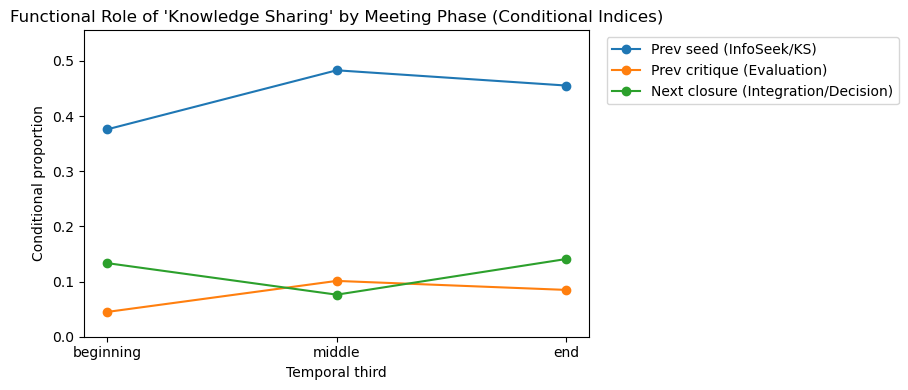

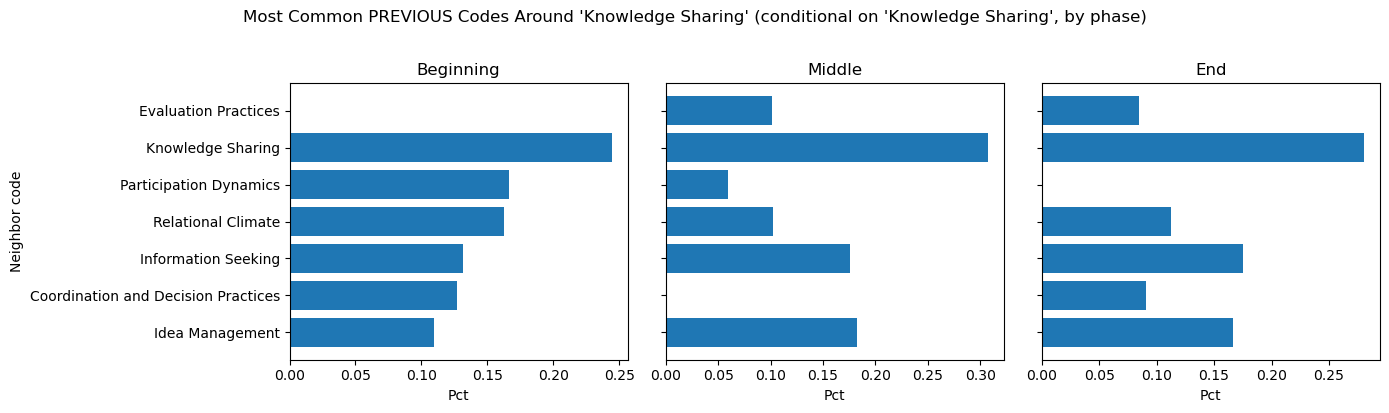

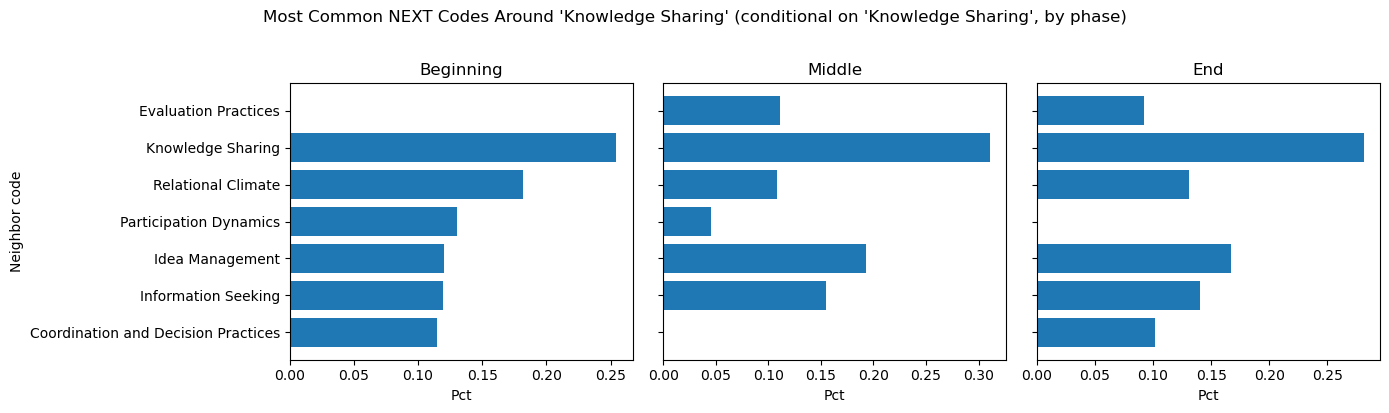

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

    """
    
Do not use the first graph generated from this plot 


    """

FOCAL = "Knowledge Sharing"
TOPK = 6  # number of neighbor codes to show per PREV/NEXT

ctx = compute_code_contexts(df, FOCAL)

# ---------- GRAPH 1: Role-signature indices across thirds ----------
thirds = ["beginning", "middle", "end"]
sig_rows = []
for th in thirds:
    sig = role_signature(ctx[th])
    sig_rows.append({"third": th, **sig})

sig_df = pd.DataFrame(sig_rows)

plt.figure(figsize=(9, 4))
for col in ["Prev seed (InfoSeek/KS)", "Prev critique (Evaluation)", "Next closure (Integration/Decision)"]:
    plt.plot(sig_df["third"], sig_df[col], marker="o", label=col)
plt.title(f"Functional Role of '{FOCAL}' by Meeting Phase (Conditional Indices)")
plt.xlabel("Temporal third")
plt.ylabel("Conditional proportion")
plt.ylim(0, max(0.05, sig_df.drop(columns=["third"]).to_numpy().max() * 1.15))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- GRAPH 2: Top neighbors (PREV and NEXT) per third ----------
# Build dataframes of top neighbors for plotting
plot_rows_prev = []
plot_rows_next = []

for th in thirds:
    prev_df = counter_to_pct_df(ctx[th]["prev"], topk=TOPK)
    next_df = counter_to_pct_df(ctx[th]["next"], topk=TOPK)

    for _, r in prev_df.iterrows():
        plot_rows_prev.append({"third": th, "neighbor_code": r["code"], "pct": r["pct"]})
    for _, r in next_df.iterrows():
        plot_rows_next.append({"third": th, "neighbor_code": r["code"], "pct": r["pct"]})

prev_plot = pd.DataFrame(plot_rows_prev)
next_plot = pd.DataFrame(plot_rows_next)

def bar_panel(plot_df, title):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, th in zip(axes, thirds):
        sub = plot_df[plot_df["third"] == th].sort_values("pct", ascending=True)
        ax.barh(sub["neighbor_code"], sub["pct"])
        ax.set_title(th.capitalize())
        ax.set_xlabel("Pct")
    axes[0].set_ylabel("Neighbor code")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

bar_panel(prev_plot, f"Most Common PREVIOUS Codes Around '{FOCAL}' (conditional on '{FOCAL}', by phase)")
bar_panel(next_plot, f"Most Common NEXT Codes Around '{FOCAL}' (conditional on '{FOCAL}', by phase)")

## 01/08/2026 work 

refer to chatgpt code chunk

also need to adjust this into (or find the data when i do the initial implementation when i get to the lab)

8) HOOK FOR OUTCOMES (proposal success) WITHOUT FAKE PRETENDING
    If you later have session-level outcomes (team formed, funded, etc.):
    - make a df_outcomes with columns: session_id, any_team, any_funded, facilitator_present, etc.
    - aggregate df → session features, then merge.

In [6]:
import json, glob, re
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
from IPython.display import display

# ======================================================================================
# CONFIG
# ======================================================================================

DATA_GLOB = "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/*/session_data/*.json"

PHASES = ["beginning", "middle", "end"]

FOCAL_CODES = [
    "Knowledge Sharing",
    "Information Seeking",
    "Evaluation Practices",
    "Integration Practices",
    "Coordination and Decision Practices",
    "Participation Dynamics",
    "Relational Climate",
    "Idea Management",
]

SEED = {"Information Seeking", "Knowledge Sharing"}
CRITIQUE = {"Evaluation Practices"}
SYNTHESIS = {"Integration Practices"}
CLOSURE = {"Coordination and Decision Practices"}
IDEA_MGMT = {"Idea Management"}

FACILITATOR_LABELS = {"Discussion Facilitator", "Facilitator", "discussion facilitator"}

TOPK = 12
EXAMPLE_WINDOW = 1
N_EXAMPLES_PER_GROUP = 2
EXAMPLES_ONLY_FOR_SLICE = "overall"

# ======================================================================================
# HELPERS
# ======================================================================================

_ts_pat = re.compile(r"^\s*(\d{1,2}:\d{2})(?::\d{2})?\s*$")

def mmss_to_sec(s: str):
    """Parse 'MM:SS' or 'HH:MM:SS' into seconds."""
    if not isinstance(s, str):
        return None
    s = s.strip()
    if not s:
        return None
    parts = s.split(":")
    try:
        if len(parts) == 2:
            m, sec = int(parts[0]), int(parts[1])
            return 60*m + sec
        if len(parts) == 3:
            h, m, sec = int(parts[0]), int(parts[1]), int(parts[2])
            return 3600*h + 60*m + sec
    except:
        return None
    return None

def parse_timestamp_range(ts: str):
    """
    Parse 'MM:SS-MM:SS' (or HH:MM:SS variants) -> (start_sec, end_sec)
    """
    if not isinstance(ts, str):
        return (None, None)
    ts = ts.strip()
    if "-" not in ts:
        return (None, None)
    a, b = ts.split("-", 1)
    return (mmss_to_sec(a), mmss_to_sec(b))

def safe_get_text(utt: dict):
    for k in ["transcript", "utterance", "text", "content", "sentence"]:
        v = utt.get(k)
        if isinstance(v, str) and v.strip():
            return v.strip()
    return None

def extract_utterances(loaded_json):
    if isinstance(loaded_json, list):
        return loaded_json
    if isinstance(loaded_json, dict):
        if "all_data" in loaded_json and isinstance(loaded_json["all_data"], list):
            return loaded_json["all_data"]
        if "data" in loaded_json and isinstance(loaded_json["data"], list):
            return loaded_json["data"]
    return []

def role_bucket(role_str):
    if role_str is None:
        return "non-facilitator"
    return "facilitator" if role_str in FACILITATOR_LABELS else "non-facilitator"

def infer_state_from_codes(codes):
    S = set(codes)
    if S & CLOSURE:
        return "Commitment/Closure"
    if S & SYNTHESIS:
        return "Synthesis"
    if S & CRITIQUE:
        return "Stress-testing"
    if S & SEED:
        return "Seeding"
    if S & IDEA_MGMT:
        return "Idea Development"
    if "Participation Dynamics" in S:
        return "Participation Structuring"
    if "Relational Climate" in S:
        return "Relational Support"
    return "Other"

def jensen_shannon(p, q, eps=1e-12):
    keys = set(p.keys()) | set(q.keys())
    P = np.array([p.get(k, 0.0) for k in keys], dtype=float) + eps
    Q = np.array([q.get(k, 0.0) for k in keys], dtype=float) + eps
    P /= P.sum()
    Q /= Q.sum()
    M = 0.5 * (P + Q)

    def kl(a, b):
        return float(np.sum(a * np.log(a / b)))

    return 0.5 * kl(P, M) + 0.5 * kl(Q, M)

def counter_to_prob(counter: Counter):
    tot = sum(counter.values())
    if tot == 0:
        return {}
    return {k: v / tot for k, v in counter.items()}

def assign_third_from_pos(pos01: float):
    if pos01 < 1/3:
        return "beginning"
    if pos01 < 2/3:
        return "middle"
    return "end"

# ======================================================================================
# 1) LOAD ALL SESSIONS → UTTERANCE-LEVEL DF (timestamp-derived thirds, reset-safe)
# ======================================================================================

rows = []
paths = sorted(glob.glob(DATA_GLOB))
if not paths:
    raise FileNotFoundError(f"No JSON files matched: {DATA_GLOB}")

bad_files = 0
skipped_no_times = 0

for path in paths:
    with open(path, "r") as f:
        loaded = json.load(f)

    utterances = extract_utterances(loaded)
    if not utterances:
        bad_files += 1
        continue

    session_id = path.split("/")[-1].replace(".json", "")

    # First pass: get raw start/end seconds for each utterance
    raw = []
    for idx, utt in enumerate(utterances):
        if not isinstance(utt, dict):
            continue

        ann = utt.get("annotations", {}) or {}
        if not isinstance(ann, dict) or not ann:
            continue

        # Prefer explicit start_time/end_time; else parse "timestamp"
        st = mmss_to_sec(utt.get("start_time")) if utt.get("start_time") else None
        en = mmss_to_sec(utt.get("end_time")) if utt.get("end_time") else None
        if st is None or en is None:
            st2, en2 = parse_timestamp_range(utt.get("timestamp"))
            st = st if st is not None else st2
            en = en if en is not None else en2

        raw.append((idx, utt, st, en))

    # If we genuinely have no usable times, fall back to existing "when" fields
    have_any_times = any(st is not None and en is not None for _,_,st,en in raw)

    if not have_any_times:
        # fallback: use the provided "when" if present
        skipped_no_times += 1
        for idx, utt, st, en in raw:
            ann = utt.get("annotations", {}) or {}
            codes = list(ann.keys())
            if not codes:
                continue

            third = utt.get("when")
            if third not in PHASES:
                any_meta = next(iter(ann.values()), {})
                if isinstance(any_meta, dict):
                    third = any_meta.get("when", None)
            if third not in PHASES:
                third = "unknown"

            rows.append({
                "session_id": session_id,
                "idx": idx,
                "speaker": utt.get("speaker"),
                "role_raw": utt.get("role"),
                "role": role_bucket(utt.get("role")),
                "third": third,
                "codes": codes,
                "text": safe_get_text(utt),
                "t_start": None,
                "t_end": None,
                "pos01": None,
            })
        continue

    # Second pass: make timeline monotonic per session (handles timer resets)
    # We assume utterances are in order already, but we still sort by idx.
    raw = sorted(raw, key=lambda x: x[0])

    offset = 0
    prev_end = None
    fixed = []

    for idx, utt, st, en in raw:
        ann = utt.get("annotations", {}) or {}
        codes = list(ann.keys())
        if not codes:
            continue

        if st is None or en is None:
            # if missing, just skip the timing but keep the row; we'll later mark third unknown
            fixed.append((idx, utt, None, None, codes))
            continue

        # If time goes backwards a lot, assume a reset and bump offset by 10 minutes (600s).
        # If your resets are a different size, change 600.
        if prev_end is not None and st + offset < prev_end - 30:
            offset += 600

        st_fix = st + offset
        en_fix = en + offset

        # if end < start after offset, force end >= start
        if en_fix < st_fix:
            en_fix = st_fix

        prev_end = en_fix
        fixed.append((idx, utt, st_fix, en_fix, codes))

    # Define session duration from max end
    ends = [en for _,_,_,en,_ in fixed if en is not None]
    session_end = max(ends) if ends else None
    if session_end is None or session_end <= 0:
        # shouldn't happen if have_any_times True, but guard anyway
        for idx, utt, st_fix, en_fix, codes in fixed:
            rows.append({
                "session_id": session_id,
                "idx": idx,
                "speaker": utt.get("speaker"),
                "role_raw": utt.get("role"),
                "role": role_bucket(utt.get("role")),
                "third": "unknown",
                "codes": codes,
                "text": safe_get_text(utt),
                "t_start": st_fix,
                "t_end": en_fix,
                "pos01": None,
            })
        continue

    for idx, utt, st_fix, en_fix, codes in fixed:
        if st_fix is None:
            third = "unknown"
            pos01 = None
        else:
            pos01 = st_fix / session_end
            third = assign_third_from_pos(pos01)

        rows.append({
            "session_id": session_id,
            "idx": idx,
            "speaker": utt.get("speaker"),
            "role_raw": utt.get("role"),
            "role": role_bucket(utt.get("role")),
            "third": third,
            "codes": codes,
            "text": safe_get_text(utt),
            "t_start": st_fix,
            "t_end": en_fix,
            "pos01": pos01,
        })

df = pd.DataFrame(rows).sort_values(["session_id", "idx"]).reset_index(drop=True)

print(f"Matched {len(paths)} session JSONs.")
print(f"Skipped {bad_files} files with unexpected structure (no utterance list found).")
print(f"Built utterance-level df: {len(df)} rows from {df.session_id.nunique()} sessions.")
print(f"Fallback-to-when used for sessions with no valid times: {skipped_no_times}")
print(df["third"].value_counts())

# ======================================================================================
# 2) IDEA STATES
# ======================================================================================

df["idea_state"] = df["codes"].apply(infer_state_from_codes)

print("\nIdea-state distribution (overall):")
print(df["idea_state"].value_counts().head(15))

# ======================================================================================
# 3) CONTEXT: prev/next codes around a focal code (multi-label aware)
# ======================================================================================

def compute_contexts(df_in, focal_code, phase=None, role=None):
    prev_all, next_all = Counter(), Counter()
    per_s_prev = defaultdict(Counter)
    per_s_next = defaultdict(Counter)
    n = 0

    sub = df_in
    if phase is not None:
        sub = sub[sub["third"] == phase]
    if role is not None:
        sub = sub[sub["role"] == role]

    for sid, g in sub.sort_values(["session_id", "idx"]).groupby("session_id"):
        g = g.reset_index(drop=True)
        for i in range(len(g)):
            if focal_code not in g.at[i, "codes"]:
                continue
            n += 1
            if i > 0:
                prev_codes = g.at[i-1, "codes"] or []
                prev_all.update(prev_codes)
                per_s_prev[sid].update(prev_codes)
            if i < len(g)-1:
                next_codes = g.at[i+1, "codes"] or []
                next_all.update(next_codes)
                per_s_next[sid].update(next_codes)

    return {
        "prev": prev_all, "next": next_all, "n": n,
        "per_session_prev": per_s_prev, "per_session_next": per_s_next
    }

def stability_report(per_session_counters):
    pooled = Counter()
    for c in per_session_counters.values():
        pooled.update(c)
    pooled_p = counter_to_prob(pooled)

    jsds = []
    for sid, c in per_session_counters.items():
        if sum(c.values()) < 5:
            continue
        p = counter_to_prob(c)
        jsds.append(jensen_shannon(pooled_p, p))

    return {
        "n_sessions_used": len(jsds),
        "mean_jsd": float(np.mean(jsds)) if jsds else np.nan,
        "median_jsd": float(np.median(jsds)) if jsds else np.nan,
    }

# ======================================================================================
# 4) BASELINE PROB + LIFT
# ======================================================================================

baseline_counts = Counter()
for codes in df["codes"]:
    baseline_counts.update(codes)
baseline_prob = counter_to_prob(baseline_counts)

def lift_rows(neighbor_counter: Counter, baseline_prob: dict, focal_code: str, slice_name: str, direction: str):
    tot = sum(neighbor_counter.values()) or 1
    out = []
    for code, c in neighbor_counter.items():
        p_neigh = c / tot
        p_base = baseline_prob.get(code, 1e-12)
        lift = p_neigh / p_base if p_base > 0 else np.inf
        out.append({
            "focal_code": focal_code,
            "slice": slice_name,
            "direction": direction,
            "neighbor_code": code,
            "neighbor_count": c,
            "neighbor_total": tot,
            "p_neighbor": p_neigh,
            "p_base": p_base,
            "lift": lift,
        })
    return out

# ======================================================================================
# 5) STABILITY TABLE (overall + phase + phase×role)
# ======================================================================================

df_phased = df[df["third"].isin(PHASES)].copy()

slice_specs = [("overall", dict())]
slice_specs += [(f"phase={ph}", dict(phase=ph)) for ph in PHASES]
slice_specs += [(f"phase={ph},role={rl}", dict(phase=ph, role=rl)) for ph in PHASES for rl in ["facilitator", "non-facilitator"]]

stability_rows = []
for focal in FOCAL_CODES:
    for slice_name, kwargs in slice_specs:
        ctx = compute_contexts(df_phased, focal, **kwargs)
        stab_prev = stability_report(ctx["per_session_prev"])
        stab_next = stability_report(ctx["per_session_next"])
        stability_rows.append({
            "focal_code": focal,
            "slice": slice_name,
            "n_focal": ctx["n"],
            "mean_jsd_prev": stab_prev["mean_jsd"],
            "mean_jsd_next": stab_next["mean_jsd"],
        })

stability_df = pd.DataFrame(stability_rows).sort_values(["focal_code", "slice"]).reset_index(drop=True)

print("\nSTABILITY SUMMARY (lower mean_jsd = more stable across sessions):")
display(stability_df)

# ======================================================================================
# 6) NEIGHBORS + LIFT TABLE (Top-K)
# ======================================================================================

all_neighbor_rows = []
for focal in FOCAL_CODES:
    for slice_name, kwargs in slice_specs:
        ctx = compute_contexts(df_phased, focal, **kwargs)
        all_neighbor_rows += lift_rows(ctx["prev"], baseline_prob, focal, slice_name, "prev")
        all_neighbor_rows += lift_rows(ctx["next"], baseline_prob, focal, slice_name, "next")

neighbors_lift_df = pd.DataFrame(all_neighbor_rows)
neighbors_lift_df = neighbors_lift_df[neighbors_lift_df["neighbor_code"] != neighbors_lift_df["focal_code"]].copy()

neighbors_topk_df = (
    neighbors_lift_df
    .groupby(["focal_code", "slice", "direction"], as_index=False, group_keys=False)
    .apply(lambda g: g.sort_values(["lift", "neighbor_count"], ascending=[False, False]).head(TOPK))
    .reset_index(drop=True)
    .sort_values(["slice", "focal_code", "direction", "lift", "neighbor_count"],
                 ascending=[True, True, True, False, False])
    .reset_index(drop=True)
)

print("\nCONDENSED TOP-K NEIGHBOR+LIFT TABLE:")
display(neighbors_topk_df)

# ======================================================================================
# 7) EXAMPLES TABLE (overall only)
# ======================================================================================

def window_string(g, focal_i, window=1):
    lo = max(0, focal_i - window)
    hi = min(len(g) - 1, focal_i + window)
    parts = []
    for j in range(lo, hi + 1):
        mark = " <-- FOCAL" if j == focal_i else ""
        txt = g.at[j, "text"] if isinstance(g.at[j, "text"], str) and g.at[j, "text"].strip() else "[no text]"
        parts.append(f"[{j}] {g.at[j,'speaker']} ({g.at[j,'role']},{g.at[j,'third']}): {g.at[j,'codes']} :: {txt}{mark}")
    return "\n".join(parts)

def find_examples(df_in, focal, neighbor_code, direction="next", n_examples=2, window=1):
    examples = []
    df_sorted = df_in.sort_values(["session_id", "idx"])

    for sid, g in df_sorted.groupby("session_id"):
        g = g.reset_index(drop=True)
        if len(g) < 2:
            continue

        for i in range(len(g)):
            if focal not in g.at[i, "codes"]:
                continue

            if direction == "next":
                if i >= len(g) - 1:
                    continue
                hit = neighbor_code in g.at[i + 1, "codes"]
            else:  # "prev"
                if i == 0:
                    continue
                hit = neighbor_code in g.at[i - 1, "codes"]

            if not hit:
                continue

            examples.append({
                "example_session_id": sid,
                "example_focal_idx": i,
                "example_window": window_string(g, i, window=window),
            })
            if len(examples) >= n_examples:
                return examples
    return examples

overall_top = neighbors_topk_df[neighbors_topk_df["slice"] == EXAMPLES_ONLY_FOR_SLICE].copy()

example_rows = []
for _, r in overall_top.iterrows():
    ex = find_examples(
        df_phased,
        focal=r["focal_code"],
        neighbor_code=r["neighbor_code"],
        direction=r["direction"],
        n_examples=N_EXAMPLES_PER_GROUP,
        window=EXAMPLE_WINDOW
    )
    if not ex:
        example_rows.append({**r.to_dict(), "example_session_id": None, "example_focal_idx": None, "example_window": None})
    else:
        for e in ex:
            example_rows.append({**r.to_dict(), **e})

examples_df = pd.DataFrame(example_rows)

print(f"\nEXAMPLES TABLE (slice == '{EXAMPLES_ONLY_FOR_SLICE}', up to {N_EXAMPLES_PER_GROUP} per group):")
display(examples_df.head(30))

print("\nDone. You now have:")
print("1) stability_df      -> stability across sessions (overall + phase + phase×role)")
print("2) neighbors_topk_df -> top neighbor transitions w/ lift (overall + phase + phase×role)")
print("3) examples_df       -> transcript windows for high-lift transitions (overall only)")

Matched 157 session JSONs.
Skipped 0 files with unexpected structure (no utterance list found).
Built utterance-level df: 30558 rows from 157 sessions.
Fallback-to-when used for sessions with no valid times: 0
third
end          11584
beginning    10080
middle        8894
Name: count, dtype: int64

Idea-state distribution (overall):
idea_state
Seeding                      12016
Commitment/Closure            5319
Relational Support            4292
Stress-testing                3369
Other                         2076
Participation Structuring     1357
Synthesis                     1132
Idea Development               997
Name: count, dtype: int64

STABILITY SUMMARY (lower mean_jsd = more stable across sessions):


,focal_code,slice,n_focal,mean_jsd_prev,mean_jsd_next
0,Coordination and Decision Practices,overall,5319,0.033371,0.031457
1,Coordination and Decision Practices,phase=beginning,2290,0.065696,0.060467
2,Coordination and Decision Practices,"phase=beginning,role=facilitator",1421,0.067772,0.058996
3,Coordination and Decision Practices,"phase=beginning,role=non-facilitator",869,0.118650,0.112262
4,Coordination and Decision Practices,phase=end,2341,0.068528,0.067776
...,...,...,...,...,...
75,Relational Climate,"phase=end,role=facilitator",903,0.114950,0.112951
76,Relational Climate,"phase=end,role=non-facilitator",2484,0.070365,0.080417
77,Relational Climate,phase=middle,2139,0.081478,0.084334
78,Relational Climate,"phase=middle,role=facilitator",546,0.134414,0.140805



CONDENSED TOP-K NEIGHBOR+LIFT TABLE:


/var/folders/wp/cn7__9416yj3c5_vcykys8hc0000gn/T/ipykernel_60716/517433897.py:444: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values(["lift", "neighbor_count"], ascending=[False, False]).head(TOPK))


,focal_code,slice,direction,neighbor_code,neighbor_count,neighbor_total,p_neighbor,p_base,lift
0,Coordination and Decision Practices,overall,next,Participation Dynamics,684,8497,0.080499,0.070651,1.139383
1,Coordination and Decision Practices,overall,next,Integration Practices,252,8497,0.029658,0.027742,1.069046
2,Coordination and Decision Practices,overall,next,Relational Climate,1576,8497,0.185477,0.180334,1.028523
3,Coordination and Decision Practices,overall,next,Information Seeking,862,8497,0.101448,0.116766,0.868813
4,Coordination and Decision Practices,overall,next,Knowledge Sharing,1577,8497,0.185595,0.242595,0.765040
...,...,...,...,...,...,...,...,...,...
1275,Relational Climate,"phase=middle,role=non-facilitator",prev,Information Seeking,287,2479,0.115772,0.116766,0.991494
1276,Relational Climate,"phase=middle,role=non-facilitator",prev,None,100,2479,0.040339,0.042379,0.951869
1277,Relational Climate,"phase=middle,role=non-facilitator",prev,Integration Practices,65,2479,0.026220,0.027742,0.945145
1278,Relational Climate,"phase=middle,role=non-facilitator",prev,Participation Dynamics,78,2479,0.031464,0.070651,0.445346



EXAMPLES TABLE (slice == 'overall', up to 2 per group):


,focal_code,slice,direction,neighbor_code,neighbor_count,neighbor_total,p_neighbor,p_base,lift,example_session_id,example_focal_idx,example_window
0,Coordination and Decision Practices,overall,next,Participation Dynamics,684,8497,0.080499,0.070651,1.139383,2020_11_05_NES_S1,5,"[4] Gary Moore (non-facilitator,beginning): ['..."
1,Coordination and Decision Practices,overall,next,Participation Dynamics,684,8497,0.080499,0.070651,1.139383,2020_11_05_NES_S2,0,"[0] Chris Jones (non-facilitator,beginning): [..."
2,Coordination and Decision Practices,overall,next,Integration Practices,252,8497,0.029658,0.027742,1.069046,2020_11_05_NES_S1,52,"[51] Alissa Park (non-facilitator,middle): ['K..."
3,Coordination and Decision Practices,overall,next,Integration Practices,252,8497,0.029658,0.027742,1.069046,2020_11_05_NES_S3,38,"[37] Xiao Su (non-facilitator,end): ['Coordina..."
4,Coordination and Decision Practices,overall,next,Relational Climate,1576,8497,0.185477,0.180334,1.028523,2020_11_05_NES_S1,61,"[60] George Shields (non-facilitator,end): ['I..."
5,Coordination and Decision Practices,overall,next,Relational Climate,1576,8497,0.185477,0.180334,1.028523,2020_11_05_NES_S2,1,"[0] Chris Jones (non-facilitator,beginning): [..."
6,Coordination and Decision Practices,overall,next,Information Seeking,862,8497,0.101448,0.116766,0.868813,2020_11_05_NES_S1,5,"[4] Gary Moore (non-facilitator,beginning): ['..."
7,Coordination and Decision Practices,overall,next,Information Seeking,862,8497,0.101448,0.116766,0.868813,2020_11_05_NES_S1,15,"[14] Fateme Rezaei (non-facilitator,beginning)..."
8,Coordination and Decision Practices,overall,next,Knowledge Sharing,1577,8497,0.185595,0.242595,0.765040,2020_11_05_NES_S1,15,"[14] Fateme Rezaei (non-facilitator,beginning)..."
9,Coordination and Decision Practices,overall,next,Knowledge Sharing,1577,8497,0.185595,0.242595,0.765040,2020_11_05_NES_S1,50,"[49] Rob Coridan (non-facilitator,middle): ['C..."



Done. You now have:
1) stability_df      -> stability across sessions (overall + phase + phase×role)
2) neighbors_topk_df -> top neighbor transitions w/ lift (overall + phase + phase×role)
3) examples_df       -> transcript windows for high-lift transitions (overall only)


next code chunk

In [8]:
from collections import Counter
import pandas as pd
import numpy as np

# Build explicit adjacent transitions (multi-label aware):
# For each adjacent pair (i, i+1), we count all (a in codes_i, b in codes_{i+1}) pairs.
def build_transition_features(df_phased, allowed_codes=None):
    feats = []

    for sid, g in df_phased.sort_values(["session_id", "idx"]).groupby("session_id"):
        g = g.reset_index(drop=True)

        # session-level counters by phase and direction
        ctr = Counter()
        denom = Counter()  # denominators for rates (e.g., how many transitions exist per phase)

        for i in range(len(g) - 1):
            phase = g.at[i, "third"]
            if phase not in PHASES:
                continue

            A = g.at[i, "codes"] or []
            B = g.at[i + 1, "codes"] or []

            if allowed_codes is not None:
                A = [x for x in A if x in allowed_codes]
                B = [x for x in B if x in allowed_codes]

            if not A or not B:
                continue

            # denominator: number of adjacent transitions in this phase
            denom[(phase, "next_total")] += 1

            # count all label-pairs
            for a in A:
                for b in B:
                    if a == b:
                        continue
                    ctr[(phase, "next", a, b)] += 1

        # flatten to a row
        row = {"session_id": sid}
        for (ph, key), d in denom.items():
            row[f"{ph}__{key}"] = d

        for (ph, direction, a, b), c in ctr.items():
            row[f"{ph}__{direction}__{a}__{b}__count"] = c

        feats.append(row)

    feat_df = pd.DataFrame(feats).fillna(0)

    # Ensure denominators exist for all phases
    for ph in PHASES:
        total_col = f"{ph}__next_total"
        if total_col not in feat_df.columns:
            feat_df[total_col] = 0.0

    # Build ALL rate columns in one go (prevents fragmentation)
    rate_blocks = []
    for ph in PHASES:
        total_col = f"{ph}__next_total"
        total = feat_df[total_col].replace(0, np.nan)

        trans_cols = [
            c for c in feat_df.columns
            if c.startswith(f"{ph}__next__") and c.endswith("__count")
        ]
        if not trans_cols:
            continue

        rates = feat_df[trans_cols].div(total, axis=0).fillna(0.0)
        rates.columns = [c.replace("__count", "__rate") for c in rates.columns]
        rate_blocks.append(rates)

    if rate_blocks:
        feat_df = pd.concat([feat_df] + rate_blocks, axis=1)

    # Optional: defragment for faster downstream ops
    feat_df = feat_df.copy()

    return feat_df


allowed = set(FOCAL_CODES)  # or set(baseline_prob.keys()) if you want all codes
session_transition_features = build_transition_features(df_phased, allowed_codes=allowed)

print(session_transition_features.shape)
display(session_transition_features.head())

(157, 340)


,session_id,beginning__next_total,middle__next_total,end__next_total,beginning__next__Idea Management__Knowledge Sharing__count,beginning__next__Idea Management__Evaluation Practices__count,beginning__next__Knowledge Sharing__Evaluation Practices__count,beginning__next__Knowledge Sharing__Idea Management__count,beginning__next__Knowledge Sharing__Information Seeking__count,beginning__next__Evaluation Practices__Knowledge Sharing__count,...,end__next__Coordination and Decision Practices__Integration Practices__rate,end__next__Integration Practices__Coordination and Decision Practices__rate,end__next__Integration Practices__Participation Dynamics__rate,end__next__Coordination and Decision Practices__Participation Dynamics__rate,end__next__Coordination and Decision Practices__Evaluation Practices__rate,end__next__Integration Practices__Evaluation Practices__rate,end__next__Participation Dynamics__Integration Practices__rate,end__next__Idea Management__Integration Practices__rate,end__next__Integration Practices__Relational Climate__rate,end__next__Information Seeking__Integration Practices__rate
0,2020_11_05_NES_S1,33.0,23.0,21.0,5.0,6.0,5.0,4.0,10.0,4.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,2020_11_05_NES_S2,26.0,26.0,12.0,2.0,2.0,2.0,2.0,1.0,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,2020_11_05_NES_S3,11.0,17.0,14.0,2.0,0.0,0.0,2.0,1.0,1.0,...,0.071429,0.071429,0.071429,0.214286,0.214286,0.000000,0.0,0.0,0.0,0.0
3,2020_11_05_NES_S4,17.0,6.0,13.0,1.0,1.0,0.0,2.0,3.0,0.0,...,0.076923,0.000000,0.000000,0.076923,0.000000,0.076923,0.0,0.0,0.0,0.0
4,2020_11_05_NES_S5,10.0,11.0,6.0,3.0,1.0,1.0,4.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [9]:
from collections import Counter
import numpy as np
import pandas as pd

PHASES = ["beginning", "middle", "end"]

# ======================================================================================
# 8) COLLAPSE TO SESSION-LEVEL "MEASUREMENT MODEL" FEATURES
#    (interpretable: flow + progression + transition stability)
# ======================================================================================

# ---------- A) Idea-state flow proportions per (session, phase) ----------

def build_idea_state_flow(df_in, phases=PHASES):
    """
    Returns wide df:
      session_id
      beginning__Seeding, beginning__Stress-testing, ...
      middle__...
      end__...
    """
    # counts by (session, phase, idea_state)
    tmp = (
        df_in[df_in["third"].isin(phases)]
        .groupby(["session_id", "third", "idea_state"])
        .size()
        .rename("n")
        .reset_index()
    )

    # totals per (session, phase)
    totals = (
        df_in[df_in["third"].isin(phases)]
        .groupby(["session_id", "third"])
        .size()
        .rename("total")
        .reset_index()
    )

    tmp = tmp.merge(totals, on=["session_id", "third"], how="left")
    tmp["prop"] = tmp["n"] / tmp["total"]

    # pivot to wide
    wide = (
        tmp.pivot_table(index="session_id", columns=["third", "idea_state"], values="prop", fill_value=0.0)
    )
    wide.columns = [f"{ph}__{st}" for (ph, st) in wide.columns]
    wide = wide.reset_index()

    return wide


# ---------- B) Add progression / “shape of meeting” features ----------

def add_progression_features(idea_flow_df):
    """
    Adds a few interpretable deltas. Safe: missing columns become 0.
    """
    df = idea_flow_df.copy()

    def col(name):
        return df[name] if name in df.columns else 0.0

    # Core "narrative" deltas
    df["delta_synthesis"] = col("end__Synthesis") - col("beginning__Synthesis")
    df["delta_closure"]   = col("end__Commitment/Closure") - col("beginning__Commitment/Closure")
    df["delta_stress_mid"] = col("middle__Stress-testing") - col("beginning__Stress-testing")

    # Early signals
    df["early_commitment"] = col("beginning__Commitment/Closure")
    df["early_seeding"]    = col("beginning__Seeding")

    # End-state “did they land the plane”
    df["late_closure"]     = col("end__Commitment/Closure")
    df["late_synthesis"]   = col("end__Synthesis")

    return df


# ---------- C) Session-level transition stability proxy (JSD to global) ----------
# Your stability_df is across sessions (per focal code). Useful, but not session-level.
# For modeling later, you want at least one stability measure per session.

def jensen_shannon_from_arrays(P, Q, eps=1e-12):
    P = np.asarray(P, dtype=float) + eps
    Q = np.asarray(Q, dtype=float) + eps
    P /= P.sum()
    Q /= Q.sum()
    M = 0.5 * (P + Q)
    return 0.5 * np.sum(P * np.log(P / M)) + 0.5 * np.sum(Q * np.log(Q / M))


def session_transition_jsd(session_transition_features, phases=PHASES):
    """
    Computes per-session JSD distance between that session’s transition distribution
    and the global transition distribution (overall), per phase and overall.

    Returns:
      session_id,
      jsd_next_overall,
      jsd_next_beginning, jsd_next_middle, jsd_next_end
    """
    df = session_transition_features.copy()

    # all transition count columns (phase-specific)
    count_cols = [c for c in df.columns if c.endswith("__count") and "__next__" in c]

    # global distribution over all sessions
    global_counts = df[count_cols].sum(axis=0).values
    if global_counts.sum() == 0:
        # degenerate
        out = df[["session_id"]].copy()
        out["jsd_next_overall"] = 0.0
        for ph in phases:
            out[f"jsd_next_{ph}"] = 0.0
        return out

    global_vec = global_counts

    # overall session jsd
    jsd_overall = []
    for _, r in df.iterrows():
        vec = r[count_cols].values
        if vec.sum() == 0:
            jsd_overall.append(0.0)
        else:
            jsd_overall.append(float(jensen_shannon_from_arrays(vec, global_vec)))
    out = pd.DataFrame({"session_id": df["session_id"], "jsd_next_overall": jsd_overall})

    # per-phase jsd (only columns from that phase)
    for ph in phases:
        ph_cols = [c for c in count_cols if c.startswith(f"{ph}__next__")]
        if not ph_cols:
            out[f"jsd_next_{ph}"] = 0.0
            continue

        global_ph = df[ph_cols].sum(axis=0).values
        vals = []
        for _, r in df.iterrows():
            vec = r[ph_cols].values
            if vec.sum() == 0 or global_ph.sum() == 0:
                vals.append(0.0)
            else:
                vals.append(float(jensen_shannon_from_arrays(vec, global_ph)))
        out[f"jsd_next_{ph}"] = vals

    return out


# ---------- D) Optional: light session-level role composition ----------
# (Sometimes you want "how facilitator-heavy is this meeting")

def session_role_mix(df_in, phases=PHASES):
    tmp = df_in[df_in["third"].isin(phases)].copy()
    # role is already "facilitator"/"non-facilitator" in your df
    role_counts = (
        tmp.groupby(["session_id", "role"])
        .size()
        .rename("n")
        .reset_index()
    )
    totals = tmp.groupby("session_id").size().rename("total").reset_index()
    role_counts = role_counts.merge(totals, on="session_id", how="left")
    role_counts["prop"] = role_counts["n"] / role_counts["total"]

    wide = role_counts.pivot_table(index="session_id", columns="role", values="prop", fill_value=0.0)
    wide = wide.rename(columns={
        "facilitator": "prop_facilitator_utterances",
        "non-facilitator": "prop_nonfacilitator_utterances"
    }).reset_index()
    return wide


# ======================================================================================
# RUN: build the measurement table
# ======================================================================================

# 1) Flow proportions
idea_flow_df = build_idea_state_flow(df_phased, phases=PHASES)
idea_flow_df = add_progression_features(idea_flow_df)

# 2) Transition stability per session (requires session_transition_features from your chunk)
# If you haven't computed session_transition_features in this notebook cell yet, run that first.
stability_session_df = session_transition_jsd(session_transition_features, phases=PHASES)

# 3) Role mix (optional but usually helpful)
role_mix_df = session_role_mix(df_phased, phases=PHASES)

# 4) Final measurement table
measurement_df = (
    idea_flow_df
    .merge(stability_session_df, on="session_id", how="left")
    .merge(role_mix_df, on="session_id", how="left")
    .fillna(0.0)
)

print("measurement_df shape:", measurement_df.shape)
display(measurement_df.head())

measurement_df shape: (157, 38)


,session_id,beginning__Commitment/Closure,beginning__Idea Development,beginning__Other,beginning__Participation Structuring,beginning__Relational Support,beginning__Seeding,beginning__Stress-testing,beginning__Synthesis,end__Commitment/Closure,...,early_commitment,early_seeding,late_closure,late_synthesis,jsd_next_overall,jsd_next_beginning,jsd_next_middle,jsd_next_end,prop_facilitator_utterances,prop_nonfacilitator_utterances
0,2020_11_05_NES_S1,0.090909,0.0,0.000000,0.000000,0.000000,0.696970,0.212121,0.000000,0.083333,...,0.090909,0.696970,0.083333,0.000000,0.148044,0.179727,0.098430,0.138506,0.000000,1.000000
1,2020_11_05_NES_S2,0.178571,0.0,0.035714,0.107143,0.107143,0.428571,0.142857,0.000000,0.000000,...,0.178571,0.428571,0.000000,0.076923,0.102351,0.077490,0.099677,0.130998,0.000000,1.000000
2,2020_11_05_NES_S3,0.090909,0.0,0.000000,0.090909,0.090909,0.454545,0.181818,0.090909,0.600000,...,0.090909,0.454545,0.600000,0.000000,0.148944,0.169879,0.086979,0.174780,0.000000,1.000000
3,2020_11_05_NES_S4,0.352941,0.0,0.000000,0.117647,0.000000,0.529412,0.000000,0.000000,0.250000,...,0.352941,0.529412,0.250000,0.062500,0.185960,0.127034,0.270597,0.163034,0.365854,0.634146
4,2020_11_05_NES_S5,0.200000,0.2,0.000000,0.200000,0.000000,0.200000,0.100000,0.100000,0.714286,...,0.200000,0.200000,0.714286,0.000000,0.331620,0.333833,0.240679,0.425974,0.000000,1.000000


In [11]:
import numpy as np
import pandas as pd

# ======================================================================================
# 9) SANITY CHECKS + SUMMARY (ALL SESSIONS)
# ======================================================================================

print("measurement_df shape:", measurement_df.shape)  # should be (157, ~something)

# 1) session coverage
n_sessions = measurement_df["session_id"].nunique()
print("Unique sessions:", n_sessions)

# 2) duplicates
dup = measurement_df["session_id"].duplicated().sum()
print("Duplicate session_id rows:", dup)

# 3) missingness
na_cols = measurement_df.columns[measurement_df.isna().any()].tolist()
print("Columns with NA:", len(na_cols))
if na_cols:
    print("NA columns:", na_cols[:20], "...")
    print("Total NA cells:", int(measurement_df.isna().sum().sum()))

# 4) quick descriptive stats for the core derived metrics
core_cols = [
    "delta_synthesis", "delta_closure", "delta_stress_mid",
    "early_commitment", "early_seeding", "late_closure", "late_synthesis",
    "jsd_next_overall", "jsd_next_beginning", "jsd_next_middle", "jsd_next_end",
    "prop_facilitator_utterances"
]

core_cols = [c for c in core_cols if c in measurement_df.columns]

summary = measurement_df[core_cols].describe(percentiles=[0.05,0.25,0.5,0.75,0.95]).T
display(summary)

# 5) find “interesting” sessions to inspect (extremes)
def top_sessions(col, k=5, ascending=False):
    if col not in measurement_df.columns:
        return None
    return measurement_df[["session_id", col]].sort_values(col, ascending=ascending).head(k)

display(top_sessions("delta_closure", k=8, ascending=False))
display(top_sessions("delta_synthesis", k=8, ascending=False))
display(top_sessions("jsd_next_overall", k=8, ascending=False))

# 6) build a plotting-friendly "long" view for phase trajectories (optional but super useful)
# pick a small set of states to visualize
states_to_plot = ["Seeding", "Stress-testing", "Synthesis", "Commitment/Closure"]

traj_rows = []
for _, r in measurement_df.iterrows():
    sid = r["session_id"]
    for ph in ["beginning", "middle", "end"]:
        row = {"session_id": sid, "phase": ph}
        for st in states_to_plot:
            col = f"{ph}__{st}"
            row[st] = float(r[col]) if col in measurement_df.columns else 0.0
        traj_rows.append(row)

traj_df = pd.DataFrame(traj_rows)
display(traj_df.head(9))
print("traj_df shape:", traj_df.shape)  # should be 157 * 3 rows

measurement_df shape: (157, 38)
Unique sessions: 157
Duplicate session_id rows: 0
Columns with NA: 0


,count,mean,std,min,5%,25%,50%,75%,95%,max
delta_synthesis,157.0,0.024601,0.046712,-0.190007,-0.051105,0.000000,0.024096,0.053908,0.098222,0.123051
delta_closure,157.0,-0.017536,0.164644,-0.583333,-0.229459,-0.102076,-0.025000,0.070726,0.216694,0.750000
delta_stress_mid,157.0,0.085357,0.112382,-0.400000,-0.089524,0.023262,0.094308,0.159091,0.241388,0.430000
early_commitment,157.0,0.225404,0.120101,0.000000,0.016327,0.152941,0.220183,0.296296,0.387692,0.750000
early_seeding,157.0,0.419412,0.123025,0.000000,0.230746,0.347222,0.408163,0.481481,0.641392,1.000000
late_closure,157.0,0.207867,0.117220,0.000000,0.064113,0.131313,0.192308,0.263158,0.364983,0.750000
late_synthesis,157.0,0.047796,0.034881,0.000000,0.000000,0.023256,0.041667,0.072727,0.111898,0.142857
jsd_next_overall,157.0,0.097646,0.074077,0.000000,0.051351,0.063435,0.075518,0.110035,0.183384,0.605322
jsd_next_beginning,157.0,0.095049,0.078744,0.000000,0.034923,0.051499,0.069947,0.108277,0.235054,0.557298
jsd_next_middle,157.0,0.098760,0.081733,0.000000,0.040249,0.061756,0.080734,0.102172,0.238160,0.663674


,session_id,delta_closure
147,2022_04_08_MND_S12,0.750000
120,2021_11_04_NES_S1,0.600281
4,2020_11_05_NES_S5,0.514286
2,2020_11_05_NES_S3,0.509091
29,2021_04_23_MND_S14,0.237037
21,2021_04_22_MND_S6,0.222737
18,2021_04_22_MND_S3,0.220000
22,2021_04_22_MND_S7,0.218391


,session_id,delta_synthesis
18,2021_04_22_MND_S3,0.123051
100,2021_10_07_CMC_S2,0.117647
19,2021_04_22_MND_S4,0.111651
88,2021_09_30_MZT_S6,0.111111
25,2021_04_23_MND_S10,0.110599
130,2021_11_05_NES_S2,0.106667
131,2021_11_05_NES_S3,0.105240
116,2021_10_08_CMC_S6,0.100000


,session_id,jsd_next_overall
152,2022_04_08_MND_S6,0.605322
147,2022_04_08_MND_S12,0.572547
88,2021_09_30_MZT_S6,0.350777
4,2020_11_05_NES_S5,0.331620
11,2020_11_06_NES_S3,0.279502
5,2020_11_05_NES_S6,0.246054
156,output-2021-05-20-ABI-S1,0.228304
3,2020_11_05_NES_S4,0.185960


,session_id,phase,Seeding,Stress-testing,Synthesis,Commitment/Closure
0,2020_11_05_NES_S1,beginning,0.696970,0.212121,0.000000,0.090909
1,2020_11_05_NES_S1,middle,0.360000,0.200000,0.120000,0.200000
2,2020_11_05_NES_S1,end,0.416667,0.166667,0.000000,0.083333
3,2020_11_05_NES_S2,beginning,0.428571,0.142857,0.000000,0.178571
4,2020_11_05_NES_S2,middle,0.615385,0.115385,0.038462,0.000000
5,2020_11_05_NES_S2,end,0.230769,0.615385,0.076923,0.000000
6,2020_11_05_NES_S3,beginning,0.454545,0.181818,0.090909,0.090909
7,2020_11_05_NES_S3,middle,0.263158,0.421053,0.052632,0.052632
8,2020_11_05_NES_S3,end,0.266667,0.133333,0.000000,0.600000


traj_df shape: (471, 6)


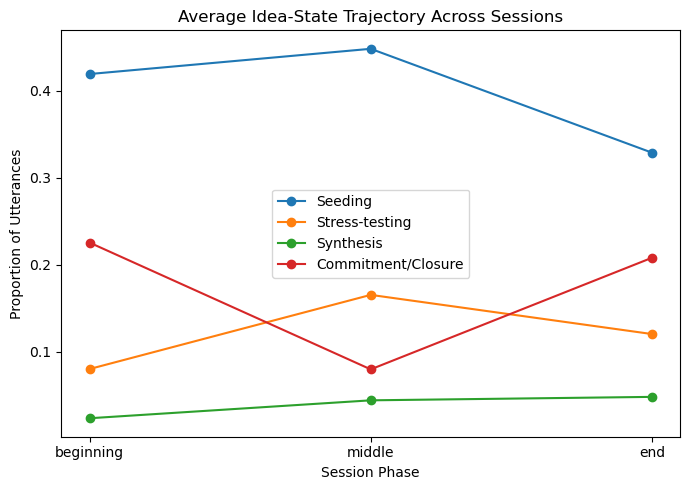

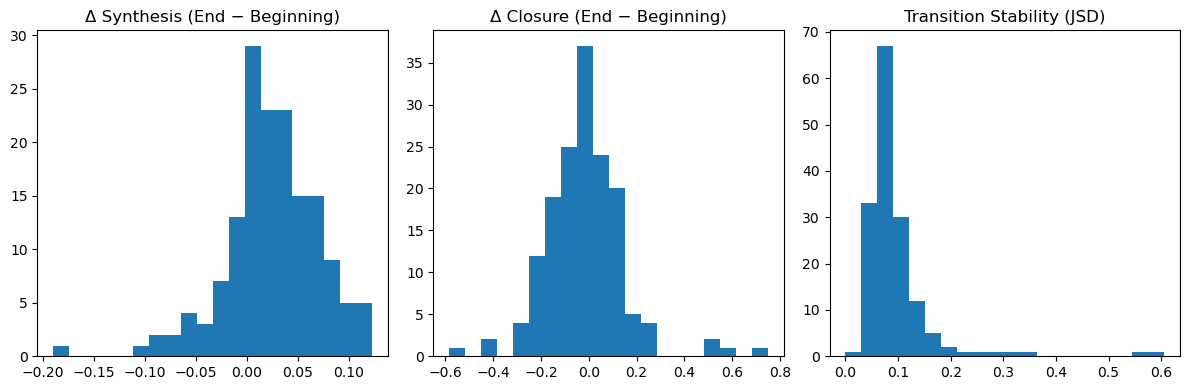


Cluster sizes:
process_cluster
1    70
2    60
3    23
0     4
Name: count, dtype: int64


process_cluster,0,1,2,3
beginning__Commitment/Closure,0.137500,0.292048,0.212303,0.072038
beginning__Idea Development,0.050000,0.015841,0.014744,0.029824
beginning__Other,0.000000,0.031619,0.056012,0.030551
beginning__Participation Structuring,0.075000,0.075977,0.067643,0.035700
beginning__Relational Support,0.325000,0.131110,0.144828,0.033233
beginning__Seeding,0.362500,0.373075,0.429124,0.545000
beginning__Stress-testing,0.025000,0.060529,0.061348,0.196452
beginning__Synthesis,0.025000,0.019802,0.013998,0.057203
end__Commitment/Closure,0.421627,0.232740,0.163998,0.209435
end__Idea Development,0.027778,0.042029,0.042672,0.044869


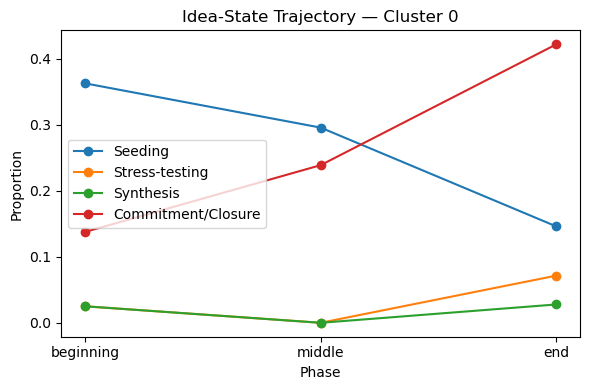

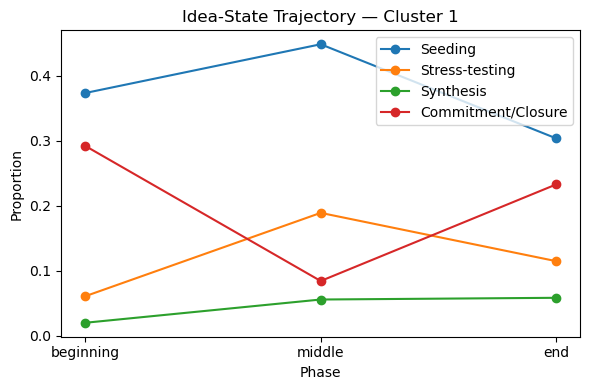

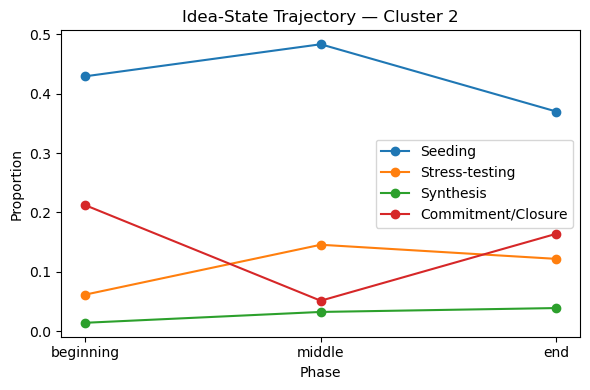

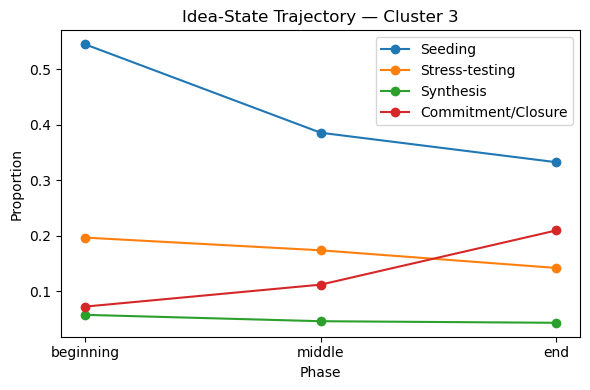

In [12]:
# ============================================================
# NEXT-STAGE ANALYSIS: STRUCTURE BEFORE PREDICTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 1) AVERAGE IDEA-STATE TRAJECTORY (SANITY CHECK FIGURE)
# ------------------------------------------------------------

avg_traj = (
    traj_df
    .groupby("phase")[["Seeding", "Stress-testing", "Synthesis", "Commitment/Closure"]]
    .mean()
    .loc[["beginning", "middle", "end"]]
)

plt.figure(figsize=(7,5))
for col in avg_traj.columns:
    plt.plot(avg_traj.index, avg_traj[col], marker="o", label=col)

plt.title("Average Idea-State Trajectory Across Sessions")
plt.ylabel("Proportion of Utterances")
plt.xlabel("Session Phase")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2) DISTRIBUTIONS OF KEY PROGRESSION METRICS
# ------------------------------------------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(measurement_df["delta_synthesis"], bins=20)
plt.title("Δ Synthesis (End − Beginning)")

plt.subplot(1,3,2)
plt.hist(measurement_df["delta_closure"], bins=20)
plt.title("Δ Closure (End − Beginning)")

plt.subplot(1,3,3)
plt.hist(measurement_df["jsd_next_overall"], bins=20)
plt.title("Transition Stability (JSD)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3) UNSUPERVISED PROCESS CLUSTERING (SESSION TYPES)
# ------------------------------------------------------------

# select numeric feature columns only
feature_cols = [
    c for c in measurement_df.columns
    if c not in ["session_id"]
]

X = measurement_df[feature_cols].values
X = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=4,      # adjust later if needed
    random_state=42,
    n_init=20
)

measurement_df["process_cluster"] = kmeans.fit_predict(X)

print("\nCluster sizes:")
print(measurement_df["process_cluster"].value_counts())


# ------------------------------------------------------------
# 4) CLUSTER INTERPRETATION TABLE (THIS IS THE GOLD)
# ------------------------------------------------------------

cluster_summary = (
    measurement_df
    .groupby("process_cluster")[feature_cols]
    .mean()
    .T
)

display(cluster_summary)


# ------------------------------------------------------------
# 5) OPTIONAL: MEAN TRAJECTORY PER CLUSTER (VERY NICE FIGURE)
# ------------------------------------------------------------

traj_with_cluster = traj_df.merge(
    measurement_df[["session_id", "process_cluster"]],
    on="session_id",
    how="left"
)

for cl in sorted(traj_with_cluster["process_cluster"].unique()):
    sub = traj_with_cluster[traj_with_cluster["process_cluster"] == cl]
    avg = (
        sub.groupby("phase")[["Seeding", "Stress-testing", "Synthesis", "Commitment/Closure"]]
        .mean()
        .loc[["beginning", "middle", "end"]]
    )

    plt.figure(figsize=(6,4))
    for col in avg.columns:
        plt.plot(avg.index, avg[col], marker="o", label=col)

    plt.title(f"Idea-State Trajectory — Cluster {cl}")
    plt.ylabel("Proportion")
    plt.xlabel("Phase")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# END: YOU NOW HAVE STRUCTURE, NOT NOISE
# ============================================================

measurement_df shape: (157, 38)
Unique sessions: 157
Duplicate session_id rows: 0
Columns with NA: 0
traj_df shape: (471, 6)


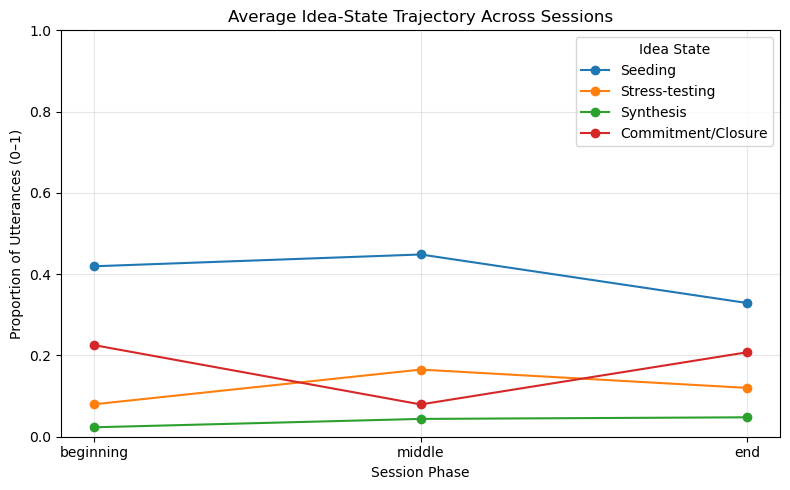

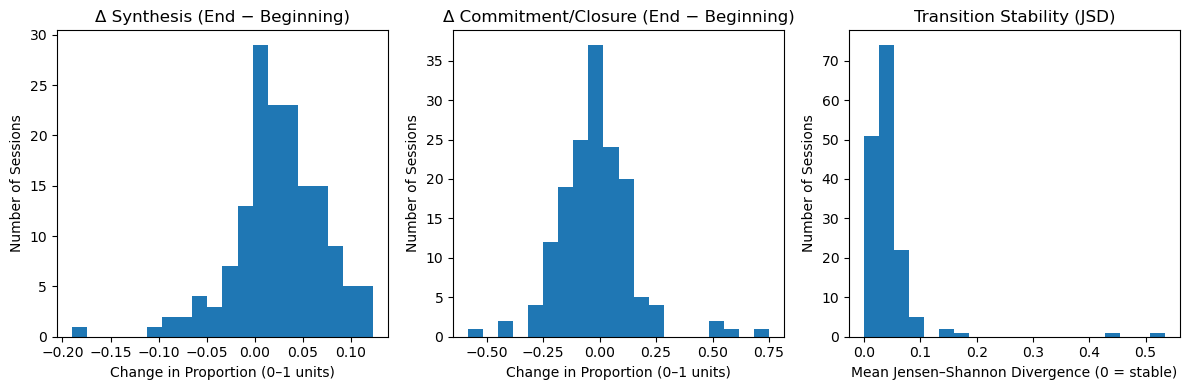

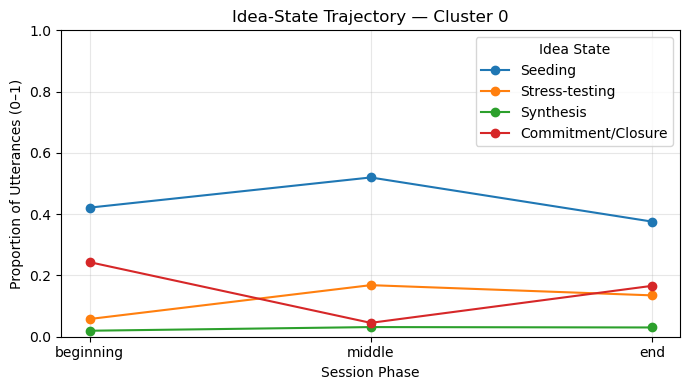

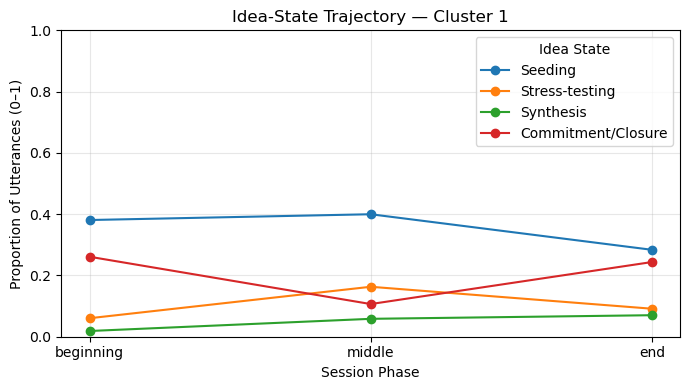

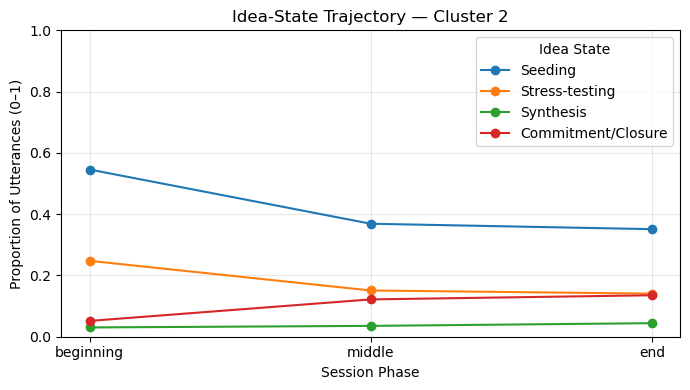

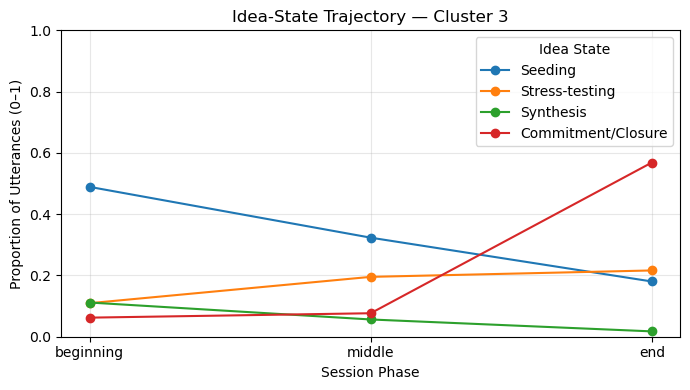

Done.
You now have:
  - measurement_df: one row per session with flow + deltas + JSD + role props + cluster
  - traj_df: long format for plotting (includes cluster)


In [14]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# ASSUMES YOU ALREADY HAVE:
#   df_phased with columns: session_id, idx, third, codes, idea_state, role
#   PHASES = ["beginning","middle","end"]
# -----------------------------------------------------------------------------

PHASES = ["beginning", "middle", "end"]
IDEA_STATES_MAIN = ["Seeding", "Stress-testing", "Synthesis", "Commitment/Closure"]  # what you want in plots

# -----------------------------
# Jensen-Shannon (stable)
# -----------------------------
def jensen_shannon_from_counters(c1: Counter, c2: Counter, eps=1e-12):
    keys = set(c1.keys()) | set(c2.keys())
    P = np.array([c1.get(k, 0.0) for k in keys], dtype=float) + eps
    Q = np.array([c2.get(k, 0.0) for k in keys], dtype=float) + eps
    P /= P.sum()
    Q /= Q.sum()
    M = 0.5 * (P + Q)

    def kl(a, b):
        return float(np.sum(a * np.log(a / b)))

    return 0.5 * kl(P, M) + 0.5 * kl(Q, M)

# -----------------------------
# A) Idea-state flow (session × phase proportions)
# -----------------------------
def build_idea_state_flow(df_in):
    rows = []
    for sid, g in df_in.groupby("session_id"):
        row = {"session_id": sid}
        for ph in PHASES:
            gph = g[g["third"] == ph]
            total = len(gph)
            if total == 0:
                continue
            vc = gph["idea_state"].value_counts(normalize=True)
            for state, pct in vc.items():
                row[f"{ph}__{state}"] = float(pct)
        rows.append(row)
    return pd.DataFrame(rows).fillna(0.0)

idea_flow_df = build_idea_state_flow(df_phased)

# -----------------------------
# B) Progression metrics (human-readable deltas)
# -----------------------------
def add_progression_features(flow_df):
    df = flow_df.copy()

    # convenience accessors (missing columns -> 0)
    def col(ph, state):
        c = f"{ph}__{state}"
        if c not in df.columns:
            df[c] = 0.0
        return c

    # core deltas
    df["delta_synthesis"] = df[col("end","Synthesis")] - df[col("beginning","Synthesis")]
    df["delta_closure"]   = df[col("end","Commitment/Closure")] - df[col("beginning","Commitment/Closure")]
    df["delta_stress_mid"]= df[col("middle","Stress-testing")] - df[col("beginning","Stress-testing")]

    # readable “levels”
    df["early_commitment"] = df[col("beginning","Commitment/Closure")]
    df["early_seeding"]    = df[col("beginning","Seeding")]
    df["late_closure"]     = df[col("end","Commitment/Closure")]
    df["late_synthesis"]   = df[col("end","Synthesis")]

    return df

idea_flow_df = add_progression_features(idea_flow_df)

# -----------------------------
# C) Transition stability (JSD) per session (overall + by phase)
#     We build next-step distributions (multi-label aware) and compare each session
#     to the pooled distribution.
# -----------------------------
def session_next_counter(g_session: pd.DataFrame, phase: str | None = None) -> Counter:
    g = g_session.sort_values(["idx"]).reset_index(drop=True)
    ctr = Counter()
    for i in range(len(g) - 1):
        if phase is not None and g.at[i, "third"] != phase:
            continue
        A = g.at[i, "codes"] or []
        B = g.at[i+1, "codes"] or []
        if not A or not B:
            continue
        for a in A:
            for b in B:
                if a == b:
                    continue
                ctr[(a, b)] += 1
    return ctr

def build_jsd_features(df_in):
    # pooled distributions (overall + per phase)
    pooled_overall = Counter()
    pooled_by_phase = {ph: Counter() for ph in PHASES}

    grouped = {sid: g for sid, g in df_in.groupby("session_id")}
    for sid, g in grouped.items():
        c_all = session_next_counter(g, phase=None)
        pooled_overall.update(c_all)
        for ph in PHASES:
            pooled_by_phase[ph].update(session_next_counter(g, phase=ph))

    rows = []
    for sid, g in grouped.items():
        c_all = session_next_counter(g, phase=None)
        row = {"session_id": sid}

        row["jsd_next_overall"] = jensen_shannon_from_counters(pooled_overall, c_all) if sum(c_all.values()) > 0 else np.nan

        for ph in PHASES:
            c_ph = session_next_counter(g, phase=ph)
            pooled_ph = pooled_by_phase[ph]
            row[f"jsd_next_{ph}"] = jensen_shannon_from_counters(pooled_ph, c_ph) if sum(c_ph.values()) > 0 else np.nan

        rows.append(row)

    out = pd.DataFrame(rows)
    # if a session has no transitions in a phase, fill with overall (or 0). choose one:
    for ph in PHASES:
        out[f"jsd_next_{ph}"] = out[f"jsd_next_{ph}"].fillna(out["jsd_next_overall"])
    out["jsd_next_overall"] = out["jsd_next_overall"].fillna(0.0)
    return out

jsd_df = build_jsd_features(df_phased)

# -----------------------------
# D) Role proportions per session
# -----------------------------
role_props = (
    df_phased
    .groupby(["session_id", "role"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["facilitator", "non-facilitator"]:
    if col not in role_props.columns:
        role_props[col] = 0
role_props["total_utterances"] = role_props["facilitator"] + role_props["non-facilitator"]
role_props["prop_facilitator_utterances"] = np.where(role_props["total_utterances"] > 0, role_props["facilitator"] / role_props["total_utterances"], 0.0)
role_props["prop_nonfacilitator_utterances"] = np.where(role_props["total_utterances"] > 0, role_props["non-facilitator"] / role_props["total_utterances"], 0.0)
role_props = role_props[["session_id", "prop_facilitator_utterances", "prop_nonfacilitator_utterances"]]

# -----------------------------
# E) Measurement DF (the “clean” table you actually model later)
# -----------------------------
measurement_df = (
    idea_flow_df
    .merge(jsd_df, on="session_id", how="left")
    .merge(role_props, on="session_id", how="left")
    .fillna(0.0)
)

print(f"measurement_df shape: {measurement_df.shape}")
print(f"Unique sessions: {measurement_df['session_id'].nunique()}")
print(f"Duplicate session_id rows: {measurement_df.duplicated('session_id').sum()}")
print(f"Columns with NA: {measurement_df.isna().sum().sum()}")

# -----------------------------
# F) Trajectory DF (long format) for plotting
# -----------------------------
def build_traj_df(meas_df, states=IDEA_STATES_MAIN):
    rows = []
    for _, r in meas_df.iterrows():
        sid = r["session_id"]
        for ph in PHASES:
            row = {"session_id": sid, "phase": ph}
            for st in states:
                col = f"{ph}__{st}"
                row[st] = float(r[col]) if col in meas_df.columns else 0.0
            rows.append(row)
    return pd.DataFrame(rows)

traj_df = build_traj_df(measurement_df, states=IDEA_STATES_MAIN)
print(f"traj_df shape: {traj_df.shape}")

# -----------------------------------------------------------------------------
# PLOTS (with labels + units)
# -----------------------------------------------------------------------------

# 1) Average trajectory across sessions
avg_traj = traj_df.groupby("phase")[IDEA_STATES_MAIN].mean().reindex(PHASES)

plt.figure(figsize=(8,5))
for st in IDEA_STATES_MAIN:
    plt.plot(PHASES, avg_traj[st].values, marker="o", label=st)
plt.title("Average Idea-State Trajectory Across Sessions")
plt.xlabel("Session Phase")
plt.ylabel("Proportion of Utterances (0–1)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title="Idea State")
plt.tight_layout()
plt.show()

# 2) Histograms: delta synthesis, delta closure
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(measurement_df["delta_synthesis"].values, bins=20)
plt.title("Δ Synthesis (End − Beginning)")
plt.xlabel("Change in Proportion (0–1 units)")
plt.ylabel("Number of Sessions")

plt.subplot(1,3,2)
plt.hist(measurement_df["delta_closure"].values, bins=20)
plt.title("Δ Commitment/Closure (End − Beginning)")
plt.xlabel("Change in Proportion (0–1 units)")
plt.ylabel("Number of Sessions")

plt.subplot(1,3,3)
plt.hist(measurement_df["jsd_next_overall"].values, bins=20)
plt.title("Transition Stability (JSD)")
plt.xlabel("Mean Jensen–Shannon Divergence (0 = stable)")
plt.ylabel("Number of Sessions")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# CLUSTERING (this is what fixes your KeyError: we create 'cluster' AND merge it)
# -----------------------------------------------------------------------------

# Build session-level vector: concatenated (phase × state) proportions for the main states
cluster_cols = []
for ph in PHASES:
    for st in IDEA_STATES_MAIN:
        c = f"{ph}__{st}"
        if c not in measurement_df.columns:
            measurement_df[c] = 0.0
        cluster_cols.append(c)

X = measurement_df[cluster_cols].values
X = StandardScaler().fit_transform(X)

K = 4  # pick 3–6; 4 is a sane default for “types of sessions”
km = KMeans(n_clusters=K, n_init=25, random_state=42)
measurement_df["cluster"] = km.fit_predict(X)

# IMPORTANT: merge cluster labels into traj_df so traj_df has the 'cluster' column
traj_df = traj_df.merge(measurement_df[["session_id", "cluster"]], on="session_id", how="left")

# Clustered trajectories plot
for k in sorted(traj_df["cluster"].dropna().unique()):
    g = traj_df[traj_df["cluster"] == k]
    avg = g.groupby("phase")[IDEA_STATES_MAIN].mean().reindex(PHASES)

    plt.figure(figsize=(7,4))
    for st in IDEA_STATES_MAIN:
        plt.plot(PHASES, avg[st].values, marker="o", label=st)
    plt.title(f"Idea-State Trajectory — Cluster {int(k)}")
    plt.xlabel("Session Phase")
    plt.ylabel("Proportion of Utterances (0–1)")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Idea State")
    plt.tight_layout()
    plt.show()

print("Done.")
print("You now have:")
print("  - measurement_df: one row per session with flow + deltas + JSD + role props + cluster")
print("  - traj_df: long format for plotting (includes cluster)")

In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# -----------------------------
# CLUSTER PROFILING
# -----------------------------

# 1) Cluster sizes
cluster_sizes = (
    measurement_df.groupby("cluster")["session_id"]
    .nunique()
    .sort_index()
    .rename("n_sessions")
    .reset_index()
)
display(cluster_sizes)

# 2) Choose a compact set of interpretable features to describe clusters
PROFILE_FEATURES = [
    # flow levels (early + late)
    "early_seeding", "early_commitment", "late_synthesis", "late_closure",
    # progression
    "delta_synthesis", "delta_closure", "delta_stress_mid",
    # stability
    "jsd_next_overall", "jsd_next_beginning", "jsd_next_middle", "jsd_next_end",
    # roles
    "prop_facilitator_utterances"
]

# keep only columns that exist (avoid KeyErrors if one is missing)
PROFILE_FEATURES = [c for c in PROFILE_FEATURES if c in measurement_df.columns]

cluster_means = (
    measurement_df.groupby("cluster")[PROFILE_FEATURES]
    .mean()
    .sort_index()
)
display(cluster_means)

# 3) Cluster "signature" features (z-scored vs global mean)
global_mean = measurement_df[PROFILE_FEATURES].mean()
global_std  = measurement_df[PROFILE_FEATURES].std(ddof=0).replace(0, np.nan)

cluster_signature_z = (cluster_means - global_mean) / global_std
display(cluster_signature_z)

# show top +/- features per cluster
TOPN = 5
sig_rows = []
for k in sorted(measurement_df["cluster"].unique()):
    z = cluster_signature_z.loc[k].dropna().sort_values()
    low = z.head(TOPN)
    high = z.tail(TOPN)[::-1]
    sig_rows.append({
        "cluster": int(k),
        "n_sessions": int(cluster_sizes.loc[cluster_sizes["cluster"]==k, "n_sessions"].iloc[0]),
        "most_low_features": ", ".join([f"{idx} ({val:+.2f})" for idx, val in low.items()]),
        "most_high_features": ", ".join([f"{idx} ({val:+.2f})" for idx, val in high.items()]),
    })

cluster_signatures = pd.DataFrame(sig_rows).sort_values("cluster")
display(cluster_signatures)

# -----------------------------
# REPRESENTATIVE SESSIONS PER CLUSTER
# (closest to centroid in the clustering feature space)
# -----------------------------
PHASES = ["beginning", "middle", "end"]
IDEA_STATES_MAIN = ["Seeding", "Stress-testing", "Synthesis", "Commitment/Closure"]

cluster_cols = [f"{ph}__{st}" for ph in PHASES for st in IDEA_STATES_MAIN]
cluster_cols = [c for c in cluster_cols if c in measurement_df.columns]

X = measurement_df[cluster_cols].values
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# compute centroids in z-space
centroids = (
    pd.DataFrame(Xz, index=measurement_df.index)
    .groupby(measurement_df["cluster"])
    .mean()
)

# distance to centroid
rep_rows = []
for k in sorted(measurement_df["cluster"].unique()):
    idxs = measurement_df.index[measurement_df["cluster"] == k].tolist()
    if not idxs:
        continue
    C = centroids.loc[k].values
    dists = []
    for ix in idxs:
        d = float(np.linalg.norm(Xz[ix] - C))
        dists.append((ix, d))
    dists.sort(key=lambda t: t[1])
    # take top N closest
    N_REP = 3
    for rank, (ix, d) in enumerate(dists[:N_REP], start=1):
        rep_rows.append({
            "cluster": int(k),
            "rank_in_cluster": rank,
            "session_id": measurement_df.loc[ix, "session_id"],
            "dist_to_centroid": d,
            "early_seeding": float(measurement_df.loc[ix, "early_seeding"]) if "early_seeding" in measurement_df.columns else np.nan,
            "late_closure": float(measurement_df.loc[ix, "late_closure"]) if "late_closure" in measurement_df.columns else np.nan,
            "delta_synthesis": float(measurement_df.loc[ix, "delta_synthesis"]) if "delta_synthesis" in measurement_df.columns else np.nan,
            "jsd_next_overall": float(measurement_df.loc[ix, "jsd_next_overall"]) if "jsd_next_overall" in measurement_df.columns else np.nan,
        })

representative_sessions = pd.DataFrame(rep_rows).sort_values(["cluster","rank_in_cluster"])
display(representative_sessions)

print("Next: use representative_sessions.session_id to pull transcript windows / examples for each cluster.")

,cluster,n_sessions
0,0,71
1,1,65
2,2,16
3,3,5


,early_seeding,early_commitment,late_synthesis,late_closure,delta_synthesis,delta_closure,delta_stress_mid,jsd_next_overall,jsd_next_beginning,jsd_next_middle,jsd_next_end,prop_facilitator_utterances
cluster,,,,,,,,,,,,
0,0.421317,0.243428,0.030205,0.165990,0.010673,-0.077439,0.110518,0.037734,0.090305,0.104524,0.091647,0.257819
1,0.380868,0.261049,0.070224,0.243717,0.051576,-0.017333,0.102669,0.040926,0.091581,0.102101,0.096704,0.305243
2,0.545777,0.051592,0.044235,0.135341,0.013953,0.083749,-0.096812,0.056975,0.173758,0.137440,0.137890,0.118929
3,0.489072,0.062263,0.017423,0.568574,-0.094228,0.506311,0.085957,0.164758,0.301896,0.258725,0.305864,0.087246


,early_seeding,early_commitment,late_synthesis,late_closure,delta_synthesis,delta_closure,delta_stress_mid,jsd_next_overall,jsd_next_beginning,jsd_next_middle,jsd_next_end,prop_facilitator_utterances
cluster,,,,,,,,,,,,
0,0.015531,0.150557,-0.505929,-0.358401,-0.299107,-0.364994,0.224606,-0.129702,-0.200582,-0.088193,-0.174379,-0.000272
1,-0.314306,0.297746,0.645035,0.306808,0.579312,0.001242,0.154535,-0.073208,-0.184351,-0.117605,-0.109680,0.271819
2,1.030438,-1.451844,-0.102408,-0.620698,-0.228668,0.617148,-1.626161,0.210877,0.860759,0.311522,0.417320,-0.797142
3,0.568041,-1.362707,-0.873560,3.087019,-2.551993,3.191886,0.005354,2.118663,2.490398,1.784334,2.566604,-0.978919


,cluster,n_sessions,most_low_features,most_high_features
0,0,71,"late_synthesis (-0.51), delta_closure (-0.36),...","delta_stress_mid (+0.22), early_commitment (+0..."
1,1,65,"early_seeding (-0.31), jsd_next_beginning (-0....","late_synthesis (+0.65), delta_synthesis (+0.58..."
2,2,16,"delta_stress_mid (-1.63), early_commitment (-1...","early_seeding (+1.03), jsd_next_beginning (+0...."
3,3,5,"delta_synthesis (-2.55), early_commitment (-1....","delta_closure (+3.19), late_closure (+3.09), j..."


,cluster,rank_in_cluster,session_id,dist_to_centroid,early_seeding,late_closure,delta_synthesis,jsd_next_overall
0,0,1,2022_04_07_MND_S2,1.380992,0.449541,0.175926,0.009599,0.017468
1,0,2,2021_10_08_CMC_S2,1.458326,0.404255,0.159574,0.021277,0.026680
2,0,3,2021_11_05_NES_S9,1.506145,0.452055,0.212389,-0.004849,0.027150
3,1,1,2021_10_01_MZT_S5,1.270289,0.384615,0.240000,0.066667,0.017890
4,1,2,2021_11_05_NES_S10,1.347780,0.400000,0.205357,0.051429,0.021991
5,1,3,2021_06_11_SLU_S7,1.362299,0.414286,0.277108,0.043718,0.014569
6,2,1,2021_04_22_MND_S8,1.269729,0.454545,0.155172,0.021421,0.040039
7,2,2,2021_09_30_MZT_S2,2.682963,0.378378,0.055556,0.018519,0.041449
8,2,3,2021_11_04_NES_S2,2.906673,0.641026,0.189474,0.031579,0.052738
9,3,1,2020_11_05_NES_S3,3.246542,0.454545,0.600000,-0.090909,0.060210


Next: use representative_sessions.session_id to pull transcript windows / examples for each cluster.


Found 8 outcome JSON files.
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2020NES/2020NES_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021ABI/2021ABI_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021CMC/2021CMC_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021MND/2021MND_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021MZT/2021MZT_outcome.json
 ...
teams_df shape: (193, 7)


,year,track,team_id,team_num,funded_status,members,source_path
0,2020,NES,NES1,1,0,"[Shu Hu, Jared Mason, Shaama Sharada]",/Users/maxchalekson/Northwestern University/Su...
1,2020,NES,NES2,2,0,"[Venkat Viswanathan, Charles McCrory, Jesus Ve...",/Users/maxchalekson/Northwestern University/Su...
2,2020,NES,NES3,3,0,"[Sen Zhang, Praveen Bollini, Will Bowman]",/Users/maxchalekson/Northwestern University/Su...
3,2020,NES,NES4,4,0,"[Betar Gallant, Michael Nippe]",/Users/maxchalekson/Northwestern University/Su...
4,2020,NES,NES5,5,1,"[Nanette Boyle, Shu Hu]",/Users/maxchalekson/Northwestern University/Su...


,session_id,year,track,team_num
156,output-2021-05-20-ABI-S1,NaN,None,NaN


Outcomes coverage (means):
team_formed         0.993631
proposal_success    0.350318
dtype: float64


,session_id,year,track,team_num,funded_status,team_formed,proposal_success
0,2020_11_05_NES_S1,2020.0,NES,1.0,0.0,1,0
1,2020_11_05_NES_S2,2020.0,NES,2.0,0.0,1,0
2,2020_11_05_NES_S3,2020.0,NES,3.0,0.0,1,0
3,2020_11_05_NES_S4,2020.0,NES,4.0,0.0,1,0
4,2020_11_05_NES_S5,2020.0,NES,5.0,1.0,1,1


Merged model_df shape: (157, 41)
Unique sessions: 157

Outcome base rates:
team_formed         0.993631
proposal_success    0.350318
dtype: float64

Predictor matrix shape: (157, 12)
Predictors: ['early_seeding', 'early_commitment', 'late_synthesis', 'late_closure', 'delta_synthesis', 'delta_closure', 'delta_stress_mid', 'jsd_next_overall', 'prop_facilitator_utterances', 'cluster_1', 'cluster_2', 'cluster_3']


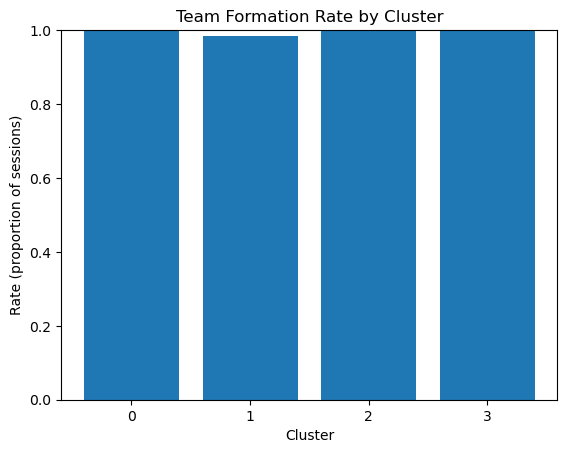

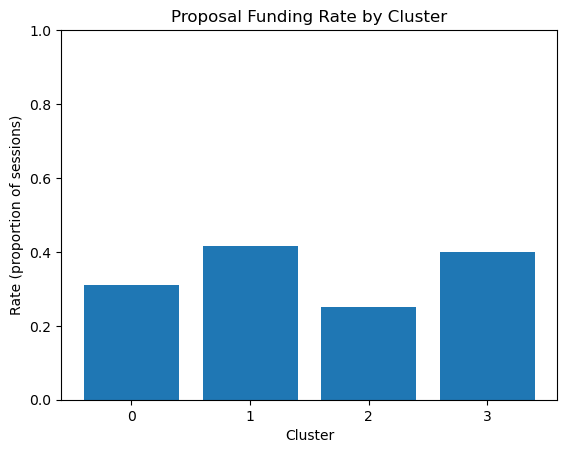


[TEAM FORMATION] AUCs: [nan nan nan nan nan]
Mean AUC: nan ± nan

[PROPOSAL SUCCESS (FUNDED)] AUCs: [0.463 0.693 0.532 0.555 0.45 ]
Mean AUC: 0.538 ± 0.087

[PROPOSAL SUCCESS (FUNDED)] Top positive predictors:


/Users/maxchalekson/miniforge3/envs/gem_samp/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/maxchalekson/miniforge3/envs/gem_samp/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/maxchalekson/miniforge3/envs/gem_samp/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/maxchalekson/miniforge3/envs/gem_samp/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/maxchalekson/miniforge3/envs/gem_samp/lib/python3.11/site-packages/sklearn/metrics/_

,feature,coef
0,delta_stress_mid,0.339872
1,prop_facilitator_utterances,0.270407
2,late_closure,0.251874
3,delta_closure,0.246987
4,cluster_1,0.185090
5,early_seeding,0.071326
6,late_synthesis,0.069844
7,cluster_2,0.017336
8,jsd_next_overall,-0.077403
9,early_commitment,-0.092756



[PROPOSAL SUCCESS (FUNDED)] Top negative predictors:


,feature,coef
2,late_closure,0.251874
3,delta_closure,0.246987
4,cluster_1,0.185090
5,early_seeding,0.071326
6,late_synthesis,0.069844
7,cluster_2,0.017336
8,jsd_next_overall,-0.077403
9,early_commitment,-0.092756
10,cluster_3,-0.246980
11,delta_synthesis,-0.287045


In [17]:
import os, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


# ============================================================
# 0) LOCATE + LOAD *ALL* OUTCOME JSONs (SCIALOG-wide)
# ============================================================
# Update this root if yours differs.
DATA_ROOTS = [
    "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data",
    # fallback for this environment if you want to test with the single attached file:
    "/mnt/data",
]

def find_outcome_jsons(roots):
    paths = []
    for root in roots:
        if not os.path.exists(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if fn.endswith("_outcome.json"):
                    paths.append(os.path.join(dirpath, fn))
    return sorted(paths)

outcome_paths = find_outcome_jsons(DATA_ROOTS)
if not outcome_paths:
    raise FileNotFoundError(
        "No *_outcome.json files found under:\n" + "\n".join(DATA_ROOTS)
    )

print(f"Found {len(outcome_paths)} outcome JSON files.")
for p in outcome_paths[:5]:
    print(" -", p)
if len(outcome_paths) > 5:
    print(" ...")


def parse_year_track_from_path(path: str):
    """
    Example path includes ".../data/2021MND/2021MND_outcome.json"
    We extract year=2021 and track=MND from the folder/file prefix.
    """
    base = os.path.basename(path)
    # file like 2021MND_outcome.json
    m = re.match(r"(\d{4})([A-Z]{3})_outcome\.json$", base)
    if m:
        return int(m.group(1)), m.group(2)

    # fallback: look in parent folder name like 2021MND
    folder = os.path.basename(os.path.dirname(path))
    m2 = re.match(r"(\d{4})([A-Z]{3})$", folder)
    if m2:
        return int(m2.group(1)), m2.group(2)

    return None, None


def load_all_outcomes(outcome_paths):
    rows = []
    for path in outcome_paths:
        year, track = parse_year_track_from_path(path)
        with open(path, "r") as f:
            data = json.load(f)

        if not isinstance(data, list):
            raise ValueError(f"Expected list in {path}, got {type(data)}")

        df = pd.DataFrame(data)
        if df.empty:
            continue

        if "team_id" not in df.columns or "funded_status" not in df.columns:
            raise ValueError(
                f"{path} missing required keys. Columns: {df.columns.tolist()}"
            )

        df = df.copy()
        df["funded_status"] = df["funded_status"].astype(int)
        df["source_path"] = path
        df["year"] = year
        df["track"] = track

        # Extract numeric team number from team_id (e.g., "MND2" -> 2)
        df["team_num"] = df["team_id"].astype(str).str.extract(r"(\d+)").astype(float)
        rows.append(df)

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if out.empty:
        raise ValueError("Loaded outcome files but got empty teams_df.")
    if out["team_num"].isna().any():
        # you can relax this if there are weird team_id formats
        print("Warning: some team_id values did not yield a numeric team_num.")
    out["team_num"] = out["team_num"].fillna(-1).astype(int)

    # Keep only what we need (plus traceability)
    keep_cols = ["year", "track", "team_id", "team_num", "funded_status", "members", "source_path"]
    keep_cols = [c for c in keep_cols if c in out.columns]
    return out[keep_cols].drop_duplicates(subset=["year", "track", "team_id"])

teams_df = load_all_outcomes(outcome_paths)
print("teams_df shape:", teams_df.shape)
display(teams_df.head())


# ============================================================
# 1) BUILD outcomes_df FOR ALL sessions in measurement_df
# ============================================================
if "measurement_df" not in globals():
    raise NameError("measurement_df not found. Run the measurement-building chunk first.")

def parse_session_id(session_id: str):
    """
    Expected: YYYY_MM_DD_<TRACK>_S<NUM>
    e.g., 2021_04_22_MND_S2 -> year=2021, track=MND, team_num=2
    """
    s = str(session_id)
    m = re.match(r"(?P<year>\d{4})_\d{2}_\d{2}_(?P<track>[A-Z]{3})_S(?P<num>\d+)$", s)
    if not m:
        return None, None, None
    return int(m.group("year")), m.group("track"), int(m.group("num"))

outcomes_df = measurement_df[["session_id"]].copy()
parsed = outcomes_df["session_id"].apply(parse_session_id)
outcomes_df[["year", "track", "team_num"]] = pd.DataFrame(parsed.tolist(), index=outcomes_df.index)

bad = outcomes_df["year"].isna().sum()
if bad:
    # don't hard crash, but make it obvious what's wrong
    print(f"Warning: {bad} session_id values did not match the expected pattern.")
    display(outcomes_df[outcomes_df["year"].isna()].head())

# Left-join to outcomes by (year, track, team_num)
# This avoids relying on team_id string formatting beyond the number.
outcomes_df = outcomes_df.merge(
    teams_df[["year", "track", "team_num", "funded_status"]],
    on=["year", "track", "team_num"],
    how="left"
)

# team_formed: did we find a matching team in the outcomes file?
outcomes_df["team_formed"] = outcomes_df["funded_status"].notna().astype(int)

# proposal_success: funded_status if present, else 0
outcomes_df["proposal_success"] = outcomes_df["funded_status"].fillna(0).astype(int)

print("Outcomes coverage (means):")
print(outcomes_df[["team_formed", "proposal_success"]].mean())
display(outcomes_df.head())


# ============================================================
# 2) MERGE MEASUREMENT + OUTCOMES
# ============================================================
model_df = measurement_df.merge(outcomes_df[["session_id", "team_formed", "proposal_success"]], on="session_id", how="inner")

print("Merged model_df shape:", model_df.shape)
print("Unique sessions:", model_df["session_id"].nunique())
print("\nOutcome base rates:")
print(model_df[["team_formed", "proposal_success"]].mean())


# ============================================================
# 3) BUILD PREDICTOR MATRIX
# ============================================================
base_numeric_feats = [
    "early_seeding",
    "early_commitment",
    "late_synthesis",
    "late_closure",
    "delta_synthesis",
    "delta_closure",
    "delta_stress_mid",
    "jsd_next_overall",
    "prop_facilitator_utterances",
]
base_numeric_feats = [c for c in base_numeric_feats if c in model_df.columns]
X_parts = [model_df[base_numeric_feats].copy()]

if "cluster" in model_df.columns:
    cluster_dummies = pd.get_dummies(model_df["cluster"], prefix="cluster", drop_first=True)
    X_parts.append(cluster_dummies)

X = pd.concat(X_parts, axis=1)

y_team = model_df["team_formed"].astype(int)
y_prop = model_df["proposal_success"].astype(int)

print("\nPredictor matrix shape:", X.shape)
print("Predictors:", X.columns.tolist())


# ============================================================
# 4) OUTCOME RATES BY CLUSTER (if present) with labels/units
# ============================================================
if "cluster" in model_df.columns:
    rates = model_df.groupby("cluster")[["team_formed", "proposal_success"]].mean().reset_index()

    plt.figure()
    plt.bar(rates["cluster"].astype(str), rates["team_formed"])
    plt.xlabel("Cluster")
    plt.ylabel("Rate (proportion of sessions)")
    plt.ylim(0, 1)
    plt.title("Team Formation Rate by Cluster")
    plt.show()

    plt.figure()
    plt.bar(rates["cluster"].astype(str), rates["proposal_success"])
    plt.xlabel("Cluster")
    plt.ylabel("Rate (proportion of sessions)")
    plt.ylim(0, 1)
    plt.title("Proposal Funding Rate by Cluster")
    plt.show()
else:
    print("\nNo 'cluster' column found, skipping cluster bar charts.")


# ============================================================
# 5) BASELINE LOGISTIC REGRESSION (AUC) with guardrails
# ============================================================
def eval_logreg_auc(X, y, label):
    if y.nunique() < 2:
        print(f"\n[{label}] Skipping AUC: single-class outcome.")
        return

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs"))
    ])

    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    print(f"\n[{label}] AUCs:", np.round(aucs, 3))
    print("Mean AUC:", round(aucs.mean(), 3), "±", round(aucs.std(), 3))

eval_logreg_auc(X, y_team, "TEAM FORMATION")
eval_logreg_auc(X, y_prop, "PROPOSAL SUCCESS (FUNDED)")


# ============================================================
# 6) COEFFICIENTS (fit on full data)
# ============================================================
def fit_and_show_coefs(X, y, label):
    if y.nunique() < 2:
        print(f"\n[{label}] Skipping coef table: single-class outcome.")
        return

    pipe_full = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs"))
    ])
    pipe_full.fit(X, y)

    coef = pipe_full.named_steps["clf"].coef_.ravel()
    coef_df = (
        pd.DataFrame({"feature": X.columns, "coef": coef})
        .sort_values("coef", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n[{label}] Top positive predictors:")
    display(coef_df.head(10))

    print(f"\n[{label}] Top negative predictors:")
    display(coef_df.tail(10))

fit_and_show_coefs(X, y_prop, "PROPOSAL SUCCESS (FUNDED)")


Outcome base rates:
team_formed         1.000000
proposal_success    0.350318
dtype: float64

Outcome class counts:
team_formed:
 team_formed
1    157
Name: count, dtype: int64

proposal_success:
 proposal_success
0    102
1     55
Name: count, dtype: int64


,session_id,year,track,team_num,funded_status,team_formed,proposal_success
0,2020_11_05_NES_S1,2020,NES,1,0,1,0
1,2020_11_05_NES_S2,2020,NES,2,0,1,0
2,2020_11_05_NES_S3,2020,NES,3,0,1,0
3,2020_11_05_NES_S4,2020,NES,4,0,1,0
4,2020_11_05_NES_S5,2020,NES,5,1,1,1



Merged model_df shape: (157, 41)
Unique sessions: 157

X shape: (157, 12)
X columns: ['early_seeding', 'early_commitment', 'late_synthesis', 'late_closure', 'delta_synthesis', 'delta_closure', 'delta_stress_mid', 'jsd_next_overall', 'prop_facilitator_utterances', 'cluster_1', 'cluster_2', 'cluster_3']


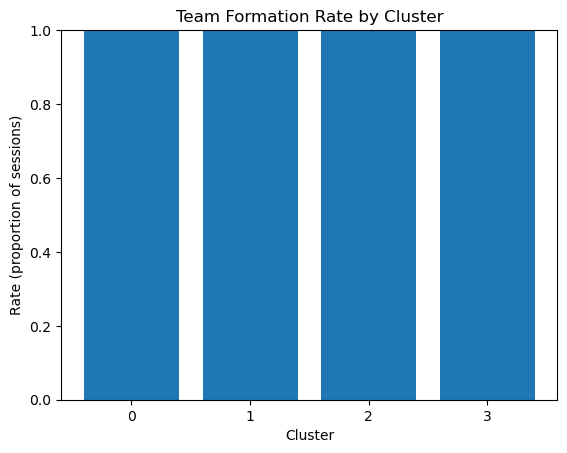

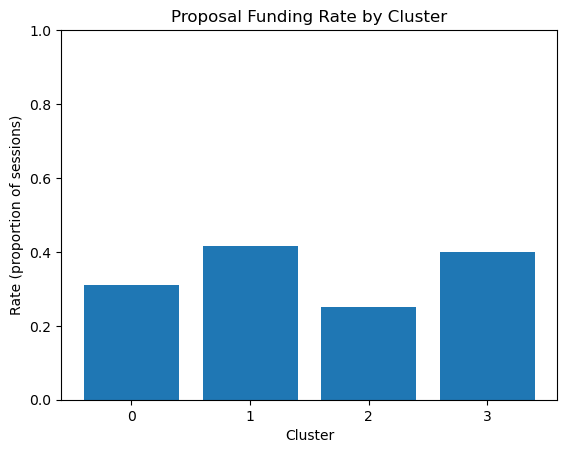


[TEAM FORMATION] Skipping: single-class outcome.

[PROPOSAL SUCCESS (FUNDED)] class counts: {0: 102, 1: 55} | using n_splits=5
[PROPOSAL SUCCESS (FUNDED)] AUCs: [0.463 0.693 0.532 0.555 0.45 ]
[PROPOSAL SUCCESS (FUNDED)] Mean AUC: 0.538 ± 0.087

[PROPOSAL SUCCESS (FUNDED)] Top positive predictors:


,feature,coef
0,delta_stress_mid,0.339872
1,prop_facilitator_utterances,0.270407
2,late_closure,0.251874
3,delta_closure,0.246987
4,cluster_1,0.185090
5,early_seeding,0.071326
6,late_synthesis,0.069844
7,cluster_2,0.017336
8,jsd_next_overall,-0.077403
9,early_commitment,-0.092756



[PROPOSAL SUCCESS (FUNDED)] Top negative predictors:


,feature,coef
0,delta_stress_mid,0.339872
1,prop_facilitator_utterances,0.270407
2,late_closure,0.251874
3,delta_closure,0.246987
4,cluster_1,0.185090
5,early_seeding,0.071326
6,late_synthesis,0.069844
7,cluster_2,0.017336
8,jsd_next_overall,-0.077403
9,early_commitment,-0.092756


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


# ============================================================
# 0) Robust session_id parsing (supports 2 formats)
# ============================================================
def parse_session_id_any(session_id: str):
    """
    Supports:
      1) YYYY_MM_DD_TRK_S#
         e.g., 2021_04_22_MND_S2
      2) output-YYYY-MM-DD-TRK-S#
         e.g., output-2021-05-20-ABI-S1
    Returns: (year:int, track:str, team_num:int) or (None,None,None)
    """
    s = str(session_id)

    m1 = re.match(r"(?P<year>\d{4})_\d{2}_\d{2}_(?P<track>[A-Z]{3})_S(?P<num>\d+)$", s)
    if m1:
        return int(m1.group("year")), m1.group("track"), int(m1.group("num"))

    m2 = re.match(r"output-(?P<year>\d{4})-\d{2}-\d{2}-(?P<track>[A-Z]{3})-S(?P<num>\d+)$", s)
    if m2:
        return int(m2.group("year")), m2.group("track"), int(m2.group("num"))

    return None, None, None


# ============================================================
# 1) Rebuild outcomes_df using teams_df (assumes you already built teams_df)
# ============================================================
if "measurement_df" not in globals():
    raise NameError("measurement_df not found. Run measurement-building first.")
if "teams_df" not in globals():
    raise NameError("teams_df not found. Run the outcomes-loading chunk that builds teams_df first.")

outcomes_df = measurement_df[["session_id"]].copy()
parsed = outcomes_df["session_id"].apply(parse_session_id_any)
outcomes_df[["year", "track", "team_num"]] = pd.DataFrame(parsed.tolist(), index=outcomes_df.index)

bad = outcomes_df["year"].isna().sum()
if bad:
    print(f"Warning: {bad} session_id values did not match either known pattern.")
    display(outcomes_df[outcomes_df["year"].isna()].head())

# Join by (year, track, team_num)
outcomes_df = outcomes_df.merge(
    teams_df[["year", "track", "team_num", "funded_status"]],
    on=["year", "track", "team_num"],
    how="left"
)

outcomes_df["team_formed"] = outcomes_df["funded_status"].notna().astype(int)
outcomes_df["proposal_success"] = outcomes_df["funded_status"].fillna(0).astype(int)

print("\nOutcome base rates:")
print(outcomes_df[["team_formed", "proposal_success"]].mean())
print("\nOutcome class counts:")
print("team_formed:\n", outcomes_df["team_formed"].value_counts(dropna=False))
print("\nproposal_success:\n", outcomes_df["proposal_success"].value_counts(dropna=False))
display(outcomes_df.head())


# ============================================================
# 2) Merge to model_df
# ============================================================
model_df = measurement_df.merge(
    outcomes_df[["session_id", "team_formed", "proposal_success"]],
    on="session_id",
    how="inner"
)

print("\nMerged model_df shape:", model_df.shape)
print("Unique sessions:", model_df["session_id"].nunique())


# ============================================================
# 3) Predictor matrix
# ============================================================
base_numeric_feats = [
    "early_seeding",
    "early_commitment",
    "late_synthesis",
    "late_closure",
    "delta_synthesis",
    "delta_closure",
    "delta_stress_mid",
    "jsd_next_overall",
    "prop_facilitator_utterances",
]
base_numeric_feats = [c for c in base_numeric_feats if c in model_df.columns]
X_parts = [model_df[base_numeric_feats].copy()]

if "cluster" in model_df.columns:
    X_parts.append(pd.get_dummies(model_df["cluster"], prefix="cluster", drop_first=True))

X = pd.concat(X_parts, axis=1)
y_team = model_df["team_formed"].astype(int)
y_prop = model_df["proposal_success"].astype(int)

print("\nX shape:", X.shape)
print("X columns:", X.columns.tolist())


# ============================================================
# 4) Cluster outcome bars (only if cluster exists)
# ============================================================
if "cluster" in model_df.columns:
    rates = model_df.groupby("cluster")[["team_formed", "proposal_success"]].mean().reset_index()

    plt.figure()
    plt.bar(rates["cluster"].astype(str), rates["team_formed"])
    plt.xlabel("Cluster")
    plt.ylabel("Rate (proportion of sessions)")
    plt.ylim(0, 1)
    plt.title("Team Formation Rate by Cluster")
    plt.show()

    plt.figure()
    plt.bar(rates["cluster"].astype(str), rates["proposal_success"])
    plt.xlabel("Cluster")
    plt.ylabel("Rate (proportion of sessions)")
    plt.ylim(0, 1)
    plt.title("Proposal Funding Rate by Cluster")
    plt.show()


# ============================================================
# 5) CV that doesn't implode when classes are rare
# ============================================================
def safe_n_splits(y, max_splits=5):
    # smallest class count determines how many stratified folds are even possible
    counts = y.value_counts()
    min_class = counts.min()
    # need at least 2 folds, and at least 2 samples in each class for sane CV
    return max(2, min(max_splits, int(min_class)))

def eval_logreg_auc(X, y, label):
    if y.nunique() < 2:
        print(f"\n[{label}] Skipping: single-class outcome.")
        return

    n_splits = safe_n_splits(y, max_splits=5)
    counts = y.value_counts()
    print(f"\n[{label}] class counts: {counts.to_dict()} | using n_splits={n_splits}")

    # if minority class count is 1, even n_splits=2 will fail sometimes
    if counts.min() < 2:
        print(f"[{label}] Skipping AUC: minority class has <2 samples. This is not a modeling problem, it's math.")
        return

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs"))
    ])

    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", error_score=np.nan)
    aucs = aucs[~np.isnan(aucs)]
    if len(aucs) == 0:
        print(f"[{label}] All folds produced NaN AUC (likely single-class folds).")
        return

    print(f"[{label}] AUCs:", np.round(aucs, 3))
    print(f"[{label}] Mean AUC:", round(aucs.mean(), 3), "±", round(aucs.std(), 3))

eval_logreg_auc(X, y_team, "TEAM FORMATION")
eval_logreg_auc(X, y_prop, "PROPOSAL SUCCESS (FUNDED)")


# ============================================================
# 6) Coefs (proposal_success only, because team_formed is basically constant)
# ============================================================
def fit_and_show_coefs(X, y, label):
    if y.nunique() < 2:
        print(f"\n[{label}] Skipping coef table: single-class outcome.")
        return
    if y.value_counts().min() < 2:
        print(f"\n[{label}] Skipping coef table: minority class <2 samples (unstable fit).")
        return

    pipe_full = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs"))
    ])
    pipe_full.fit(X, y)

    coef = pipe_full.named_steps["clf"].coef_.ravel()
    coef_df = (
        pd.DataFrame({"feature": X.columns, "coef": coef})
        .sort_values("coef", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n[{label}] Top positive predictors:")
    display(coef_df.head(12))

    print(f"\n[{label}] Top negative predictors:")
    display(coef_df.tail(12))

fit_and_show_coefs(X, y_prop, "PROPOSAL SUCCESS (FUNDED)")

Found 8 outcome JSON files.
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2020NES/2020NES_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021ABI/2021ABI_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021CMC/2021CMC_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021MND/2021MND_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021MZT/2021MZT_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021NES/2021NES_outcome.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021SLU/2021SLU_outcome.json
 - /Users/maxchalekson/Northwestern Unive

,year,track,team_id,team_num,funded_status,members,source_path
0,2020,NES,NES1,1,0,"[Shu Hu, Jared Mason, Shaama Sharada]",/Users/maxchalekson/Northwestern University/Su...
1,2020,NES,NES2,2,0,"[Venkat Viswanathan, Charles McCrory, Jesus Ve...",/Users/maxchalekson/Northwestern University/Su...
2,2020,NES,NES3,3,0,"[Sen Zhang, Praveen Bollini, Will Bowman]",/Users/maxchalekson/Northwestern University/Su...
3,2020,NES,NES4,4,0,"[Betar Gallant, Michael Nippe]",/Users/maxchalekson/Northwestern University/Su...
4,2020,NES,NES5,5,1,"[Nanette Boyle, Shu Hu]",/Users/maxchalekson/Northwestern University/Su...



Outcomes coverage (means):
team_formed         1.000000
proposal_success    0.299363
dtype: float64


,session_id,year,track,team_num,team_id,team_formed,proposal_success
0,2020_11_05_NES_S1,2020,NES,1,NES1,1,0
1,2020_11_05_NES_S2,2020,NES,2,NES2,1,0
2,2020_11_05_NES_S3,2020,NES,3,NES3,1,0
3,2020_11_05_NES_S4,2020,NES,4,NES4,1,0
4,2020_11_05_NES_S5,2020,NES,5,NES5,1,1



Merged model_df shape: (157, 45)
Unique sessions: 157

Outcome base rates:
team_formed         1.000000
proposal_success    0.299363
dtype: float64

Outcome class counts:
team_formed:
 team_formed
1    157
Name: count, dtype: int64

proposal_success:
 proposal_success
0    110
1     47
Name: count, dtype: int64

X shape: (157, 18)
X columns: ['early_seeding', 'early_commitment', 'late_synthesis', 'late_closure', 'delta_synthesis', 'delta_closure', 'delta_stress_mid', 'jsd_next_overall', 'prop_facilitator_utterances', 'cluster_1', 'cluster_2', 'cluster_3', 'track_CMC', 'track_MND', 'track_MZT', 'track_NES', 'track_SLU', 'year']

[PROPOSAL SUCCESS (FUNDED)] class counts: {0: 110, 1: 47} | using n_splits=5
[PROPOSAL SUCCESS (FUNDED)] AUCs: [0.591 0.595 0.662 0.788 0.475]
[PROPOSAL SUCCESS (FUNDED)] Mean AUC: 0.622 ± 0.102
[PROPOSAL SUCCESS (FUNDED)] PR-AUC mean: 0.421 ± 0.118

Top positive predictors:


,feature,coef
0,delta_stress_mid,0.595679
1,late_synthesis,0.277359
2,delta_closure,0.207212
3,cluster_2,0.194706
4,track_MZT,0.159622
5,late_closure,0.154876
6,track_CMC,0.153454
7,year,0.141360
8,cluster_1,0.092051
9,prop_facilitator_utterances,-0.086699



Top negative predictors:


,feature,coef
6,track_CMC,0.153454
7,year,0.141360
8,cluster_1,0.092051
9,prop_facilitator_utterances,-0.086699
10,cluster_3,-0.115777
11,early_commitment,-0.132901
12,track_MND,-0.162885
13,early_seeding,-0.229844
14,track_SLU,-0.444611
15,delta_synthesis,-0.503148


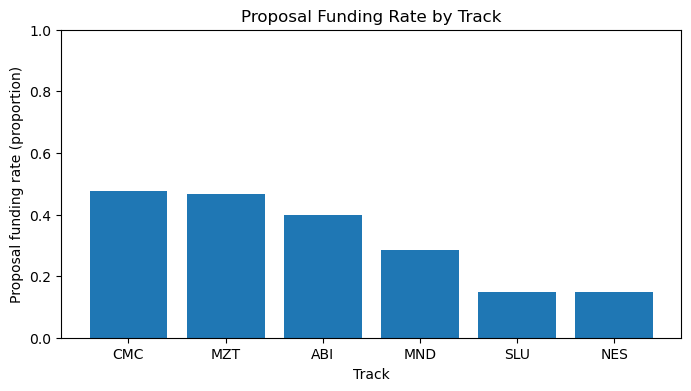

In [21]:
import os, json, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


# ============================================================
# 0) REQUIRE measurement_df
# ============================================================
if "measurement_df" not in globals():
    raise NameError("measurement_df not found. Run the measurement-building chunk first.")


# ============================================================
# 1) LOAD ALL OUTCOME JSON FILES -> teams_df (with year/track)
# ============================================================
# Adjust BASE_DIR if needed
BASE_DIRS = [
    "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data",
    "/mnt/data",  # fallback, if you ever drop outcome jsons here
]

outcome_paths = []
for base in BASE_DIRS:
    if os.path.exists(base):
        outcome_paths.extend(glob.glob(os.path.join(base, "**", "*_outcome.json"), recursive=True))

outcome_paths = sorted(set(outcome_paths))

if not outcome_paths:
    raise FileNotFoundError("No *_outcome.json files found. Check BASE_DIRS.")

print(f"Found {len(outcome_paths)} outcome JSON files.")
for p in outcome_paths[:8]:
    print(" -", p)
if len(outcome_paths) > 8:
    print(" ...")

def parse_year_track_from_path(path: str):
    """
    Expects paths like .../2021MND/2021MND_outcome.json
    Returns (year:int, track:str) or (None, None) if not parseable.
    """
    m = re.search(r"/(\d{4})([A-Z]{3})/(\d{4})([A-Z]{3})_outcome\.json$", path.replace("\\", "/"))
    if not m:
        return None, None
    year = int(m.group(1))
    track = m.group(2)
    return year, track

team_rows = []
for path in outcome_paths:
    with open(path, "r") as f:
        data = json.load(f)

    if not isinstance(data, list) or len(data) == 0:
        continue

    year, track = parse_year_track_from_path(path)

    for d in data:
        # Defensive extraction
        team_id = d.get("team_id", None)
        funded = d.get("funded_status", None)
        members = d.get("members", None)

        if team_id is None or funded is None:
            continue

        mnum = re.search(r"(\d+)$", str(team_id))
        team_num = int(mnum.group(1)) if mnum else None

        team_rows.append({
            "year": year,
            "track": track,
            "team_id": str(team_id),
            "team_num": team_num,
            "funded_status": int(funded),
            "members": members,
            "source_path": path,
        })

teams_df = pd.DataFrame(team_rows)
if teams_df.empty:
    raise ValueError("Loaded outcome JSONs but teams_df is empty. Check file structure.")

# Drop any duplicates (same team_id across sources should not happen, but just in case)
teams_df = teams_df.drop_duplicates(subset=["team_id"]).reset_index(drop=True)

print("\nteams_df shape:", teams_df.shape)
display(teams_df.head())


# ============================================================
# 2) PARSE session_id -> (year, track, team_num)
# ============================================================
# Primary pattern: 2020_11_05_NES_S1
SESSION_PATTERNS = [
    re.compile(r"^(?P<year>\d{4})_\d{2}_\d{2}_(?P<track>[A-Z]{3})_S(?P<num>\d+)$"),
    # Fallback pattern you had: output-2021-05-20-ABI-S1
    re.compile(r"^output-(?P<year>\d{4})-\d{2}-\d{2}-(?P<track>[A-Z]{3})-S(?P<num>\d+)$"),
]

def parse_session_id(session_id: str):
    s = str(session_id)
    for pat in SESSION_PATTERNS:
        m = pat.search(s)
        if m:
            return int(m.group("year")), m.group("track"), int(m.group("num"))
    return None, None, None

tmp = measurement_df[["session_id"]].copy()
tmp[["year", "track", "team_num"]] = tmp["session_id"].apply(lambda x: pd.Series(parse_session_id(x)))

bad = tmp[tmp["year"].isna() | tmp["track"].isna() | tmp["team_num"].isna()]
if len(bad) > 0:
    print(f"\nWarning: {len(bad)} session_id values did not match expected patterns.")
    display(bad.head(10))

# Build team_id
tmp["team_id"] = tmp.apply(
    lambda r: f"{r['track']}{int(r['team_num'])}" if pd.notna(r["track"]) and pd.notna(r["team_num"]) else None,
    axis=1
)

# Map outcomes
funded_map = dict(zip(teams_df["team_id"], teams_df["funded_status"]))
tmp["team_formed"] = tmp["team_id"].apply(lambda t: int(t in funded_map))
tmp["proposal_success"] = tmp["team_id"].map(funded_map).fillna(0).astype(int)

outcomes_df = tmp[["session_id", "year", "track", "team_num", "team_id", "team_formed", "proposal_success"]].copy()

print("\nOutcomes coverage (means):")
print(outcomes_df[["team_formed", "proposal_success"]].mean())
display(outcomes_df.head())


# ============================================================
# 3) MERGE measurement_df + outcomes_df -> model_df
# ============================================================
model_df = measurement_df.merge(outcomes_df, on="session_id", how="inner")

print("\nMerged model_df shape:", model_df.shape)
print("Unique sessions:", model_df["session_id"].nunique())

print("\nOutcome base rates:")
print(model_df[["team_formed", "proposal_success"]].mean())

print("\nOutcome class counts:")
print("team_formed:\n", model_df["team_formed"].value_counts())
print("\nproposal_success:\n", model_df["proposal_success"].value_counts())


# ============================================================
# 4) BUILD FEATURE MATRIX (base + optional cluster + controls)
# ============================================================
BASE_FEATS = [
    "early_seeding",
    "early_commitment",
    "late_synthesis",
    "late_closure",
    "delta_synthesis",
    "delta_closure",
    "delta_stress_mid",
    "jsd_next_overall",
    "prop_facilitator_utterances",
]
BASE_FEATS = [c for c in BASE_FEATS if c in model_df.columns]

y = model_df["proposal_success"].astype(int)

# cluster dummies if present
X_parts = [model_df[BASE_FEATS].copy()]

if "cluster" in model_df.columns:
    cluster_dum = pd.get_dummies(model_df["cluster"], prefix="cluster", drop_first=True)
    X_parts.append(cluster_dum)

# controls
track_dum = pd.get_dummies(model_df["track"].astype(str), prefix="track", drop_first=True)
year_col = model_df[["year"]].astype(float)

X_parts.append(track_dum)
X_parts.append(year_col)

X = pd.concat(X_parts, axis=1)

print("\nX shape:", X.shape)
print("X columns:", X.columns.tolist())


# ============================================================
# 5) CV EVAL (AUC + PR-AUC) with guardrails
# ============================================================
def safe_n_splits(y, max_splits=5):
    return max(2, min(max_splits, int(y.value_counts().min())))

def eval_model(X, y, label):
    if y.nunique() < 2:
        print(f"\n[{label}] Skipping: single-class outcome.")
        return

    if y.value_counts().min() < 2:
        print(f"\n[{label}] Skipping: minority class <2 samples.")
        return

    n_splits = safe_n_splits(y, max_splits=5)
    print(f"\n[{label}] class counts: {y.value_counts().to_dict()} | using n_splits={n_splits}")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs"))
    ])

    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", error_score=np.nan)
    pr_aucs = cross_val_score(pipe, X, y, cv=cv, scoring="average_precision", error_score=np.nan)

    aucs = aucs[~np.isnan(aucs)]
    pr_aucs = pr_aucs[~np.isnan(pr_aucs)]

    print(f"[{label}] AUCs:", np.round(aucs, 3))
    print(f"[{label}] Mean AUC: {aucs.mean():.3f} ± {aucs.std():.3f}")
    print(f"[{label}] PR-AUC mean: {pr_aucs.mean():.3f} ± {pr_aucs.std():.3f}")

eval_model(X, y, "PROPOSAL SUCCESS (FUNDED)")


# ============================================================
# 6) FULL FIT + COEFFICIENTS (printed correctly)
# ============================================================
pipe_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs"))
])
pipe_full.fit(X, y)

coef = pipe_full.named_steps["clf"].coef_.ravel()
coef_df = (
    pd.DataFrame({"feature": X.columns, "coef": coef})
    .sort_values("coef", ascending=False)
    .reset_index(drop=True)
)

print("\nTop positive predictors:")
display(coef_df.head(12))

print("\nTop negative predictors:")
display(coef_df.tail(12))


# ============================================================
# 7) INTERPRETABLE BASELINE PLOTS (by track)
# ============================================================
track_rates = model_df.groupby("track")["proposal_success"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(track_rates.index.astype(str), track_rates.values)
plt.xlabel("Track")
plt.ylabel("Proposal funding rate (proportion)")
plt.ylim(0, 1)
plt.title("Proposal Funding Rate by Track")
plt.show()

## right idea, was using the wrong json file, updating the json file.

earlier chunks were using something like this '/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021NES/2021NES_outcome.json'

I was supposed to use something like this '/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021NES/2021NES_session_outcomes.json'

Found 8 session outcome JSON files.
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2020NES/2020NES_session_outcomes.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021CMC/2021CMC_session_outcomes.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021MND/2021MND_session_outcomes.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021MZT/2021MZT_session_outcomes.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021NES/2021NES_session_outcomes.json
 - /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021SLU/

,session_id,year,track,team_num,n_speakers,n_facilitators,n_teams_total,n_teams_in_session,n_funded_in_session,team_formed,proposal_success,prop_speakers_on_team,source_path
0,2020_11_05_NES_S1,2020,NES,1,12,0,1,1,0,1,0,0.166667,/Users/maxchalekson/Northwestern University/Su...
1,2020_11_06_NES_S7,2020,NES,7,12,0,2,2,0,1,0,0.333333,/Users/maxchalekson/Northwestern University/Su...
2,2020_11_06_NES_S10,2020,NES,10,11,1,0,0,0,0,0,0.000000,/Users/maxchalekson/Northwestern University/Su...
3,2020_11_05_NES_S6,2020,NES,6,9,1,2,2,0,1,0,0.555556,/Users/maxchalekson/Northwestern University/Su...
4,2020_11_06_NES_S11,2020,NES,11,10,0,3,3,1,1,1,0.400000,/Users/maxchalekson/Northwestern University/Su...



Outcome base rates:
team_formed         0.783439
proposal_success    0.433121
dtype: float64

Outcome class counts:
team_formed:
 team_formed
1    123
0     34
Name: count, dtype: int64 

proposal_success:
 proposal_success
0    89
1    68
Name: count, dtype: int64 



,session_id,year,track,team_num,n_speakers,n_facilitators,n_teams_total,n_teams_in_session,n_funded_in_session,team_formed,proposal_success,prop_speakers_on_team,source_path
0,2020_11_05_NES_S1,2020,NES,1,12,0,1,1,0,1,0,0.166667,/Users/maxchalekson/Northwestern University/Su...
1,2020_11_05_NES_S2,2020,NES,2,11,0,3,3,0,1,0,0.545455,/Users/maxchalekson/Northwestern University/Su...
2,2020_11_05_NES_S3,2020,NES,3,10,0,3,3,1,1,1,0.400000,/Users/maxchalekson/Northwestern University/Su...
3,2020_11_05_NES_S4,2020,NES,4,9,1,1,1,1,1,1,0.222222,/Users/maxchalekson/Northwestern University/Su...
4,2020_11_05_NES_S5,2020,NES,5,11,0,1,1,1,1,1,0.181818,/Users/maxchalekson/Northwestern University/Su...



Merged model_df shape: (157, 51)
Unique sessions: 157

X shape: (157, 18)
X columns: ['early_seeding', 'early_commitment', 'late_synthesis', 'late_closure', 'delta_synthesis', 'delta_closure', 'delta_stress_mid', 'jsd_next_overall', 'prop_facilitator_utterances', 'cluster_1', 'cluster_2', 'cluster_3', 'track_CMC', 'track_MND', 'track_MZT', 'track_NES', 'track_SLU', 'year']


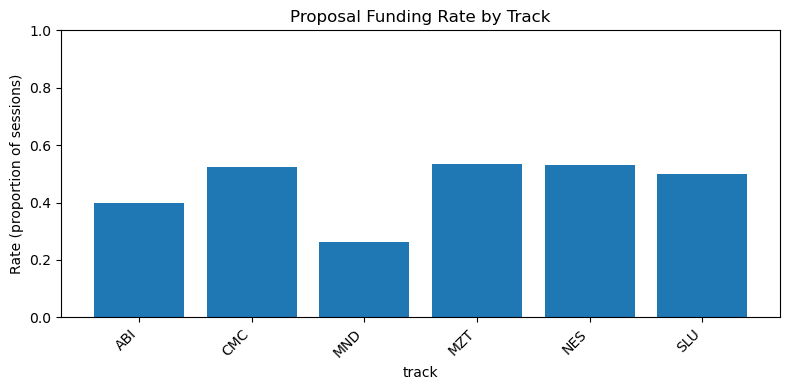

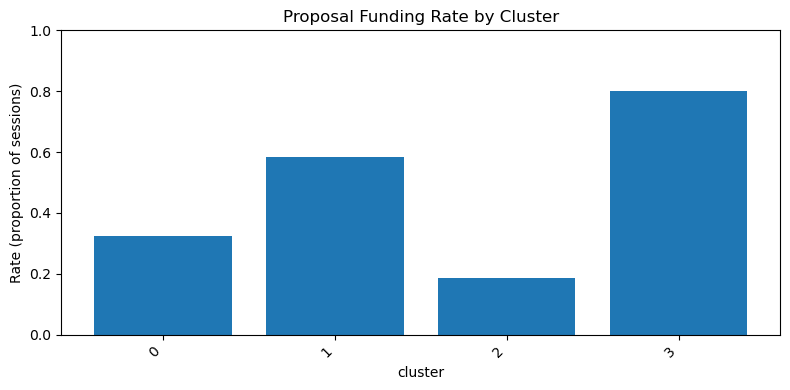


[TEAM FORMATION] class counts: {1: 123, 0: 34} | using n_splits=5
[TEAM FORMATION] AUCs: [0.377 0.72  0.447 0.357 0.393]
[TEAM FORMATION] Mean AUC: 0.459 ± 0.134
[TEAM FORMATION] PR-AUC mean: 0.775 ± 0.066

[PROPOSAL SUCCESS (FUNDED)] class counts: {0: 89, 1: 68} | using n_splits=5
[PROPOSAL SUCCESS (FUNDED)] AUCs: [0.829 0.687 0.645 0.568 0.542]
[PROPOSAL SUCCESS (FUNDED)] Mean AUC: 0.654 ± 0.102
[PROPOSAL SUCCESS (FUNDED)] PR-AUC mean: 0.630 ± 0.104

[PROPOSAL SUCCESS (FUNDED)] Top positive predictors:


,feature,coef
0,cluster_1,0.473611
1,late_closure,0.406888
2,prop_facilitator_utterances,0.397052
3,delta_closure,0.344290
4,delta_stress_mid,0.298072
5,track_NES,0.185922
6,early_seeding,0.175052
7,track_SLU,0.169315
8,track_MZT,0.165112
9,track_CMC,0.064440



[PROPOSAL SUCCESS (FUNDED)] Top negative predictors:


,feature,coef
6,early_seeding,0.175052
7,track_SLU,0.169315
8,track_MZT,0.165112
9,track_CMC,0.064440
10,late_synthesis,0.045638
11,cluster_3,0.012874
12,track_MND,-0.053379
13,early_commitment,-0.074851
14,cluster_2,-0.198709
15,year,-0.235025


In [22]:
import os, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ============================================================
# 0) LOAD *SESSION* OUTCOMES JSONs (the ones you actually want)
# ============================================================

# Change this if your directory differs
ROOT_DIRS = [
    "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data",
    "/mnt/data",  # fallback for attached files in this environment
]

def find_session_outcome_files(root_dirs):
    paths = []
    for root in root_dirs:
        if not os.path.isdir(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if fn.endswith("_session_outcomes.json"):
                    paths.append(os.path.join(dirpath, fn))
    return sorted(set(paths))

session_outcome_files = find_session_outcome_files(ROOT_DIRS)
if not session_outcome_files:
    raise FileNotFoundError(
        "No *_session_outcomes.json files found. Checked:\n" + "\n".join(ROOT_DIRS)
    )

print(f"Found {len(session_outcome_files)} session outcome JSON files.")
for p in session_outcome_files[:10]:
    print(" -", p)
if len(session_outcome_files) > 10:
    print(" ...")

# ------------------------------------------------------------
# Parse session_id -> (year, track, team_num) robustly
# Supports:
#   2021_11_04_NES_S5
#   output-2021-05-20-ABI-S1
# ------------------------------------------------------------
def parse_session_id(session_id: str):
    s = str(session_id)

    m1 = re.search(r"^(20\d{2})_\d{2}_\d{2}_([A-Z]{3})_S(\d+)$", s)
    if m1:
        return int(m1.group(1)), m1.group(2), int(m1.group(3))

    m2 = re.search(r"^output-(20\d{2})-\d{2}-\d{2}-([A-Z]{3})-S(\d+)$", s)
    if m2:
        return int(m2.group(1)), m2.group(2), int(m2.group(3))

    return None, None, None

# ------------------------------------------------------------
# Build one big session_outcomes table across all conferences
# Each file is a dict keyed by session_id:
#   {
#     "2021_11_04_NES_S5": {"all_speakers": [...], "facilitators": [...], "teams": {...}},
#     ...
#   }
# ------------------------------------------------------------
rows = []
for path in session_outcome_files:
    with open(path, "r") as f:
        d = json.load(f)

    if not isinstance(d, dict):
        print(f"Skipping unexpected format (not dict): {path}")
        continue

    for sid, info in d.items():
        if not isinstance(info, dict):
            continue

        all_speakers = info.get("all_speakers", []) or []
        facilitators = info.get("facilitators", []) or []
        teams = info.get("teams", {}) or {}

        # teams is expected dict: { "NES5": {"members":[...], "funded_status":0/1}, ... }
        # We'll compute "session-relevant" teams based on intersection with speakers.
        speaker_set = set([str(x).strip() for x in all_speakers])

        n_teams_total = 0
        n_teams_with_session_members = 0
        n_funded_with_session_members = 0

        members_union = set()

        if isinstance(teams, dict):
            for team_id, tinfo in teams.items():
                if not isinstance(tinfo, dict):
                    continue
                n_teams_total += 1

                mems = tinfo.get("members", []) or []
                mem_set = set([str(x).strip() for x in mems])

                # session-relevant team: at least one member actually appears in the session speakers
                if speaker_set and (mem_set & speaker_set):
                    n_teams_with_session_members += 1
                    members_union |= (mem_set & speaker_set)

                    funded = int(tinfo.get("funded_status", 0) or 0)
                    if funded == 1:
                        n_funded_with_session_members += 1

        team_formed = int(n_teams_with_session_members > 0)
        proposal_success = int(n_funded_with_session_members > 0)

        year, track, team_num = parse_session_id(sid)

        rows.append({
            "session_id": sid,
            "year": year,
            "track": track,
            "team_num": team_num,
            "n_speakers": len(speaker_set),
            "n_facilitators": len(set([str(x).strip() for x in facilitators])),
            "n_teams_total": n_teams_total,
            "n_teams_in_session": n_teams_with_session_members,
            "n_funded_in_session": n_funded_with_session_members,
            "team_formed": team_formed,
            "proposal_success": proposal_success,
            "prop_speakers_on_team": (len(members_union) / len(speaker_set)) if len(speaker_set) else np.nan,
            "source_path": path,
        })

session_outcomes_df = pd.DataFrame(rows)

print("\nsession_outcomes_df shape:", session_outcomes_df.shape)
display(session_outcomes_df.head())

# ============================================================
# 1) BUILD outcomes_df aligned to measurement_df
# ============================================================
if "measurement_df" not in globals():
    raise NameError("measurement_df not found. Run your measurement-building chunk first.")

outcomes_df = (
    measurement_df[["session_id"]]
    .merge(
        session_outcomes_df.drop_duplicates("session_id"),
        on="session_id",
        how="left"
    )
)

# Handle sessions that didn't match the naming pattern (year/track missing)
bad = outcomes_df[outcomes_df["track"].isna()][["session_id", "year", "track", "team_num"]]
if len(bad) > 0:
    print(f"\nWarning: {len(bad)} session_id values did not match expected patterns (year/track/team_num missing).")
    display(bad.head(20))

# If a session is missing in session outcomes entirely, default to "no team formed, not funded"
outcomes_df["team_formed"] = outcomes_df["team_formed"].fillna(0).astype(int)
outcomes_df["proposal_success"] = outcomes_df["proposal_success"].fillna(0).astype(int)

# year can be useful as a numeric covariate; keep as float or int where available
# track is categorical; may be NaN for malformed IDs
print("\nOutcome base rates:")
print(outcomes_df[["team_formed", "proposal_success"]].mean())

print("\nOutcome class counts:")
for col in ["team_formed", "proposal_success"]:
    print(f"{col}:\n", outcomes_df[col].value_counts(dropna=False), "\n")

display(outcomes_df.head())

# ============================================================
# 2) MERGE measurement + outcomes
# ============================================================
model_df = measurement_df.merge(outcomes_df, on="session_id", how="inner")

print("\nMerged model_df shape:", model_df.shape)
print("Unique sessions:", model_df["session_id"].nunique())

# ============================================================
# 3) BUILD X, y (with controls)
# ============================================================
base_numeric_feats = [
    "early_seeding",
    "early_commitment",
    "late_synthesis",
    "late_closure",
    "delta_synthesis",
    "delta_closure",
    "delta_stress_mid",
    "jsd_next_overall",
    "prop_facilitator_utterances",
]
base_numeric_feats = [c for c in base_numeric_feats if c in model_df.columns]

X_parts = [model_df[base_numeric_feats].copy()]

# cluster dummies if present
if "cluster" in model_df.columns:
    X_parts.append(pd.get_dummies(model_df["cluster"], prefix="cluster", drop_first=True))

# track controls if present
if "track" in model_df.columns:
    X_parts.append(pd.get_dummies(model_df["track"], prefix="track", drop_first=True))

# year control if present and non-null
if "year" in model_df.columns:
    # keep numeric year; fill missing with median year to avoid dropping rows
    year_series = pd.to_numeric(model_df["year"], errors="coerce")
    if year_series.notna().any():
        X_parts.append(year_series.fillna(year_series.median()).rename("year").to_frame())

X = pd.concat(X_parts, axis=1).fillna(0)

y_team = model_df["team_formed"].astype(int)
y_prop = model_df["proposal_success"].astype(int)

print("\nX shape:", X.shape)
print("X columns:", X.columns.tolist())

# ============================================================
# 4) CLEAN PLOTS WITH UNITS/LABELS
# ============================================================
def plot_rate_by_group(df, group_col, outcome_col, title):
    if group_col not in df.columns:
        print(f"Skipping plot; missing {group_col}")
        return
    rates = df.groupby(group_col)[outcome_col].mean().sort_index()
    plt.figure(figsize=(8, 4))
    plt.bar(rates.index.astype(str), rates.values)
    plt.xlabel(group_col)
    plt.ylabel("Rate (proportion of sessions)")
    plt.ylim(0, 1)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_rate_by_group(model_df, "track", "proposal_success", "Proposal Funding Rate by Track")
if "cluster" in model_df.columns:
    plot_rate_by_group(model_df, "cluster", "proposal_success", "Proposal Funding Rate by Cluster")

# ============================================================
# 5) MODEL EVAL (AUC + PR-AUC) with guardrails
# ============================================================
def eval_logreg(X, y, label, n_splits=5):
    y = pd.Series(y).astype(int)

    if y.nunique() < 2:
        print(f"\n[{label}] Skipping: single-class outcome.")
        return

    # if minority class too small, reduce folds so StratifiedKFold doesn't implode
    class_counts = y.value_counts().to_dict()
    min_class = min(class_counts.values())
    use_splits = min(n_splits, max(2, min_class))  # at least 2 folds
    print(f"\n[{label}] class counts: {class_counts} | using n_splits={use_splits}")

    cv = StratifiedKFold(n_splits=use_splits, shuffle=True, random_state=42)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])

    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    pr_aucs = cross_val_score(pipe, X, y, cv=cv, scoring="average_precision")

    print(f"[{label}] AUCs:", np.round(aucs, 3))
    print(f"[{label}] Mean AUC: {aucs.mean():.3f} ± {aucs.std():.3f}")
    print(f"[{label}] PR-AUC mean: {pr_aucs.mean():.3f} ± {pr_aucs.std():.3f}")

eval_logreg(X, y_team, "TEAM FORMATION")
eval_logreg(X, y_prop, "PROPOSAL SUCCESS (FUNDED)")

# ============================================================
# 6) FIT FULL MODEL + COEFFICIENT TABLE (interpretability)
# ============================================================
def fit_and_show_coefs(X, y, label, top_k=12):
    y = pd.Series(y).astype(int)
    if y.nunique() < 2:
        print(f"\n[{label}] Skipping coef table: single-class outcome.")
        return

    pipe_full = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])
    pipe_full.fit(X, y)

    coef = pipe_full.named_steps["clf"].coef_.ravel()
    coef_df = (
        pd.DataFrame({"feature": X.columns, "coef": coef})
        .sort_values("coef", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n[{label}] Top positive predictors:")
    display(coef_df.head(top_k))

    print(f"\n[{label}] Top negative predictors:")
    display(coef_df.tail(top_k))

fit_and_show_coefs(X, y_prop, "PROPOSAL SUCCESS (FUNDED)")

# I THINK THESE NEXT FEW CODE CHUNKS ARE THE CULMINATION OF EVERYTHING

Funding CV metrics: AUC=0.646 | PR-AUC=0.572


/var/folders/wp/cn7__9416yj3c5_vcykys8hc0000gn/T/ipykernel_60716/390545000.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = df.groupby("bin").agg(


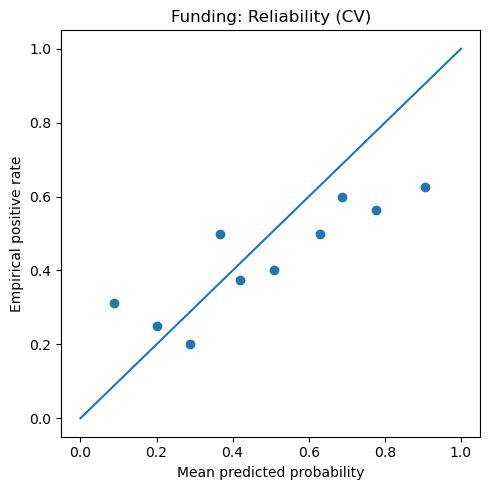

,bin,mean_p,frac_pos,n
0,"(0.00042, 0.169]",0.089165,0.3125,16
1,"(0.169, 0.232]",0.201281,0.2500,16
2,"(0.232, 0.331]",0.286966,0.2000,15
3,"(0.331, 0.395]",0.367256,0.5000,16
4,"(0.395, 0.469]",0.418378,0.3750,16
5,"(0.469, 0.598]",0.508271,0.4000,15
6,"(0.598, 0.656]",0.628499,0.5000,16
7,"(0.656, 0.73]",0.688106,0.6000,15
8,"(0.73, 0.824]",0.775840,0.5625,16
9,"(0.824, 1.0]",0.906645,0.6250,16


Best F1 threshold (CV): t=0.334 | precision=0.514 | recall=0.824 | f1=0.633
Confusion matrix [[TN, FP],[FN, TP]]:
 [[36 53]
 [12 56]]

Funding metrics by track:


,group,n,auc,prauc,base_rate
2,MND,42,0.486804,0.280962,0.261905
4,NES,34,0.704861,0.778521,0.529412
0,ABI,25,0.633333,0.577501,0.400000
1,CMC,21,0.727273,0.778571,0.523810
5,SLU,20,0.540000,0.608549,0.500000
3,MZT,15,0.571429,0.581022,0.533333



Funding metrics by cluster:


,group,n,auc,prauc,base_rate
0,0,71,0.532609,0.365703,0.323944
1,1,65,0.584795,0.640166,0.584615
2,2,16,0.384615,0.212500,0.187500
3,3,5,0.250000,0.804167,0.800000



Funding metrics by year:


,group,n,auc,prauc,base_rate
1,2021,123,0.655663,0.583945,0.439024
2,2022,18,0.375000,0.303973,0.333333
0,2020,16,0.734375,0.808333,0.500000



Top 25 cases to inspect (biggest errors / highest confidence):


,session_id,track,year,cluster,proposal_success,p_funded_cv,team_formed,prop_facilitator_utterances,error
147,2022_04_08_MND_S12,MND,2022,3,0,0.996794,0,0.166667,1
97,2021_10_01_MZT_S8,MZT,2021,1,0,0.944502,1,0.538889,1
59,2021_05_21_ABI_S5,ABI,2021,1,0,0.900494,0,0.453020,1
130,2021_11_05_NES_S2,NES,2021,1,0,0.892249,1,0.374233,1
92,2021_10_01_MZT_S2,MZT,2021,1,0,0.879218,1,0.558011,1
70,2021_06_10_SLU_S7,SLU,2021,1,0,0.836086,0,0.482927,1
29,2021_04_23_MND_S14,MND,2021,0,0,0.812520,0,0.000000,1
37,2021_04_23_MND_S7,MND,2021,1,0,0.803345,1,0.000000,1
85,2021_09_30_MZT_S3,MZT,2021,1,0,0.783783,1,0.203252,1
119,2021_10_08_CMC_S9,CMC,2021,0,0,0.772768,1,0.483696,1


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve
)

# ============================================================
# 7) CROSS-VALIDATED PRED PROBS PER SESSION (NO LEAKY EGO)
# ============================================================
def cv_predict_proba(X, y, n_splits=5, random_state=42):
    y = pd.Series(y).astype(int)
    if y.nunique() < 2:
        return None

    counts = y.value_counts().to_dict()
    min_class = min(counts.values())
    use_splits = min(n_splits, max(2, min_class))

    cv = StratifiedKFold(n_splits=use_splits, shuffle=True, random_state=random_state)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])

    proba = np.zeros(len(y), dtype=float)

    for train_idx, test_idx in cv.split(X, y):
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba[test_idx] = pipe.predict_proba(X.iloc[test_idx])[:, 1]

    return proba

# Funding predictions
fund_proba = cv_predict_proba(X, model_df["proposal_success"])
if fund_proba is None:
    print("Funding: single-class outcome, cannot compute CV probabilities.")
else:
    model_df = model_df.copy()
    model_df["p_funded_cv"] = fund_proba

    y_true = model_df["proposal_success"].astype(int).values
    auc = roc_auc_score(y_true, fund_proba)
    prauc = average_precision_score(y_true, fund_proba)
    print(f"Funding CV metrics: AUC={auc:.3f} | PR-AUC={prauc:.3f}")

# Team formation predictions (only if non-single-class)
team_proba = cv_predict_proba(X, model_df["team_formed"])
if team_proba is not None:
    model_df["p_teamformed_cv"] = team_proba

# ============================================================
# 8) CALIBRATION / RELIABILITY PLOT (FUNDING)
# ============================================================
def reliability_plot(y_true, p, title, n_bins=10):
    df = pd.DataFrame({"y": y_true, "p": p}).dropna()
    df["bin"] = pd.qcut(df["p"], q=n_bins, duplicates="drop")
    calib = df.groupby("bin").agg(
        mean_p=("p", "mean"),
        frac_pos=("y", "mean"),
        n=("y", "size")
    ).reset_index()

    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1])
    plt.scatter(calib["mean_p"], calib["frac_pos"])
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Empirical positive rate")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return calib

if "p_funded_cv" in model_df.columns:
    calib = reliability_plot(
        model_df["proposal_success"].astype(int),
        model_df["p_funded_cv"],
        "Funding: Reliability (CV)"
    )
    display(calib)

# ============================================================
# 9) PICK A THRESHOLD (PR CURVE) + CONFUSION MATRIX
# ============================================================
def pick_threshold_by_f1(y_true, p):
    prec, rec, thresh = precision_recall_curve(y_true, p)
    # thresh length is (len(prec)-1)
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
    best_i = np.argmax(f1)
    return thresh[best_i], prec[best_i], rec[best_i], f1[best_i]

if "p_funded_cv" in model_df.columns:
    y_true = model_df["proposal_success"].astype(int).values
    p = model_df["p_funded_cv"].values

    t, best_p, best_r, best_f1 = pick_threshold_by_f1(y_true, p)
    print(f"Best F1 threshold (CV): t={t:.3f} | precision={best_p:.3f} | recall={best_r:.3f} | f1={best_f1:.3f}")

    y_hat = (p >= t).astype(int)
    cm = confusion_matrix(y_true, y_hat)
    print("Confusion matrix [[TN, FP],[FN, TP]]:\n", cm)

# ============================================================
# 10) WHERE DOES IT WORK / FAIL? (GROUPED DIAGNOSTICS)
# ============================================================
def grouped_metrics(df, group_col, y_col, p_col):
    if group_col not in df.columns:
        return None
    out = []
    for g, sub in df.groupby(group_col):
        y = sub[y_col].astype(int).values
        p = sub[p_col].values
        if len(np.unique(y)) < 2:
            out.append({"group": g, "n": len(sub), "auc": np.nan, "prauc": np.nan, "base_rate": y.mean()})
        else:
            out.append({"group": g, "n": len(sub), "auc": roc_auc_score(y, p), "prauc": average_precision_score(y, p), "base_rate": y.mean()})
    return pd.DataFrame(out).sort_values("n", ascending=False)

if "p_funded_cv" in model_df.columns:
    print("\nFunding metrics by track:")
    display(grouped_metrics(model_df, "track", "proposal_success", "p_funded_cv"))

    if "cluster" in model_df.columns:
        print("\nFunding metrics by cluster:")
        display(grouped_metrics(model_df, "cluster", "proposal_success", "p_funded_cv"))

    if "year" in model_df.columns:
        print("\nFunding metrics by year:")
        display(grouped_metrics(model_df, "year", "proposal_success", "p_funded_cv"))

# ============================================================
# 11) SAVE A "REVIEW TABLE" OF HARD CASES
# ============================================================
# This is the bridge back to qualitative inspection: look at false positives / false negatives.
if "p_funded_cv" in model_df.columns:
    df_review = model_df[[
        "session_id", "track", "year", "cluster",
        "proposal_success", "p_funded_cv",
        "team_formed", "prop_facilitator_utterances"
    ]].copy()

    df_review["error"] = np.abs(df_review["proposal_success"] - (df_review["p_funded_cv"] >= 0.5).astype(int))
    df_review = df_review.sort_values(["error", "p_funded_cv"], ascending=[False, False])

    print("\nTop 25 cases to inspect (biggest errors / highest confidence):")
    display(df_review.head(25))

In [26]:
import os, json, glob, re
import numpy as np
import pandas as pd

# ============================================================
# 0) REQUIREMENTS: need review_cases or model_df to pick sessions
# ============================================================
if "review_cases" in globals():
    target_session_ids = sorted(review_cases["session_id"].unique())
    meta_df = review_cases.copy()
elif "model_df" in globals():
    target_session_ids = sorted(model_df["session_id"].unique())
    meta_df = model_df[["session_id"]].copy()
else:
    raise NameError("Need either review_cases or model_df in memory to know which sessions to load.")

DATA_ROOT = "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data"

# ============================================================
# 1) INDEX session_data JSONs: session_id -> file path
# ============================================================
session_json_paths = glob.glob(os.path.join(DATA_ROOT, "*", "session_data", "*.json"))
if not session_json_paths:
    raise FileNotFoundError(f"No session_data JSONs found under: {DATA_ROOT}/*/session_data/*.json")

session_path_map = {os.path.splitext(os.path.basename(p))[0]: p for p in session_json_paths}

missing_paths = [sid for sid in target_session_ids if sid not in session_path_map]
if missing_paths:
    print(f"Warning: {len(missing_paths)} target sessions not found under session_data/ (showing up to 15):")
    print(missing_paths[:15])

print(f"Session JSON index built: {len(session_path_map)} files")
print(f"Target sessions requested: {len(target_session_ids)} | found paths for: {len(target_session_ids) - len(missing_paths)}")

# ============================================================
# 2) HELPERS
# ============================================================
def _get_utterances(payload: dict):
    """
    Your example session json uses 'all_data' as the utterance list.
    This tries a bunch of known keys + light recursion.
    """
    for key in ["all_data", "utterances", "utterance_list", "transcript", "segments", "turns"]:
        if key in payload and isinstance(payload[key], list):
            return payload[key]

    # sometimes nested
    for key in ["data", "session", "content", "payload"]:
        if key in payload and isinstance(payload[key], dict):
            out = _get_utterances(payload[key])
            if out is not None:
                return out
    return None

def _parse_time_to_sec(x):
    """
    Handles numeric seconds OR strings like:
    - 'HH:MM:SS'
    - 'MM:SS'
    - 'SS'
    """
    if x is None:
        return None
    if isinstance(x, (int, float)) and np.isfinite(x):
        return float(x)

    s = str(x).strip()
    if not s:
        return None

    # If it's like "12.34"
    try:
        return float(s)
    except Exception:
        pass

    # If it's time-like "HH:MM:SS" or "MM:SS"
    parts = s.split(":")
    try:
        parts = [float(p) for p in parts]
    except Exception:
        return None

    if len(parts) == 3:
        h, m, sec = parts
        return 3600*h + 60*m + sec
    if len(parts) == 2:
        m, sec = parts
        return 60*m + sec
    if len(parts) == 1:
        return parts[0]
    return None

def _get_time(u: dict):
    """
    Try common timing fields in your session_data json.
    Your example has start_time/end_time/timestamp as strings.
    """
    for k in ["global_timestamp_sec", "start_sec_adjusted", "start_sec", "start_time", "timestamp", "t"]:
        if k in u:
            t = _parse_time_to_sec(u.get(k))
            if t is not None:
                return t
    return None

def _get_text(u: dict):
    for tk in ["transcript", "text", "utterance", "content"]:
        v = u.get(tk)
        if isinstance(v, str):
            return v
    return None

def _extract_labels_and_phase(u: dict):
    """
    Your example: u["annotations"] is a dict:
      { "<LABEL>": {"explanation": "...", "when": "beginning"} , ... }
    Also supports list-style annotations.
    Returns: (labels:list[str], phase:str|None)
    """
    ann = u.get("annotations", None)
    phase = None
    labels = []

    if ann is None:
        return labels, phase

    # dict-of-labels
    if isinstance(ann, dict):
        for label, info in ann.items():
            if label:
                labels.append(str(label))
            if phase is None and isinstance(info, dict) and "when" in info:
                phase = info.get("when")
        return labels, phase

    # list-style annotations
    if isinstance(ann, list):
        for item in ann:
            if isinstance(item, str):
                labels.append(item)
            elif isinstance(item, dict):
                # try label-ish keys
                for k in ["label", "code", "name", "annotation"]:
                    if k in item and item[k]:
                        labels.append(str(item[k]))
                        break
                if phase is None and "when" in item:
                    phase = item.get("when")
        return labels, phase

    # string
    if isinstance(ann, str):
        return [ann], phase

    return labels, phase

def _normalize_phase(p):
    if p is None:
        return None
    s = str(p).strip().lower()
    if "begin" in s or "early" in s:
        return "beginning"
    if "mid" in s:
        return "middle"
    if "end" in s or "late" in s:
        return "end"
    return None

# OPTIONAL: map raw annotation labels -> your 4 idea-state buckets.
# If you don't fill this, we'll just use the raw labels.
LABEL_TO_IDEASTATE = {
    # "Some label name": "Seeding",
    # "Some other label": "Stress-testing",
    # ...
}
def label_to_state(lbl: str):
    return LABEL_TO_IDEASTATE.get(lbl, None)

# ============================================================
# 3) LOAD UTTERANCES + (MULTI-)ANNOTATIONS INTO LONG DF
# ============================================================
rows = []
loaded = 0
skipped = 0

for sid in target_session_ids:
    p = session_path_map.get(sid)
    if not p:
        skipped += 1
        continue

    try:
        with open(p, "r") as f:
            payload = json.load(f)
    except Exception as e:
        print(f"Failed to load {sid}: {e}")
        skipped += 1
        continue

    utts = _get_utterances(payload)
    if not utts:
        # debug once in a while if you want:
        # print("No utterances found in:", sid, "top-level keys:", list(payload.keys())[:20])
        skipped += 1
        continue

    for i, u in enumerate(utts):
        t = _get_time(u)
        text = _get_text(u)
        labels, phase = _extract_labels_and_phase(u)
        phase = _normalize_phase(phase)

        # If there are no labels, keep one row anyway (so timing exists)
        if not labels:
            rows.append({
                "session_id": sid,
                "utt_idx": i,
                "t": t,
                "phase": phase,
                "label": None,
                "idea_state": None,
                "transcript": text,
                "source_path": p,
            })
        else:
            for lbl in labels:
                rows.append({
                    "session_id": sid,
                    "utt_idx": i,
                    "t": t,
                    "phase": phase,
                    "label": lbl,
                    "idea_state": label_to_state(lbl),
                    "transcript": text,
                    "source_path": p,
                })

    loaded += 1

U = pd.DataFrame(rows)

print(f"Loaded sessions: {loaded} | skipped (missing/unreadable/no-utterances): {skipped}")
print("Utterance rows:", U.shape)
if U.empty:
    raise ValueError(
        "Built 0 utterance rows. This means none of the target sessions had a recognizable utterance list.\n"
        "Fix: print top-level keys from one session json and add its utterance key to _get_utterances()."
    )

# Fill time if missing
if U["t"].isna().all():
    print("Warning: No usable time field found. Falling back to utt_idx ordering as time.")
    U["t"] = U["utt_idx"].astype(float)
else:
    U["t"] = U["t"].fillna(U["utt_idx"].astype(float))

# ============================================================
# 4) BUILD FLOW FEATURES
#    Prefer phase=beginning/middle/end if present; else time-bin.
# ============================================================
use_phase = U["phase"].notna().any()
print("Using phase-based flow?" , use_phase)

if use_phase:
    # Use idea_state if you mapped labels -> states; else use raw labels
    flow_key = "idea_state" if U["idea_state"].notna().any() else "label"

    tmp = U.copy()
    tmp[flow_key] = tmp[flow_key].fillna("UNLABELED")

    flow = (
        tmp.groupby(["session_id", "phase", flow_key])
        .size()
        .reset_index(name="n")
    )
    flow["phase_total"] = flow.groupby(["session_id", "phase"])["n"].transform("sum")
    flow["prop"] = flow["n"] / flow["phase_total"]

    flow_wide = (
        flow.pivot_table(index=["session_id", "phase"], columns=flow_key, values="prop", fill_value=0)
        .reset_index()
    )

    # turn phase into prefix columns: beginning_X, middle_X, end_X
    feat_frames = []
    for ph in ["beginning", "middle", "end"]:
        ph_df = flow_wide[flow_wide["phase"] == ph].drop(columns=["phase"], errors="ignore").set_index("session_id")
        ph_df = ph_df.add_prefix(f"{ph}_")
        feat_frames.append(ph_df)

    flow_feats = pd.concat(feat_frames, axis=1).reset_index()

else:
    # fallback: bin by time within session (quantiles)
    N_BINS = 5
    tmp = U.copy()
    flow_key = "idea_state" if tmp["idea_state"].notna().any() else "label"
    tmp[flow_key] = tmp[flow_key].fillna("UNLABELED")

    def add_time_bin(df):
        t = df["t"].astype(float).values
        if len(t) == 0:
            df["time_bin"] = np.nan
            return df
        qs = np.quantile(t, np.linspace(0, 1, N_BINS + 1))
        qs = np.unique(qs)
        if len(qs) <= 2:
            df["time_bin"] = 0
            return df
        # cut into bins
        df["time_bin"] = pd.cut(df["t"], bins=qs, include_lowest=True, labels=False)
        return df

    tmp = tmp.sort_values(["session_id", "t", "utt_idx"])
    tmp = tmp.groupby("session_id", group_keys=False).apply(add_time_bin)

    flow = (
        tmp.groupby(["session_id", "time_bin", flow_key])
        .size()
        .reset_index(name="n")
    )
    flow["bin_total"] = flow.groupby(["session_id", "time_bin"])["n"].transform("sum")
    flow["prop"] = flow["n"] / flow["bin_total"]

    flow_wide = (
        flow.pivot_table(index=["session_id", "time_bin"], columns=flow_key, values="prop", fill_value=0)
        .reset_index()
    )

    EARLY_BINS = [0, 1]
    LATE_BINS  = [flow_wide["time_bin"].max() - 1, flow_wide["time_bin"].max()]

    early = flow_wide[flow_wide["time_bin"].isin(EARLY_BINS)].groupby("session_id").mean(numeric_only=True).add_prefix("early_")
    late  = flow_wide[flow_wide["time_bin"].isin(LATE_BINS)].groupby("session_id").mean(numeric_only=True).add_prefix("late_")

    flow_feats = early.join(late, how="outer").reset_index()

print("flow_feats shape:", flow_feats.shape)
display(flow_feats.head())

# ============================================================
# 5) JOIN FLOW FEATURES BACK TO META (review_cases or model_df)
# ============================================================
meta_plus = meta_df.merge(flow_feats, on="session_id", how="left")
print("meta_plus shape:", meta_plus.shape)
display(meta_plus.head(10))

# meta_plus is now what you inspect for FP/FN sessions:
# - if review_cases: you can compare FP vs FN flow features
# - then add selected flow columns into X for a next modeling pass

Session JSON index built: 157 files
Target sessions requested: 20 | found paths for: 20
Loaded sessions: 20 | skipped (missing/unreadable/no-utterances): 0
Utterance rows: (5559, 8)
Using phase-based flow? True
flow_feats shape: (20, 28)


label,session_id,beginning_Coordination and Decision Practices,beginning_Evaluation Practices,beginning_Idea Management,beginning_Information Seeking,beginning_Integration Practices,beginning_Knowledge Sharing,beginning_None,beginning_Participation Dynamics,beginning_Relational Climate,...,middle_Relational Climate,end_Coordination and Decision Practices,end_Evaluation Practices,end_Idea Management,end_Information Seeking,end_Integration Practices,end_Knowledge Sharing,end_None,end_Participation Dynamics,end_Relational Climate
0,2020_11_06_NES_S12,0.023256,0.093023,0.209302,0.162791,0.000000,0.255814,0.093023,0.069767,0.093023,...,0.272727,0.061224,0.122449,0.122449,0.102041,0.040816,0.285714,0.000000,0.102041,0.163265
1,2020_11_06_NES_S3,0.000000,0.133333,0.300000,0.033333,0.033333,0.266667,0.000000,0.100000,0.133333,...,0.083333,0.083333,0.041667,0.041667,0.083333,0.000000,0.541667,0.000000,0.041667,0.166667
2,2021_04_22_MND_S4,0.091603,0.022901,0.068702,0.083969,0.015267,0.259542,0.022901,0.068702,0.366412,...,0.130952,0.151079,0.086331,0.136691,0.122302,0.100719,0.165468,0.043165,0.057554,0.136691
3,2021_04_23_MND_S11,0.140625,0.062500,0.203125,0.187500,0.046875,0.265625,0.046875,0.015625,0.031250,...,0.076271,0.173554,0.016529,0.148760,0.157025,0.041322,0.206612,0.066116,0.016529,0.173554
4,2021_04_23_MND_S14,0.080000,0.026667,0.173333,0.160000,0.053333,0.306667,0.026667,0.040000,0.133333,...,0.161905,0.258621,0.034483,0.094828,0.137931,0.043103,0.198276,0.060345,0.025862,0.146552


meta_plus shape: (20, 83)


,session_id,beginning__Seeding,beginning__Stress-testing,beginning__Commitment/Closure,middle__Seeding,middle__Stress-testing,middle__Commitment/Closure,middle__Synthesis,middle__Participation Structuring,middle__Relational Support,...,middle_Relational Climate,end_Coordination and Decision Practices,end_Evaluation Practices,end_Idea Management,end_Information Seeking,end_Integration Practices,end_Knowledge Sharing,end_None,end_Participation Dynamics,end_Relational Climate
0,2022_04_08_MND_S12,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.800000,0.600000,0.000000,0.000000,0.200000,0.000000,0.200000,0.000000,0.000000,0.000000
1,2021_10_01_MZT_S8,0.382353,0.058824,0.205882,0.550000,0.225000,0.000000,0.100000,0.025000,0.025000,...,0.078947,0.159292,0.088496,0.132743,0.159292,0.026549,0.141593,0.061947,0.008850,0.221239
2,2021_05_21_ABI_S5,0.337500,0.087500,0.262500,0.336449,0.289720,0.074766,0.018692,0.074766,0.037383,...,0.128655,0.184971,0.057803,0.167630,0.127168,0.046243,0.167630,0.052023,0.052023,0.144509
3,2021_11_05_NES_S2,0.500000,0.096154,0.211538,0.305556,0.194444,0.194444,0.055556,0.027778,0.111111,...,0.162791,0.219512,0.056911,0.097561,0.097561,0.065041,0.219512,0.032520,0.073171,0.138211
4,2021_10_01_MZT_S2,0.380952,0.047619,0.190476,0.315789,0.157895,0.078947,0.026316,0.236842,0.078947,...,0.191176,0.119565,0.065217,0.195652,0.108696,0.043478,0.152174,0.032609,0.108696,0.173913
5,2021_06_10_SLU_S7,0.348315,0.033708,0.303371,0.258621,0.241379,0.103448,0.034483,0.189655,0.103448,...,0.138614,0.111111,0.128205,0.205128,0.094017,0.068376,0.179487,0.008547,0.085470,0.119658
6,2021_04_23_MND_S14,0.555556,0.044444,0.133333,0.628205,0.051282,0.038462,0.000000,0.012821,0.141026,...,0.161905,0.258621,0.034483,0.094828,0.137931,0.043103,0.198276,0.060345,0.025862,0.146552
7,2021_04_23_MND_S7,0.481481,0.074074,0.148148,0.333333,0.244444,0.022222,0.088889,0.088889,0.155556,...,0.172840,0.180000,0.053333,0.113333,0.093333,0.013333,0.206667,0.080000,0.060000,0.200000
8,2021_09_30_MZT_S3,0.375000,0.166667,0.291667,0.527778,0.166667,0.111111,0.166667,0.000000,0.000000,...,0.057971,0.178947,0.105263,0.157895,0.126316,0.063158,0.168421,0.063158,0.021053,0.115789
9,2021_10_08_CMC_S9,0.438202,0.056180,0.179775,0.500000,0.227273,0.000000,0.090909,0.090909,0.045455,...,0.127660,0.104348,0.078261,0.173913,0.069565,0.017391,0.217391,0.026087,0.043478,0.269565


In [27]:
import numpy as np
import pandas as pd

# ============================================================
# 0) REQUIRE: meta_plus must exist (from the previous chunk)
# ============================================================
if "meta_plus" not in globals():
    raise NameError("meta_plus not found. Run the previous chunk first.")

df = meta_plus.copy()

# ============================================================
# 1) REQUIRE: we need err_type + outcome columns
# ============================================================
needed = {"err_type", "proposal_success", "p_funded_cv"}
missing = needed - set(df.columns)
if missing:
    raise ValueError(f"meta_plus missing columns: {missing}. Make sure meta_df was review_cases (has err_type).")

# ============================================================
# 2) Pick which feature family you want to analyze
#    A) idea-state flow columns: they have a double underscore 'beginning__'
#    B) practice-label flow columns: they look like 'beginning_Knowledge Sharing'
# ============================================================

idea_cols = [c for c in df.columns if c.startswith(("beginning__", "middle__", "end__"))]
label_cols = [c for c in df.columns if c.startswith(("beginning_", "middle_", "end_")) and "__" not in c]

print(f"Idea-state columns: {len(idea_cols)}")
print(f"Label-flow columns: {len(label_cols)}")

# choose one set (you can swap to label_cols if you want that view)
FLOW_COLS = label_cols  # <-- change to idea_cols if you want the 4-state flow

# ============================================================
# 3) Group summary: FP vs FN phase profiles
# ============================================================
grp = (
    df.groupby("err_type")[FLOW_COLS]
      .mean(numeric_only=True)
      .T
      .rename_axis("feature")
      .reset_index()
)

# Pull out FP and FN means (if one type is missing, fill with 0)
fp = grp["FP"] if "FP" in grp.columns else 0.0
fn = grp["FN"] if "FN" in grp.columns else 0.0
grp["FP_minus_FN"] = fp - fn
grp["abs_delta"] = grp["FP_minus_FN"].abs()

# Big drivers
top = grp.sort_values("abs_delta", ascending=False).head(20)

print("\nTop 20 FP vs FN flow differences (higher = more FP-heavy):")
display(top)

# ============================================================
# 4) For quick sanity: show the sessions with strongest FP confidence
# ============================================================
fp_cases = df[df["err_type"] == "FP"].sort_values("p_funded_cv", ascending=False).head(10)
fn_cases = df[df["err_type"] == "FN"].sort_values("p_funded_cv", ascending=True).head(10)

print("\nTop FP (model most confident but actually not funded):")
display(fp_cases[["session_id","track","year","cluster","proposal_success","p_funded_cv","confidence"] + FLOW_COLS[:5]])

print("\nTop FN (model least confident but actually funded):")
display(fn_cases[["session_id","track","year","cluster","proposal_success","p_funded_cv","confidence"] + FLOW_COLS[:5]])

# ============================================================
# 5) Optional: correlation with predicted probability (within review set)
# ============================================================
corrs = (
    df[FLOW_COLS + ["p_funded_cv"]]
      .corr(numeric_only=True)["p_funded_cv"]
      .drop("p_funded_cv")
      .sort_values(ascending=False)
)

print("\nTop + correlations with p_funded_cv (review set only):")
display(corrs.head(15).reset_index().rename(columns={"index":"feature","p_funded_cv":"corr"}))

print("\nTop - correlations with p_funded_cv (review set only):")
display(corrs.tail(15).reset_index().rename(columns={"index":"feature","p_funded_cv":"corr"}))

Idea-state columns: 24
Label-flow columns: 27

Top 20 FP vs FN flow differences (higher = more FP-heavy):


err_type,feature,FN,FP,FP_minus_FN,abs_delta
18,end_Coordination and Decision Practices,0.122004,0.211637,0.089633,0.089633
14,middle_Knowledge Sharing,0.318041,0.233188,-0.084853,0.084853
23,end_Knowledge Sharing,0.257028,0.185115,-0.071913,0.071913
17,middle_Relational Climate,0.143744,0.202056,0.058312,0.058312
2,beginning_Idea Management,0.131653,0.085043,-0.046610,0.046610
10,middle_Evaluation Practices,0.062873,0.103392,0.040519,0.040519
9,middle_Coordination and Decision Practices,0.065161,0.034222,-0.030940,0.030940
0,beginning_Coordination and Decision Practices,0.087515,0.117389,0.029874,0.029874
6,beginning_None,0.048816,0.020981,-0.027834,0.027834
12,middle_Information Seeking,0.157020,0.130154,-0.026866,0.026866



Top FP (model most confident but actually not funded):


,session_id,track,year,cluster,proposal_success,p_funded_cv,confidence,beginning_Coordination and Decision Practices,beginning_Evaluation Practices,beginning_Idea Management,beginning_Information Seeking,beginning_Integration Practices
0,2022_04_08_MND_S12,MND,2022,3,0,0.996794,0.662794,0.000000,0.000000,0.000000,0.333333,0.000000
1,2021_10_01_MZT_S8,MZT,2021,1,0,0.944502,0.610502,0.150538,0.032258,0.064516,0.075269,0.000000
2,2021_05_21_ABI_S5,ABI,2021,1,0,0.900494,0.566494,0.156716,0.052239,0.089552,0.059701,0.000000
3,2021_11_05_NES_S2,NES,2021,1,0,0.892249,0.558249,0.104167,0.052083,0.104167,0.145833,0.000000
4,2021_10_01_MZT_S2,MZT,2021,1,0,0.879218,0.545218,0.123077,0.030769,0.069231,0.123077,0.007692
5,2021_06_10_SLU_S7,SLU,2021,1,0,0.836086,0.502086,0.207692,0.023077,0.061538,0.076923,0.007692
6,2021_04_23_MND_S14,MND,2021,0,0,0.812520,0.478520,0.080000,0.026667,0.173333,0.160000,0.053333
7,2021_04_23_MND_S7,MND,2021,1,0,0.803345,0.469345,0.100000,0.050000,0.050000,0.125000,0.012500
8,2021_09_30_MZT_S3,MZT,2021,1,0,0.783783,0.449783,0.142857,0.081633,0.102041,0.081633,0.020408
9,2021_10_08_CMC_S9,CMC,2021,0,0,0.772768,0.438768,0.108844,0.040816,0.136054,0.136054,0.020408



Top FN (model least confident but actually funded):


,session_id,track,year,cluster,proposal_success,p_funded_cv,confidence,beginning_Coordination and Decision Practices,beginning_Evaluation Practices,beginning_Idea Management,beginning_Information Seeking,beginning_Integration Practices
10,2020_11_06_NES_S12,NES,2020,2,1,0.018621,0.315379,0.023256,0.093023,0.209302,0.162791,0.000000
11,2021_04_23_MND_S11,MND,2021,0,1,0.074936,0.259064,0.140625,0.062500,0.203125,0.187500,0.046875
12,2022_04_07_MND_S6,MND,2022,0,1,0.125388,0.208612,0.089431,0.016260,0.073171,0.121951,0.000000
13,2020_11_06_NES_S3,NES,2020,2,1,0.138559,0.195441,0.000000,0.133333,0.300000,0.033333,0.033333
14,2021_04_22_MND_S4,MND,2021,1,1,0.143854,0.190146,0.091603,0.022901,0.068702,0.083969,0.015267
15,2022_04_07_MND_S4,MND,2022,0,1,0.183988,0.150012,0.126866,0.029851,0.082090,0.126866,0.000000
16,2021_09_30_MZT_S6,MZT,2021,1,1,0.199107,0.134893,0.058824,0.000000,0.058824,0.117647,0.000000
17,2021_05_20_ABI_S7,ABI,2021,0,1,0.222979,0.111021,0.155172,0.025862,0.077586,0.086207,0.008621
18,2022_04_07_MND_S5,MND,2022,1,1,0.229674,0.104326,0.084112,0.018692,0.112150,0.112150,0.000000
19,2022_04_07_MND_S1,MND,2022,0,1,0.272132,0.061868,0.105263,0.035088,0.131579,0.105263,0.000000



Top + correlations with p_funded_cv (review set only):


,feature,corr
0,end_Coordination and Decision Practices,0.485748
1,middle_Evaluation Practices,0.385648
2,beginning_Coordination and Decision Practices,0.281689
3,middle_Relational Climate,0.260698
4,middle_Participation Dynamics,0.256794
5,middle_Integration Practices,0.198179
6,beginning_Relational Climate,0.196845
7,beginning_Participation Dynamics,0.189896
8,middle_None,0.171679
9,beginning_Information Seeking,0.168617



Top - correlations with p_funded_cv (review set only):


,feature,corr
0,end_Idea Management,0.023751
1,end_Evaluation Practices,-0.018077
2,end_None,-0.033951
3,beginning_Integration Practices,-0.044943
4,middle_Idea Management,-0.060025
5,beginning_Knowledge Sharing,-0.101971
6,beginning_Evaluation Practices,-0.179035
7,end_Relational Climate,-0.185942
8,middle_Coordination and Decision Practices,-0.185952
9,end_Integration Practices,-0.197835


In [31]:
import re
import pandas as pd
import numpy as np

# ============================================================
# REQUIREMENTS
# ============================================================
if "U" not in globals():
    raise NameError("U not found. Run the session JSON loading chunk that creates U (utterance-level df).")

if "meta_plus" not in globals():
    raise NameError("meta_plus not found. Run the meta_plus merge chunk first.")

# ============================================================
# 0) Identify columns in U
# ============================================================
# Phase column (beginning/middle/end)
phase_col = None
for c in ["phase", "when", "segment", "part"]:
    if c in U.columns:
        phase_col = c
        break

# Label column (Coordination..., Knowledge Sharing, etc.)
label_col = None
for c in ["label", "category", "practice_label", "annotation_label", "code"]:
    if c in U.columns:
        label_col = c
        break

# Transcript column
text_col = None
for c in ["transcript", "text", "utterance", "content"]:
    if c in U.columns:
        text_col = c
        break

if phase_col is None:
    raise ValueError(f"Could not find a phase column in U. Available columns: {list(U.columns)}")
if label_col is None:
    raise ValueError(f"Could not find a label column in U. Available columns: {list(U.columns)}")
if text_col is None:
    raise ValueError(f"Could not find transcript text column in U. Available columns: {list(U.columns)}")

print(f"Using phase_col='{phase_col}' | label_col='{label_col}' | text_col='{text_col}'")

# ============================================================
# 1) Pick sessions to inspect: top confident FP and top confident FN
# ============================================================
df = meta_plus.copy()

fp_sids = (
    df[df["err_type"] == "FP"]
    .sort_values("p_funded_cv", ascending=False)["session_id"]
    .head(3)
    .tolist()
)

fn_sids = (
    df[df["err_type"] == "FN"]
    .sort_values("p_funded_cv", ascending=True)["session_id"]
    .head(3)
    .tolist()
)

inspect_sids = fp_sids + fn_sids
print("Inspect sessions:")
print("FP:", fp_sids)
print("FN:", fn_sids)

# ============================================================
# 2) Logistics detector (regex + helper)
# ============================================================
LOGISTICS_PAT = re.compile(
    r"\b("
    r"wait|waiting|muted|share your screen|screen share|slides?|powerpoint|ppt|"
    r"time|minutes?|seconds?|breakout|main room|report out|notes|bullet points?|"
    r"kicked|go to|file"
    r")\b",
    flags=re.IGNORECASE
)

def logistics_flag(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return int(bool(LOGISTICS_PAT.search(text)))

tmp = U.copy()
tmp["is_logistics"] = tmp[text_col].apply(logistics_flag)

# ============================================================
# 3) Compute end-coordination logistics share per session
# ============================================================
END_PHASE_VALUE = "end"
COORD_LABEL_VALUE = "Coordination and Decision Practices"

end_coord = tmp[(tmp[phase_col] == END_PHASE_VALUE) & (tmp[label_col] == COORD_LABEL_VALUE)].copy()

logi_share = (
    end_coord.groupby("session_id")["is_logistics"]
    .mean()
    .rename("end_coord_logistics_share")
    .reset_index()
)

# Merge into meta_plus so you can slice by FP/FN easily
meta_aug = meta_plus.merge(logi_share, on="session_id", how="left")

print("\nTop sessions by end_coord_logistics_share (higher = more logistics-y coordination):")
display(
    meta_aug[["session_id","err_type","p_funded_cv","proposal_success","end_coord_logistics_share"]]
    .sort_values("end_coord_logistics_share", ascending=False)
    .head(25)
)

print("\nSummary by err_type (mean logistics share):")
display(
    meta_aug.groupby("err_type", dropna=False)["end_coord_logistics_share"]
    .agg(["count","mean","median"])
    .reset_index()
)

# ============================================================
# 4) Utility: show representative utterances (with LOGI tags)
# ============================================================
def show_snippets(session_id, phase, label, n=8):
    sub = tmp[(tmp["session_id"] == session_id) & (tmp[phase_col] == phase) & (tmp[label_col] == label)].copy()
    sub = sub.dropna(subset=[text_col])
    print(f"\n--- {session_id} | {phase} | {label} | n={len(sub)} ---")
    if len(sub) == 0:
        return

    # Stable ordering if possible
    sort_cols = []
    if "t" in sub.columns:
        sort_cols.append("t")
    if "utt_idx" in sub.columns:
        sort_cols.append("utt_idx")
    if sort_cols:
        sub = sub.sort_values(sort_cols)

    # evenly spaced if too many
    if len(sub) > n:
        idxs = np.linspace(0, len(sub)-1, n).astype(int)
        sub = sub.iloc[idxs]

    for i, row in enumerate(sub.itertuples(index=False), 1):
        txt = getattr(row, text_col)
        txt = txt.replace("\n", " ").strip()
        if len(txt) > 240:
            txt = txt[:240] + "…"
        tag = "[LOGI]" if getattr(row, "is_logistics") == 1 else "     "
        print(f"{i:02d}. {tag} {txt}")

# ============================================================
# 5) Run targeted comparisons for the inspect sessions
# ============================================================
TARGETS = [
    ("end", "Coordination and Decision Practices"),
    ("middle", "Knowledge Sharing"),
    ("end", "Knowledge Sharing"),
]

df_by_sid = df.set_index("session_id")

for sid in inspect_sids:
    print("\n" + "="*80)
    print(
        "SESSION:", sid,
        "| err_type:", df_by_sid.loc[sid, "err_type"],
        "| p_funded_cv:", float(df_by_sid.loc[sid, "p_funded_cv"]),
        "| true funded:", int(df_by_sid.loc[sid, "proposal_success"]),
        "| end_coord_logistics_share:", float(meta_aug.set_index("session_id").loc[sid, "end_coord_logistics_share"])
        if sid in set(meta_aug["session_id"]) and pd.notna(meta_aug.set_index("session_id").loc[sid, "end_coord_logistics_share"])
        else None
    )
    for ph, lab in TARGETS:
        show_snippets(sid, ph, lab, n=8)

Using phase_col='phase' | label_col='label' | text_col='transcript'
Inspect sessions:
FP: ['2022_04_08_MND_S12', '2021_10_01_MZT_S8', '2021_05_21_ABI_S5']
FN: ['2020_11_06_NES_S12', '2021_04_23_MND_S11', '2022_04_07_MND_S6']

Top sessions by end_coord_logistics_share (higher = more logistics-y coordination):


,session_id,err_type,p_funded_cv,proposal_success,end_coord_logistics_share
12,2022_04_07_MND_S6,FN,0.125388,1,0.818182
0,2022_04_08_MND_S12,FP,0.996794,0,0.666667
9,2021_10_08_CMC_S9,FP,0.772768,0,0.583333
1,2021_10_01_MZT_S8,FP,0.944502,0,0.500000
17,2021_05_20_ABI_S7,FN,0.222979,1,0.500000
8,2021_09_30_MZT_S3,FP,0.783783,0,0.411765
3,2021_11_05_NES_S2,FP,0.892249,0,0.370370
7,2021_04_23_MND_S7,FP,0.803345,0,0.370370
4,2021_10_01_MZT_S2,FP,0.879218,0,0.363636
18,2022_04_07_MND_S5,FN,0.229674,1,0.350000



Summary by err_type (mean logistics share):


,err_type,count,mean,median
0,FN,10,0.293723,0.316667
1,FP,10,0.394899,0.370370



SESSION: 2022_04_08_MND_S12 | err_type: FP | p_funded_cv: 0.9967944542410051 | true funded: 0 | end_coord_logistics_share: 0.6666666666666666

--- 2022_04_08_MND_S12 | end | Coordination and Decision Practices | n=3 ---
01. [LOGI] Should we wait for someone else or we are just only us?
02.       I'm not sure.
03. [LOGI] This is 3.04 and we're waiting for Gianna.

--- 2022_04_08_MND_S12 | middle | Knowledge Sharing | n=0 ---

--- 2022_04_08_MND_S12 | end | Knowledge Sharing | n=1 ---
01. [LOGI] This is 3.04 and we're waiting for Gianna.

SESSION: 2021_10_01_MZT_S8 | err_type: FP | p_funded_cv: 0.9445017528239149 | true funded: 0 | end_coord_logistics_share: 0.5

--- 2021_10_01_MZT_S8 | end | Coordination and Decision Practices | n=18 ---
01. [LOGI] Any any other thoughts on our topic or do we need to uh try to go to listing out some bullet points in response? It's a little soon for that. We we go to 1220, I guess we have about uh 15 minutes.
02.       Okay, yeah, I got it.
03. [LOGI] C

In [32]:
import re
import pandas as pd
import numpy as np

# ---- sanity: columns ----
phase_col = "phase"
label_col = "label"
text_col  = "transcript"

# ============================================================
# 1) Two-tier logistics patterns
# ============================================================

# STRICT: things that are almost always logistics
STRICT_PAT = re.compile(
    r"(?i)\b("
    r"you(?:'re)?\s+muted|unmute|mute|"
    r"share\s+your\s+screen|screen\s+share|stop\s+sharing|"
    r"slides?\b|slide\s+\d+|powerpoint|ppt\b|"
    r"breakout\s+room|main\s+room|report\s*out|"
    r"file\s+(?:name|is)|open\s+the\s+file|read[-\s]?only|"
    r"zoom|teams|webex|"
    r"we\s+have\s+\d+\s+(?:minutes?|seconds?)\s+left|"
    r"kicked|kick\s+us|time\s+is\s+up|wrap\s+up|"
    r"waiting\s+for\s+\w+"
    r")\b"
)

# LOOSE: your original vibe, but we'll gate it with context
LOOSE_WORDS = re.compile(
    r"(?i)\b(wait|waiting|time|minutes?|seconds?|notes|bullet\s*points?|go\s+to|file)\b"
)

# If a loose word appears, require it to be near one of these context anchors
CONTEXT_ANCHORS = re.compile(
    r"(?i)\b("
    r"breakout|main\s+room|report\s*out|slides?|powerpoint|ppt|"
    r"share\s+your\s+screen|muted|kicked|time\s+left|wrap\s+up|"
    r"we\s+have\s+\d+\s+(?:minutes?|seconds?)\s+left"
    r")\b"
)

def is_logistics_strict(text: str) -> int:
    if not isinstance(text, str) or not text.strip():
        return 0
    return int(bool(STRICT_PAT.search(text)))

def is_logistics_loose(text: str) -> int:
    """Loose match, but only count if there's also a logistics context anchor."""
    if not isinstance(text, str) or not text.strip():
        return 0
    if STRICT_PAT.search(text):
        return 1
    if LOOSE_WORDS.search(text) and CONTEXT_ANCHORS.search(text):
        return 1
    return 0

tmp = U.copy()
tmp["is_logistics_strict"] = tmp[text_col].apply(is_logistics_strict)
tmp["is_logistics_loose"]  = tmp[text_col].apply(is_logistics_loose)

# ============================================================
# 2) Compute shares for end + Coordination & Decision Practices
# ============================================================
END_PHASE_VALUE = "end"
COORD_LABEL_VALUE = "Coordination and Decision Practices"

end_coord = tmp[(tmp[phase_col] == END_PHASE_VALUE) & (tmp[label_col] == COORD_LABEL_VALUE)].copy()

shares = (
    end_coord.groupby("session_id")[["is_logistics_strict", "is_logistics_loose"]]
    .mean()
    .rename(columns={
        "is_logistics_strict": "end_coord_logistics_share_strict",
        "is_logistics_loose":  "end_coord_logistics_share_loose",
    })
    .reset_index()
)

meta_aug2 = meta_plus.merge(shares, on="session_id", how="left")

print("Top sessions by STRICT logistics share:")
display(
    meta_aug2[["session_id","err_type","p_funded_cv","proposal_success",
               "end_coord_logistics_share_strict","end_coord_logistics_share_loose"]]
    .sort_values("end_coord_logistics_share_strict", ascending=False)
    .head(25)
)

print("\nSummary by err_type (STRICT vs LOOSE):")
display(
    meta_aug2.groupby("err_type", dropna=False)[
        ["end_coord_logistics_share_strict","end_coord_logistics_share_loose"]
    ].agg(["count","mean","median"]).reset_index()
)

# ============================================================
# 3) Optional: preview the strict/loose flags for a session
# ============================================================
def preview_session_flags(session_id, n=30):
    sub = tmp[(tmp["session_id"] == session_id) &
              (tmp[phase_col] == "end") &
              (tmp[label_col] == COORD_LABEL_VALUE)].copy()
    if "utt_idx" in sub.columns:
        sub = sub.sort_values("utt_idx")
    cols = ["session_id", phase_col, label_col, "is_logistics_strict", "is_logistics_loose", text_col]
    cols = [c for c in cols if c in sub.columns]
    display(sub[cols].head(n))

# example:
# preview_session_flags("2022_04_07_MND_S6")

Top sessions by STRICT logistics share:


,session_id,err_type,p_funded_cv,proposal_success,end_coord_logistics_share_strict,end_coord_logistics_share_loose
17,2021_05_20_ABI_S7,FN,0.222979,1,0.500000,0.500000
12,2022_04_07_MND_S6,FN,0.125388,1,0.454545,0.454545
0,2022_04_08_MND_S12,FP,0.996794,0,0.333333,0.333333
3,2021_11_05_NES_S2,FP,0.892249,0,0.333333,0.333333
9,2021_10_08_CMC_S9,FP,0.772768,0,0.250000,0.250000
18,2022_04_07_MND_S5,FN,0.229674,1,0.250000,0.250000
14,2021_04_22_MND_S4,FN,0.143854,1,0.238095,0.238095
8,2021_09_30_MZT_S3,FP,0.783783,0,0.235294,0.235294
11,2021_04_23_MND_S11,FN,0.074936,1,0.190476,0.190476
1,2021_10_01_MZT_S8,FP,0.944502,0,0.166667,0.166667



Summary by err_type (STRICT vs LOOSE):


err_type end_coord_logistics_share_strict                      \
                                      count      mean    median   
0       FN                               10  0.183312  0.170238   
1       FP                               10  0.176007  0.138889   

  end_coord_logistics_share_loose                      
                            count      mean    median  
0                              10  0.183312  0.170238  
1                              10  0.182257  0.145833

## report wrap up feat

In [33]:
import re
import pandas as pd

REPORTOUT_PAT = re.compile(
    r"(?i)\b("
    r"report\s*out|reporting|reporter|"
    r"bullet\s*points?|key\s+points?|"
    r"summary|summarize|"
    r"final\s+thoughts?|any\s+other\s+thoughts?|"
    r"wrap\s*up|time\s+left|minutes?\s+left|seconds?\s+left|"
    r"put\s+it\s+in|type\s+it\s+in|write\s+it\s+down|"
    r"slide\s+\d+|slides?|powerpoint|ppt|"
    r"main\s+room|breakout"
    r")\b"
)

def reportout_flag(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return int(bool(REPORTOUT_PAT.search(text)))

tmp2 = U.copy()
tmp2["is_reportout"] = tmp2["transcript"].apply(reportout_flag)

end_coord = tmp2[(tmp2["phase"]=="end") & (tmp2["label"]=="Coordination and Decision Practices")].copy()

reportout_share = (
    end_coord.groupby("session_id")["is_reportout"]
    .mean()
    .rename("end_reportout_share")
    .reset_index()
)

meta_aug3 = meta_plus.merge(reportout_share, on="session_id", how="left")

print("Top sessions by end_reportout_share:")
display(
    meta_aug3[["session_id","err_type","p_funded_cv","proposal_success","end_reportout_share"]]
    .sort_values("end_reportout_share", ascending=False)
)

print("\nSummary by err_type (end_reportout_share):")
display(
    meta_aug3.groupby("err_type")["end_reportout_share"]
    .agg(["count","mean","median"])
    .reset_index()
)

Top sessions by end_reportout_share:


,session_id,err_type,p_funded_cv,proposal_success,end_reportout_share
12,2022_04_07_MND_S6,FN,0.125388,1,0.727273
17,2021_05_20_ABI_S7,FN,0.222979,1,0.583333
13,2020_11_06_NES_S3,FN,0.138559,1,0.500000
5,2021_06_10_SLU_S7,FP,0.836086,0,0.384615
2,2021_05_21_ABI_S5,FP,0.900494,0,0.375000
9,2021_10_08_CMC_S9,FP,0.772768,0,0.333333
1,2021_10_01_MZT_S8,FP,0.944502,0,0.333333
11,2021_04_23_MND_S11,FN,0.074936,1,0.333333
6,2021_04_23_MND_S14,FP,0.812520,0,0.266667
3,2021_11_05_NES_S2,FP,0.892249,0,0.259259



Summary by err_type (end_reportout_share):


,err_type,count,mean,median
0,FN,10,0.303203,0.244048
1,FP,10,0.235249,0.262963


## commitment narrowing

In [34]:
import re

CONVERGENCE_PAT = re.compile(
    r"(?i)\b("
    r"so\s+we\s+will|so\s+we're\s+going\s+to|"
    r"the\s+main\s+idea|the\s+key\s+question|"
    r"our\s+proposal|our\s+approach|"
    r"this\s+means\s+that|which\s+means\s+that|"
    r"we\s+should\s+focus\s+on|"
    r"let's\s+focus\s+on|"
    r"the\s+takeaway|"
    r"in\s+summary|to\s+summarize"
    r")\b"
)

def convergence_flag(text):
    if not isinstance(text, str):
        return 0
    return int(bool(CONVERGENCE_PAT.search(text)))

tmp3 = U.copy()
tmp3["is_convergence"] = tmp3["transcript"].apply(convergence_flag)

end_any = tmp3[tmp3["phase"]=="end"]

conv_share = (
    end_any.groupby("session_id")["is_convergence"]
    .mean()
    .rename("end_convergence_share")
    .reset_index()
)

meta_aug4 = meta_plus.merge(conv_share, on="session_id", how="left")

print("Top sessions by end_convergence_share:")
display(
    meta_aug4[["session_id","err_type","p_funded_cv","proposal_success","end_convergence_share"]]
    .sort_values("end_convergence_share", ascending=False)
)

print("\nSummary by err_type (end_convergence_share):")
display(
    meta_aug4.groupby("err_type")["end_convergence_share"]
    .agg(["count","mean","median"])
    .reset_index()
)

Top sessions by end_convergence_share:


,session_id,err_type,p_funded_cv,proposal_success,end_convergence_share
10,2020_11_06_NES_S12,FN,0.018621,1,0.040816
14,2021_04_22_MND_S4,FN,0.143854,1,0.028777
17,2021_05_20_ABI_S7,FN,0.222979,1,0.023256
3,2021_11_05_NES_S2,FP,0.892249,0,0.016260
6,2021_04_23_MND_S14,FP,0.812520,0,0.008621
11,2021_04_23_MND_S11,FN,0.074936,1,0.000000
18,2022_04_07_MND_S5,FN,0.229674,1,0.000000
16,2021_09_30_MZT_S6,FN,0.199107,1,0.000000
15,2022_04_07_MND_S4,FN,0.183988,1,0.000000
13,2020_11_06_NES_S3,FN,0.138559,1,0.000000



Summary by err_type (end_convergence_share):


,err_type,count,mean,median
0,FN,10,0.009285,0.0
1,FP,10,0.002488,0.0


## measuring idea-space narrowing via entropy

In [35]:
import numpy as np

def entropy(p):
    p = p[p > 0]
    return -(p * np.log2(p)).sum()

# Compute label entropy per session per phase
ent = (
    U.groupby(["session_id", "phase", "label"])
     .size()
     .rename("n")
     .reset_index()
)

ent["p"] = ent.groupby(["session_id","phase"])["n"].transform(lambda x: x / x.sum())

ent_phase = (
    ent.groupby(["session_id","phase"])
       .apply(lambda g: entropy(g["p"].values))
       .rename("label_entropy")
       .reset_index()
)

# Pivot for beginning vs end
ent_wide = (
    ent_phase.pivot(index="session_id", columns="phase", values="label_entropy")
    .reset_index()
)

# Delta entropy (did idea space collapse?)
if {"beginning","end"}.issubset(ent_wide.columns):
    ent_wide["delta_entropy"] = ent_wide["end"] - ent_wide["beginning"]

meta_aug5 = meta_plus.merge(ent_wide, on="session_id", how="left")

print("Entropy change summary:")
display(
    meta_aug5.groupby("err_type")["delta_entropy"]
    .agg(["count","mean","median"])
    .reset_index()
)

print("\nTop sessions with strongest entropy reduction:")
display(
    meta_aug5[["session_id","err_type","proposal_success","delta_entropy"]]
    .sort_values("delta_entropy")
    .head(10)
)

Entropy change summary:


/var/folders/wp/cn7__9416yj3c5_vcykys8hc0000gn/T/ipykernel_60716/3637143228.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: entropy(g["p"].values))


,err_type,count,mean,median
0,FN,10,0.104253,0.114997
1,FP,10,0.155435,0.222664



Top sessions with strongest entropy reduction:


,session_id,err_type,proposal_success,delta_entropy
13,2020_11_06_NES_S3,FN,1,-0.383526
0,2022_04_08_MND_S12,FP,0,-0.214012
9,2021_10_08_CMC_S9,FP,0,-0.029393
18,2022_04_07_MND_S5,FN,1,0.014464
10,2020_11_06_NES_S12,FN,1,0.040237
15,2022_04_07_MND_S4,FN,1,0.067967
11,2021_04_23_MND_S11,FN,1,0.080257
6,2021_04_23_MND_S14,FP,0,0.080327
16,2021_09_30_MZT_S6,FN,1,0.149738
19,2022_04_07_MND_S1,FN,1,0.158852


In [36]:
import numpy as np
import pandas as pd

# ----------------------------
# helper: entropy
# ----------------------------
def entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    if p.sum() <= 0:
        return np.nan
    p = p / p.sum()
    return -np.sum(p * np.log(p))

# ----------------------------
# 1) Compute entropy per (session, phase)
# ----------------------------
if not {"session_id", "phase", "label"}.issubset(U.columns):
    raise ValueError(f"U missing required columns. Has: {list(U.columns)}")

phase_ent = (
    U.dropna(subset=["label", "phase"])
     .groupby(["session_id", "phase"])["label"]
     .value_counts(normalize=True)
     .rename("p")
     .reset_index()
     .groupby(["session_id", "phase"])["p"]
     .apply(lambda s: entropy(s.values))
     .rename("H")
     .reset_index()
)

# ----------------------------
# 2) Wide format: H_beginning, H_middle, H_end
# ----------------------------
H = phase_ent.pivot(index="session_id", columns="phase", values="H")
# make sure expected columns exist even if missing in some sessions
for ph in ["beginning", "middle", "end"]:
    if ph not in H.columns:
        H[ph] = np.nan

H = H.rename(columns={"beginning":"H_begin", "middle":"H_mid", "end":"H_end"}).reset_index()

# ----------------------------
# 3) Define "early" and "late"
#    Early = beginning; Late = end
#    (optional: you can use mean(begin,middle) as early if you want)
# ----------------------------
H["H_early"] = H["H_begin"]
H["H_late"]  = H["H_end"]
H["delta_entropy"] = H["H_late"] - H["H_early"]

# ----------------------------
# 4) Merge with outcomes
# ----------------------------
m = H.merge(meta_plus[["session_id","proposal_success","err_type","p_funded_cv"]], on="session_id", how="inner")

# Drop sessions missing early or late entropy
m2 = m.dropna(subset=["H_early","H_late"]).copy()

# ----------------------------
# 5) Quadrants using medians (robust, no tuning)
# ----------------------------
early_med = m2["H_early"].median()
late_med  = m2["H_late"].median()

m2["early_bucket"] = np.where(m2["H_early"] >= early_med, "High early entropy", "Low early entropy")
m2["late_bucket"]  = np.where(m2["H_late"]  >= late_med,  "High late entropy",  "Low late entropy")
m2["quadrant"] = m2["early_bucket"] + " / " + m2["late_bucket"]

# ----------------------------
# 6) Funding rates by quadrant
# ----------------------------
quad_summary = (
    m2.groupby("quadrant")
      .agg(
          n=("session_id","count"),
          funded_rate=("proposal_success","mean"),
          mean_p_funded_cv=("p_funded_cv","mean"),
          fp_rate=("err_type", lambda s: (s=="FP").mean()),
          fn_rate=("err_type", lambda s: (s=="FN").mean()),
      )
      .reset_index()
      .sort_values("funded_rate", ascending=False)
)

display(quad_summary)

# ----------------------------
# 7) Optional: show which sessions sit in each quadrant
# ----------------------------
quad_members = (
    m2[["session_id","quadrant","proposal_success","err_type","p_funded_cv","H_early","H_late","delta_entropy"]]
    .sort_values(["quadrant","p_funded_cv"], ascending=[True, False])
)
display(quad_members)

,quadrant,n,funded_rate,mean_p_funded_cv,fp_rate,fn_rate
3,Low early entropy / Low late entropy,6,0.833333,0.301153,0.166667,0.833333
1,High early entropy / Low late entropy,4,0.750000,0.301263,0.250000,0.750000
2,Low early entropy / High late entropy,4,0.250000,0.695987,0.750000,0.250000
0,High early entropy / High late entropy,6,0.166667,0.739180,0.833333,0.166667


,session_id,quadrant,proposal_success,err_type,p_funded_cv,H_early,H_late,delta_entropy
7,2021_05_21_ABI_S5,High early entropy / High late entropy,0,FP,0.900494,1.910039,2.067205,0.157166
11,2021_10_01_MZT_S2,High early entropy / High late entropy,0,FP,0.879218,1.920765,2.072277,0.151512
8,2021_06_10_SLU_S7,High early entropy / High late entropy,0,FP,0.836086,1.918788,2.051418,0.132631
4,2021_04_23_MND_S14,High early entropy / High late entropy,0,FP,0.812520,1.908560,1.964239,0.055679
9,2021_09_30_MZT_S3,High early entropy / High late entropy,0,FP,0.783783,1.912191,2.077500,0.165309
6,2021_05_20_ABI_S7,High early entropy / High late entropy,1,FN,0.222979,1.905287,2.026699,0.121412
13,2021_10_08_CMC_S9,High early entropy / Low late entropy,0,FP,0.772768,1.932272,1.911898,-0.020374
17,2022_04_07_MND_S5,High early entropy / Low late entropy,1,FN,0.229674,1.946234,1.956260,0.010026
16,2022_04_07_MND_S4,High early entropy / Low late entropy,1,FN,0.183988,1.904034,1.951145,0.047111
0,2020_11_06_NES_S12,High early entropy / Low late entropy,1,FN,0.018621,1.907605,1.935495,0.027890


## entropy 

In [37]:
import statsmodels.api as sm

# ----------------------------
# 1) Build entropy slope feature
# ----------------------------
# Map phases to numeric time
phase_map = {"beginning": 0, "middle": 1, "end": 2}

phase_ent["t"] = phase_ent["phase"].map(phase_map)
phase_ent = phase_ent.dropna(subset=["t", "H"])

# Fit slope per session
def fit_slope(g):
    if g.shape[0] < 2:
        return np.nan
    X = sm.add_constant(g["t"])
    y = g["H"]
    return sm.OLS(y, X).fit().params["t"]

slopes = (
    phase_ent.groupby("session_id")
    .apply(fit_slope)
    .rename("entropy_slope")
    .reset_index()
)

# ----------------------------
# 2) Merge with outcomes
# ----------------------------
df_slope = slopes.merge(
    meta_plus[["session_id","proposal_success","err_type","p_funded_cv"]],
    on="session_id",
    how="inner"
)

# ----------------------------
# 3) Compare funded vs not
# ----------------------------
summary = (
    df_slope.groupby("proposal_success")["entropy_slope"]
    .agg(["count","mean","median"])
    .reset_index()
)

display(summary)

# ----------------------------
# 4) Simple logistic regression
# ----------------------------
X = sm.add_constant(df_slope["entropy_slope"])
y = df_slope["proposal_success"]

logit = sm.Logit(y, X).fit(disp=False)
print(logit.summary())

/var/folders/wp/cn7__9416yj3c5_vcykys8hc0000gn/T/ipykernel_60716/3704662565.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_slope)


,proposal_success,count,mean,median
0,0,10,0.053870,0.077170
1,1,10,0.036131,0.039855


                           Logit Regression Results                           
Dep. Variable:       proposal_success   No. Observations:                   20
Model:                          Logit   Df Residuals:                       18
Method:                           MLE   Df Model:                            1
Date:                Thu, 08 Jan 2026   Pseudo R-squ.:                 0.01328
Time:                        11:44:53   Log-Likelihood:                -13.679
converged:                       True   LL-Null:                       -13.863
Covariance Type:            nonrobust   LLR p-value:                    0.5440
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1906      0.556      0.343      0.732      -0.899       1.280
entropy_slope    -4.2086      7.082     -0.594      0.552     -18.089       9.672


In [40]:
import numpy as np
import pandas as pd
from scipy.stats import entropy

# ----------------------------
# 0) requirements
# ----------------------------
if "U" not in globals():
    raise NameError("U not found (utterance-level df).")
if "meta_plus" not in globals():
    raise NameError("meta_plus not found.")

# ----------------------------
# 1) detect columns in U
# ----------------------------
phase_col = next((c for c in ["phase","when","segment","part"] if c in U.columns), None)
label_col = next((c for c in ["label","category","practice_label","annotation_label","code"] if c in U.columns), None)

if phase_col is None or label_col is None:
    raise ValueError(f"Need phase+label columns. Found phase_col={phase_col}, label_col={label_col}. U cols: {list(U.columns)}")

# ----------------------------
# 2) build per-session x phase distribution over labels
# ----------------------------
counts = (
    U.dropna(subset=[phase_col, label_col])
     .groupby(["session_id", phase_col, label_col])
     .size()
     .rename("n")
     .reset_index()
)

totals = (
    counts.groupby(["session_id", phase_col])["n"]
          .sum()
          .rename("N")
          .reset_index()
)

phase_probs_long = counts.merge(totals, on=["session_id", phase_col], how="left")
phase_probs_long["p"] = phase_probs_long["n"] / phase_probs_long["N"]

# ----------------------------
# 3) entropy per (session, phase)
# ----------------------------
def safe_entropy(pvals):
    p = np.asarray(pvals, dtype=float)
    p = p[p > 0]
    if len(p) == 0:
        return np.nan
    p = p / p.sum()
    return float(entropy(p))

H = (
    phase_probs_long
    .groupby(["session_id", phase_col])["p"]
    .apply(lambda s: safe_entropy(s.values))
    .rename("H")
    .reset_index()
    .rename(columns={phase_col: "phase"})
)

# Decide early vs late (common case: beginning vs end)
phases = set(H["phase"].unique())
if {"beginning","end"}.issubset(phases):
    early_phase, late_phase = "beginning", "end"
elif {"early","late"}.issubset(phases):
    early_phase, late_phase = "early", "late"
else:
    # fallback: if you only have middle/end/etc, you can adjust here
    raise ValueError(f"Can't map early/late phases from: {sorted(phases)}")

entropy_change = (
    H.pivot(index="session_id", columns="phase", values="H")
     .reset_index()
     .rename(columns={early_phase: "H_early", late_phase: "H_late"})
)

entropy_change["delta_entropy"] = entropy_change["H_late"] - entropy_change["H_early"]

print("Built entropy_change with columns:", list(entropy_change.columns))
entropy_change.head()

Built entropy_change with columns: ['session_id', 'H_early', 'H_late', 'middle', 'delta_entropy']


phase,session_id,H_early,H_late,middle,delta_entropy
0,2020_11_06_NES_S12,1.907605,1.935495,1.969160,0.027890
1,2020_11_06_NES_S3,1.707973,1.442133,1.539654,-0.265840
2,2021_04_22_MND_S4,1.749719,2.126874,1.881527,0.377155
3,2021_04_23_MND_S11,1.899102,1.954731,1.684254,0.055630
4,2021_04_23_MND_S14,1.908560,1.964239,1.796406,0.055679


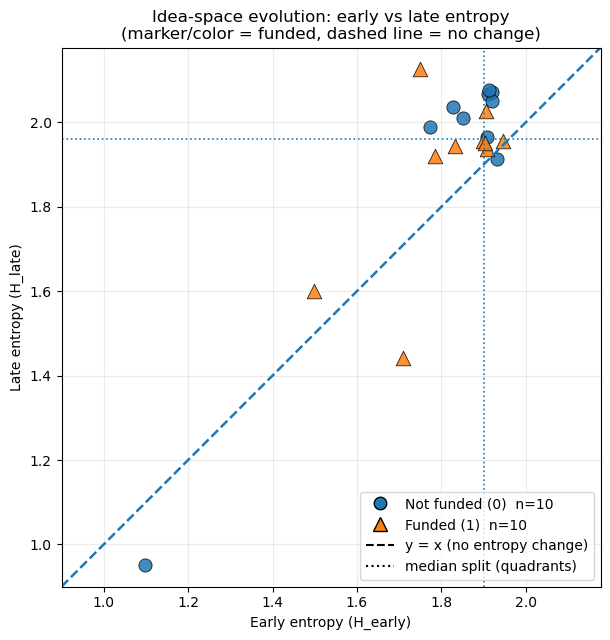

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# df_final must have: session_id, H_early, H_late, proposal_success
# proposal_success should be 0/1
df_final = meta_plus.merge(
    entropy_change[["session_id", "H_early", "H_late", "delta_entropy"]],
    on="session_id",
    how="inner"
).copy()

# --- settings ---
x = df_final["H_early"].astype(float).values
y = df_final["H_late"].astype(float).values
funded = df_final["proposal_success"].astype(int).values

# axis bounds with padding
pad = 0.05
xmin, xmax = x.min() - pad, x.max() + pad
ymin, ymax = y.min() - pad, y.max() + pad
lo = min(xmin, ymin)
hi = max(xmax, ymax)

# medians for quadrant lines (optional but useful)
mx = np.median(x)
my = np.median(y)

plt.figure(figsize=(7, 7))

# Plot not funded (0) and funded (1) with different markers
mask0 = funded == 0
mask1 = funded == 1

plt.scatter(x[mask0], y[mask0], marker="o", s=90, alpha=0.85, edgecolor="k", linewidth=0.6, label="Not funded (0)")
plt.scatter(x[mask1], y[mask1], marker="^", s=110, alpha=0.85, edgecolor="k", linewidth=0.6, label="Funded (1)")

# y = x reference line
plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.8)

# Quadrant median lines
plt.axvline(mx, linestyle=":", linewidth=1.2)
plt.axhline(my, linestyle=":", linewidth=1.2)

# Optional: label points (turn on if you want)
LABEL_POINTS = False
if LABEL_POINTS:
    for _, r in df_final.iterrows():
        plt.text(r["H_early"] + 0.01, r["H_late"] + 0.01, r["session_id"], fontsize=8, alpha=0.8)

# Cosmetics
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.25)
plt.xlabel("Early entropy (H_early)")
plt.ylabel("Late entropy (H_late)")
plt.title("Idea-space evolution: early vs late entropy\n(marker/color = funded, dashed line = no change)")

# Legend with counts
n0 = int(mask0.sum())
n1 = int(mask1.sum())
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Not funded (0)  n={n0}',
           markerfacecolor='C0', markeredgecolor='k', markersize=9),
    Line2D([0], [0], marker='^', color='w', label=f'Funded (1)  n={n1}',
           markerfacecolor='C1', markeredgecolor='k', markersize=10),
    Line2D([0], [0], linestyle='--', color='k', label='y = x (no entropy change)'),
    Line2D([0], [0], linestyle=':', color='k', label='median split (quadrants)'),
]
plt.legend(handles=legend_elements, loc="lower right", frameon=True)

plt.show()

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

# ============================================================
# 1) Compute phase-by-label probabilities for ALL sessions
# ============================================================

# Count labels per session per phase
counts = (
    U
    .groupby(["session_id", "phase", "label"])
    .size()
    .reset_index(name="n")
)

# Normalize to probabilities within each (session, phase)
counts["p"] = (
    counts
    .groupby(["session_id", "phase"])["n"]
    .transform(lambda x: x / x.sum())
)

# This is the canonical long table of idea distributions
phase_probs_long = counts[["session_id", "phase", "label", "p"]]

# ============================================================
# 2) Compute entropy per session per phase
# ============================================================

entropy_long = (
    phase_probs_long
    .groupby(["session_id", "phase"])["p"]
    .apply(lambda x: entropy(x.values))
    .reset_index(name="H")
)

# Pivot to wide format
entropy_wide = (
    entropy_long
    .pivot(index="session_id", columns="phase", values="H")
    .reset_index()
    .rename(columns={
        "beginning": "H_early",
        "middle": "H_middle",
        "end": "H_late"
    })
)

# ============================================================
# 3) Compute entropy change metrics
# ============================================================

entropy_wide["delta_entropy"] = entropy_wide["H_late"] - entropy_wide["H_early"]
entropy_wide["entropy_slope"] = entropy_wide["delta_entropy"]  # explicit name

# ============================================================
# 4) Merge outcomes where available
# ============================================================

entropy_all = entropy_wide.merge(
    meta_plus[["session_id", "proposal_success", "p_funded_cv"]],
    on="session_id",
    how="left"   # keeps all sessions
)

print(f"Total sessions with entropy computed: {len(entropy_all)}")
entropy_all.head()

Total sessions with entropy computed: 20


,session_id,H_early,H_late,H_middle,delta_entropy,entropy_slope,proposal_success,p_funded_cv
0,2020_11_06_NES_S12,1.907605,1.935495,1.969160,0.027890,0.027890,1,0.018621
1,2020_11_06_NES_S3,1.707973,1.442133,1.539654,-0.265840,-0.265840,1,0.138559
2,2021_04_22_MND_S4,1.749719,2.126874,1.881527,0.377155,0.377155,1,0.143854
3,2021_04_23_MND_S11,1.899102,1.954731,1.684254,0.055630,0.055630,1,0.074936
4,2021_04_23_MND_S14,1.908560,1.964239,1.796406,0.055679,0.055679,0,0.812520


Total sessions with entropy computed: 20
Sessions with known outcome (proposal_success not null): 20

Delta entropy summary by proposal_success (known outcomes only):
                  count      mean    median
proposal_success                           
0                    10  0.107740  0.154339
1                    10  0.072263  0.079710


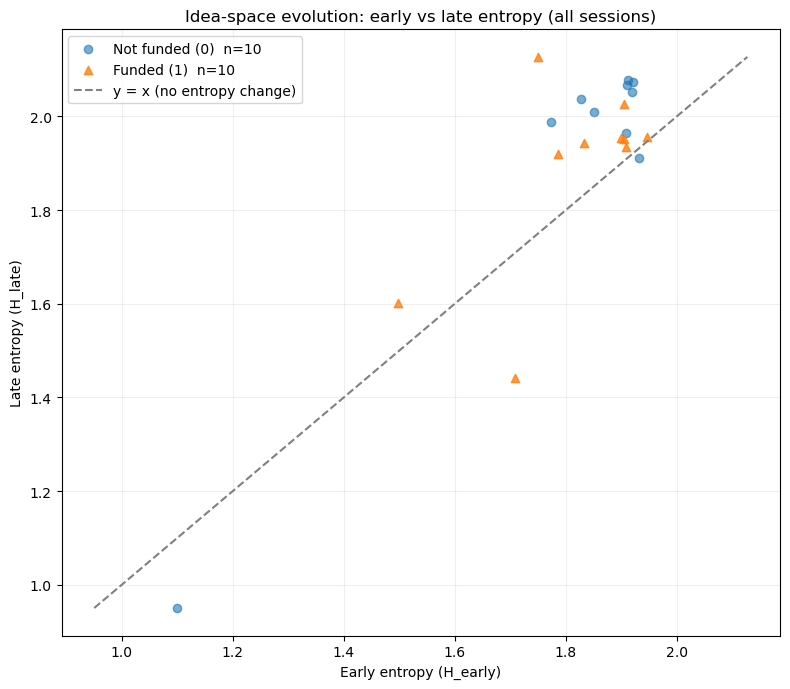

,session_id,H_early,H_late,H_middle,delta_entropy,entropy_slope,proposal_success,p_funded_cv,err_type
0,2020_11_06_NES_S12,1.907605,1.935495,1.969160,0.027890,0.027890,1,0.018621,FN
1,2020_11_06_NES_S3,1.707973,1.442133,1.539654,-0.265840,-0.265840,1,0.138559,FN
2,2021_04_22_MND_S4,1.749719,2.126874,1.881527,0.377155,0.377155,1,0.143854,FN
3,2021_04_23_MND_S11,1.899102,1.954731,1.684254,0.055630,0.055630,1,0.074936,FN
4,2021_04_23_MND_S14,1.908560,1.964239,1.796406,0.055679,0.055679,0,0.812520,FP


In [44]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

# ============================================================
# REQUIREMENTS CHECK
# ============================================================
if "U" not in globals():
    raise NameError("U not found. Run the session JSON loading chunk that creates U (utterance-level df).")

if "meta_plus" not in globals():
    raise NameError("meta_plus not found. Run the meta_plus merge chunk first.")

required_cols = {"session_id", "phase", "label"}
missing = required_cols - set(U.columns)
if missing:
    raise ValueError(f"U is missing required columns: {missing}. Available: {list(U.columns)}")

# ============================================================
# 1) Phase-by-label probabilities for ALL sessions
# ============================================================
counts = (
    U.groupby(["session_id", "phase", "label"])
     .size()
     .reset_index(name="n")
)

counts["p"] = counts.groupby(["session_id", "phase"])["n"].transform(lambda x: x / x.sum())
phase_probs_long = counts[["session_id", "phase", "label", "p"]]

# ============================================================
# 2) Entropy per session per phase
# ============================================================
entropy_long = (
    phase_probs_long
    .groupby(["session_id", "phase"])["p"]
    .apply(lambda x: entropy(x.values))
    .reset_index(name="H")
)

entropy_wide = (
    entropy_long
    .pivot(index="session_id", columns="phase", values="H")
    .reset_index()
)

# Rename phase columns if present
rename_map = {}
if "beginning" in entropy_wide.columns: rename_map["beginning"] = "H_early"
if "middle" in entropy_wide.columns:    rename_map["middle"]    = "H_middle"
if "end" in entropy_wide.columns:       rename_map["end"]       = "H_late"
entropy_wide = entropy_wide.rename(columns=rename_map)

# Ensure columns exist even if a phase is missing for some sessions
for col in ["H_early", "H_middle", "H_late"]:
    if col not in entropy_wide.columns:
        entropy_wide[col] = np.nan

# ============================================================
# 3) Entropy change metrics
# ============================================================
entropy_wide["delta_entropy"] = entropy_wide["H_late"] - entropy_wide["H_early"]
entropy_wide["entropy_slope"] = entropy_wide["delta_entropy"]  # alias if you want "slope" language

# ============================================================
# 4) Merge outcomes (keeps all sessions; outcomes may be NaN)
# ============================================================
keep_cols = [c for c in ["session_id", "proposal_success", "p_funded_cv", "err_type"] if c in meta_plus.columns]
entropy_all = entropy_wide.merge(meta_plus[keep_cols], on="session_id", how="left")

print(f"Total sessions with entropy computed: {len(entropy_all)}")
print(f"Sessions with known outcome (proposal_success not null): {entropy_all['proposal_success'].notna().sum()}")

# ============================================================
# 5) Quick summaries
# ============================================================
if "proposal_success" in entropy_all.columns:
    print("\nDelta entropy summary by proposal_success (known outcomes only):")
    print(
        entropy_all.dropna(subset=["proposal_success"])
                   .groupby("proposal_success")["delta_entropy"]
                   .agg(["count", "mean", "median"])
    )

# ============================================================
# 6) Plot: Early vs Late entropy (all sessions; marker by funded if known)
# ============================================================
plt.figure(figsize=(8, 7))

known = entropy_all.dropna(subset=["H_early", "H_late"])
funded = known[known["proposal_success"] == 1] if "proposal_success" in known.columns else known.iloc[0:0]
unfunded = known[known["proposal_success"] == 0] if "proposal_success" in known.columns else known.iloc[0:0]
unknown = known[known["proposal_success"].isna()] if "proposal_success" in known.columns else known

# Plot unfunded / funded / unknown (unknown is optional but helpful when scaling)
if len(unfunded) > 0:
    plt.scatter(unfunded["H_early"], unfunded["H_late"], alpha=0.6, label=f"Not funded (0)  n={len(unfunded)}")
if len(funded) > 0:
    plt.scatter(funded["H_early"], funded["H_late"], marker="^", alpha=0.8, label=f"Funded (1)  n={len(funded)}")
if len(unknown) > 0:
    plt.scatter(unknown["H_early"], unknown["H_late"], marker="x", alpha=0.35, label=f"Outcome unknown  n={len(unknown)}")

# y = x line (no entropy change)
lims = [
    float(np.nanmin([known["H_early"].min(), known["H_late"].min()])),
    float(np.nanmax([known["H_early"].max(), known["H_late"].max()]))
]
plt.plot(lims, lims, "--", color="gray", label="y = x (no entropy change)")

plt.xlabel("Early entropy (H_early)")
plt.ylabel("Late entropy (H_late)")
plt.title("Idea-space evolution: early vs late entropy (all sessions)")
plt.legend(frameon=True)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# 7) Return the main dataframe you’ll use downstream
# ============================================================
entropy_all.head()

Using phase_col='phase' | label_col='label' | text_col='transcript'
Total utterances in U: 5,559
Total sessions in U: 20
Total sessions in meta_plus: 20

Session_features built.
Total sessions: 20
Sessions with known outcome (proposal_success not null): 20

Mean end_coord_logistics_share_strict by err_type:
          count      mean    median
err_type                           
FP           10  0.285051  0.283333
FN           10  0.250779  0.267857

Delta entropy by proposal_success (known only):
                  count      mean    median
proposal_success                           
0                    10  0.107740  0.154339
1                    10  0.072263  0.079710


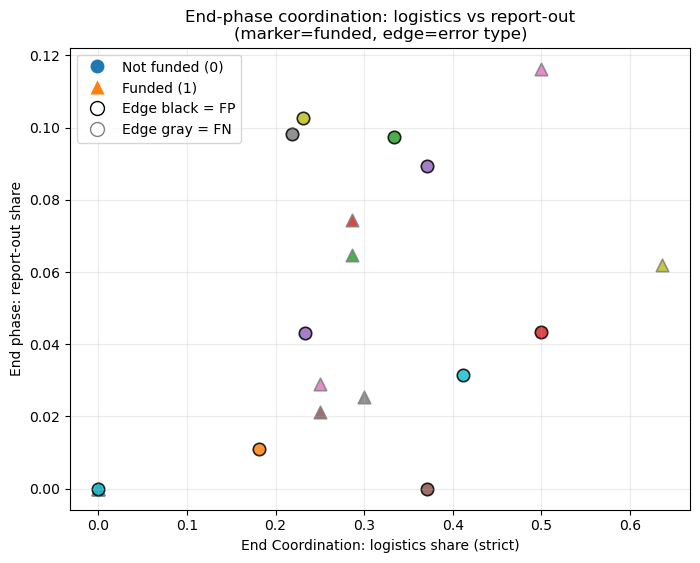

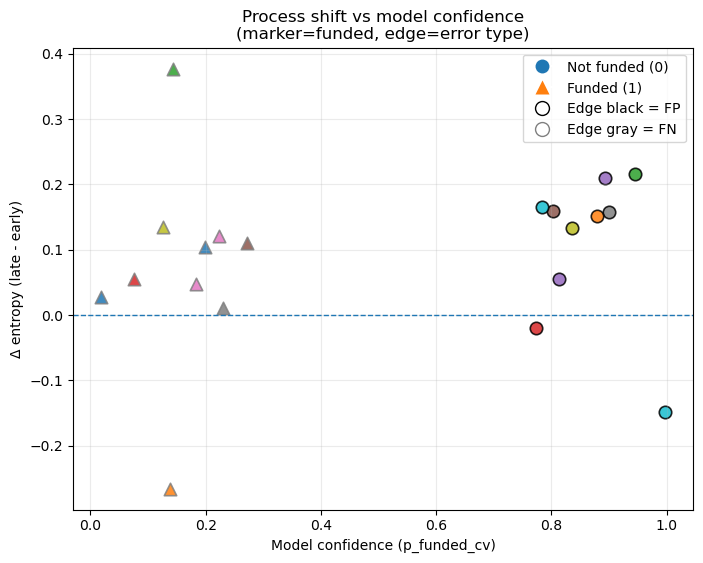

,session_id,end_coord_logistics_share_strict,end_reportout_share,end_convergence_share,H_early,H_late,delta_entropy,beginning__Seeding,beginning__Stress-testing,beginning__Commitment/Closure,...,middle_Relational Climate,end_Coordination and Decision Practices,end_Evaluation Practices,end_Idea Management,end_Information Seeking,end_Integration Practices,end_Knowledge Sharing,end_None,end_Participation Dynamics,end_Relational Climate
15,2022_04_07_MND_S1,0.250000,0.021277,0.000000,1.833140,1.943248,0.110108,0.479167,0.072917,0.125000,...,0.145631,0.106383,0.079787,0.106383,0.090426,0.026596,0.202128,0.053191,0.031915,0.303191
17,2022_04_07_MND_S5,0.300000,0.025316,0.000000,1.946234,1.956260,0.010026,0.380282,0.028169,0.126761,...,0.147368,0.126582,0.094937,0.044304,0.126582,0.063291,0.202532,0.037975,0.025316,0.278481
6,2021_05_20_ABI_S7,0.500000,0.116279,0.000000,1.905287,2.026699,0.121412,0.446154,0.030769,0.276923,...,0.111111,0.139535,0.058140,0.244186,0.081395,0.058140,0.174419,0.034884,0.058140,0.151163
10,2021_09_30_MZT_S6,0.000000,0.000000,0.000000,1.497686,1.601477,0.103791,0.500000,0.000000,0.100000,...,0.153846,0.148148,0.000000,0.296296,0.037037,0.074074,0.296296,0.148148,0.000000,0.000000
16,2022_04_07_MND_S4,0.250000,0.028986,0.000000,1.904034,1.951145,0.047111,0.400000,0.053333,0.226667,...,0.159574,0.144928,0.043478,0.043478,0.144928,0.036232,0.231884,0.043478,0.065217,0.246377
2,2021_04_22_MND_S4,0.285714,0.064748,0.000000,1.749719,2.126874,0.377155,0.376147,0.036697,0.110092,...,0.130952,0.151079,0.086331,0.136691,0.122302,0.100719,0.165468,0.043165,0.057554,0.136691
1,2020_11_06_NES_S3,0.000000,0.000000,0.000000,1.707973,1.442133,-0.265840,0.500000,0.250000,0.000000,...,0.083333,0.083333,0.041667,0.041667,0.083333,0.000000,0.541667,0.000000,0.041667,0.166667
18,2022_04_07_MND_S6,0.636364,0.062016,0.000000,1.785127,1.920473,0.135346,0.536842,0.021053,0.115789,...,0.156627,0.085271,0.093023,0.077519,0.217054,0.038760,0.263566,0.023256,0.023256,0.178295
3,2021_04_23_MND_S11,0.285714,0.074380,0.024793,1.899102,1.954731,0.055630,0.450000,0.100000,0.225000,...,0.076271,0.173554,0.016529,0.148760,0.157025,0.041322,0.206612,0.066116,0.016529,0.173554
0,2020_11_06_NES_S12,0.000000,0.000000,0.040816,1.907605,1.935495,0.027890,0.500000,0.153846,0.038462,...,0.272727,0.061224,0.122449,0.122449,0.102041,0.040816,0.285714,0.000000,0.102041,0.163265


In [46]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# REQUIREMENTS / COLUMN DETECTION
# ============================================================
if "U" not in globals():
    raise NameError("U not found. Run the loader that creates U (utterance-level df).")
if "meta_plus" not in globals():
    raise NameError("meta_plus not found. Run the meta_plus merge chunk first.")

U_ = U.copy()
M_ = meta_plus.copy()

# Detect columns (use your actual column names if different)
phase_col = next((c for c in ["phase","when","segment","part"] if c in U_.columns), None)
label_col = next((c for c in ["label","category","practice_label","annotation_label","code"] if c in U_.columns), None)
text_col  = next((c for c in ["transcript","text","utterance","content"] if c in U_.columns), None)

if phase_col is None:
    raise ValueError(f"Could not find phase column. U columns: {list(U_.columns)}")
if label_col is None:
    raise ValueError(f"Could not find label column. U columns: {list(U_.columns)}")
if text_col is None:
    raise ValueError(f"Could not find transcript/text column. U columns: {list(U_.columns)}")

# Normalize phase naming if needed (optional)
# Expect: beginning/middle/end. If you have different, map here.
# Example:
# U_[phase_col] = U_[phase_col].replace({"start":"beginning","late":"end"})

print(f"Using phase_col='{phase_col}' | label_col='{label_col}' | text_col='{text_col}'")
print(f"Total utterances in U: {len(U_):,}")
print(f"Total sessions in U: {U_['session_id'].nunique():,}")
print(f"Total sessions in meta_plus: {M_['session_id'].nunique():,}")

# ============================================================
# 1) REGEX FLAGS: logistics/report-out/convergence-ish markers
#    (Keep these conservative; add terms as you validate)
# ============================================================
LOGISTICS_STRICT_PAT = re.compile(
    r"\b(muted|unmute|share your screen|screen share|slides?|powerpoint|ppt|"
    r"\btime\b|minutes?|seconds?|breakout|main room|report out|"
    r"wrong slide|slide \d+|read[- ]only|file)\b",
    flags=re.IGNORECASE
)

REPORTOUT_PAT = re.compile(
    r"\b(report out|report-out|summary|summarize|key points?|bullet points?|"
    r"major points?|takeaways?|we'll go to each room|concise summary)\b",
    flags=re.IGNORECASE
)

# "Convergence" here is a placeholder lexical proxy; treat it as exploratory.
CONVERGENCE_PAT = re.compile(
    r"\b(so we agree|we agree|consensus|align(ed|ment)?|settle|finalize|"
    r"wrap up|decision|decide|conclusion|takeaway|key message|"
    r"next steps|action items?)\b",
    flags=re.IGNORECASE
)

def _flag(pat, x):
    if not isinstance(x, str):
        return 0
    return int(bool(pat.search(x)))

U_["is_logistics_strict"] = U_[text_col].apply(lambda x: _flag(LOGISTICS_STRICT_PAT, x))
U_["is_reportout"]        = U_[text_col].apply(lambda x: _flag(REPORTOUT_PAT, x))
U_["is_convergence"]      = U_[text_col].apply(lambda x: _flag(CONVERGENCE_PAT, x))

# ============================================================
# 2) MECHANISM FEATURES (session-level shares)
#    A) "end Coordination/Decision" logistics share
#    B) "end" overall report-out share
#    C) "end" overall convergence lexical share (exploratory)
# ============================================================
END = "end"
COORD_LABEL = "Coordination and Decision Practices"

end_coord = U_[(U_[phase_col] == END) & (U_[label_col] == COORD_LABEL)].copy()
end_all   = U_[U_[phase_col] == END].copy()

end_coord_logistics_share_strict = (
    end_coord.groupby("session_id")["is_logistics_strict"].mean()
    .rename("end_coord_logistics_share_strict")
    .reset_index()
)

end_reportout_share = (
    end_all.groupby("session_id")["is_reportout"].mean()
    .rename("end_reportout_share")
    .reset_index()
)

end_convergence_share = (
    end_all.groupby("session_id")["is_convergence"].mean()
    .rename("end_convergence_share")
    .reset_index()
)

# ============================================================
# 3) ENTROPY FEATURES (phase-wise label distribution)
#    Entropy over label distribution within each phase of each session.
# ============================================================
def entropy_from_counts(counts: np.ndarray) -> float:
    counts = counts.astype(float)
    s = counts.sum()
    if s <= 0:
        return np.nan
    p = counts / s
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

# Count labels within (session, phase, label)
phase_label_counts = (
    U_.dropna(subset=["session_id", phase_col, label_col])
      .groupby(["session_id", phase_col, label_col])
      .size()
      .rename("n")
      .reset_index()
)

# Entropy per (session, phase)
H_phase = (
    phase_label_counts.groupby(["session_id", phase_col])["n"]
    .apply(lambda s: entropy_from_counts(s.values))
    .rename("H")
    .reset_index()
)

# Pivot to columns
H_pivot = H_phase.pivot(index="session_id", columns=phase_col, values="H").reset_index()

# Robustly pick early/late
# Prefer beginning/end; fall back to first/last phase alphabetically if needed.
phase_cols = [c for c in H_pivot.columns if c != "session_id"]
if "beginning" in phase_cols and "end" in phase_cols:
    H_pivot["H_early"] = H_pivot["beginning"]
    H_pivot["H_late"]  = H_pivot["end"]
elif "start" in phase_cols and "end" in phase_cols:
    H_pivot["H_early"] = H_pivot["start"]
    H_pivot["H_late"]  = H_pivot["end"]
else:
    # fallback: pick min/max phase column name (not ideal, but prevents crashing)
    phase_sorted = sorted(phase_cols)
    H_pivot["H_early"] = H_pivot[phase_sorted[0]]
    H_pivot["H_late"]  = H_pivot[phase_sorted[-1]]
    print(f"[WARN] Couldn't find explicit beginning/end. Using phases: early='{phase_sorted[0]}' late='{phase_sorted[-1]}'")

H_pivot["delta_entropy"] = H_pivot["H_late"] - H_pivot["H_early"]

# ============================================================
# 4) MERGE EVERYTHING INTO ONE SESSION FEATURE TABLE (ALL SESSIONS)
# ============================================================
session_features = (
    pd.DataFrame({"session_id": sorted(U_["session_id"].unique())})
      .merge(end_coord_logistics_share_strict, on="session_id", how="left")
      .merge(end_reportout_share,             on="session_id", how="left")
      .merge(end_convergence_share,           on="session_id", how="left")
      .merge(H_pivot[["session_id","H_early","H_late","delta_entropy"]], on="session_id", how="left")
      .merge(M_, on="session_id", how="left")  # brings in proposal_success, p_funded_cv, err_type, etc.
)

# Replace missing shares with 0 when "no utterances" for that subset
# (If a session has no end_coord rows, we can't compute end_coord_logistics_share; set 0 for convenience.)
for c in ["end_coord_logistics_share_strict", "end_reportout_share", "end_convergence_share"]:
    if c in session_features.columns:
        session_features[c] = session_features[c].fillna(0.0)

print("\nSession_features built.")
print("Total sessions:", len(session_features))
print("Sessions with known outcome (proposal_success not null):", session_features["proposal_success"].notna().sum())

# ============================================================
# 5) QUICK SUMMARIES YOU CAN SAY OUT LOUD
# ============================================================
if "err_type" in session_features.columns:
    print("\nMean end_coord_logistics_share_strict by err_type:")
    print(session_features.groupby("err_type")["end_coord_logistics_share_strict"].agg(["count","mean","median"]).sort_values("mean", ascending=False))

if "proposal_success" in session_features.columns:
    print("\nDelta entropy by proposal_success (known only):")
    print(session_features[session_features["proposal_success"].notna()]
          .groupby("proposal_success")["delta_entropy"].agg(["count","mean","median"]))

# ============================================================
# 6) PLOTS FOR BRIAN: NOT "ONE ENTROPY GRAPH", BUT A STORY
#    Plot A: Mechanism map (logistics-coordination vs report-out)
#    Plot B: Process vs model confidence (delta entropy vs p_funded_cv)
# ============================================================
# Helper styling
def _marker_for_funded(v):
    return "^" if v == 1 else "o"

def _edge_for_err(err):
    # edgecolor provides quick error-type cue without relying on weird colormaps
    if err == "FP":
        return "black"
    if err == "FN":
        return "gray"
    return "none"

df_plot = session_features.copy()

# Plot A
plt.figure(figsize=(8,6))
for _, r in df_plot.iterrows():
    funded = r.get("proposal_success", np.nan)
    err    = r.get("err_type", None)
    x = r.get("end_coord_logistics_share_strict", np.nan)
    y = r.get("end_reportout_share", np.nan)
    if pd.isna(x) or pd.isna(y):
        continue
    plt.scatter(
        x, y,
        marker=_marker_for_funded(funded) if not pd.isna(funded) else "x",
        s=80,
        alpha=0.85,
        edgecolors=_edge_for_err(err),
        linewidths=1.2
    )

plt.xlabel("End Coordination: logistics share (strict)")
plt.ylabel("End phase: report-out share")
plt.title("End-phase coordination: logistics vs report-out\n(marker=funded, edge=error type)")
plt.grid(True, alpha=0.25)

# manual legend
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker="o", color="w", label="Not funded (0)", markerfacecolor="C0", markersize=10, markeredgecolor="none"),
    Line2D([0],[0], marker="^", color="w", label="Funded (1)", markerfacecolor="C1", markersize=10, markeredgecolor="none"),
    Line2D([0],[0], marker="o", color="w", label="Edge black = FP", markerfacecolor="w", markeredgecolor="black", markersize=10),
    Line2D([0],[0], marker="o", color="w", label="Edge gray = FN", markerfacecolor="w", markeredgecolor="gray", markersize=10),
]
plt.legend(handles=legend_elems, loc="best", frameon=True)
plt.show()

# Plot B (only if model prob exists)
if "p_funded_cv" in df_plot.columns:
    plt.figure(figsize=(8,6))
    for _, r in df_plot.iterrows():
        funded = r.get("proposal_success", np.nan)
        err    = r.get("err_type", None)
        x = r.get("p_funded_cv", np.nan)
        y = r.get("delta_entropy", np.nan)
        if pd.isna(x) or pd.isna(y):
            continue
        plt.scatter(
            x, y,
            marker=_marker_for_funded(funded) if not pd.isna(funded) else "x",
            s=80,
            alpha=0.85,
            edgecolors=_edge_for_err(err),
            linewidths=1.2
        )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Model confidence (p_funded_cv)")
    plt.ylabel("Δ entropy (late - early)")
    plt.title("Process shift vs model confidence\n(marker=funded, edge=error type)")
    plt.grid(True, alpha=0.25)
    plt.legend(handles=legend_elems[:4], loc="best", frameon=True)
    plt.show()

# Keep a named object for later chunks (so you stop getting NameErrors)
entropy_change = session_features[["session_id","H_early","H_late","delta_entropy"]].copy()

# Preview
display(session_features.sort_values(["proposal_success","p_funded_cv"], ascending=[False, False]).head(12))

# almost there (final graphs i hope)

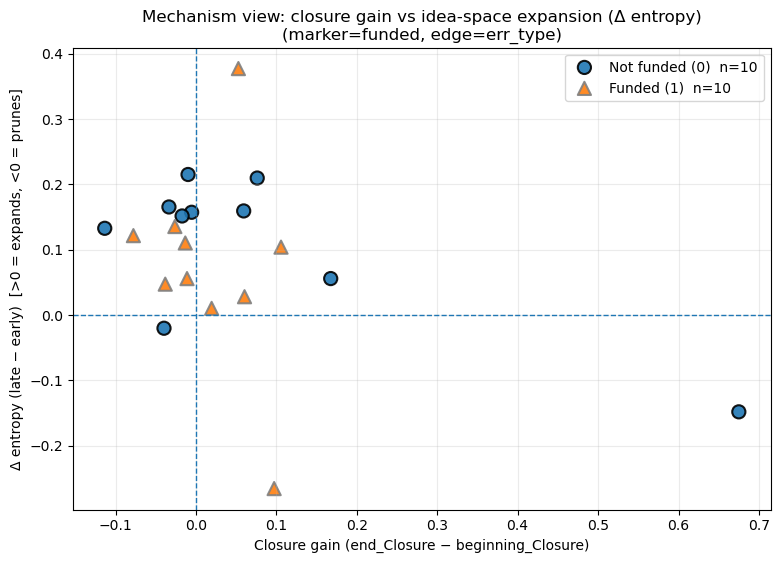


Most pruning / convergent FUNDED sessions (lowest Δ entropy):


,session_id,proposal_success,err_type,p_funded_cv,delta_entropy,pruning_score,closure_gain,synthesis_gain,beginning_Seeding,end_Seeding,beginning_Closure,end_Closure
1,2020_11_06_NES_S3,1,FN,0.138559,-0.265840,0.265840,0.097222,0.089583,0.416667,0.395833,0.000000,0.097222
17,2022_04_07_MND_S5,1,FN,0.229674,0.010026,-0.010026,0.019500,0.037417,0.302290,0.196864,0.105436,0.124936
0,2020_11_06_NES_S12,1,FN,0.018621,0.027890,-0.027890,0.060391,0.072926,0.436047,0.314167,0.030859,0.091250
16,2022_04_07_MND_S4,1,FN,0.183988,0.047111,-0.047111,-0.038166,-0.005392,0.304478,0.255187,0.176766,0.138600
3,2021_04_23_MND_S11,1,FN,0.074936,0.055630,-0.055630,-0.011103,-0.075656,0.420312,0.278980,0.182812,0.171710
10,2021_09_30_MZT_S6,1,FN,0.199107,0.103791,-0.103791,0.105773,0.152505,0.338235,0.333333,0.079412,0.185185
15,2022_04_07_MND_S1,1,FN,0.272132,0.110108,-0.110108,-0.013258,-0.058557,0.358004,0.208515,0.115132,0.101874
6,2021_05_20_ABI_S7,1,FN,0.222979,0.121412,-0.121412,-0.077776,-0.020729,0.304973,0.258930,0.216048,0.138272



Most expanding / divergent NOT-FUNDED sessions (highest Δ entropy):


,session_id,proposal_success,err_type,p_funded_cv,delta_entropy,pruning_score,closure_gain,synthesis_gain,beginning_Seeding,end_Seeding,beginning_Closure,end_Closure
12,2021_10_01_MZT_S8,0,FP,0.944502,0.215012,-0.215012,-0.009824,-0.042716,0.261069,0.217284,0.178210,0.168386
14,2021_11_05_NES_S2,0,FP,0.892249,0.209584,-0.209584,0.076193,0.012167,0.375000,0.159577,0.157853,0.234046
9,2021_09_30_MZT_S3,0,FP,0.783783,0.165309,-0.165309,-0.033584,-0.009524,0.279337,0.220263,0.217262,0.183678
5,2021_04_23_MND_S7,0,FP,0.803345,0.159219,-0.159219,0.059357,-0.050672,0.328241,0.218661,0.124074,0.183431
7,2021_05_21_ABI_S5,0,FP,0.900494,0.157166,-0.157166,-0.005354,0.018776,0.243377,0.267207,0.209608,0.204254
11,2021_10_01_MZT_S2,0,FP,0.879218,0.151512,-0.151512,-0.017219,0.006467,0.286630,0.262479,0.156777,0.139557
8,2021_06_10_SLU_S7,0,FP,0.836086,0.132631,-0.132631,-0.113415,0.020614,0.243388,0.258371,0.255532,0.142116
4,2021_04_23_MND_S14,0,FP,0.812520,0.055679,-0.055679,0.167561,-0.103060,0.444444,0.241423,0.106667,0.274228



Built idea_flow_features: 20 sessions × 24 columns


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# REQUIREMENTS
# ============================================================
required = ["session_features", "meta_plus"]
for r in required:
    if r not in globals():
        raise NameError(f"{r} not found. Run the chunk that builds `{r}` first.")

sf = session_features.copy()
mp = meta_plus[["session_id", "proposal_success", "p_funded_cv", "err_type"]].copy()

# ============================================================
# 1) Map your annotation labels -> 4 "idea-state" buckets
#    (Edit this mapping to match your codebook semantics)
# ============================================================
STATE_MAP = {
    # Idea emergence / proposing directions
    "Seeding": {
        "Seeding",
        "Information Seeking",   # often question-driven seeding
        "Idea Management",       # can include proposing/parking ideas
    },

    # Critique, constraints, challenges, evaluation pressure
    "Stress-testing": {
        "Stress-testing",
        "Evaluation Practices",
        "Information Seeking",   # sometimes belongs here; keep or remove
    },

    # Integration, combining, synthesizing ideas
    "Synthesis": {
        "Synthesis",
        "Integration Practices",
        "Knowledge Sharing",
    },

    # Decisions, commitments, wrap-up of choices (NOT logistics)
    "Closure": {
        "Commitment/Closure",
        "Coordination and Decision Practices",
    },
}

# If you have slightly different label names in the wide table, normalize them:
# wide columns are like "beginning__Knowledge Sharing" or "end_Coordination and Decision Practices"
def parse_phase_label(col: str):
    if "__" in col:
        phase, label = col.split("__", 1)
        return phase, label
    if "_" in col:
        phase, label = col.split("_", 1)
        return phase, label
    return None, None

PHASES = ["beginning", "middle", "end"]

# Collect all (phase,label) columns in session_features
phase_label_cols = []
for c in sf.columns:
    ph, lab = parse_phase_label(c)
    if ph in PHASES and isinstance(lab, str) and len(lab) > 0:
        phase_label_cols.append((c, ph, lab))

if len(phase_label_cols) == 0:
    raise ValueError("No phase×label columns found in session_features. "
                     "Expected columns like 'beginning__Seeding' or 'end_Knowledge Sharing'.")

# ============================================================
# 2) Build phase-wise shares for each bucket
# ============================================================
state_phase = sf[["session_id"]].copy()

def get_cols_for(phase, labels_set):
    cols = []
    for c, ph, lab in phase_label_cols:
        if ph == phase and lab in labels_set:
            cols.append(c)
    return cols

for ph in PHASES:
    # Denominator: sum of all label shares in that phase (should be ~1, but be safe)
    denom_cols = [c for c, p, _ in phase_label_cols if p == ph]
    denom = sf[denom_cols].sum(axis=1).replace(0, np.nan)

    for state, labels_set in STATE_MAP.items():
        cols = get_cols_for(ph, labels_set)
        if len(cols) == 0:
            # If none found, fill with 0 and keep going
            state_phase[f"{ph}_{state}"] = 0.0
        else:
            state_phase[f"{ph}_{state}"] = (sf[cols].sum(axis=1) / denom).fillna(0.0)

# ============================================================
# 3) Trajectory features (interpretable, low-dimensional)
# ============================================================
state_phase["closure_gain"]   = state_phase["end_Closure"]   - state_phase["beginning_Closure"]
state_phase["synthesis_gain"] = state_phase["end_Synthesis"] - state_phase["beginning_Synthesis"]
state_phase["stress_gain"]    = state_phase["end_Stress-testing"] - state_phase["beginning_Stress-testing"]
state_phase["seed_drop"]      = state_phase["beginning_Seeding"] - state_phase["end_Seeding"]

# Entropy features if present
for c in ["H_early", "H_late", "delta_entropy"]:
    if c in sf.columns:
        state_phase[c] = sf[c].values

# "Pruning" = negative entropy change (bigger means more pruning/convergence)
if "delta_entropy" in state_phase.columns:
    state_phase["pruning_score"] = -state_phase["delta_entropy"]
else:
    state_phase["pruning_score"] = np.nan

# Merge outcomes/model diagnostics
df_plot = state_phase.merge(mp, on="session_id", how="inner")

# ============================================================
# 4) Brian-friendly plot: closure gain vs entropy change
#    - marker = funded
#    - edge = error type (FP black, FN gray, else light)
# ============================================================
def edge_color(err):
    if err == "FP":
        return "black"
    if err == "FN":
        return "gray"
    return "lightgray"

fig, ax = plt.subplots(figsize=(9, 6))

# Build funded vs not funded layers
for funded_val, marker, label in [(0, "o", "Not funded (0)"), (1, "^", "Funded (1)")]:
    sub = df_plot[df_plot["proposal_success"] == funded_val]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub["closure_gain"],
        sub["delta_entropy"] if "delta_entropy" in sub.columns else np.zeros(len(sub)),
        marker=marker,
        s=90,
        edgecolors=[edge_color(e) for e in sub["err_type"]],
        linewidths=1.5,
        alpha=0.9,
        label=f"{label}  n={len(sub)}",
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Mechanism view: closure gain vs idea-space expansion (Δ entropy)\n(marker=funded, edge=err_type)")
ax.set_xlabel("Closure gain (end_Closure − beginning_Closure)")
ax.set_ylabel("Δ entropy (late − early)  [>0 = expands, <0 = prunes]")
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)
plt.show()

# ============================================================
# 5) Small tables: "most convergent funded" vs "most divergent not funded"
# ============================================================
cols_show = [
    "session_id", "proposal_success", "err_type", "p_funded_cv",
    "delta_entropy", "pruning_score",
    "closure_gain", "synthesis_gain",
    "beginning_Seeding", "end_Seeding",
    "beginning_Closure", "end_Closure",
]

cols_show = [c for c in cols_show if c in df_plot.columns]

print("\nMost pruning / convergent FUNDED sessions (lowest Δ entropy):")
display(
    df_plot[df_plot["proposal_success"] == 1]
    .sort_values("delta_entropy", ascending=True)
    [cols_show]
    .head(8)
)

print("\nMost expanding / divergent NOT-FUNDED sessions (highest Δ entropy):")
display(
    df_plot[df_plot["proposal_success"] == 0]
    .sort_values("delta_entropy", ascending=False)
    [cols_show]
    .head(8)
)

# ============================================================
# 6) Save for later (so you stop losing variables between cells)
# ============================================================
idea_flow_features = df_plot.copy()
print(f"\nBuilt idea_flow_features: {idea_flow_features.shape[0]} sessions × {idea_flow_features.shape[1]} columns")

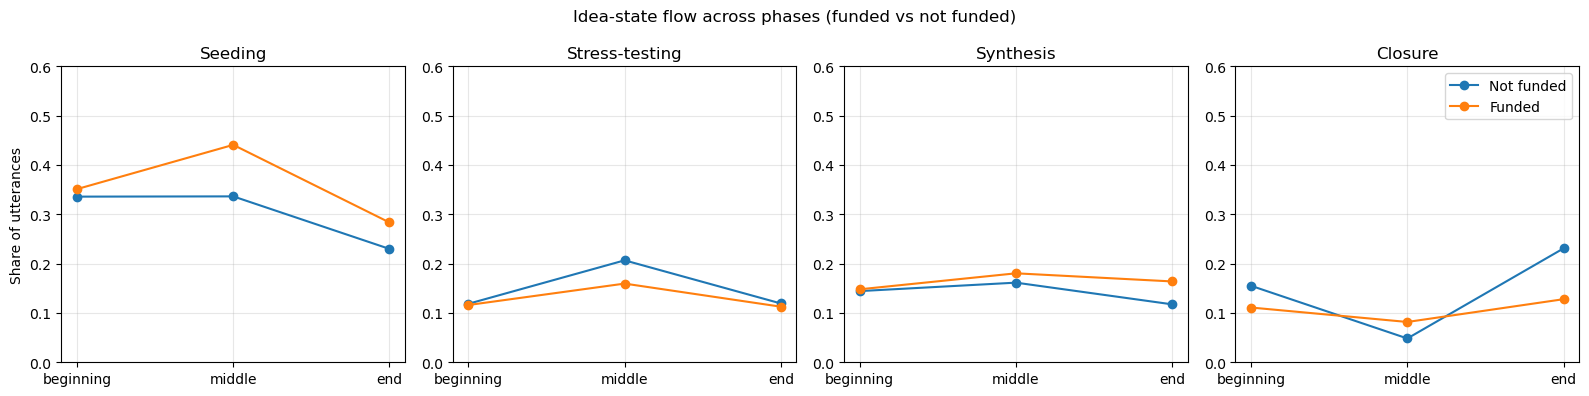

In [48]:
# ============================================================
# NEXT STEP: Phase-wise idea-state trajectories
# ============================================================

import matplotlib.pyplot as plt

states = ["Seeding", "Stress-testing", "Synthesis", "Closure"]
phases = ["beginning", "middle", "end"]

traj = (
    idea_flow_features
    .groupby("proposal_success")
    [[f"{p}_{s}" for s in states for p in phases]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, len(states), figsize=(16, 4), sharey=False)

for i, state in enumerate(states):
    ax = axes[i]
    for funded, label in [(0, "Not funded"), (1, "Funded")]:
        row = traj[traj["proposal_success"] == funded]
        y = [row[f"{p}_{state}"].values[0] for p in phases]
        ax.plot(phases, y, marker="o", label=label)

    ax.set_title(state)
    ax.set_ylim(0, 0.6)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Share of utterances")
axes[-1].legend()
plt.suptitle("Idea-state flow across phases (funded vs not funded)")
plt.tight_layout()
plt.show()

Using U for analysis.
Using phase_col='phase' | label_col='label' | text_col='transcript' | idx_col='utt_idx'
Total utterances in U_use: 5,559
Total sessions in U_use: 20

Session_features built.
Total sessions: 20
Sessions with known outcome (proposal_success not null): 20


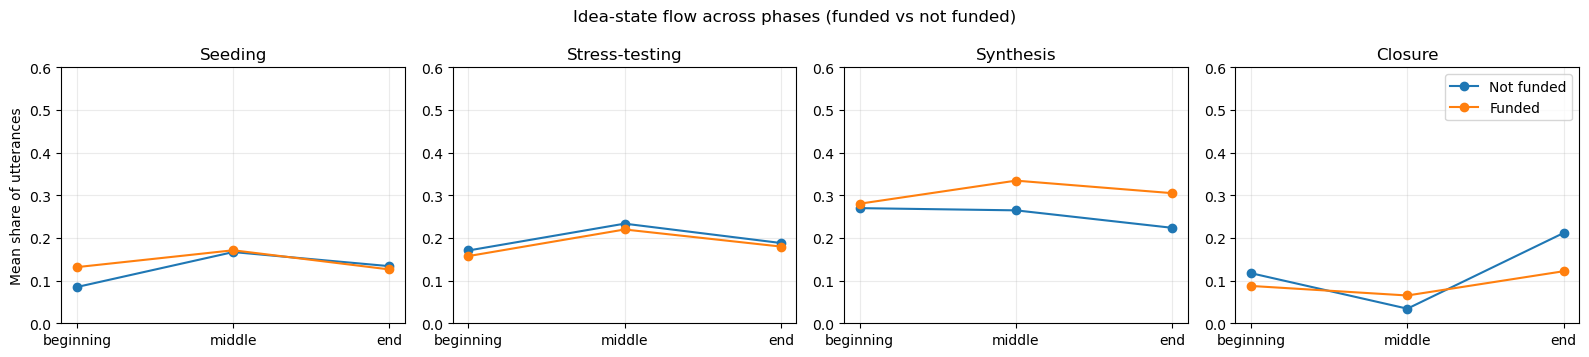

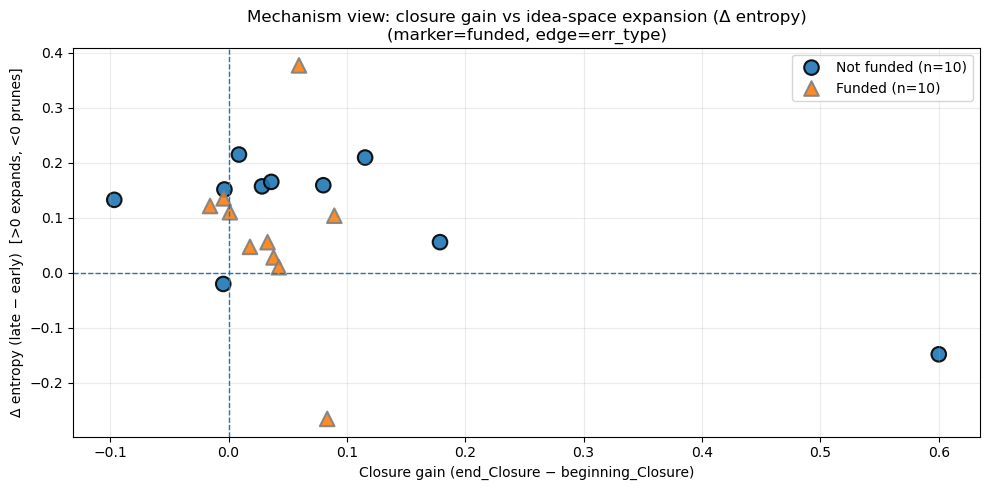


Δ entropy by proposal_success (known only):
                  count      mean    median
proposal_success                           
0                    10  0.107740  0.154339
1                    10  0.072263  0.079710

End coordination logistics share (strict) by err_type (known only):
          count      mean    median
err_type                           
FN           10  0.289394  0.333333
FP           10  0.331936  0.367003


In [49]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0) Pick the widest utterance table available
# ============================================================
if "U_full" in globals() and isinstance(U_full, pd.DataFrame) and len(U_full) > len(U):
    U_use = U_full.copy()
    print("Using U_full (larger) for analysis.")
else:
    U_use = U.copy()
    print("Using U for analysis.")

# Required columns
need_cols = {"session_id"}
missing = need_cols - set(U_use.columns)
if missing:
    raise ValueError(f"U is missing required columns: {missing}. Available: {list(U_use.columns)}")

# Phase / label / text column detection (robust)
phase_col = next((c for c in ["phase","when","segment","part"] if c in U_use.columns), None)
label_col = next((c for c in ["label","category","practice_label","annotation_label","code"] if c in U_use.columns), None)
text_col  = next((c for c in ["transcript","text","utterance","content"] if c in U_use.columns), None)
idx_col   = next((c for c in ["utt_idx","utterance_idx","turn_idx","idx"] if c in U_use.columns), None)

if phase_col is None or label_col is None or text_col is None:
    raise ValueError(
        f"Could not find phase/label/text columns.\n"
        f"phase_col={phase_col}, label_col={label_col}, text_col={text_col}\n"
        f"Available columns: {list(U_use.columns)}"
    )

print(f"Using phase_col='{phase_col}' | label_col='{label_col}' | text_col='{text_col}' | idx_col='{idx_col}'")
print(f"Total utterances in U_use: {len(U_use):,}")
print(f"Total sessions in U_use: {U_use['session_id'].nunique():,}")

# Normalize phase values (just in case)
U_use[phase_col] = U_use[phase_col].astype(str).str.lower().str.strip()
phase_map = {"begin":"beginning","start":"beginning","early":"beginning",
             "mid":"middle","middle":"middle",
             "end":"end","late":"end"}
U_use[phase_col] = U_use[phase_col].replace(phase_map)

valid_phases = {"beginning","middle","end"}
U_use = U_use[U_use[phase_col].isin(valid_phases)].copy()

# ============================================================
# 1) Meta/outcomes table (optional)
# ============================================================
meta = None
if "meta_plus" in globals() and isinstance(meta_plus, pd.DataFrame) and "session_id" in meta_plus.columns:
    meta = meta_plus.copy()
else:
    meta = pd.DataFrame({"session_id": sorted(U_use["session_id"].unique())})

# Ensure columns exist (fill if absent)
for c in ["proposal_success","p_funded_cv","err_type"]:
    if c not in meta.columns:
        meta[c] = np.nan

# ============================================================
# 2) “Logistics-y coordination” + “report-out” flags
# ============================================================
LOGISTICS_STRICT = re.compile(
    r"\b(muted|unmute|share (your )?screen|screen share|slides?|powerpoint|ppt|"
    r"breakout|main room|report out|time|minutes?|seconds?|kicked|go to slide|"
    r"notes|bullet points?|file|link|zoom)\b",
    flags=re.IGNORECASE
)

REPORTOUT_PAT = re.compile(
    r"\b(report\s*out|reporting\s*out|reporter|spokesperson|share\s*back|"
    r"give a (quick|brief|concise) (summary|report)|wrap\s*up|key points)\b",
    flags=re.IGNORECASE
)

def flag_pat(x, pat):
    if not isinstance(x, str):
        return 0
    return int(bool(pat.search(x)))

U_use["_is_logistics_strict"] = U_use[text_col].apply(lambda x: flag_pat(x, LOGISTICS_STRICT))
U_use["_is_reportout"]        = U_use[text_col].apply(lambda x: flag_pat(x, REPORTOUT_PAT))

# Logistics share computed ONLY inside end-phase Coordination/Decision label (as you intended)
END_COORD_LABEL = "Coordination and Decision Practices"

end_coord = U_use[(U_use[phase_col] == "end") & (U_use[label_col] == END_COORD_LABEL)].copy()

logi_share = (
    end_coord.groupby("session_id")["_is_logistics_strict"]
    .mean()
    .rename("end_coord_logistics_share_strict")
    .reset_index()
)

# Report-out share computed inside end-phase (all labels) OR restrict to Coordination label
end_phase = U_use[U_use[phase_col] == "end"].copy()
reportout_share = (
    end_phase.groupby("session_id")["_is_reportout"]
    .mean()
    .rename("end_reportout_share")
    .reset_index()
)

# ============================================================
# 3) Idea-state mapping (your STATE_MAP, but applied)
# ============================================================
STATE_MAP = {
    "Seeding": {
        "Seeding",
        "Information Seeking",
        "Idea Management",
    },
    "Stress-testing": {
        "Stress-testing",
        "Evaluation Practices",
        "Information Seeking",  # you can delete this later if it muddies things
    },
    "Synthesis": {
        "Synthesis",
        "Integration Practices",
        "Knowledge Sharing",
    },
    "Closure": {
        "Commitment/Closure",
        "Coordination and Decision Practices",
    }
}

# Map label -> state (first match wins, else "Other")
label_to_state = {}
for st, labs in STATE_MAP.items():
    for lab in labs:
        label_to_state[lab] = st

U_use["_state"] = U_use[label_col].map(label_to_state).fillna("Other")

# ============================================================
# 4) Phase-wise STATE shares per session + gains
# ============================================================
# Share of utterances in each state per (session, phase)
state_share = (
    U_use.groupby(["session_id", phase_col, "_state"])
    .size()
    .rename("n")
    .reset_index()
)

totals = (
    U_use.groupby(["session_id", phase_col])
    .size()
    .rename("n_total")
    .reset_index()
)

state_share = state_share.merge(totals, on=["session_id", phase_col], how="left")
state_share["share"] = state_share["n"] / state_share["n_total"]

# Pivot to columns like: beginning_Seeding, middle_Closure, ...
state_wide = (
    state_share.assign(col=lambda d: d[phase_col] + "_" + d["_state"])
    .pivot_table(index="session_id", columns="col", values="share", fill_value=0.0)
    .reset_index()
)

# Convenience getters
def col_or_zero(df, col):
    return df[col] if col in df.columns else 0.0

# Closure gain = end_Closure - beginning_Closure
state_wide["closure_gain"] = col_or_zero(state_wide, "end_Closure") - col_or_zero(state_wide, "beginning_Closure")
state_wide["synthesis_gain"] = col_or_zero(state_wide, "end_Synthesis") - col_or_zero(state_wide, "beginning_Synthesis")

# ============================================================
# 5) Entropy over ORIGINAL LABEL distribution per phase (not state)
# ============================================================
# label share per session-phase
lab_share = (
    U_use.groupby(["session_id", phase_col, label_col])
    .size()
    .rename("n")
    .reset_index()
    .merge(totals, on=["session_id", phase_col], how="left")
)
lab_share["p"] = lab_share["n"] / lab_share["n_total"]

def entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

H = (
    lab_share.groupby(["session_id", phase_col])["p"]
    .apply(lambda s: entropy(s.values))
    .rename("H")
    .reset_index()
)

H_wide = H.pivot_table(index="session_id", columns=phase_col, values="H").reset_index()
# Standardize column names
for ph in ["beginning","middle","end"]:
    if ph not in H_wide.columns:
        H_wide[ph] = np.nan
H_wide = H_wide.rename(columns={"beginning":"H_early","middle":"H_middle","end":"H_late"})
H_wide["delta_entropy"] = H_wide["H_late"] - H_wide["H_early"]

# ============================================================
# 6) Assemble session_features
# ============================================================
session_features = (
    pd.DataFrame({"session_id": sorted(U_use["session_id"].unique())})
    .merge(meta[["session_id","proposal_success","p_funded_cv","err_type"]], on="session_id", how="left")
    .merge(logi_share, on="session_id", how="left")
    .merge(reportout_share, on="session_id", how="left")
    .merge(H_wide[["session_id","H_early","H_middle","H_late","delta_entropy"]], on="session_id", how="left")
    .merge(state_wide, on="session_id", how="left")
)

# Fill missing shares with 0 where appropriate
for c in ["end_coord_logistics_share_strict","end_reportout_share"]:
    if c in session_features.columns:
        session_features[c] = session_features[c].fillna(0.0)

print("\nSession_features built.")
print(f"Total sessions: {len(session_features):,}")
print(f"Sessions with known outcome (proposal_success not null): {session_features['proposal_success'].notna().sum():,}")

# ============================================================
# 7) Slide-ready plots (only for sessions with known outcome)
# ============================================================
sf_known = session_features[session_features["proposal_success"].notna()].copy()
sf_known["proposal_success"] = sf_known["proposal_success"].astype(int)

# --- Plot A: Idea-state flow across phases (funded vs not)
def mean_state_share(sf, state):
    return {
        "beginning": sf.get(f"beginning_{state}", pd.Series(0, index=sf.index)).mean(),
        "middle":    sf.get(f"middle_{state}", pd.Series(0, index=sf.index)).mean(),
        "end":       sf.get(f"end_{state}", pd.Series(0, index=sf.index)).mean(),
    }

states_to_plot = ["Seeding","Stress-testing","Synthesis","Closure"]
phases = ["beginning","middle","end"]

fig = plt.figure(figsize=(16,3.6))
for i, st in enumerate(states_to_plot, 1):
    ax = plt.subplot(1, 4, i)
    a0 = mean_state_share(sf_known[sf_known["proposal_success"]==0], st)
    a1 = mean_state_share(sf_known[sf_known["proposal_success"]==1], st)

    ax.plot(phases, [a0[p] for p in phases], marker="o", label="Not funded")
    ax.plot(phases, [a1[p] for p in phases], marker="o", label="Funded")
    ax.set_title(st)
    ax.set_ylim(0, 0.6)
    ax.grid(True, alpha=0.25)
    if i == 1:
        ax.set_ylabel("Mean share of utterances")
    if i == 4:
        ax.legend(loc="upper right")

plt.suptitle("Idea-state flow across phases (funded vs not funded)")
plt.tight_layout()
plt.show()

# --- Plot B: Mechanism view (closure gain vs Δ entropy), marker=funded, edge=err_type
def edge_color(err):
    if err == "FP":
        return "black"
    if err == "FN":
        return "gray"
    return "none"

fig = plt.figure(figsize=(10,5))
ax = plt.gca()

for yval, marker, label in [(0, "o", "Not funded"), (1, "^", "Funded")]:
    sub = sf_known[sf_known["proposal_success"]==yval]
    ax.scatter(
        sub["closure_gain"], sub["delta_entropy"],
        marker=marker, s=110,
        edgecolors=sub["err_type"].map(edge_color),
        linewidths=1.5,
        label=f"{label} (n={len(sub)})",
        alpha=0.9
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Mechanism view: closure gain vs idea-space expansion (Δ entropy)\n(marker=funded, edge=err_type)")
ax.set_xlabel("Closure gain (end_Closure − beginning_Closure)")
ax.set_ylabel("Δ entropy (late − early)  [>0 expands, <0 prunes]")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ============================================================
# 8) Quick sanity summaries to print for your notes
# ============================================================
print("\nΔ entropy by proposal_success (known only):")
print(sf_known.groupby("proposal_success")["delta_entropy"].agg(["count","mean","median"]).to_string())

print("\nEnd coordination logistics share (strict) by err_type (known only):")
print(sf_known.groupby("err_type")["end_coord_logistics_share_strict"].agg(["count","mean","median"]).to_string())

# Keep these around for the next steps
session_features_all = session_features
sf_known_outcomes = sf_known

# try rebuilding it - missing most of the seshs cause i think i pulled the 18 from 2021NES

In [52]:
import os, glob, json
import pandas as pd
import numpy as np

# =========================
# 0) SET THIS PATH
# =========================
BASE_DIR = "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data"

# -------------------------
# Helpers
# -------------------------
def safe_read_json(path):
    with open(path, "r") as f:
        return json.load(f)

def session_id_from_path(p):
    return os.path.splitext(os.path.basename(p))[0]

def infer_conference_from_path(p):
    # .../data/2021CMC/session_data/2021_10_07_CMC_S4.json -> 2021CMC
    parts = os.path.normpath(p).split(os.sep)
    # find the folder right under BASE_DIR
    try:
        i = parts.index(os.path.basename(BASE_DIR))
        return parts[i + 1]
    except Exception:
        # fallback: parent of session_data
        return os.path.basename(os.path.dirname(os.path.dirname(p)))

# =========================
# 1) LOAD ALL SESSION DATA JSONS -> U_full (long)
# =========================
session_jsons = glob.glob(os.path.join(BASE_DIR, "*", "session_data", "*.json"))
print(f"Found {len(session_jsons)} session JSONs on disk (session_data/*.json).")

rows = []
for fp in session_jsons:
    sid = session_id_from_path(fp)
    conf = infer_conference_from_path(fp)

    d = safe_read_json(fp)
    utter_list = None

    # Your examples use `all_data`
    if isinstance(d, dict) and "all_data" in d and isinstance(d["all_data"], list):
        utter_list = d["all_data"]
    # Some variants might use `utterances`
    elif isinstance(d, dict) and "utterances" in d and isinstance(d["utterances"], list):
        utter_list = d["utterances"]
    else:
        continue

    for i, u in enumerate(utter_list):
        if not isinstance(u, dict):
            continue

        phase = u.get("when")  # beginning/middle/end in your example
        text = u.get("transcript")
        speaker = u.get("speaker")

        ann = u.get("annotations", None)

        # explode multi-label annotations:
        # annotations is typically a dict: {label: {score, explanation, when, ...}, ...}
        if isinstance(ann, dict) and len(ann) > 0:
            for label, payload in ann.items():
                score = None
                if isinstance(payload, dict):
                    score = payload.get("score", None)
                    # sometimes "when" also exists inside payload; prefer explicit phase if missing
                    if phase is None:
                        phase = payload.get("when", None)

                rows.append({
                    "conference": conf,
                    "session_id": sid,
                    "utt_idx": i,
                    "phase": phase,
                    "label": label,
                    "score": score,
                    "speaker": speaker,
                    "transcript": text,
                })
        else:
            # no annotations: keep a placeholder so phase distributions still make sense
            rows.append({
                "conference": conf,
                "session_id": sid,
                "utt_idx": i,
                "phase": phase,
                "label": "None",
                "score": None,
                "speaker": speaker,
                "transcript": text,
            })

U_full = pd.DataFrame(rows)

print("\nU_full rebuilt.")
print("Total rows (label-level):", len(U_full))
print("Total sessions:", U_full["session_id"].nunique() if len(U_full) else 0)
print("Phase value counts:\n", U_full["phase"].value_counts(dropna=False).head(10))

# quick structural sanity checks
if len(U_full) == 0:
    raise RuntimeError(
        "U_full is empty. That means your loader didn't find `all_data`/`utterances` lists.\n"
        "Double-check BASE_DIR and confirm your session JSONs contain `all_data`."
    )

# =========================
# 2) LOAD ALL OUTCOME FILES -> meta_plus
# =========================
outcome_jsons = glob.glob(os.path.join(BASE_DIR, "*", "*_session_outcomes.json"))
print(f"\nFound {len(outcome_jsons)} outcome JSONs on disk (*_session_outcomes.json).")

meta_rows = []
for ofp in outcome_jsons:
    conf = os.path.basename(os.path.dirname(ofp))
    d = safe_read_json(ofp)

    # common pattern: dict keyed by session_id
    if isinstance(d, dict):
        for sid, payload in d.items():
            if not isinstance(payload, dict):
                continue
            # keep only what we need; add more keys if your file has them
            meta_rows.append({
                "conference": conf,
                "session_id": sid,
                "proposal_success": payload.get("proposal_success", payload.get("funded", payload.get("outcome", None))),
                "p_funded_cv": payload.get("p_funded_cv", payload.get("p_funded", None)),
            })
    # some pattern: list of dicts with session_id
    elif isinstance(d, list):
        for payload in d:
            if not isinstance(payload, dict):
                continue
            sid = payload.get("session_id")
            if sid is None:
                continue
            meta_rows.append({
                "conference": conf,
                "session_id": sid,
                "proposal_success": payload.get("proposal_success", payload.get("funded", payload.get("outcome", None))),
                "p_funded_cv": payload.get("p_funded_cv", payload.get("p_funded", None)),
            })

meta_plus = pd.DataFrame(meta_rows).drop_duplicates(subset=["session_id"])
print("\nmeta_plus rebuilt.")
print("Total sessions in meta_plus:", len(meta_plus))
print("Known outcomes:", meta_plus["proposal_success"].notna().sum())

# normalize outcome to 0/1 if it came in as strings/bools
def normalize_outcome(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (bool, np.bool_)): return int(x)
    if isinstance(x, (int, np.integer)): return int(x)
    s = str(x).strip().lower()
    if s in {"1", "true", "funded", "yes", "y"}: return 1
    if s in {"0", "false", "not funded", "no", "n"}: return 0
    return np.nan

meta_plus["proposal_success"] = meta_plus["proposal_success"].apply(normalize_outcome)

# =========================
# 3) MERGE: keep only sessions that exist in BOTH transcript data and outcomes
# =========================
sessions_in_U = set(U_full["session_id"].unique())
sessions_in_meta = set(meta_plus["session_id"].unique())

print("\nOverlap check:")
print("sessions_in_U:", len(sessions_in_U))
print("sessions_in_meta:", len(sessions_in_meta))
print("overlap:", len(sessions_in_U & sessions_in_meta))

meta_plus = meta_plus[meta_plus["session_id"].isin(sessions_in_U)].copy()
print("meta_plus after overlap filter:", len(meta_plus))
print("Known outcomes after filter:", meta_plus["proposal_success"].notna().sum())

# If you want the working analysis subset:
U_use = U_full[U_full["session_id"].isin(meta_plus["session_id"])].copy()
print("\nU_use for analysis:")
print("Total rows:", len(U_use))
print("Total sessions:", U_use["session_id"].nunique())

Found 157 session JSONs on disk (session_data/*.json).

U_full rebuilt.
Total rows (label-level): 48987
Total sessions: 157
Phase value counts:
 phase
end          18212
beginning    16239
middle       14536
Name: count, dtype: int64

Found 8 outcome JSONs on disk (*_session_outcomes.json).

meta_plus rebuilt.
Total sessions in meta_plus: 157
Known outcomes: 0

Overlap check:
sessions_in_U: 157
sessions_in_meta: 157
overlap: 157
meta_plus after overlap filter: 157
Known outcomes after filter: 0

U_use for analysis:
Total rows: 48987
Total sessions: 157


In [53]:
# =====================================
# INSPECT OUTCOME JSON SCHEMA
# =====================================
import json
from pprint import pprint

sample_fp = outcome_jsons[0]
print("Inspecting:", sample_fp)

with open(sample_fp, "r") as f:
    d = json.load(f)

print("\nTop-level type:", type(d))

if isinstance(d, dict):
    # grab first session entry
    first_sid = next(iter(d.keys()))
    print("\nSample session_id:", first_sid)
    print("Keys inside session payload:")
    pprint(d[first_sid].keys())

    print("\nFull payload preview:")
    pprint(d[first_sid])

elif isinstance(d, list):
    print("\nList length:", len(d))
    print("\nKeys in first element:")
    pprint(d[0].keys())

    print("\nFull payload preview:")
    pprint(d[0])

Inspecting: /Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json

Top-level type: <class 'dict'>

Sample session_id: 2021_05_20_ABI_S5
Keys inside session payload:
dict_keys(['all_speakers', 'facilitators', 'teams'])

Full payload preview:
{'all_speakers': ['Ed McCleskey CZI',
                  'Kevin Cash',
                  'Lisa Poulikakos',
                  'Wei Min',
                  'Silvia Ronco',
                  'Aniruddha Ray',
                  'Sapun Parekh',
                  'Joyoni Dey',
                  'Huanyu Cheng',
                  'Lingyan Shi',
                  'Ed McCleskey',
                  'Mini Das'],
 'facilitators': ['Wei Min'],
 'teams': {'ABI18': {'funded_status': 0,
                     'members': ['Sapun Parekh', 'Joyoni Dey', 'Lingyan Shi']}}}


In [56]:
# ============================================================
# SCHEMA-ROBUST OUTCOME PARSING → SESSION-LEVEL MERGE
# ============================================================

import json
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Parse team-level outcomes from heterogeneous JSON schemas
# ------------------------------------------------------------

rows = []
bad_sessions = 0
unknown_schema = 0

for fp in outcome_jsons:
    with open(fp, "r") as f:
        d = json.load(f)

    # CASE 1: dict keyed by session_id
    if isinstance(d, dict):
        iterable = d.items()

    # CASE 2: list of session records
    elif isinstance(d, list):
        iterable = []
        for item in d:
            if not isinstance(item, dict):
                continue
            sid = item.get("session_id")
            if sid is None:
                continue
            iterable.append((sid, item))

    else:
        unknown_schema += 1
        continue

    # Parse each session payload
    for session_id, payload in iterable:
        if not isinstance(payload, dict):
            bad_sessions += 1
            continue

        teams = payload.get("teams")
        if not isinstance(teams, dict) or len(teams) == 0:
            bad_sessions += 1
            continue

        for team_id, team_info in teams.items():
            if not isinstance(team_info, dict):
                continue

            funded = team_info.get("funded_status", None)

            try:
                funded_num = int(funded) if funded is not None else np.nan
            except Exception:
                funded_num = np.nan

            rows.append({
                "session_id": session_id,
                "team_id": team_id,
                "funded_status": funded_num,
                "outcomes_file": fp,
            })

teams_df = pd.DataFrame(rows)

print("Team-level outcomes parsed:")
print("  rows:", len(teams_df))
print("  sessions:", teams_df["session_id"].nunique())
print("  bad_sessions skipped:", bad_sessions)
print("  unknown schema files:", unknown_schema)
print("\nFunded_status counts:")
print(teams_df["funded_status"].value_counts(dropna=False))

# ------------------------------------------------------------
# Aggregate to session-level outcomes
# ------------------------------------------------------------

session_outcomes = (
    teams_df.dropna(subset=["funded_status"])
            .groupby("session_id")
            .agg(
                proposal_success=("funded_status", lambda x: int((x == 1).any())),
                funded_rate=("funded_status", "mean"),
                n_teams=("funded_status", "size"),
            )
            .reset_index()
)

print("\nSession-level outcomes built:")
print("  sessions:", len(session_outcomes))
print(session_outcomes["proposal_success"].value_counts())

# ------------------------------------------------------------
# Merge outcomes into meta_plus
# ------------------------------------------------------------

meta_plus = meta_plus.drop(
    columns=[c for c in ["proposal_success", "funded_rate", "n_teams"] if c in meta_plus.columns],
    errors="ignore"
)

meta_plus = meta_plus.merge(session_outcomes, on="session_id", how="left")

print("\nmeta_plus after merge:")
print("  total sessions:", len(meta_plus))
print("  known outcomes:", meta_plus["proposal_success"].notna().sum())
print(meta_plus["proposal_success"].value_counts(dropna=False))

Team-level outcomes parsed:
  rows: 233
  sessions: 123
  bad_sessions skipped: 50
  unknown schema files: 0

Funded_status counts:
funded_status
0    150
1     83
Name: count, dtype: int64

Session-level outcomes built:
  sessions: 123
proposal_success
1    68
0    55
Name: count, dtype: int64

meta_plus after merge:
  total sessions: 157
  known outcomes: 123
proposal_success
1.0    68
0.0    55
NaN    34
Name: count, dtype: int64


Total rows in U: 48,987
Rows mapped to macro states: 34,616
Sessions in U: 157

Session_features built.
Total sessions: 157
Known outcomes: 123
err_type counts (known only):
err_type
FN    68
TN    55
Name: count, dtype: int64

Entropy quadrant summary (known outcomes only):
         entropy_quadrant   n  funded_rate  mean_delta  mean_closure_gain
2   Low early / High late  30     0.633333    0.181193          -0.017840
1   High early / Low late  30     0.600000   -0.047936          -0.058862
0  High early / High late  32     0.562500    0.045599          -0.023244
3    Low early / Low late  31     0.419355    0.080425          -0.047588

Δ entropy by proposal_success (known only):
                  count      mean    median
proposal_success                           
0                    55  0.059188  0.059296
1                    68  0.069040  0.054615

End Closure share by proposal_success (known only):
                  count      mean    median
proposal_success                    

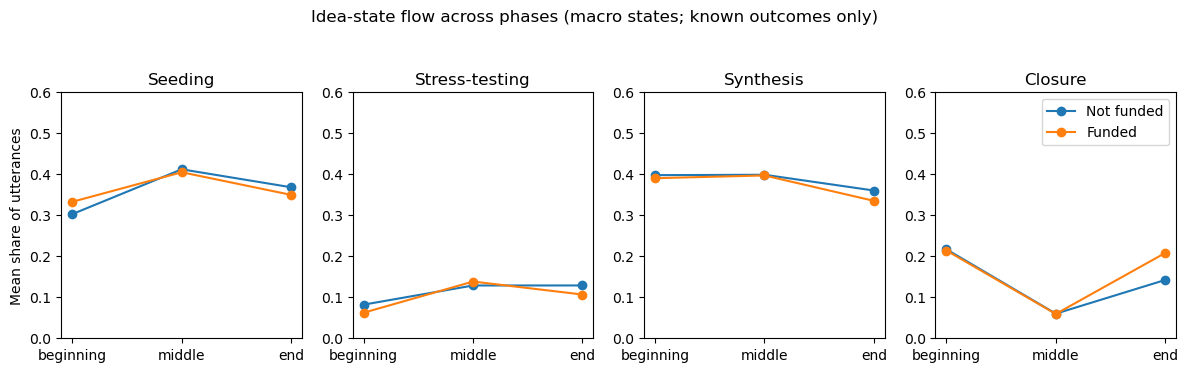

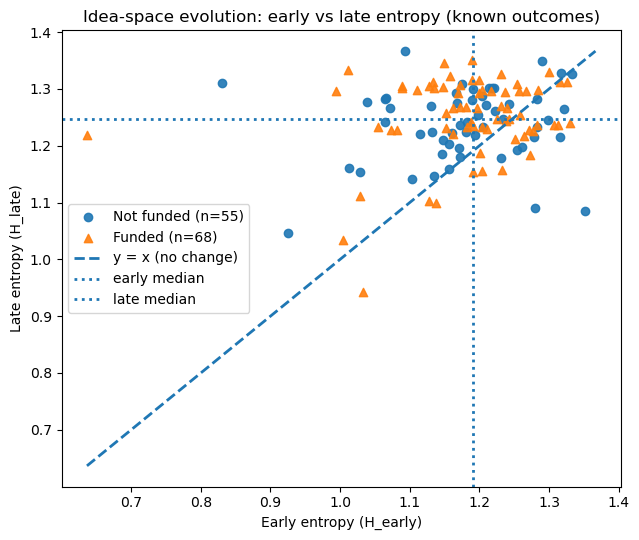

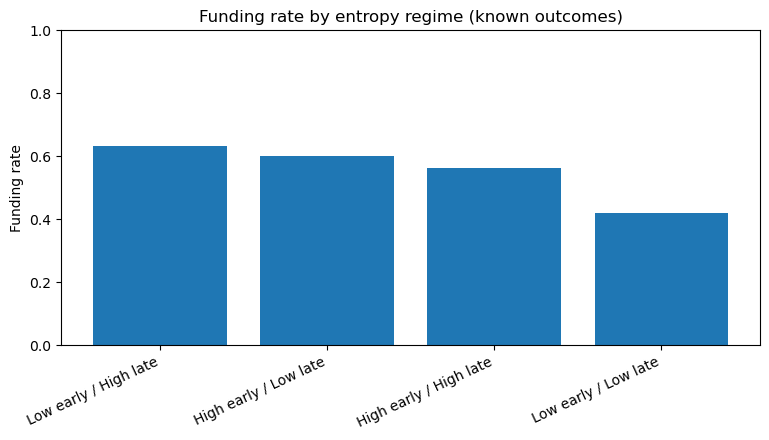

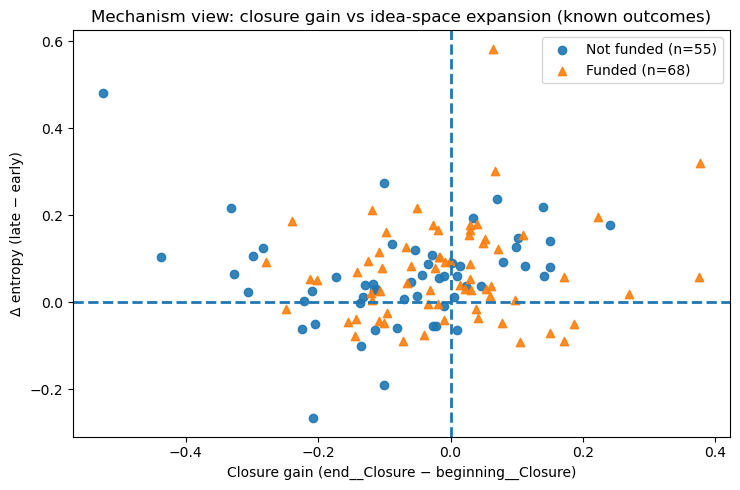

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) CONFIG: column names
# =========================
PHASE_COL = "phase"
LABEL_COL = "label"
TEXT_COL  = "transcript"     # not required here, but kept for sanity
SID_COL   = "session_id"

PHASE_ORDER = ["beginning", "middle", "end"]

# =========================
# 1) MACRO STATE MAP (edit here)
# =========================
STATE_MAP = {
    "Seeding": {"Seeding", "Information Seeking", "Idea Management"},
    "Stress-testing": {"Stress-testing", "Evaluation Practices"},
    "Synthesis": {"Synthesis", "Integration Practices", "Knowledge Sharing"},
    "Closure": {"Commitment/Closure", "Coordination and Decision Practices"},
}

# Invert map: fine_label -> macro_state
fine_to_macro = {fine: macro for macro, fine_set in STATE_MAP.items() for fine in fine_set}

# =========================
# 2) Pick the dataset to use
# =========================
U = U_use.copy()  # or U_full.copy()

need_cols = {SID_COL, PHASE_COL, LABEL_COL}
missing = need_cols - set(U.columns)
if missing:
    raise KeyError(f"U is missing required columns: {missing}")

U[PHASE_COL] = U[PHASE_COL].astype(str).str.lower().str.strip()
U = U[U[PHASE_COL].isin(PHASE_ORDER)].copy()

U["macro_state"] = U[LABEL_COL].map(fine_to_macro)
U_macro = U.dropna(subset=["macro_state"]).copy()

print(f"Total rows in U: {len(U):,}")
print(f"Rows mapped to macro states: {len(U_macro):,}")
print("Sessions in U:", U[SID_COL].nunique())

# =========================
# 3) Macro-state shares by phase, per session
# =========================
counts = (
    U_macro.groupby([SID_COL, PHASE_COL, "macro_state"])
           .size()
           .rename("n")
           .reset_index()
)

totals = (
    counts.groupby([SID_COL, PHASE_COL])["n"]
          .sum()
          .rename("phase_total")
          .reset_index()
)

counts = counts.merge(totals, on=[SID_COL, PHASE_COL], how="left")
counts["share"] = counts["n"] / counts["phase_total"]

flow_wide = (
    counts.assign(col=lambda d: d[PHASE_COL] + "__" + d["macro_state"])
          .pivot_table(index=SID_COL, columns="col", values="share", aggfunc="sum")
          .fillna(0.0)
          .reset_index()
)

# Ensure all macro x phase columns exist
for ph in PHASE_ORDER:
    for ms in STATE_MAP.keys():
        c = f"{ph}__{ms}"
        if c not in flow_wide.columns:
            flow_wide[c] = 0.0

# =========================
# 4) Entropy early/late + Δ entropy (macro distribution)
# =========================
def entropy_from_row(row, phase):
    p = np.array([row[f"{phase}__{ms}"] for ms in STATE_MAP.keys()], dtype=float)
    p = p[p > 0]
    if len(p) == 0:
        return np.nan
    return float(-(p * np.log(p)).sum())

entropy_df = flow_wide[[SID_COL]].copy()
entropy_df["H_early"]  = flow_wide.apply(lambda r: entropy_from_row(r, "beginning"), axis=1)
entropy_df["H_middle"] = flow_wide.apply(lambda r: entropy_from_row(r, "middle"), axis=1)
entropy_df["H_late"]   = flow_wide.apply(lambda r: entropy_from_row(r, "end"), axis=1)
entropy_df["delta_entropy"] = entropy_df["H_late"] - entropy_df["H_early"]

entropy_df["closure_gain"] = flow_wide["end__Closure"].values - flow_wide["beginning__Closure"].values
entropy_df["pruning_score"] = -entropy_df["delta_entropy"]  # positive = pruning / convergence

# =========================
# 5) Merge with meta_plus outcomes (+ reconstruct err_type)
# =========================
for c in [SID_COL, "proposal_success", "p_funded_cv"]:
    if c not in meta_plus.columns:
        raise KeyError(f"meta_plus must include '{c}' (check your outcomes merge + meta schema).")

meta_plus2 = meta_plus.copy()

# Coerce to numeric safely (keeps NaN where missing)
meta_plus2["p_funded_cv"] = pd.to_numeric(meta_plus2["p_funded_cv"], errors="coerce")
meta_plus2["proposal_success"] = pd.to_numeric(meta_plus2["proposal_success"], errors="coerce")

thr = 0.5
meta_plus2["pred_funded"] = (meta_plus2["p_funded_cv"] >= thr).astype("Int64")  # nullable int
meta_plus2["proposal_success_num"] = meta_plus2["proposal_success"]  # alias for clarity

cond_tp = (meta_plus2["pred_funded"] == 1) & (meta_plus2["proposal_success_num"] == 1)
cond_tn = (meta_plus2["pred_funded"] == 0) & (meta_plus2["proposal_success_num"] == 0)
cond_fp = (meta_plus2["pred_funded"] == 1) & (meta_plus2["proposal_success_num"] == 0)
cond_fn = (meta_plus2["pred_funded"] == 0) & (meta_plus2["proposal_success_num"] == 1)

# IMPORTANT FIX: default must be a STRING (not np.nan) so NumPy doesn't explode
meta_plus2["err_type"] = np.select(
    [cond_tp, cond_tn, cond_fp, cond_fn],
    ["TP", "TN", "FP", "FN"],
    default="UNK"
).astype("object")
meta_plus2.loc[meta_plus2["proposal_success_num"].isna(), "err_type"] = np.nan

# (optional) drop helper
meta_plus2 = meta_plus2.drop(columns=["proposal_success_num"])

session_features = (
    meta_plus2[[SID_COL, "proposal_success", "p_funded_cv", "err_type"]]
    .merge(flow_wide, on=SID_COL, how="left")
    .merge(entropy_df, on=SID_COL, how="left")
)

print("\nSession_features built.")
print("Total sessions:", len(session_features))
print("Known outcomes:", session_features["proposal_success"].notna().sum())
print("err_type counts (known only):")
print(session_features.dropna(subset=["proposal_success"])["err_type"].value_counts())

known = session_features.dropna(subset=["proposal_success"]).copy()
known["proposal_success"] = known["proposal_success"].astype(int)

# =========================
# 6) Entropy quadrants (median split on known outcomes)
# =========================
H_early_med = known["H_early"].median()
H_late_med  = known["H_late"].median()

def quadrant(row):
    e = row["H_early"]
    l = row["H_late"]
    e_lab = "High" if e >= H_early_med else "Low"
    l_lab = "High" if l >= H_late_med else "Low"
    return f"{e_lab} early / {l_lab} late"

known["entropy_quadrant"] = known.apply(quadrant, axis=1)

quad_summary = (
    known.groupby("entropy_quadrant")
         .agg(
             n=("proposal_success", "size"),
             funded_rate=("proposal_success", "mean"),
             mean_delta=("delta_entropy", "mean"),
             mean_closure_gain=("closure_gain", "mean"),
         )
         .reset_index()
         .sort_values("funded_rate", ascending=False)
)

print("\nEntropy quadrant summary (known outcomes only):")
print(quad_summary)

print("\nΔ entropy by proposal_success (known only):")
print(known.groupby("proposal_success")["delta_entropy"].agg(["count","mean","median"]))

print("\nEnd Closure share by proposal_success (known only):")
if "end__Closure" in known.columns:
    print(known.groupby("proposal_success")["end__Closure"].agg(["count","mean","median"]))

# =========================
# 7) PLOTS
# =========================

# Plot A: Macro-state flow across phases (funded vs not)
macro_states = list(STATE_MAP.keys())

plt.figure(figsize=(12, 3.5))
for i, ms in enumerate(macro_states):
    y0 = [known.loc[known["proposal_success"]==0, f"{ph}__{ms}"].mean() for ph in PHASE_ORDER]
    y1 = [known.loc[known["proposal_success"]==1, f"{ph}__{ms}"].mean() for ph in PHASE_ORDER]

    plt.subplot(1, 4, i+1)
    plt.plot(PHASE_ORDER, y0, marker="o", label="Not funded")
    plt.plot(PHASE_ORDER, y1, marker="o", label="Funded")
    plt.ylim(0, 0.6)
    plt.title(ms)
    if i == 0:
        plt.ylabel("Mean share of utterances")
    if i == 3:
        plt.legend(loc="upper right")

plt.suptitle("Idea-state flow across phases (macro states; known outcomes only)", y=1.05)
plt.tight_layout()
plt.show()

# Plot B: Early vs late entropy scatter
plt.figure(figsize=(6.5, 5.5))
for val, marker, lab in [(0, "o", "Not funded"), (1, "^", "Funded")]:
    sub = known[known["proposal_success"]==val]
    plt.scatter(sub["H_early"], sub["H_late"], marker=marker, label=f"{lab} (n={len(sub)})", alpha=0.9)

mn = np.nanmin(pd.concat([known["H_early"], known["H_late"]]))
mx = np.nanmax(pd.concat([known["H_early"], known["H_late"]]))
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2, label="y = x (no change)")
plt.axvline(H_early_med, linestyle=":", linewidth=2, label="early median")
plt.axhline(H_late_med,  linestyle=":", linewidth=2, label="late median")

plt.xlabel("Early entropy (H_early)")
plt.ylabel("Late entropy (H_late)")
plt.title("Idea-space evolution: early vs late entropy (known outcomes)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot C: Funding rate by entropy quadrant
plt.figure(figsize=(7.8, 4.5))
plt.bar(quad_summary["entropy_quadrant"], quad_summary["funded_rate"])
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.ylabel("Funding rate")
plt.title("Funding rate by entropy regime (known outcomes)")
plt.tight_layout()
plt.show()

# Plot D: Closure gain vs Δ entropy (mechanism view)
plt.figure(figsize=(7.5, 5))
for val, marker, lab in [(0, "o", "Not funded"), (1, "^", "Funded")]:
    sub = known[known["proposal_success"]==val]
    plt.scatter(sub["closure_gain"], sub["delta_entropy"], marker=marker, label=f"{lab} (n={len(sub)})", alpha=0.9)

plt.axhline(0, linestyle="--", linewidth=2)
plt.axvline(0, linestyle="--", linewidth=2)
plt.xlabel("Closure gain (end__Closure − beginning__Closure)")
plt.ylabel("Δ entropy (late − early)")
plt.title("Mechanism view: closure gain vs idea-space expansion (known outcomes)")
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
import pandas as pd
import numpy as np

print("meta_plus2 shape:", meta_plus2.shape)
print("Columns containing 'fund' or 'success':",
      [c for c in meta_plus2.columns if ("fund" in c.lower()) or ("success" in c.lower())])

for c in ["proposal_success", "p_funded_cv"]:
    print(f"\n--- {c} ---")
    if c not in meta_plus2.columns:
        print("MISSING COLUMN")
    else:
        print("non-null:", meta_plus2[c].notna().sum(), "/", len(meta_plus2))
        print("dtype:", meta_plus2[c].dtype)
        print("head:", meta_plus2[c].head(5).tolist())

# Show how many rows have BOTH non-null
if ("proposal_success" in meta_plus2.columns) and ("p_funded_cv" in meta_plus2.columns):
    both = meta_plus2["proposal_success"].notna() & meta_plus2["p_funded_cv"].notna()
    print("\nRows with BOTH proposal_success and p_funded_cv non-null:", int(both.sum()))
    print("Example rows (if any):")
    print(meta_plus2.loc[both, ["session_id","proposal_success","p_funded_cv"]].head(10))

meta_plus2 shape: (157, 8)
Columns containing 'fund' or 'success': ['p_funded_cv', 'proposal_success', 'funded_rate', 'pred_funded']

--- proposal_success ---
non-null: 123 / 157
dtype: float64
head: [0.0, 1.0, nan, nan, 0.0]

--- p_funded_cv ---
non-null: 0 / 157
dtype: float64
head: [nan, nan, nan, nan, nan]

Rows with BOTH proposal_success and p_funded_cv non-null: 0
Example rows (if any):
Empty DataFrame
Columns: [session_id, proposal_success, p_funded_cv]
Index: []


In [63]:
import numpy as np
import pandas as pd

# 1) Find a usable probability column (you might have a different name)
prob_candidates = [
    "p_funded_cv",          # what you want
    "p_funded",             # common alt
    "p_funded_mean",        # common alt
    "p_funded_proba",       # common alt
    "pred_proba",           # common alt
    "prob_funded",          # common alt
]

print("Existing columns:", meta_plus2.columns.tolist())

# 2) If p_funded_cv is all-NaN, try to recover it from an alternative column
if "p_funded_cv" in meta_plus2.columns and meta_plus2["p_funded_cv"].notna().sum() == 0:
    found = None
    for c in prob_candidates:
        if c in meta_plus2.columns and meta_plus2[c].notna().sum() > 0:
            found = c
            break

    if found is None:
        # Heuristic: search any column that looks like probabilities and isn't all NaN
        heur = []
        for c in meta_plus2.columns:
            if any(k in c.lower() for k in ["prob", "proba", "p_"]) and meta_plus2[c].notna().sum() > 0:
                heur.append(c)

        raise ValueError(
            "p_funded_cv is all NaN and I couldn't find any alternative probability column.\n"
            f"Heuristic candidates with non-null values: {heur}\n"
            "Fix: locate the dataframe where your model outputs were created (the one that had p_funded_cv before) "
            "and merge it back into meta_plus2 on session_id."
        )

    print(f"Recovering p_funded_cv from: {found}")
    meta_plus2["p_funded_cv"] = pd.to_numeric(meta_plus2[found], errors="coerce")

# 3) Sanity check
print("\nAfter recovery attempt:")
print("p_funded_cv non-null:", meta_plus2["p_funded_cv"].notna().sum(), "/", len(meta_plus2))
print(meta_plus2["p_funded_cv"].describe())

# 4) Now your threshold diagnostics will work
known_meta = meta_plus2.dropna(subset=["proposal_success", "p_funded_cv"]).copy()
known_meta["proposal_success"] = known_meta["proposal_success"].astype(int)

print("\nKnown rows (have outcomes + model probs):", len(known_meta))

def confusion_at(thr):
    pred = (known_meta["p_funded_cv"] >= thr).astype(int).values
    y = known_meta["proposal_success"].values
    tp = int(((pred==1)&(y==1)).sum())
    tn = int(((pred==0)&(y==0)).sum())
    fp = int(((pred==1)&(y==0)).sum())
    fn = int(((pred==0)&(y==1)).sum())
    return pd.Series({"thr":thr,"TP":tp,"FP":fp,"TN":tn,"FN":fn})

grid = pd.DataFrame([confusion_at(t) for t in np.linspace(0.1, 0.9, 9)])
print("\nConfusion table across thresholds:")
print(grid)

Existing columns: ['conference', 'session_id', 'p_funded_cv', 'proposal_success', 'funded_rate', 'n_teams', 'pred_funded', 'err_type']


ValueError: p_funded_cv is all NaN and I couldn't find any alternative probability column.
Heuristic candidates with non-null values: []
Fix: locate the dataframe where your model outputs were created (the one that had p_funded_cv before) and merge it back into meta_plus2 on session_id.

In [64]:
import os
import pandas as pd
import numpy as np

ROOT = "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis"
# If your outputs live elsewhere, change ROOT.

TARGET_KEYS = ["p_funded_cv", "p_funded", "prob", "proba", "pred_proba", "funded_prob"]
OK_EXT = (".csv", ".parquet", ".pkl", ".pickle")

hits = []

def safe_read_head(fp, n=50):
    ext = os.path.splitext(fp)[1].lower()
    try:
        if ext == ".csv":
            return pd.read_csv(fp, nrows=n)
        if ext == ".parquet":
            return pd.read_parquet(fp)
        if ext in (".pkl", ".pickle"):
            return pd.read_pickle(fp)
    except Exception:
        return None
    return None

print("Scanning for prediction files under:")
print(ROOT)

for dirpath, _, filenames in os.walk(ROOT):
    for fn in filenames:
        if not fn.lower().endswith(OK_EXT):
            continue
        fp = os.path.join(dirpath, fn)
        df = safe_read_head(fp)
        if df is None or not isinstance(df, pd.DataFrame) or df.empty:
            continue

        cols = [c for c in df.columns]
        has_sid = "session_id" in cols
        if not has_sid:
            continue

        # Look for any probability-ish column
        prob_cols = [c for c in cols if any(k in c.lower() for k in TARGET_KEYS)]
        if len(prob_cols) == 0:
            continue

        # Extra filter: must have at least one non-null value in a prob col
        nonnull_prob_cols = [c for c in prob_cols if pd.to_numeric(df[c], errors="coerce").notna().sum() > 0]
        if len(nonnull_prob_cols) == 0:
            continue

        hits.append((fp, nonnull_prob_cols, cols[:30]))

print(f"\nFound {len(hits)} candidate file(s) with session_id + non-null prob columns.\n")

for i, (fp, prob_cols, preview_cols) in enumerate(hits[:20], 1):
    print(f"[{i}] {fp}")
    print("    prob cols:", prob_cols)
    print("    preview cols:", preview_cols)
    print()

# If we found exactly one good candidate, auto-load + merge it.
if len(hits) == 1:
    fp, prob_cols, _ = hits[0]
    df_pred = safe_read_head(fp, n=10**9)  # load full
    # pick best prob col (prefer p_funded_cv)
    best = "p_funded_cv" if "p_funded_cv" in df_pred.columns else prob_cols[0]
    df_pred = df_pred[["session_id", best]].copy()
    df_pred[best] = pd.to_numeric(df_pred[best], errors="coerce")

    print(f"Auto-merging '{best}' from:\n{fp}\n")
    meta_plus2 = meta_plus2.drop(columns=["p_funded_cv"], errors="ignore").merge(
        df_pred.rename(columns={best: "p_funded_cv"}),
        on="session_id",
        how="left"
    )

    print("After merge:")
    print("p_funded_cv non-null:", meta_plus2["p_funded_cv"].notna().sum(), "/", len(meta_plus2))

Scanning for prediction files under:
/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis

Found 0 candidate file(s) with session_id + non-null prob columns.



In [65]:
unknown_sessions = (
    meta_plus
    .loc[meta_plus["proposal_success"].isna(), "session_id"]
    .unique()
)

print(f"Unknown-outcome sessions: {len(unknown_sessions)}")
unknown_sessions[:10]

Unknown-outcome sessions: 34


array(['2021_05_21_ABI_S16', '2021_05_21_ABI_S1', '2021_05_21_ABI_S6',
       '2021_05_21_ABI_S10', '2021_05_20_ABI_S1', '2021_05_21_ABI_S5',
       'output-2021-05-20-ABI-S1', '2021_06_11_SLU_S5',
       '2021_06_10_SLU_S7', '2021_06_11_SLU_S2'], dtype=object)

# graph for update slide

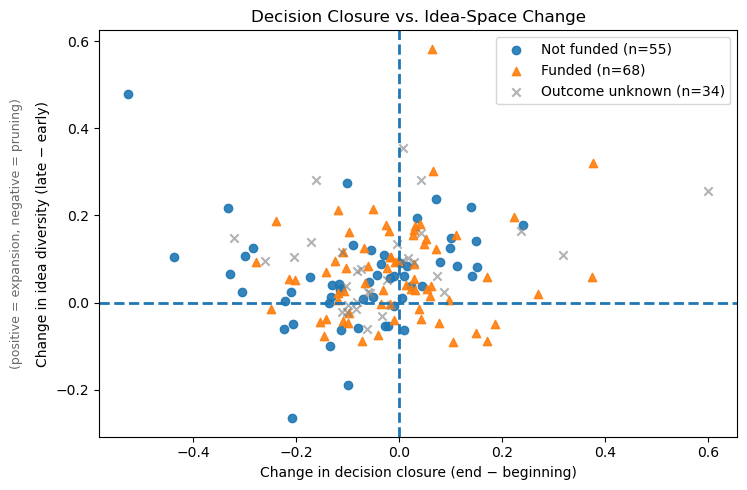

In [69]:
fig, ax = plt.subplots(figsize=(7.5, 5))

# Known outcomes
for val, marker, lab in [(0, "o", "Not funded"), (1, "^", "Funded")]:
    sub = session_features[session_features["proposal_success"] == val]
    ax.scatter(
        sub["closure_gain"],
        sub["delta_entropy"],
        marker=marker,
        alpha=0.9,
        label=f"{lab} (n={len(sub)})"
    )

# Unknown outcomes
unknown = session_features[session_features["proposal_success"].isna()]
ax.scatter(
    unknown["closure_gain"],
    unknown["delta_entropy"],
    marker="x",
    color="gray",
    alpha=0.6,
    label=f"Outcome unknown (n={len(unknown)})"
)

# Reference lines
ax.axhline(0, linestyle="--", linewidth=2)
ax.axvline(0, linestyle="--", linewidth=2)

# Labels
ax.set_xlabel("Change in decision closure (end − beginning)")
ax.set_ylabel("Change in idea diversity (late − early)")

# Small explanatory subtitle under y-axis
ax.text(
    -0.13, 0.5,
    "(positive = expansion, negative = pruning)",
    transform=ax.transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=9,
    color="dimgray"
)

ax.set_title("Decision Closure vs. Idea-Space Change")
ax.legend()
plt.tight_layout()
plt.show()

# confirming for evey

In [70]:
from scipy.stats import mannwhitneyu

# Only sessions with known outcomes
known = session_features.dropna(subset=["proposal_success"]).copy()
known["proposal_success"] = known["proposal_success"].astype(int)

funded = known[known["proposal_success"] == 1]
not_funded = known[known["proposal_success"] == 0]

def mw_test(col):
    x = funded[col].dropna()
    y = not_funded[col].dropna()
    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    return {
        "funded_mean": x.mean(),
        "not_funded_mean": y.mean(),
        "U": stat,
        "p_value": p,
        "n_funded": len(x),
        "n_not_funded": len(y),
    }

results = pd.DataFrame.from_dict({
    "Δ entropy (late − early)": mw_test("delta_entropy"),
    "Closure gain (end − beginning)": mw_test("closure_gain"),
}, orient="index")

results

,funded_mean,not_funded_mean,U,p_value,n_funded,n_not_funded
Δ entropy (late − early),0.069040,0.059188,1899.0,0.884732,68,55
Closure gain (end − beginning),-0.005988,-0.074780,2312.0,0.024716,68,55


In [71]:
from scipy.stats import spearmanr
import pandas as pd

# --- Assumes you already have ---
# session_features with:
# - H_late
# - proposal_success
# - end__Synthesis / end__Seeding / etc.
# - end__Knowledge Sharing OR a proxy for late knowledge sharing

# If you have a macro version (recommended):
late_ks = session_features["end__Synthesis"]  # includes Knowledge Sharing
late_entropy = session_features["H_late"]

mask = late_ks.notna() & late_entropy.notna()

rho, p = spearmanr(late_ks[mask], late_entropy[mask])

print("Late knowledge-related behavior vs late entropy")
print(f"Spearman rho = {rho:.3f}, p = {p:.4f}")

Late knowledge-related behavior vs late entropy
Spearman rho = -0.331, p = 0.0000


In [72]:
from scipy.stats import mannwhitneyu, spearmanr

# -----------------------------------
# 1) Whole-meeting knowledge sharing
# -----------------------------------

# Count all knowledge-sharing utterances per session
ks_counts = (
    U_macro[U_macro["macro_state"] == "Synthesis"]
    .groupby("session_id")
    .size()
    .rename("ks_total")
    .reset_index()
)

# Merge into session_features
sf = session_features.merge(ks_counts, on="session_id", how="left")
sf["ks_total"] = sf["ks_total"].fillna(0)

known = sf.dropna(subset=["proposal_success"]).copy()
known["proposal_success"] = known["proposal_success"].astype(int)

# -----------------------------------
# 2) Funded vs not-funded comparison
# -----------------------------------

ks_funded = known.loc[known["proposal_success"] == 1, "ks_total"]
ks_not    = known.loc[known["proposal_success"] == 0, "ks_total"]

u_stat, p_val = mannwhitneyu(ks_funded, ks_not, alternative="two-sided")

print("Whole-meeting knowledge sharing:")
print(f"Funded mean: {ks_funded.mean():.2f}")
print(f"Not funded mean: {ks_not.mean():.2f}")
print(f"Mann–Whitney U p-value: {p_val:.4f}")

# -----------------------------------
# 3) Relation to entropy (sanity check)
# -----------------------------------

rho, p_rho = spearmanr(
    known["ks_total"],
    known["H_late"]
)

print("\nRelation to late entropy:")
print(f"Spearman rho = {rho:.3f}, p = {p_rho:.4f}")

Whole-meeting knowledge sharing:
Funded mean: 85.88
Not funded mean: 84.85
Mann–Whitney U p-value: 0.6915

Relation to late entropy:
Spearman rho = -0.034, p = 0.7113


In [74]:
import pandas as pd

# pick one session to inspect
sid = U_use["session_id"].iloc[0]
print(f"Inspecting session: {sid}")

# focus on a single ambiguous code
CODE = "Information Seeking"

example = (
    U_use[
        (U_use["session_id"] == sid) &
        (U_use["label"] == CODE)
    ]
    .groupby("phase")
    .size()
    .rename("count")
    .reset_index()
)

print(f"\n'{CODE}' counts by phase for session {sid}:")
print(example)

Inspecting session: 2021_05_20_ABI_S5

'Information Seeking' counts by phase for session 2021_05_20_ABI_S5:
       phase  count
0  beginning      8
1        end     29
2     middle     14
